<a href="https://colab.research.google.com/github/mardocheeogecime-gif/Rede_Colabora-o_Acad-mica_ECI_UFMG/blob/main/Scientrometrics_Springer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.1 — INVENTÁRIO E AUDITORIA TEMPORAL
Executar no Colab com:
    %run /content/Parte_18_1_Inventario_Auditoria_Temporal.py

Monta o Google Drive, localiza os arquivos reais do projeto, audita esquemas,
mostra resultados no Colab e salva tudo no Drive. Não treina modelos.
"""
from pathlib import Path
from datetime import datetime
import json, sys, subprocess, importlib

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print('[drive]', repr(e))

def ensure(mod, pip=None):
    try:
        return importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip or mod])
        return importlib.import_module(mod)

ensure('pandas'); ensure('openpyxl')
import pandas as pd
import numpy as np
try:
    from IPython.display import display
except Exception:
    display = None

ROOT = Path('/content/drive/MyDrive/tese_doutoral')
OUT = ROOT / 'runs' / 'temporal_productivity_20260929' / '01_inventory'
OUT.mkdir(parents=True, exist_ok=True)
if not ROOT.exists():
    raise FileNotFoundError(ROOT)

ALLOWED = {'.csv','.xlsx','.xls','.parquet','.feather','.pkl','.pickle','.json','.jsonl','.gpickle','.graphml','.gexf'}
RULES = {
    'publications':['producoes_final','produções_final','producoes','produções','openalex','publications','works'],
    'authors_resolved':['autores_final','autores-final','autores','authors','resolved','pareados','dados_pareados','entity'],
    'roster_sucupira':['banco-sucupira_docente-ppgci','sucupira','docente','ppgci'],
    'modeling_table':['works_2010','citations_2010','model','features','nodes_plus_clusters','faculty','researcher'],
    'network_artifact':['graph','network','edges_beta','backbone','gcc','cluster'],
}

def norm(s):
    s = str(s).lower()
    tr = str.maketrans('çãáàâéêíóôõú','caaaaeeiooou')
    return s.translate(tr)

def score_name(name, terms):
    n = norm(name)
    return sum((3 if len(norm(t)) >= 10 else 1) for t in terms if norm(t) in n)

def read_sample(path, nrows=5):
    ext = path.suffix.lower()
    try:
        if ext == '.csv':
            for sep in [',',';','\t','|']:
                try:
                    d = pd.read_csv(path, sep=sep, nrows=nrows, low_memory=False)
                    if d.shape[1] > 1: return d
                except Exception: pass
            return pd.read_csv(path, nrows=nrows, low_memory=False)
        if ext in {'.xlsx','.xls'}: return pd.read_excel(path, nrows=nrows)
        if ext == '.parquet': return pd.read_parquet(path).head(nrows)
        if ext == '.feather': return pd.read_feather(path).head(nrows)
        if ext in {'.json','.jsonl'}: return pd.read_json(path, lines=(ext=='.jsonl')).head(nrows)
    except Exception as e:
        return e
    return None

def detect_year_cols(cols):
    ans=[]
    for c in cols:
        x=norm(c)
        if x in {'year','ano','publication_year'} or 'year' in x or 'publication_date' in x or 'data_publicacao' in x:
            ans.append(c)
    return ans

print('\n' + '='*116)
print('PARTE 18.1 — INVENTÁRIO E AUDITORIA TEMPORAL')
print('='*116)
print('[root]  ', ROOT)
print('[output]', OUT)

rows=[]
for p in ROOT.rglob('*'):
    if p.is_file() and p.suffix.lower() in ALLOWED:
        try:
            st=p.stat(); size=st.st_size/(1024**2); mt=datetime.fromtimestamp(st.st_mtime).isoformat(timespec='seconds')
        except Exception:
            size=np.nan; mt=''
        r={'name':p.name,'ext':p.suffix.lower(),'size_mb':size,'modified':mt,'path':str(p)}
        for cat,terms in RULES.items(): r['score_'+cat]=score_name(p.name,terms)
        rows.append(r)

inv=pd.DataFrame(rows)
if inv.empty: raise RuntimeError('Nenhum arquivo candidato encontrado.')
inv.to_csv(OUT/'drive_inventory_candidates.csv', index=False)
print(f'Arquivos indexados: {len(inv):,}')

tops={}
for cat in RULES:
    sc='score_'+cat
    t=inv[inv[sc]>0].sort_values([sc,'modified'],ascending=[False,False]).head(12)
    tops[cat]=t
    print('\n'+'-'*116); print('TOP CANDIDATOS —',cat.upper()); print('-'*116)
    if t.empty: print('Nenhum candidato.')
    else:
        show=t[['name','ext','size_mb','modified',sc,'path']]
        print(show.to_string(index=False))
        if display: display(show)

# Auditoria leve dos cinco melhores candidatos tabulares por categoria.
aud=[]; seen=set()
for cat in ['publications','authors_resolved','roster_sucupira','modeling_table']:
    for _,r in tops[cat].head(5).iterrows():
        p=Path(r['path'])
        if str(p) in seen: continue
        seen.add(str(p))
        s=read_sample(p)
        if isinstance(s,Exception):
            aud.append({'category':cat,'status':'READ_ERROR','n_columns':np.nan,'identity_hits':'','time_hits':'','legacy_hits':'','path':str(p),'error':repr(s)})
        elif s is None:
            aud.append({'category':cat,'status':'SKIPPED_NON_TABULAR','n_columns':np.nan,'identity_hits':'','time_hits':'','legacy_hits':'','path':str(p),'error':''})
        else:
            cols=[str(c) for c in s.columns]
            lc={norm(c):c for c in cols}
            ids=[lc[x] for x in ['autor_id','id_openalex','openalex_id','author_id'] if x in lc]
            legacy=[lc[x] for x in ['works_2010','citations_2010','papers_count_ppgci_internal','degree','strength','cluster_mod'] if x in lc]
            aud.append({'category':cat,'status':'OK','n_columns':len(cols),'identity_hits':' | '.join(ids),'time_hits':' | '.join(detect_year_cols(cols)),'legacy_hits':' | '.join(legacy),'path':str(p),'error':''})

aud=pd.DataFrame(aud)
aud.to_csv(OUT/'schema_audit_top_candidates.csv', index=False)
print('\n'+'='*116); print('SCHEMA AUDIT — TOP CANDIDATES'); print('='*116)
print(aud[['category','status','n_columns','identity_hits','time_hits','legacy_hits','path']].to_string(index=False))
if display: display(aud[['category','status','n_columns','identity_hits','time_hits','legacy_hits','path']])

# Seleção automática com bônus para nomes históricos exatos do projeto.
def best(cat):
    sc='score_'+cat; t=inv[inv[sc]>0].copy()
    if t.empty: return None
    def bonus(name):
        n=norm(name)
        if cat=='publications' and 'producoes_final' in n: return 100
        if cat=='authors_resolved' and 'autores_final' in n: return 100
        if cat=='roster_sucupira' and 'banco-sucupira_docente-ppgci' in n: return 100
        return 0
    t['bonus']=t['name'].map(bonus); t['combined']=t[sc]+t['bonus']
    return t.sort_values(['combined','modified','size_mb'],ascending=[False,False,False]).iloc[0]['path']

selected={k:best(k) for k in ['publications','authors_resolved','roster_sucupira']}
(OUT/'selected_candidate_paths.json').write_text(json.dumps(selected,indent=2,ensure_ascii=False),encoding='utf-8')
print('\n'+'='*116); print('SELECTED CANDIDATE PATHS'); print('='*116)
for k,v in selected.items(): print(f'{k:20s}: {v}')

check = pd.DataFrame([
 ['Population','Use the full resolved cohort, including isolates/degree-zero researchers.','Do not condition prediction on GCC membership.'],
 ['Development window','2010–2015 features -> 2016–2020 publication count.','All predictors precede the target horizon.'],
 ['Temporal replication','2016–2020 features -> 2021–2025 publication count.','Out-of-period test.'],
 ['Graphs','Rebuild co-authorship graph independently inside each feature window.','No future edges, weights or centralities.'],
 ['Outcome','Future five-year publication count.','Direct productivity target.'],
 ['Citations','Exclude unless citation counts are year-resolved.','Cumulative snapshot citations can leak future information.'],
 ['Institutions','Do not use 2022 affiliation as a primary predictor of earlier horizons.','Future affiliation is not guaranteed to be known at cutoff.'],
 ['Target proxies','Exclude full-period works_2010 and papers_count_ppgci_internal.','They overlap or closely track the target.'],
 ['Preprocessing','Fit scaling/imputation/tuning on training data only.','No test information in preprocessing.'],
 ['Model sets','Compare prior-productivity, graph-only, and combined models.','Estimate incremental value of graph structure.'],
 ['Final test','Do not inspect 2021–2025 outcomes until pipeline is frozen.','Preserves genuine temporal evaluation.'],
], columns=['item','primary_rule','reason'])
check.to_csv(OUT/'temporal_leakage_checklist.csv',index=False)
print('\n'+'='*116); print('TEMPORAL-LEAKAGE CHECKLIST'); print('='*116)
print(check.to_string(index=False))
if display: display(check)

readme=f'''PARTE 18.1 — INVENTÁRIO E AUDITORIA TEMPORAL\n\nSelected files:\n{json.dumps(selected,indent=2,ensure_ascii=False)}\n\nNext: validate IDs/year columns, build strictly historical graphs, extract features and then fit development models before touching the 2021–2025 temporal test.\n'''
(OUT/'README.txt').write_text(readme,encoding='utf-8')
print('\nArquivos salvos em:',OUT)
for fn in ['drive_inventory_candidates.csv','schema_audit_top_candidates.csv','selected_candidate_paths.json','temporal_leakage_checklist.csv','README.txt']:
    print(' -', OUT/fn)
print('\nCONCLUÍDO.')


Mounted at /content/drive

PARTE 18.1 — INVENTÁRIO E AUDITORIA TEMPORAL
[root]   /content/drive/MyDrive/tese_doutoral
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory
Arquivos indexados: 2,474

--------------------------------------------------------------------------------------------------------------------
TOP CANDIDATOS — PUBLICATIONS
--------------------------------------------------------------------------------------------------------------------
                    name   ext  size_mb            modified  score_publications                                                                                         path
    producoes_final.xlsx .xlsx 4.516568 2026-06-25T20:02:43                   8     /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
    producoes_final.xlsx .xlsx 4.516568 2026-06-22T20:03:20                   8     /content/drive/MyDrive/tese_doutoral/runs/run_20260622_200101/inpu

,name,ext,size_mb,modified,score_publications,path
150,producoes_final.xlsx,.xlsx,4.516568,2026-06-25T20:02:43,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
384,producoes_final.xlsx,.xlsx,4.516568,2026-06-22T20:03:20,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
618,producoes_final.xlsx,.xlsx,4.516568,2026-06-22T16:56:08,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
826,producoes_final.xlsx,.xlsx,4.516568,2026-06-22T08:44:54,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
1034,producoes_final.xlsx,.xlsx,4.516568,2026-06-18T21:56:54,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
1233,producoes_final.xlsx,.xlsx,4.516568,2026-06-17T15:17:48,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
1390,producoes_final (1).xlsx,.xlsx,4.516568,2026-06-08T15:18:52,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
1547,producoes_final.xlsx,.xlsx,4.516568,2026-06-08T13:07:42,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
1670,producoes_final.xlsx,.xlsx,4.516568,2026-06-08T02:05:31,8,/content/drive/MyDrive/tese_doutoral/runs/run_...
1791,producoes_final.xlsx,.xlsx,4.516568,2026-06-07T20:50:29,8,/content/drive/MyDrive/tese_doutoral/runs/run_...



--------------------------------------------------------------------------------------------------------------------
TOP CANDIDATOS — AUTHORS_RESOLVED
--------------------------------------------------------------------------------------------------------------------
                  name   ext  size_mb            modified  score_authors_resolved                                                                                       path
    autores_final.xlsx .xlsx 0.044624 2026-06-25T20:02:43                       4     /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
    autores_final.xlsx .xlsx 0.044624 2026-06-22T20:03:20                       4     /content/drive/MyDrive/tese_doutoral/runs/run_20260622_200101/input/autores_final.xlsx
    autores_final.xlsx .xlsx 0.044624 2026-06-22T16:56:08                       4     /content/drive/MyDrive/tese_doutoral/runs/run_20260622_165452/input/autores_final.xlsx
    autores_final.xlsx .xlsx 0.044624 2

,name,ext,size_mb,modified,score_authors_resolved,path
149,autores_final.xlsx,.xlsx,0.044624,2026-06-25T20:02:43,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
383,autores_final.xlsx,.xlsx,0.044624,2026-06-22T20:03:20,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
617,autores_final.xlsx,.xlsx,0.044624,2026-06-22T16:56:08,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
825,autores_final.xlsx,.xlsx,0.044624,2026-06-22T08:44:54,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
1033,autores_final.xlsx,.xlsx,0.044624,2026-06-18T21:56:53,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
1232,autores_final.xlsx,.xlsx,0.044624,2026-06-17T15:17:48,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
1389,autores_final (1).xlsx,.xlsx,0.044624,2026-06-08T15:18:52,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
1546,autores_final.xlsx,.xlsx,0.044624,2026-06-08T13:07:42,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
1669,autores_final.xlsx,.xlsx,0.044624,2026-06-08T02:05:31,4,/content/drive/MyDrive/tese_doutoral/runs/run_...
1790,autores_final.xlsx,.xlsx,0.044624,2026-06-07T20:50:29,4,/content/drive/MyDrive/tese_doutoral/runs/run_...



--------------------------------------------------------------------------------------------------------------------
TOP CANDIDATOS — ROSTER_SUCUPIRA
--------------------------------------------------------------------------------------------------------------------
                                 name   ext   size_mb            modified  score_roster_sucupira                                                                                                      path
    banco-sucupira_docente-PPGCI.xlsx .xlsx 24.045425 2026-06-25T20:02:43                      6     /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx
    banco-sucupira_docente-PPGCI.xlsx .xlsx 24.045425 2026-06-22T20:03:20                      6     /content/drive/MyDrive/tese_doutoral/runs/run_20260622_200101/input/banco-sucupira_docente-PPGCI.xlsx
    banco-sucupira_docente-PPGCI.xlsx .xlsx 24.045425 2026-06-22T16:56:08                      6     /content/drive/MyDrive

...


SCHEMA AUDIT — TOP CANDIDATES
        category status  n_columns          identity_hits time_hits legacy_hits                                                                                                                                                                   path
    publications     OK          9 autor_id | id_openalex       ano                                                                                           /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
    publications     OK          9 autor_id | id_openalex       ano                                                                                           /content/drive/MyDrive/tese_doutoral/runs/run_20260622_200101/input/producoes_final.xlsx
    publications     OK          9 autor_id | id_openalex       ano                                                                                           /content/drive/MyDrive/tese_doutoral/runs/run_20260622_165452/input/pr

,category,status,n_columns,identity_hits,time_hits,legacy_hits,path
0,publications,OK,9,autor_id | id_openalex,ano,,/content/drive/MyDrive/tese_doutoral/runs/run_...
1,publications,OK,9,autor_id | id_openalex,ano,,/content/drive/MyDrive/tese_doutoral/runs/run_...
2,publications,OK,9,autor_id | id_openalex,ano,,/content/drive/MyDrive/tese_doutoral/runs/run_...
3,publications,OK,9,autor_id | id_openalex,ano,,/content/drive/MyDrive/tese_doutoral/runs/run_...
4,publications,OK,9,autor_id | id_openalex,ano,,/content/drive/MyDrive/tese_doutoral/runs/run_...
5,authors_resolved,OK,7,id_openalex,,,/content/drive/MyDrive/tese_doutoral/runs/run_...
6,authors_resolved,OK,7,id_openalex,,,/content/drive/MyDrive/tese_doutoral/runs/run_...
7,authors_resolved,OK,7,id_openalex,,,/content/drive/MyDrive/tese_doutoral/runs/run_...
8,authors_resolved,OK,7,id_openalex,,,/content/drive/MyDrive/tese_doutoral/runs/run_...
9,authors_resolved,OK,7,id_openalex,,,/content/drive/MyDrive/tese_doutoral/runs/run_...



SELECTED CANDIDATE PATHS
publications        : /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
authors_resolved    : /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
roster_sucupira     : /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx

TEMPORAL-LEAKAGE CHECKLIST
                item                                                              primary_rule                                                      reason
          Population Use the full resolved cohort, including isolates/degree-zero researchers.              Do not condition prediction on GCC membership.
  Development window                        2010–2015 features -> 2016–2020 publication count.                  All predictors precede the target horizon.
Temporal replication                        2016–2020 features -> 2021–2025 publication count.                                         Ou

,item,primary_rule,reason
0,Population,"Use the full resolved cohort, including isolat...",Do not condition prediction on GCC membership.
1,Development window,2010–2015 features -> 2016–2020 publication co...,All predictors precede the target horizon.
2,Temporal replication,2016–2020 features -> 2021–2025 publication co...,Out-of-period test.
3,Graphs,Rebuild co-authorship graph independently insi...,"No future edges, weights or centralities."
4,Outcome,Future five-year publication count.,Direct productivity target.
5,Citations,Exclude unless citation counts are year-resolved.,Cumulative snapshot citations can leak future ...
6,Institutions,Do not use 2022 affiliation as a primary predi...,Future affiliation is not guaranteed to be kno...
7,Target proxies,Exclude full-period works_2010 and papers_coun...,They overlap or closely track the target.
8,Preprocessing,Fit scaling/imputation/tuning on training data...,No test information in preprocessing.
9,Model sets,"Compare prior-productivity, graph-only, and co...",Estimate incremental value of graph structure.



Arquivos salvos em: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory
 - /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory/drive_inventory_candidates.csv
 - /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory/schema_audit_top_candidates.csv
 - /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory/selected_candidate_paths.json
 - /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory/temporal_leakage_checklist.csv
 - /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/01_inventory/README.txt

CONCLUÍDO.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.2 — AUDITORIA PROFUNDA E PAINÉIS TEMPORAIS CANDIDATOS
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[authors]      /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
[roster]       /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit

Shapes: publications=(38138, 9), authors=(543, 7), roster=(109533, 45)

TABLE A — FULL SCHEMA AUDIT
         dataset                        column   dtype  non_missing  missing_pct  n_unique
    publications                        titulo  object        38121     0.044575     28824
    publications                           ano   int64        38138     0.000000        68
    

,dataset,column,dtype,non_missing,missing_pct,n_unique
0,publications,titulo,object,38121,0.044575,28824
1,publications,ano,int64,38138,0.000000,68
2,publications,doi,object,24098,36.813677,19564
3,publications,revista,float64,0,100.000000,0
4,publications,autores,object,38138,0.000000,19792
...,...,...,...,...,...,...
56,roster_sucupira,SG_IES_TITULACAO,object,109472,0.055691,1218
57,roster_sucupira,NM_IES_TITULACAO,object,109533,0.000000,1870
58,roster_sucupira,NM_PAIS_IES_TITULACAO,object,109533,0.000000,60
59,roster_sucupira,ID_ADD_FOTO_PROGRAMA,int64,109533,0.000000,4593



TABLE B — IDENTIFIER INFERENCE
                          item       value
     publication_author_column    autor_id
authors_resolved_author_column id_openalex
       publication_year_column         ano
            roster_year_column     AN_BASE
                work_id_column         doi
                  work_id_kind         doi
                    doi_column         doi
                  title_column      titulo


,item,value
0,publication_author_column,autor_id
1,authors_resolved_author_column,id_openalex
2,publication_year_column,ano
3,roster_year_column,AN_BASE
4,work_id_column,doi
5,work_id_kind,doi
6,doi_column,doi
7,title_column,titulo



PUBLICATION IDENTIFIER ROLE AUDIT
     column  author_A_share  work_W_share  doi_share  n_unique
        doi             0.0           0.0    1.00000     19564
     titulo             0.0           0.0    0.00181     28824
    autores             0.0           0.0    0.00000     19792
       tipo             0.0           0.0    0.00000        15
id_openalex             0.0           0.0    0.00000     30503
   autor_id             0.0           0.0    0.00000       499


...


TABLE F — TEMPORAL WINDOW AND NETWORK SUMMARY
              window feature_period  n_cohort  authors_with_past_output  authors_with_future_output  future_zero_count  future_zero_pct  graph_nodes  graph_edges  isolates  connected_components  giant_component_n  multi_ppgci_works_in_feature_window  median_future_works  mean_future_works  max_future_works
         development      2010-2015       499                       469                         486                 13         2.605210          499          458       208                   224                254                                  913                 22.0          26.324649             118.0
temporal_replication      2016-2020       499                       486                         475                 24         4.809619          499          988       142                   154                332                                 1562                 11.0          15.709419             105.0


,window,feature_period,n_cohort,authors_with_past_output,authors_with_future_output,future_zero_count,future_zero_pct,graph_nodes,graph_edges,isolates,connected_components,giant_component_n,multi_ppgci_works_in_feature_window,median_future_works,mean_future_works,max_future_works
0,development,2010-2015,499,469,486,13,2.605210,499,458,208,224,254,913,22.0,26.324649,118.0
1,temporal_replication,2016-2020,499,486,475,24,4.809619,499,988,142,154,332,1562,11.0,15.709419,105.0



TABLE G — CUTOFF COHORT AUDIT
 cutoff_year  historical_roster_available  resolved_authors_observed_in_roster  share_of_fixed_resolved_cohort
        2015                            0                                    0                        0.000000
        2020                            0                                    0                        0.000000
        2022                            1                                  468                        0.935872


,cutoff_year,historical_roster_available,resolved_authors_observed_in_roster,share_of_fixed_resolved_cohort
0,2015,0,0,0.000000
1,2020,0,0,0.000000
2,2022,1,468,0.935872


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures/Fig_A_annual_publication_coverage.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures/Fig_A_annual_publication_coverage.png


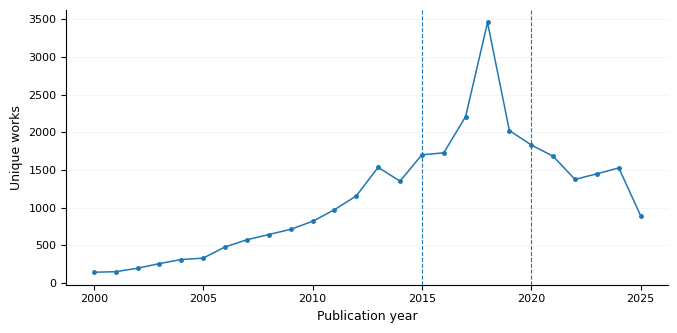

/tmp/ipykernel_1569/843382525.py:879: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures/Fig_B_future_productivity_distributions.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures/Fig_B_future_productivity_distributions.png


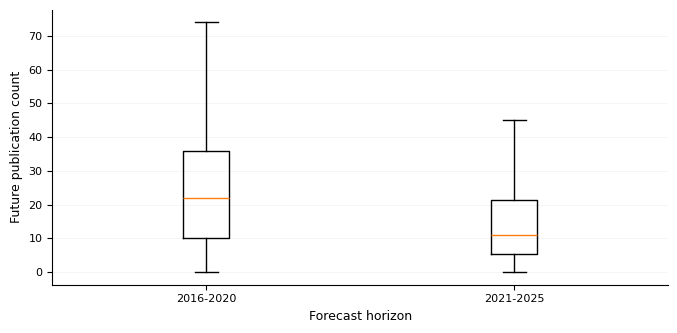

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures/Fig_C_historical_roster_coverage.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures/Fig_C_historical_roster_coverage.png


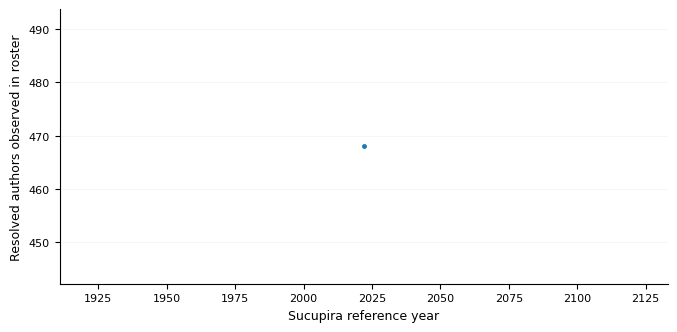


TABLE H — MODELING DECISION GATE
 publication_coverage_2010_2025  two_temporal_windows_available  resolved_cohort_n cohort_ascertainment_risk  ready_for_final_modeling                                                                                                                                                                                                                                                                                                                       cohort_message
                           True                            True                499                      HIGH                     False Historical cutoff membership could not be reconstructed reliably from the currently resolved author set. Using a cohort selected from a later roster would create cohort-ascertainment/survivorship leakage. Do not train the final predictive models until this is resolved or explicitly reframed as a fixed retrospective cohort.


,publication_coverage_2010_2025,two_temporal_windows_available,resolved_cohort_n,cohort_ascertainment_risk,ready_for_final_modeling,cohort_message
0,True,True,499,HIGH,False,Historical cutoff membership could not be reco...



SCIENTOMETRICS MANUSCRIPT OUTPUT PLAN
manuscript_item                                                                                                planned_content                   source_now main_or_supplement
        Table 1             Temporal cohort, publication coverage, and historical network characteristics by prediction window Table F + final cohort audit               Main
        Table 2 Out-of-period predictive performance: persistence baseline, past-productivity, graph-only, and combined models        Future Part 18.3/18.4               Main
        Table 3                               Incremental predictive value of graph features with paired bootstrap uncertainty             Future Part 18.4               Main
        Table 4        Robustness analyses: cohort definition, isolates, alternative windows, and negative-control permutation             Future Part 18.5               Main
         Fig. 1                                                                       

,manuscript_item,planned_content,source_now,main_or_supplement
0,Table 1,"Temporal cohort, publication coverage, and his...",Table F + final cohort audit,Main
1,Table 2,Out-of-period predictive performance: persiste...,Future Part 18.3/18.4,Main
2,Table 3,Incremental predictive value of graph features...,Future Part 18.4,Main
3,Table 4,"Robustness analyses: cohort definition, isolat...",Future Part 18.5,Main
4,Fig. 1,Temporal design and leakage barriers,Final manuscript workflow,Main
5,Fig. 2,Observed versus predicted future productivity ...,Future Part 18.4,Main
6,Fig. 3,Paired bootstrap distribution/intervals for in...,Future Part 18.4,Main
7,Fig. 4,Permutation importance or standardized effects...,Future Part 18.4,Main



ARQUIVOS SALVOS
Tables: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/tables
Figures: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/figures
Artifacts: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/artifacts
README: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/02_temporal_audit/README.txt

BLOCOS A ENVIAR PARA A PRÓXIMA ETAPA
1) TABLE B — IDENTIFIER INFERENCE
2) TABLE C — PUBLICATION COVERAGE
3) TABLE D — RESOLVED COHORT LINKAGE
4) TABLE E — HISTORICAL ROSTER OVERLAP (se aparecer)
5) TABLE F — TEMPORAL WINDOW AND NETWORK SUMMARY
6) TABLE G — CUTOFF COHORT AUDIT
7) TABLE H — MODELING DECISION GATE

CONCLUÍDO.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.2 — AUDITORIA PROFUNDA, COORTE HISTÓRICA E PAINÉIS TEMPORAIS CANDIDATOS
================================================================================

Artigo:
Do Collaboration Graph Features Predict Future Scientific Productivity?
A Leakage-Aware Temporal Evaluation in Brazilian Information Science

Objetivos desta etapa
---------------------
1. Montar o Google Drive e reutilizar os caminhos selecionados na Parte 18.1.
2. Auditar profundamente os identificadores de autores e publicações.
3. Verificar cobertura temporal real do corpus.
4. Verificar se o arquivo Sucupira permite reconstruir coortes historicamente observáveis.
5. Construir painéis temporais CANDIDATOS e redes históricas, sem treinar modelos.
6. Mostrar tabelas e figuras no Colab e salvar tudo no Drive.
7. Exportar figuras em EPS (vetorial) e PNG 600 dpi, sem título/caption embutido,
   para compatibilidade com as diretrizes da Scientometrics/Springer.

Execução
--------
%run /content/Parte_18_2_Auditoria_Paineis_Temporais.py
"""

from __future__ import annotations

import json
import math
import re
import sys
import pickle
import unicodedata
import importlib
from itertools import combinations
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("pandas")
ensure("numpy")
ensure("openpyxl")
ensure("networkx")
ensure("matplotlib")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
RUN_ROOT = ROOT / "runs" / "temporal_productivity_20260929"
INV_DIR = RUN_ROOT / "01_inventory"
OUT = RUN_ROOT / "02_temporal_audit"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"

for d in [OUT, TAB, FIG, ART]:
    d.mkdir(parents=True, exist_ok=True)

selected_json = INV_DIR / "selected_candidate_paths.json"

fallback = {
    "publications": str(ROOT / "runs/run_20260625_200032/input/producoes_final.xlsx"),
    "authors_resolved": str(ROOT / "runs/run_20260625_200032/input/autores_final.xlsx"),
    "roster_sucupira": str(ROOT / "runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx"),
}

if selected_json.exists():
    selected = json.loads(selected_json.read_text(encoding="utf-8"))
else:
    selected = fallback

PUB_PATH = Path(selected.get("publications") or fallback["publications"])
AUTH_PATH = Path(selected.get("authors_resolved") or fallback["authors_resolved"])
ROSTER_PATH = Path(selected.get("roster_sucupira") or fallback["roster_sucupira"])

for p in [PUB_PATH, AUTH_PATH, ROSTER_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

# Janelas pré-especificadas.
WINDOWS = [
    {
        "label": "development",
        "feature_start": 2010,
        "feature_end": 2015,
        "outcome_start": 2016,
        "outcome_end": 2020,
    },
    {
        "label": "temporal_replication",
        "feature_start": 2016,
        "feature_end": 2020,
        "outcome_start": 2021,
        "outcome_end": 2025,
    },
]

# ======================================================================================
# 3. FUNÇÕES
# ======================================================================================

def normalize_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_name(x):
    s = normalize_text(x)
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_title(x):
    s = normalize_text(x)
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def show_df(name, df, max_rows=30):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if len(df) > max_rows:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    else:
        print(df.to_string(index=False))
    if display is not None:
        display(df.head(max_rows))

def describe_dataframe(label, df):
    out = pd.DataFrame({
        "column": df.columns.astype(str),
        "dtype": [str(df[c].dtype) for c in df.columns],
        "non_missing": [int(df[c].notna().sum()) for c in df.columns],
        "missing_pct": [float(df[c].isna().mean() * 100) for c in df.columns],
        "n_unique": [int(df[c].nunique(dropna=True)) for c in df.columns],
    })
    out.insert(0, "dataset", label)
    return out

def prefix_share(series, prefix):
    s = series.dropna().astype(str).str.strip().str.upper()
    if len(s) == 0:
        return 0.0
    return float(s.str.match(rf"^{re.escape(prefix)}\d+$").mean())

def doi_share(series):
    s = series.dropna().astype(str).str.lower()
    if len(s) == 0:
        return 0.0
    return float(s.str.contains(r"10\.\d{4,9}/", regex=True).mean())

def infer_openalex_roles(df):
    rows = []
    for c in df.columns:
        ser = df[c]
        if ser.dtype == "object" or pd.api.types.is_string_dtype(ser):
            rows.append({
                "column": str(c),
                "author_A_share": prefix_share(ser, "A"),
                "work_W_share": prefix_share(ser, "W"),
                "doi_share": doi_share(ser),
                "n_unique": int(ser.nunique(dropna=True)),
            })
    return pd.DataFrame(rows).sort_values(
        ["author_A_share", "work_W_share", "doi_share"],
        ascending=False
    )

def infer_year_column(df):
    candidates = []
    for c in df.columns:
        ser = pd.to_numeric(df[c], errors="coerce")
        valid = ser.between(1900, 2030)
        valid_n = int(valid.sum())
        if valid_n == 0:
            continue
        share = float(valid.mean())
        name = normalize_text(c)
        name_bonus = 0
        if name in {"ano", "year", "ano_base", "an_base", "publication_year"}:
            name_bonus += 10
        if "ano" in name or "year" in name:
            name_bonus += 3
        if "base" in name:
            name_bonus += 1
        candidates.append({
            "column": c,
            "valid_year_share": share,
            "valid_n": valid_n,
            "min_year": int(ser[valid].min()),
            "max_year": int(ser[valid].max()),
            "n_unique_years": int(ser[valid].nunique()),
            "name_bonus": name_bonus,
            "score": share + name_bonus,
        })
    if not candidates:
        return None, pd.DataFrame()
    cand = pd.DataFrame(candidates).sort_values(
        ["score", "n_unique_years", "valid_n"],
        ascending=False
    )
    return str(cand.iloc[0]["column"]), cand

def infer_name_columns(df):
    rows = []
    for c in df.columns:
        name = normalize_text(c)
        score = 0
        if any(t in name for t in ["nome", "name", "docente", "author", "autor"]):
            score += 2
        if any(t in name for t in ["ies", "programa", "instituicao", "entidade"]):
            score -= 2
        if score > 0:
            rows.append((c, score))
    rows = sorted(rows, key=lambda x: -x[1])
    return [c for c, _ in rows]

def choose_name_pair(auth_df, roster_df):
    auth_candidates = infer_name_columns(auth_df)
    roster_candidates = infer_name_columns(roster_df)
    best = None
    rows = []

    for ac in auth_candidates[:8]:
        aset = set(auth_df[ac].dropna().map(normalize_name))
        aset.discard("")
        if not aset:
            continue
        for rc in roster_candidates[:12]:
            rset = set(roster_df[rc].dropna().map(normalize_name))
            rset.discard("")
            if not rset:
                continue
            inter = aset & rset
            recall_auth = len(inter) / max(1, len(aset))
            recall_roster = len(inter) / max(1, len(rset))
            score = 2 * recall_auth + 0.25 * recall_roster
            row = {
                "authors_name_col": ac,
                "roster_name_col": rc,
                "authors_unique_names": len(aset),
                "roster_unique_names": len(rset),
                "intersection": len(inter),
                "authors_match_share": recall_auth,
                "roster_match_share": recall_roster,
                "score": score,
            }
            rows.append(row)
            if best is None or score > best["score"]:
                best = row

    return best, pd.DataFrame(rows).sort_values("score", ascending=False) if rows else pd.DataFrame()

def choose_author_id_column(df):
    role = infer_openalex_roles(df)
    if not role.empty and role["author_A_share"].max() > 0.5:
        return str(role.sort_values(["author_A_share", "n_unique"], ascending=False).iloc[0]["column"])
    # fallback por nome
    priority = ["autor_id", "author_id", "id_autor", "id_openalex"]
    low = {normalize_text(c): c for c in df.columns}
    for p in priority:
        if p in low:
            return str(low[p])
    return None

def choose_work_id_column(df, author_col=None):
    role = infer_openalex_roles(df)
    if not role.empty and role["work_W_share"].max() > 0.5:
        cand = role.sort_values(["work_W_share", "n_unique"], ascending=False)
        for _, r in cand.iterrows():
            if str(r["column"]) != str(author_col):
                return str(r["column"]), "openalex_work_id"
    # DOI
    if not role.empty and role["doi_share"].max() > 0.3:
        cand = role.sort_values(["doi_share", "n_unique"], ascending=False)
        for _, r in cand.iterrows():
            if str(r["column"]) != str(author_col):
                return str(r["column"]), "doi"
    return None, None

def choose_title_column(df):
    low = {normalize_text(c): c for c in df.columns}
    for p in ["titulo", "title", "display_name", "nome_trabalho", "work_title"]:
        if p in low:
            return str(low[p])
    for c in df.columns:
        n = normalize_text(c)
        if "titulo" in n or "title" in n:
            return str(c)
    return None

def choose_doi_column(df):
    role = infer_openalex_roles(df)
    if not role.empty and role["doi_share"].max() > 0.05:
        return str(role.sort_values("doi_share", ascending=False).iloc[0]["column"])
    for c in df.columns:
        if "doi" in normalize_text(c):
            return str(c)
    return None

def make_work_key(df, year_col, author_col):
    work_col, work_kind = choose_work_id_column(df, author_col=author_col)
    doi_col = choose_doi_column(df)
    title_col = choose_title_column(df)

    key = pd.Series(index=df.index, dtype="object")
    source = pd.Series(index=df.index, dtype="object")

    # 1) OpenAlex W-id
    if work_col is not None and work_kind == "openalex_work_id":
        vals = df[work_col].astype(str).str.strip().str.upper()
        mask = vals.str.match(r"^W\d+$", na=False)
        key.loc[mask] = "W:" + vals.loc[mask]
        source.loc[mask] = "openalex_work_id"

    # 2) DOI
    if doi_col is not None:
        vals = df[doi_col].astype(str).str.lower().str.strip()
        vals = vals.str.replace("https://doi.org/", "", regex=False)
        vals = vals.str.replace("http://doi.org/", "", regex=False)
        mask = key.isna() & vals.str.contains(r"10\.\d{4,9}/", regex=True, na=False)
        key.loc[mask] = "DOI:" + vals.loc[mask]
        source.loc[mask] = "doi"

    # 3) título + ano
    if title_col is not None:
        titles = df[title_col].map(normalize_title)
        years = pd.to_numeric(df[year_col], errors="coerce").astype("Int64").astype(str)
        mask = key.isna() & titles.ne("")
        key.loc[mask] = "TY:" + titles.loc[mask] + "|" + years.loc[mask]
        source.loc[mask] = "title_year"

    return key, source, {
        "work_id_column": work_col,
        "work_id_kind": work_kind,
        "doi_column": doi_col,
        "title_column": title_col,
    }

def build_graph(long_df, cohort_ids, start_year, end_year):
    x = long_df[
        long_df["year"].between(start_year, end_year)
        & long_df["author_key"].isin(cohort_ids)
    ][["author_key", "work_key"]].drop_duplicates()

    G = nx.Graph()
    G.add_nodes_from(sorted(cohort_ids))

    grouped = x.groupby("work_key")["author_key"].apply(lambda s: sorted(set(s)))
    used_multi = 0

    for authors in grouped:
        if len(authors) < 2:
            continue
        used_multi += 1
        for u, v in combinations(authors, 2):
            if G.has_edge(u, v):
                G[u][v]["weight"] += 1.0
            else:
                G.add_edge(u, v, weight=1.0)

    return G, x, used_multi

def safe_weighted_clustering(G):
    try:
        return nx.clustering(G, weight="weight")
    except Exception:
        return {n: 0.0 for n in G.nodes()}

def graph_features(G):
    nodes = list(G.nodes())
    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))

    # distance = inverse tie strength
    H = G.copy()
    for u, v, d in H.edges(data=True):
        w = float(d.get("weight", 1.0))
        d["distance"] = 1.0 / w if w > 0 else 1.0

    if G.number_of_edges() > 0:
        pagerank = nx.pagerank(G, weight="weight")
        clustering = safe_weighted_clustering(G)
        avg_neighbor_degree = nx.average_neighbor_degree(G, weight="weight")

        # n ~ 500: cálculo exato ainda é viável.
        betweenness = nx.betweenness_centrality(H, weight="distance", normalized=True)

        # core_number não aceita self-loops; não existem aqui.
        core = nx.core_number(G) if G.number_of_edges() > 0 else {n: 0 for n in nodes}
    else:
        pagerank = {n: 0.0 for n in nodes}
        clustering = {n: 0.0 for n in nodes}
        avg_neighbor_degree = {n: 0.0 for n in nodes}
        betweenness = {n: 0.0 for n in nodes}
        core = {n: 0 for n in nodes}

    comp_size = {}
    for comp in nx.connected_components(G):
        size = len(comp)
        for n in comp:
            comp_size[n] = size

    rows = []
    for n in nodes:
        k = int(degree.get(n, 0))
        s = float(strength.get(n, 0.0))
        rows.append({
            "author_key": n,
            "degree": k,
            "strength": s,
            "avg_tie_strength": (s / k) if k > 0 else 0.0,
            "weighted_clustering": float(clustering.get(n, 0.0)),
            "pagerank": float(pagerank.get(n, 0.0)),
            "betweenness": float(betweenness.get(n, 0.0)),
            "core_number": int(core.get(n, 0)),
            "avg_neighbor_degree": float(avg_neighbor_degree.get(n, 0.0)),
            "component_size": int(comp_size.get(n, 1)),
            "is_isolate": int(k == 0),
        })
    return pd.DataFrame(rows)

def save_figure(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

# ======================================================================================
# 4. CARREGAMENTO
# ======================================================================================

print("\n" + "=" * 118)
print("PARTE 18.2 — AUDITORIA PROFUNDA E PAINÉIS TEMPORAIS CANDIDATOS")
print("=" * 118)
print("[publications]", PUB_PATH)
print("[authors]     ", AUTH_PATH)
print("[roster]      ", ROSTER_PATH)
print("[output]      ", OUT)

pub = pd.read_excel(PUB_PATH)
auth = pd.read_excel(AUTH_PATH)
roster = pd.read_excel(ROSTER_PATH)

print(f"\nShapes: publications={pub.shape}, authors={auth.shape}, roster={roster.shape}")

# ======================================================================================
# 5. ESQUEMA COMPLETO
# ======================================================================================

schema = pd.concat([
    describe_dataframe("publications", pub),
    describe_dataframe("authors_resolved", auth),
    describe_dataframe("roster_sucupira", roster),
], ignore_index=True)

schema.to_csv(TAB / "Table_A_full_schema_audit.csv", index=False)
show_df("TABLE A — FULL SCHEMA AUDIT", schema, max_rows=100)

# ======================================================================================
# 6. INFERÊNCIA DE IDENTIFICADORES
# ======================================================================================

pub_roles = infer_openalex_roles(pub)
auth_roles = infer_openalex_roles(auth)

pub_author_col = choose_author_id_column(pub)
auth_author_col = choose_author_id_column(auth)
pub_year_col, pub_year_candidates = infer_year_column(pub)
roster_year_col, roster_year_candidates = infer_year_column(roster)

if pub_author_col is None:
    raise RuntimeError("Não foi possível inferir o identificador de autor em producoes_final.xlsx.")
if pub_year_col is None:
    raise RuntimeError("Não foi possível inferir a coluna de ano em producoes_final.xlsx.")

work_key, work_key_source, work_meta = make_work_key(
    pub, year_col=pub_year_col, author_col=pub_author_col
)

pub2 = pub.copy()
pub2["author_key"] = pub2[pub_author_col].astype(str).str.strip().str.upper()
pub2["year"] = pd.to_numeric(pub2[pub_year_col], errors="coerce")
pub2["work_key"] = work_key
pub2["work_key_source"] = work_key_source

valid_author = pub2["author_key"].str.match(r"^A\d+$", na=False)
if valid_author.mean() < 0.5:
    # Não exigir prefixo OpenAlex se a coluna for um ID interno.
    valid_author = pub2["author_key"].notna() & pub2["author_key"].ne("")

pub2 = pub2[valid_author].copy()
pub2 = pub2[pub2["year"].between(1900, 2030)].copy()
pub2["year"] = pub2["year"].astype(int)
pub2 = pub2[pub2["work_key"].notna()].copy()

id_summary = pd.DataFrame([
    {"item": "publication_author_column", "value": pub_author_col},
    {"item": "authors_resolved_author_column", "value": auth_author_col or ""},
    {"item": "publication_year_column", "value": pub_year_col},
    {"item": "roster_year_column", "value": roster_year_col or ""},
    {"item": "work_id_column", "value": work_meta.get("work_id_column") or ""},
    {"item": "work_id_kind", "value": work_meta.get("work_id_kind") or ""},
    {"item": "doi_column", "value": work_meta.get("doi_column") or ""},
    {"item": "title_column", "value": work_meta.get("title_column") or ""},
])

id_summary.to_csv(TAB / "Table_B_identifier_inference.csv", index=False)
show_df("TABLE B — IDENTIFIER INFERENCE", id_summary)

if not pub_roles.empty:
    pub_roles.to_csv(TAB / "audit_publication_openalex_roles.csv", index=False)
    show_df("PUBLICATION IDENTIFIER ROLE AUDIT", pub_roles, max_rows=50)

if not auth_roles.empty:
    auth_roles.to_csv(TAB / "audit_author_openalex_roles.csv", index=False)
    show_df("AUTHORS IDENTIFIER ROLE AUDIT", auth_roles, max_rows=50)

if not roster_year_candidates.empty:
    roster_year_candidates.to_csv(TAB / "audit_roster_year_candidates.csv", index=False)
    show_df("ROSTER YEAR CANDIDATES", roster_year_candidates, max_rows=30)

# ======================================================================================
# 7. LONG TABLE DE AUTOR–PUBLICAÇÃO
# ======================================================================================

long_df = pub2[["author_key", "work_key", "work_key_source", "year"]].drop_duplicates().copy()

dup_n = int(pub2.duplicated(["author_key", "work_key"]).sum())
source_counts = (
    long_df["work_key_source"]
    .value_counts(dropna=False)
    .rename_axis("work_key_source")
    .reset_index(name="author_work_rows")
)

coverage_summary = pd.DataFrame([{
    "raw_rows": int(len(pub)),
    "valid_author_work_rows": int(len(long_df)),
    "duplicate_author_work_rows_removed": dup_n,
    "unique_authors_in_publications": int(long_df["author_key"].nunique()),
    "unique_works": int(long_df["work_key"].nunique()),
    "min_year": int(long_df["year"].min()),
    "max_year": int(long_df["year"].max()),
    "rows_2010_2025": int(long_df["year"].between(2010, 2025).sum()),
    "works_2010_2025": int(long_df.loc[long_df["year"].between(2010, 2025), "work_key"].nunique()),
}])

coverage_summary.to_csv(TAB / "Table_C_publication_coverage.csv", index=False)
source_counts.to_csv(TAB / "Table_C2_work_key_sources.csv", index=False)

show_df("TABLE C — PUBLICATION COVERAGE", coverage_summary)
show_df("TABLE C2 — WORK KEY SOURCES", source_counts)

# ======================================================================================
# 8. COORTE RESOLVIDA
# ======================================================================================

if auth_author_col is not None:
    auth_ids = (
        auth[auth_author_col]
        .dropna()
        .astype(str)
        .str.strip()
        .str.upper()
    )
    # Se for OpenAlex A-id, filtra.
    if auth_ids.str.match(r"^A\d+$").mean() > 0.5:
        auth_ids = auth_ids[auth_ids.str.match(r"^A\d+$")]
    resolved_ids = set(auth_ids)
else:
    # fallback: autores presentes no corpus
    resolved_ids = set(long_df["author_key"].unique())

pub_author_ids = set(long_df["author_key"].unique())
resolved_with_publications = resolved_ids & pub_author_ids

cohort_id_summary = pd.DataFrame([{
    "resolved_author_ids": len(resolved_ids),
    "publication_author_ids": len(pub_author_ids),
    "resolved_ids_found_in_publications": len(resolved_with_publications),
    "resolved_match_share": len(resolved_with_publications) / max(1, len(resolved_ids)),
}])

cohort_id_summary.to_csv(TAB / "Table_D_resolved_cohort_linkage.csv", index=False)
show_df("TABLE D — RESOLVED COHORT LINKAGE", cohort_id_summary)

# ======================================================================================
# 9. AUDITORIA LONGITUDINAL DO Sucupira
# ======================================================================================

best_name_pair, name_pair_audit = choose_name_pair(auth, roster)

if not name_pair_audit.empty:
    name_pair_audit.to_csv(TAB / "audit_name_matching_candidates.csv", index=False)
    show_df("NAME MATCHING CANDIDATES", name_pair_audit.head(20), max_rows=20)

historical_overlap = pd.DataFrame()
historical_resolved_ids_by_year = {}

if best_name_pair is not None and roster_year_col is not None:
    auth_name_col = best_name_pair["authors_name_col"]
    roster_name_col = best_name_pair["roster_name_col"]

    # mapa nome -> resolved author ID
    auth_map = auth[[auth_name_col, auth_author_col]].dropna().copy() if auth_author_col else pd.DataFrame()
    if not auth_map.empty:
        auth_map["name_norm"] = auth_map[auth_name_col].map(normalize_name)
        auth_map["author_key"] = auth_map[auth_author_col].astype(str).str.strip().str.upper()
        auth_map = auth_map[auth_map["name_norm"].ne("")]
        # nomes duplicados são ambíguos: não forçar ligação.
        name_counts = auth_map["name_norm"].value_counts()
        unique_names = set(name_counts[name_counts == 1].index)
        auth_map = auth_map[auth_map["name_norm"].isin(unique_names)]
        name_to_author = dict(zip(auth_map["name_norm"], auth_map["author_key"]))

        roster2 = roster.copy()
        roster2["roster_year"] = pd.to_numeric(roster2[roster_year_col], errors="coerce")
        roster2 = roster2[roster2["roster_year"].between(1900, 2030)].copy()
        roster2["roster_year"] = roster2["roster_year"].astype(int)
        roster2["name_norm"] = roster2[roster_name_col].map(normalize_name)
        roster2["resolved_author_key"] = roster2["name_norm"].map(name_to_author)

        rows = []
        for yr, g in roster2.groupby("roster_year"):
            total_names = g["name_norm"].replace("", np.nan).nunique()
            matched = g["resolved_author_key"].dropna().nunique()
            ids = set(g["resolved_author_key"].dropna().astype(str))
            historical_resolved_ids_by_year[int(yr)] = ids
            rows.append({
                "year": int(yr),
                "roster_unique_names": int(total_names),
                "matched_resolved_authors": int(matched),
                "match_share_roster_names": matched / max(1, total_names),
            })
        historical_overlap = pd.DataFrame(rows).sort_values("year")
        historical_overlap.to_csv(TAB / "Table_E_historical_roster_overlap.csv", index=False)
        show_df("TABLE E — HISTORICAL ROSTER OVERLAP", historical_overlap, max_rows=100)

# ======================================================================================
# 10. PAINÉIS TEMPORAIS CANDIDATOS — FIXED RESOLVED COHORT
# ======================================================================================

# O painel abaixo é construído para auditoria. A escolha final da coorte será congelada
# somente depois da avaliação do roster histórico.
fixed_cohort = sorted(resolved_with_publications)

panel_rows = []
network_rows = []
panels = {}
graphs = {}

for w in WINDOWS:
    label = w["label"]
    fs, fe = w["feature_start"], w["feature_end"]
    os_, oe = w["outcome_start"], w["outcome_end"]

    past = (
        long_df[
            long_df["author_key"].isin(fixed_cohort)
            & long_df["year"].between(fs, fe)
        ]
        .groupby("author_key")
        .agg(
            past_works=("work_key", "nunique"),
            past_active_years=("year", "nunique"),
            past_first_year=("year", "min"),
            past_last_year=("year", "max"),
        )
        .reset_index()
    )

    future = (
        long_df[
            long_df["author_key"].isin(fixed_cohort)
            & long_df["year"].between(os_, oe)
        ]
        .groupby("author_key")
        .agg(
            future_works=("work_key", "nunique"),
            future_active_years=("year", "nunique"),
        )
        .reset_index()
    )

    G, feature_long, n_multi = build_graph(long_df, set(fixed_cohort), fs, fe)
    gf = graph_features(G)

    panel = pd.DataFrame({"author_key": fixed_cohort})
    panel = panel.merge(past, on="author_key", how="left")
    panel = panel.merge(gf, on="author_key", how="left")
    panel = panel.merge(future, on="author_key", how="left")

    fill_zero = [
        "past_works", "past_active_years", "future_works", "future_active_years",
        "degree", "strength", "avg_tie_strength", "weighted_clustering",
        "pagerank", "betweenness", "core_number", "avg_neighbor_degree",
        "component_size", "is_isolate"
    ]
    for c in fill_zero:
        if c in panel.columns:
            panel[c] = panel[c].fillna(0)

    panel["past_annual_rate"] = panel["past_works"] / max(1, fe - fs + 1)
    panel["future_annual_rate"] = panel["future_works"] / max(1, oe - os_ + 1)
    panel["window"] = label
    panel["feature_start"] = fs
    panel["feature_end"] = fe
    panel["outcome_start"] = os_
    panel["outcome_end"] = oe

    panels[label] = panel
    graphs[label] = G

    panel.to_csv(TAB / f"candidate_panel_{label}.csv", index=False)

    comps = list(nx.connected_components(G))
    giant = max((len(c) for c in comps), default=0)

    network_rows.append({
        "window": label,
        "feature_period": f"{fs}-{fe}",
        "n_cohort": len(fixed_cohort),
        "authors_with_past_output": int((panel["past_works"] > 0).sum()),
        "authors_with_future_output": int((panel["future_works"] > 0).sum()),
        "future_zero_count": int((panel["future_works"] == 0).sum()),
        "future_zero_pct": float((panel["future_works"] == 0).mean() * 100),
        "graph_nodes": G.number_of_nodes(),
        "graph_edges": G.number_of_edges(),
        "isolates": int(nx.number_of_isolates(G)),
        "connected_components": nx.number_connected_components(G),
        "giant_component_n": giant,
        "multi_ppgci_works_in_feature_window": n_multi,
        "median_future_works": float(panel["future_works"].median()),
        "mean_future_works": float(panel["future_works"].mean()),
        "max_future_works": float(panel["future_works"].max()),
    })

network_summary = pd.DataFrame(network_rows)
network_summary.to_csv(TAB / "Table_F_temporal_window_and_network_summary.csv", index=False)
show_df("TABLE F — TEMPORAL WINDOW AND NETWORK SUMMARY", network_summary)

with open(ART / "candidate_temporal_graphs.pkl", "wb") as f:
    pickle.dump(graphs, f, pickle.HIGHEST_PROTOCOL)

# ======================================================================================
# 11. COORTE HISTÓRICA NO CUTOFF — DIAGNÓSTICO DE LEAKAGE
# ======================================================================================

cohort_cutoff_rows = []

for cutoff in [2015, 2020, 2022]:
    ids = historical_resolved_ids_by_year.get(cutoff, set())
    cohort_cutoff_rows.append({
        "cutoff_year": cutoff,
        "historical_roster_available": int(cutoff in historical_resolved_ids_by_year),
        "resolved_authors_observed_in_roster": len(ids),
        "share_of_fixed_resolved_cohort": len(ids & set(fixed_cohort)) / max(1, len(fixed_cohort)),
    })

cohort_cutoff = pd.DataFrame(cohort_cutoff_rows)
cohort_cutoff.to_csv(TAB / "Table_G_cutoff_cohort_audit.csv", index=False)
show_df("TABLE G — CUTOFF COHORT AUDIT", cohort_cutoff)

if (
    2015 in historical_resolved_ids_by_year
    and 2020 in historical_resolved_ids_by_year
    and len(historical_resolved_ids_by_year[2015]) > 0
    and len(historical_resolved_ids_by_year[2020]) > 0
):
    cohort_risk = "MODERATE"
    cohort_message = (
        "Historical Sucupira membership is observable for both cutoffs among resolved authors. "
        "The final pipeline should use cutoff-defined membership rather than the full 2022-resolved cohort, "
        "while explicitly acknowledging unresolved historical faculty."
    )
else:
    cohort_risk = "HIGH"
    cohort_message = (
        "Historical cutoff membership could not be reconstructed reliably from the currently resolved author set. "
        "Using a cohort selected from a later roster would create cohort-ascertainment/survivorship leakage. "
        "Do not train the final predictive models until this is resolved or explicitly reframed as a fixed retrospective cohort."
    )

# ======================================================================================
# 12. FIGURAS DE AUDITORIA — SCIENTOMETRICS READY
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Fig. A — cobertura anual
annual = (
    long_df[long_df["year"].between(2000, 2025)]
    .groupby("year")
    .agg(
        unique_works=("work_key", "nunique"),
        unique_authors=("author_key", "nunique"),
    )
    .reset_index()
)
annual.to_csv(TAB / "annual_publication_coverage.csv", index=False)

fig, ax = plt.subplots(figsize=(6.85, 3.4))
ax.plot(annual["year"], annual["unique_works"], marker="o", markersize=2.5, linewidth=1.1)
ax.axvline(2015, linewidth=0.8, linestyle="--")
ax.axvline(2020, linewidth=0.8, linestyle="--")
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique works")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig_A_annual_publication_coverage")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. B — outcome distributions por janela
fig, ax = plt.subplots(figsize=(6.85, 3.4))
data = []
labels = []
for w in WINDOWS:
    lab = w["label"]
    data.append(panels[lab]["future_works"].to_numpy())
    labels.append(f"{w['outcome_start']}-{w['outcome_end']}")
ax.boxplot(data, labels=labels, showfliers=False)
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Future publication count")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig_B_future_productivity_distributions")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. C — cobertura histórica da coorte, se possível
if not historical_overlap.empty:
    fig, ax = plt.subplots(figsize=(6.85, 3.4))
    ax.plot(
        historical_overlap["year"],
        historical_overlap["matched_resolved_authors"],
        marker="o",
        markersize=2.5,
        linewidth=1.1
    )
    ax.set_xlabel("Sucupira reference year")
    ax.set_ylabel("Resolved authors observed in roster")
    ax.grid(axis="y", alpha=0.18, linewidth=0.5)
    fig.tight_layout()
    save_figure(fig, "Fig_C_historical_roster_coverage")
    if display is not None:
        display(fig)
    else:
        plt.show()
    plt.close(fig)

# ======================================================================================
# 13. DECISION GATE
# ======================================================================================

year_min = int(long_df["year"].min())
year_max = int(long_df["year"].max())
has_full_temporal_coverage = year_min <= 2010 and year_max >= 2025
has_two_windows = all(
    long_df["year"].between(w["feature_start"], w["feature_end"]).any()
    and long_df["year"].between(w["outcome_start"], w["outcome_end"]).any()
    for w in WINDOWS
)

decision = pd.DataFrame([{
    "publication_coverage_2010_2025": bool(has_full_temporal_coverage),
    "two_temporal_windows_available": bool(has_two_windows),
    "resolved_cohort_n": len(fixed_cohort),
    "cohort_ascertainment_risk": cohort_risk,
    "ready_for_final_modeling": bool(has_full_temporal_coverage and has_two_windows and cohort_risk != "HIGH"),
    "cohort_message": cohort_message,
}])

decision.to_csv(TAB / "Table_H_modeling_decision_gate.csv", index=False)
show_df("TABLE H — MODELING DECISION GATE", decision)

# ======================================================================================
# 14. MANUSCRIPT-OUTPUT PLAN
# ======================================================================================

output_plan = pd.DataFrame([
    {
        "manuscript_item": "Table 1",
        "planned_content": "Temporal cohort, publication coverage, and historical network characteristics by prediction window",
        "source_now": "Table F + final cohort audit",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Table 2",
        "planned_content": "Out-of-period predictive performance: persistence baseline, past-productivity, graph-only, and combined models",
        "source_now": "Future Part 18.3/18.4",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Table 3",
        "planned_content": "Incremental predictive value of graph features with paired bootstrap uncertainty",
        "source_now": "Future Part 18.4",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Table 4",
        "planned_content": "Robustness analyses: cohort definition, isolates, alternative windows, and negative-control permutation",
        "source_now": "Future Part 18.5",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Fig. 1",
        "planned_content": "Temporal design and leakage barriers",
        "source_now": "Final manuscript workflow",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Fig. 2",
        "planned_content": "Observed versus predicted future productivity in the untouched 2021–2025 test horizon",
        "source_now": "Future Part 18.4",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Fig. 3",
        "planned_content": "Paired bootstrap distribution/intervals for incremental graph-feature value",
        "source_now": "Future Part 18.4",
        "main_or_supplement": "Main"
    },
    {
        "manuscript_item": "Fig. 4",
        "planned_content": "Permutation importance or standardized effects for interpretable final models",
        "source_now": "Future Part 18.4",
        "main_or_supplement": "Main"
    },
])

output_plan.to_csv(TAB / "manuscript_output_plan.csv", index=False)
show_df("SCIENTOMETRICS MANUSCRIPT OUTPUT PLAN", output_plan)

# ======================================================================================
# 15. README
# ======================================================================================

readme = f"""
PARTE 18.2 — AUDITORIA PROFUNDA E PAINÉIS TEMPORAIS CANDIDATOS
===============================================================

Publication file:
{PUB_PATH}

Resolved authors:
{AUTH_PATH}

Sucupira roster:
{ROSTER_PATH}

Publication author column:
{pub_author_col}

Publication year column:
{pub_year_col}

Authors resolved ID column:
{auth_author_col}

Roster year column:
{roster_year_col}

Work-key construction:
{json.dumps(work_meta, ensure_ascii=False, indent=2)}

Fixed resolved cohort candidate:
n = {len(fixed_cohort)}

Cohort-ascertainment risk:
{cohort_risk}

Decision:
{cohort_message}

IMPORTANT
---------
The candidate panels saved in this directory are AUDIT artifacts.
Do not use them as final modeling panels until the historical cohort decision is frozen.

The final paper will prioritize manuscript-ready tables for exact numerical results
and a smaller number of figures for temporal design, out-of-period prediction,
incremental graph value, and interpretability. Figures are exported as EPS and
PNG 600 dpi without embedded titles/captions, following Springer artwork guidance.
""".strip()

(OUT / "README.txt").write_text(readme, encoding="utf-8")

print("\n" + "=" * 118)
print("ARQUIVOS SALVOS")
print("=" * 118)
print("Tables:", TAB)
print("Figures:", FIG)
print("Artifacts:", ART)
print("README:", OUT / "README.txt")

print("\n" + "=" * 118)
print("BLOCOS A ENVIAR PARA A PRÓXIMA ETAPA")
print("=" * 118)
print("1) TABLE B — IDENTIFIER INFERENCE")
print("2) TABLE C — PUBLICATION COVERAGE")
print("3) TABLE D — RESOLVED COHORT LINKAGE")
print("4) TABLE E — HISTORICAL ROSTER OVERLAP (se aparecer)")
print("5) TABLE F — TEMPORAL WINDOW AND NETWORK SUMMARY")
print("6) TABLE G — CUTOFF COHORT AUDIT")
print("7) TABLE H — MODELING DECISION GATE")

print("\nCONCLUÍDO.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.3 — WORK-ID / TEMPORAL QUALITY / HISTORICAL ROSTER
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[authors]      /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
[roster]       /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/03_workid_roster_audit

TABLE I — VALIDATION OF publications.id_openalex AS WORK ID
 publication_rows  nonmissing_id_openalex_rows  unique_id_openalex_values  unique_titles  unique_dois  id_groups_consistent_year_pct  id_groups_consistent_title_pct  id_groups_consistent_doi_pct  id_groups_fully_consistent_pct  multi_ppgci_author_work_ids  max_ppgci_authors_on_one_work
            38138           

,publication_rows,nonmissing_id_openalex_rows,unique_id_openalex_values,unique_titles,unique_dois,id_groups_consistent_year_pct,id_groups_consistent_title_pct,id_groups_consistent_doi_pct,id_groups_fully_consistent_pct,multi_ppgci_author_work_ids,max_ppgci_authors_on_one_work
0,38138,38138,30503,28366,19564,100.0,100.0,100.0,100.0,3551,13



WORK-ID INCONSISTENCIES
(empty)

TABLE J — ANNUAL TEMPORAL QUALITY AUDIT
 year  rows  unique_works  unique_authors  works_per_active_author  multi_ppgci_works  multi_ppgci_work_pct  doi_present_pct_rows  work_yoy_ratio  author_yoy_ratio  log_works  local_median_log  local_abs_dev  flag_large_yoy_change  flag_incomplete_recent
 2000   164           142              82                 1.731707                  6              4.225352             52.439024             NaN               NaN   4.962845          4.986740       0.023895                  False                   False
 2001   180           149              80                 1.862500                 12              8.053691             55.000000        1.049296          0.975610   5.010635          5.010635       0.000000                  False                   False
 2002   233           196              96                 2.041667                  9              4.591837             56.652361        1.315436          1.2000

,year,rows,unique_works,unique_authors,works_per_active_author,multi_ppgci_works,multi_ppgci_work_pct,doi_present_pct_rows,work_yoy_ratio,author_yoy_ratio,log_works,local_median_log,local_abs_dev,flag_large_yoy_change,flag_incomplete_recent
0,2000,164,142,82,1.731707,6,4.225352,52.439024,NaN,NaN,4.962845,4.986740,0.023895,False,False
1,2001,180,149,80,1.862500,12,8.053691,55.000000,1.049296,0.975610,5.010635,5.010635,0.000000,False,False
2,2002,233,196,96,2.041667,9,4.591837,56.652361,1.315436,1.200000,5.283204,5.283204,0.000000,False,False
3,2003,312,258,110,2.345455,19,7.364341,54.166667,1.316327,1.145833,5.556828,5.556828,0.000000,False,False
4,2004,346,311,138,2.253623,11,3.536977,57.225434,1.205426,1.254545,5.743003,5.743003,0.000000,False,False
5,2005,384,330,157,2.101911,18,5.454545,48.697917,1.061093,1.137681,5.802118,5.802118,0.000000,False,False
6,2006,569,481,191,2.518325,30,6.237006,52.548330,1.457576,1.216561,6.177944,6.177944,0.000000,True,False
7,2007,700,573,206,2.781553,45,7.853403,50.714286,1.191268,1.078534,6.352629,6.352629,0.000000,False,False
8,2008,793,646,229,2.820961,56,8.668731,60.025221,1.127400,1.111650,6.472346,6.472346,0.000000,False,False
9,2009,874,718,249,2.883534,59,8.217270,49.771167,1.111455,1.087336,6.577861,6.577861,0.000000,False,False



TABLE K — FLAGGED TEMPORAL YEARS
 year  rows  unique_works  unique_authors  works_per_active_author  multi_ppgci_works  multi_ppgci_work_pct  doi_present_pct_rows  work_yoy_ratio  author_yoy_ratio  log_works  local_median_log  local_abs_dev  flag_large_yoy_change  flag_incomplete_recent
 2006   569           481             191                 2.518325                 30              6.237006             52.548330        1.457576          1.216561   6.177944          6.177944       0.000000                   True                   False
 2018  4504          3491             460                 7.589130                519             14.866800             45.159858        1.577497          1.082353   8.158230          7.702556       0.455674                   True                   False
 2019  2631          2030             431                 4.709977                279             13.743842             64.500190        0.581495          0.936957   7.616284          7.616284       0.

,year,rows,unique_works,unique_authors,works_per_active_author,multi_ppgci_works,multi_ppgci_work_pct,doi_present_pct_rows,work_yoy_ratio,author_yoy_ratio,log_works,local_median_log,local_abs_dev,flag_large_yoy_change,flag_incomplete_recent
6,2006,569,481,191,2.518325,30,6.237006,52.548330,1.457576,1.216561,6.177944,6.177944,0.000000,True,False
18,2018,4504,3491,460,7.589130,519,14.866800,45.159858,1.577497,1.082353,8.158230,7.702556,0.455674,True,False
19,2019,2631,2030,431,4.709977,279,13.743842,64.500190,0.581495,0.936957,7.616284,7.616284,0.000000,True,False
25,2025,1019,893,240,3.720833,46,5.151176,99.901865,0.584042,0.638298,6.795706,7.064364,0.268659,True,True



TEMPORAL ANOMALY — TYPE BREAKDOWN
 year         tipo  unique_works
 2005      article           305
 2005 book-chapter             7
 2005 dissertation             6
 2005       review             5
 2005     preprint             3
 2005         book             2
 2005       letter             1
 2005       report             1
 2006      article           449
 2006 dissertation             9
 2006 book-chapter             8
 2006     preprint             5
 2006       review             5
 2006       report             2
 2006         book             1
 2006      dataset             1
 2006       letter             1
 2007      article           530
 2007 book-chapter            15
 2007 dissertation            10
 2007       review            10
 2007     preprint             3
 2007         book             2
 2007       letter             2
 2007    editorial             1
 2017      article          2023
 2017 book-chapter            66
 2017      dataset            39
 2017   

,year,tipo,unique_works
0,2005,article,305
2,2005,book-chapter,7
3,2005,dissertation,6
7,2005,review,5
5,2005,preprint,3
...,...,...,...
76,2024,book-chapter,123
83,2024,preprint,29
84,2024,review,24
75,2024,book,22


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/03_workid_roster_audit/figures/Fig_D_temporal_quality_audit.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/03_workid_roster_audit/figures/Fig_D_temporal_quality_audit.png


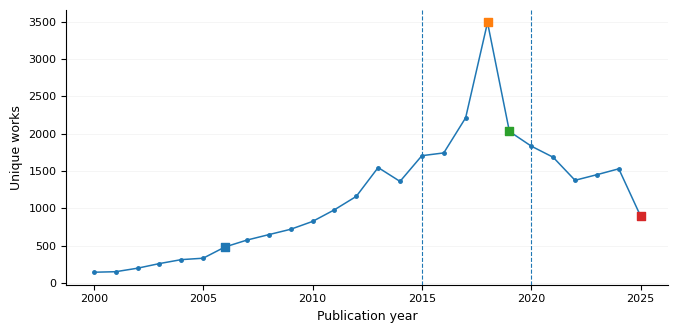


HISTORICAL ROSTER FILE CANDIDATES — BEFORE YEAR INSPECTION
                                              name   ext   size_mb            modified  keyword_score                                                                                                                    path
                 banco-sucupira_docente-PPGCI.xlsx .xlsx 24.045425 2026-06-25T20:02:43              5                   /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx
             banco-sucupira_docente-PPGCI (1).xlsx .xlsx 24.045425 2026-06-08T15:18:52              5               /content/drive/MyDrive/tese_doutoral/runs/run_20260608_151702/input/banco-sucupira_docente-PPGCI (1).xlsx
             banco-sucupira_docente-PPGCI (2).xlsx .xlsx 24.045425 2026-04-23T17:48:08              5               /content/drive/MyDrive/tese_doutoral/runs/run_20260423_173823/input/banco-sucupira_docente-PPGCI (2).xlsx
         tabela_7_5_3_top_autores_1autor_ppgci.csv  

,name,ext,size_mb,modified,keyword_score,path
148,banco-sucupira_docente-PPGCI.xlsx,.xlsx,24.045425,2026-06-25T20:02:43,5,/content/drive/MyDrive/tese_doutoral/runs/run_...
1388,banco-sucupira_docente-PPGCI (1).xlsx,.xlsx,24.045425,2026-06-08T15:18:52,5,/content/drive/MyDrive/tese_doutoral/runs/run_...
2371,banco-sucupira_docente-PPGCI (2).xlsx,.xlsx,24.045425,2026-04-23T17:48:08,5,/content/drive/MyDrive/tese_doutoral/runs/run_...
213,tabela_7_5_3_top_autores_1autor_ppgci.csv,.csv,0.000320,2026-06-25T20:06:10,1,/content/drive/MyDrive/tese_doutoral/runs/run_...
222,tabela_8_5_1_distribuicao_numero_autores_ppgci...,.csv,0.000097,2026-06-25T20:06:30,1,/content/drive/MyDrive/tese_doutoral/runs/run_...


[year scan 01/05] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx
[year scan 02/05] /content/drive/MyDrive/tese_doutoral/runs/run_20260608_151702/input/banco-sucupira_docente-PPGCI (1).xlsx
[year scan 03/05] /content/drive/MyDrive/tese_doutoral/runs/run_20260423_173823/input/banco-sucupira_docente-PPGCI (2).xlsx
[year scan 04/05] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/tables/tabela_7_5_3_top_autores_1autor_ppgci.csv
[year scan 05/05] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/tables/tabela_8_5_1_distribuicao_numero_autores_ppgci.csv

TABLE L — HISTORICAL ROSTER YEAR SCAN
                                                                                                     path                                  name           year_column  n_rows  valid_year_n  n_unique_years  min_year  max_year                                                                                                       

,path,name,year_column,n_rows,valid_year_n,n_unique_years,min_year,max_year,years_preview,has_2015,has_2020,has_2022,historical_priority
2,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI.xlsx,AN_TITULACAO,109533,109533,64,1957,2022,"1957,1960,1961,1962,1963,1964,1965,1966,1967,1...",1,1,1,11
5,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI (1).xlsx,AN_TITULACAO,109533,109533,64,1957,2022,"1957,1960,1961,1962,1963,1964,1965,1966,1967,1...",1,1,1,11
8,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI (2).xlsx,AN_TITULACAO,109533,109533,64,1957,2022,"1957,1960,1961,1962,1963,1964,1965,1966,1967,1...",1,1,1,11
1,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI.xlsx,AN_NASCIMENTO_DOCENTE,109533,109533,72,1923,2000,"1923,1924,1928,1929,1930,1931,1932,1933,1934,1...",0,0,0,3
4,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI (1).xlsx,AN_NASCIMENTO_DOCENTE,109533,109533,72,1923,2000,"1923,1924,1928,1929,1930,1931,1932,1933,1934,1...",0,0,0,3
7,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI (2).xlsx,AN_NASCIMENTO_DOCENTE,109533,109533,72,1923,2000,"1923,1924,1928,1929,1930,1931,1932,1933,1934,1...",0,0,0,3
0,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI.xlsx,AN_BASE,109533,109533,1,2022,2022,2022,0,0,1,0
3,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI (1).xlsx,AN_BASE,109533,109533,1,2022,2022,2022,0,0,1,0
6,/content/drive/MyDrive/tese_doutoral/runs/run_...,banco-sucupira_docente-PPGCI (2).xlsx,AN_BASE,109533,109533,1,2022,2022,2022,0,0,1,0



TABLE M — HISTORICAL ROSTER HITS
                                                                                                     path                                  name           year_column  n_rows  valid_year_n  n_unique_years  min_year  max_year                                                                                                                years_preview  has_2015  has_2020  has_2022  historical_priority
    /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx     banco-sucupira_docente-PPGCI.xlsx          AN_TITULACAO  109533        109533              64      1957      2022 1957,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983         1         1         1                   11
/content/drive/MyDrive/tese_doutoral/runs/run_20260608_151702/input/banco-sucupira_docente-PPGCI (1).xlsx banco-sucupira_docente-PPGCI (1).xlsx          AN_TITULACAO 

...


TABLE N — PRE-MODELING GATE
         work_key_method  publication_id_openalex_validated_as_work_id  historical_roster_found_in_drive_scan  flagged_years_n       flagged_years  ready_for_modeling_part_18_4                                                                                                  recommended_next_step
publications.id_openalex                                          True                                   True                4 2006,2018,2019,2025                          True Inspect the top historical-roster hit, reconstruct cutoff-specific PPGCI cohorts, then freeze the modeling population.


,work_key_method,publication_id_openalex_validated_as_work_id,historical_roster_found_in_drive_scan,flagged_years_n,flagged_years,ready_for_modeling_part_18_4,recommended_next_step
0,publications.id_openalex,True,True,4,"2006,2018,2019,2025",True,"Inspect the top historical-roster hit, reconst..."



TABLE O — COHORT DESIGN OPTIONS
                                                 option                status                                                                          scientific_interpretation                                                  risk
      Historical cutoff-specific CAPES/Sucupira rosters             Preferred                 True retrospective temporal prediction in the population observable at each cutoff          Low if historical author linkage is adequate
              Fixed cohort ascertained from 2022 roster         Fallback only Historical prediction within a later-defined cohort; not population-level forecasting at 2015/2020          Selection/survivorship bias must be explicit
Infer historical membership from first publication year Do not use as primary                                       Publication activity is not equivalent to program membership High construct error and endogenous cohort definition


,option,status,scientific_interpretation,risk
0,Historical cutoff-specific CAPES/Sucupira rosters,Preferred,True retrospective temporal prediction in the ...,Low if historical author linkage is adequate
1,Fixed cohort ascertained from 2022 roster,Fallback only,Historical prediction within a later-defined c...,Selection/survivorship bias must be explicit
2,Infer historical membership from first publica...,Do not use as primary,Publication activity is not equivalent to prog...,High construct error and endogenous cohort def...



CANDIDATE LARGE CAPES PRODUCTION FILES — SEPARATE EPISTEMIC-CHANGE PROJECT
(empty)

FILES SAVED
Tables : /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/03_workid_roster_audit/tables
Figures: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/03_workid_roster_audit/figures
README : /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/03_workid_roster_audit/README.txt

SEND THESE BLOCKS NEXT
1) TABLE I — VALIDATION OF publications.id_openalex AS WORK ID
2) TABLE J — ANNUAL TEMPORAL QUALITY AUDIT
3) TABLE K — FLAGGED TEMPORAL YEARS
4) TABLE M — HISTORICAL ROSTER HITS
5) TABLE N — PRE-MODELING GATE
6) CANDIDATE LARGE CAPES PRODUCTION FILES — SEPARATE EPISTEMIC-CHANGE PROJECT

DONE.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.3 — WORK-ID AUDIT, TEMPORAL ANOMALIES, AND HISTORICAL-ROSTER DISCOVERY
================================================================================

Purpose
-------
Resolve the two issues identified in Part 18.2 before any predictive modeling:

1) Verify whether publications.id_openalex is the stable work identifier and,
   if valid, use it instead of DOI/title-year fallbacks.
2) Search the existing Drive inventory for a genuinely historical CAPES/Sucupira
   faculty roster (multiple AN_BASE/reference years), because the selected roster
   contains only AN_BASE=2022 and cannot define the population at 2015/2020 cutoffs.

The script also audits annual publication coverage (especially the 2018 spike
and the 2021–2025 decline), prints manuscript-relevant tables in Colab, and saves
all outputs to Drive.

Execution in Colab
-------------------
%run /content/Parte_18_3_WorkID_TemporalQuality_HistoricalRoster.py
"""

from __future__ import annotations

import json
import math
import re
import sys
import unicodedata
import importlib
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Environment is not Colab or Drive unavailable:", repr(e))

# ======================================================================================
# 1. DEPENDENCIES
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("pandas")
ensure("numpy")
ensure("openpyxl")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. PATHS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
RUN_ROOT = ROOT / "runs" / "temporal_productivity_20260929"
INV_DIR = RUN_ROOT / "01_inventory"
PREV_DIR = RUN_ROOT / "02_temporal_audit"
OUT = RUN_ROOT / "03_workid_roster_audit"
TAB = OUT / "tables"
FIG = OUT / "figures"

for d in [OUT, TAB, FIG]:
    d.mkdir(parents=True, exist_ok=True)

selected_json = INV_DIR / "selected_candidate_paths.json"
inventory_csv = INV_DIR / "drive_inventory_candidates.csv"

fallback = {
    "publications": str(ROOT / "runs/run_20260625_200032/input/producoes_final.xlsx"),
    "authors_resolved": str(ROOT / "runs/run_20260625_200032/input/autores_final.xlsx"),
    "roster_sucupira": str(ROOT / "runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx"),
}

if selected_json.exists():
    selected = json.loads(selected_json.read_text(encoding="utf-8"))
else:
    selected = fallback

PUB_PATH = Path(selected.get("publications") or fallback["publications"])
AUTH_PATH = Path(selected.get("authors_resolved") or fallback["authors_resolved"])
ROSTER_PATH = Path(selected.get("roster_sucupira") or fallback["roster_sucupira"])

for p in [PUB_PATH, AUTH_PATH, ROSTER_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def norm(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    return re.sub(r"\s+", " ", s)

def norm_title(x):
    s = norm(x)
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def show_df(name, df, max_rows=40):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if df.empty:
        print("(empty)")
        return
    print(df.head(max_rows).to_string(index=False))
    if len(df) > max_rows:
        print(f"... ({len(df):,} rows total)")
    if display is not None:
        display(df.head(max_rows))

def save_fig(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

def year_like_columns(columns):
    out = []
    for c in columns:
        n = norm(c)
        if (
            n in {"an_base", "ano", "year", "publication_year", "reference_year"}
            or "ano" in n
            or "year" in n
            or n.startswith("an_")
        ):
            out.append(c)
    return out

def inspect_years_in_file(path, max_cols_scan=200):
    """
    Read header, identify year-like columns, then load only those columns.
    Returns one row per year-like column.
    """
    path = Path(path)
    ext = path.suffix.lower()
    results = []

    try:
        if ext == ".csv":
            # Header with separator inference.
            head = pd.read_csv(path, nrows=5, sep=None, engine="python")
            ycols = year_like_columns(head.columns)
            if not ycols:
                return results
            df = pd.read_csv(path, usecols=ycols, sep=None, engine="python")

        elif ext in {".xlsx", ".xls"}:
            head = pd.read_excel(path, nrows=5)
            ycols = year_like_columns(head.columns)
            if not ycols:
                return results
            df = pd.read_excel(path, usecols=ycols)

        elif ext == ".parquet":
            head = pd.read_parquet(path).head(5)
            ycols = year_like_columns(head.columns)
            if not ycols:
                return results
            df = pd.read_parquet(path, columns=ycols)

        else:
            return results

        for c in ycols:
            num = pd.to_numeric(df[c], errors="coerce")
            valid = num.between(1900, 2030)
            vals = sorted(num[valid].dropna().astype(int).unique().tolist())
            if not vals:
                continue
            results.append({
                "path": str(path),
                "name": path.name,
                "year_column": str(c),
                "n_rows": int(len(df)),
                "valid_year_n": int(valid.sum()),
                "n_unique_years": int(len(vals)),
                "min_year": int(min(vals)),
                "max_year": int(max(vals)),
                "years_preview": ",".join(map(str, vals[:25])),
                "has_2015": int(2015 in vals),
                "has_2020": int(2020 in vals),
                "has_2022": int(2022 in vals),
            })
    except Exception as e:
        results.append({
            "path": str(path),
            "name": path.name,
            "year_column": "",
            "n_rows": np.nan,
            "valid_year_n": np.nan,
            "n_unique_years": np.nan,
            "min_year": np.nan,
            "max_year": np.nan,
            "years_preview": "",
            "has_2015": 0,
            "has_2020": 0,
            "has_2022": 0,
            "error": repr(e),
        })

    return results

# ======================================================================================
# 4. LOAD CORE DATA
# ======================================================================================

print("\n" + "=" * 118)
print("PARTE 18.3 — WORK-ID / TEMPORAL QUALITY / HISTORICAL ROSTER")
print("=" * 118)
print("[publications]", PUB_PATH)
print("[authors]     ", AUTH_PATH)
print("[roster]      ", ROSTER_PATH)
print("[output]      ", OUT)

pub = pd.read_excel(PUB_PATH)
auth = pd.read_excel(AUTH_PATH)

required_pub = ["titulo", "ano", "doi", "id_openalex", "autor_id"]
missing = [c for c in required_pub if c not in pub.columns]
if missing:
    raise KeyError(f"Missing publication columns: {missing}")

# ======================================================================================
# 5. AUDIT id_openalex AS WORK ID
# ======================================================================================

x = pub.copy()
x["work_id_candidate"] = x["id_openalex"].astype(str).str.strip()
x.loc[x["id_openalex"].isna(), "work_id_candidate"] = np.nan
x["author_key"] = x["autor_id"].astype(str).str.strip()
x["title_norm"] = x["titulo"].map(norm_title)
x["year_num"] = pd.to_numeric(x["ano"], errors="coerce")
x["doi_norm"] = (
    x["doi"].astype(str).str.strip().str.lower()
    .str.replace("https://doi.org/", "", regex=False)
    .str.replace("http://doi.org/", "", regex=False)
)
x.loc[x["doi"].isna(), "doi_norm"] = np.nan

valid_id = x["work_id_candidate"].notna() & x["work_id_candidate"].ne("")

grp = x[valid_id].groupby("work_id_candidate", dropna=False)

work_consistency = grp.agg(
    rows=("author_key", "size"),
    n_authors=("author_key", "nunique"),
    n_years=("year_num", "nunique"),
    n_titles=("title_norm", "nunique"),
    n_dois=("doi_norm", "nunique"),
).reset_index()

# Empty DOI should not create false inconsistency.
work_consistency["consistent_year"] = work_consistency["n_years"] <= 1
work_consistency["consistent_title"] = work_consistency["n_titles"] <= 1
work_consistency["consistent_doi"] = work_consistency["n_dois"] <= 1
work_consistency["fully_consistent"] = (
    work_consistency["consistent_year"]
    & work_consistency["consistent_title"]
    & work_consistency["consistent_doi"]
)

work_id_summary = pd.DataFrame([{
    "publication_rows": len(x),
    "nonmissing_id_openalex_rows": int(valid_id.sum()),
    "unique_id_openalex_values": int(x.loc[valid_id, "work_id_candidate"].nunique()),
    "unique_titles": int(x["title_norm"].replace("", np.nan).nunique()),
    "unique_dois": int(x["doi_norm"].dropna().nunique()),
    "id_groups_consistent_year_pct": float(work_consistency["consistent_year"].mean() * 100),
    "id_groups_consistent_title_pct": float(work_consistency["consistent_title"].mean() * 100),
    "id_groups_consistent_doi_pct": float(work_consistency["consistent_doi"].mean() * 100),
    "id_groups_fully_consistent_pct": float(work_consistency["fully_consistent"].mean() * 100),
    "multi_ppgci_author_work_ids": int((work_consistency["n_authors"] >= 2).sum()),
    "max_ppgci_authors_on_one_work": int(work_consistency["n_authors"].max()),
}])

work_id_summary.to_csv(TAB / "Table_I_work_id_validation_summary.csv", index=False)
work_consistency.to_csv(TAB / "work_id_consistency_all.csv", index=False)

show_df("TABLE I — VALIDATION OF publications.id_openalex AS WORK ID", work_id_summary)

inconsistent = work_consistency[~work_consistency["fully_consistent"]].copy()
inconsistent.to_csv(TAB / "work_id_inconsistencies.csv", index=False)
show_df("WORK-ID INCONSISTENCIES", inconsistent, max_rows=25)

# Decision threshold deliberately strict.
id_is_valid = bool(
    work_id_summary.iloc[0]["id_groups_consistent_year_pct"] >= 99.5
    and work_id_summary.iloc[0]["id_groups_consistent_title_pct"] >= 99.0
)

# ======================================================================================
# 6. ADOPT WORK KEY AND AUDIT ANNUAL COVERAGE
# ======================================================================================

if id_is_valid:
    x["work_key"] = "OA:" + x["work_id_candidate"].astype(str)
    work_key_method = "publications.id_openalex"
else:
    # Conservative fallback: DOI, then title+year.
    x["work_key"] = np.nan
    doi_mask = x["doi_norm"].notna() & x["doi_norm"].str.contains(r"10\.\d{4,9}/", regex=True, na=False)
    x.loc[doi_mask, "work_key"] = "DOI:" + x.loc[doi_mask, "doi_norm"]
    ty_mask = x["work_key"].isna() & x["title_norm"].ne("") & x["year_num"].notna()
    x.loc[ty_mask, "work_key"] = (
        "TY:" + x.loc[ty_mask, "title_norm"] + "|"
        + x.loc[ty_mask, "year_num"].astype(int).astype(str)
    )
    work_key_method = "DOI then title+year fallback"

x = x[x["work_key"].notna() & x["year_num"].between(1900, 2030)].copy()
x["year"] = x["year_num"].astype(int)

annual_rows = []
for yr, g in x[x["year"].between(2000, 2025)].groupby("year"):
    nworks = g["work_key"].nunique()
    nauth = g["author_key"].nunique()
    nrows = len(g)
    multi = (
        g[["work_key", "author_key"]]
        .drop_duplicates()
        .groupby("work_key")["author_key"]
        .nunique()
    )
    annual_rows.append({
        "year": int(yr),
        "rows": int(nrows),
        "unique_works": int(nworks),
        "unique_authors": int(nauth),
        "works_per_active_author": float(nworks / max(1, nauth)),
        "multi_ppgci_works": int((multi >= 2).sum()),
        "multi_ppgci_work_pct": float((multi >= 2).mean() * 100 if len(multi) else 0),
        "doi_present_pct_rows": float(g["doi"].notna().mean() * 100),
    })

annual = pd.DataFrame(annual_rows).sort_values("year")
annual["work_yoy_ratio"] = annual["unique_works"] / annual["unique_works"].shift(1)
annual["author_yoy_ratio"] = annual["unique_authors"] / annual["unique_authors"].shift(1)

# Robust anomaly score on log work counts relative to local 3-year rolling median.
annual["log_works"] = np.log1p(annual["unique_works"])
annual["local_median_log"] = annual["log_works"].rolling(3, center=True, min_periods=2).median()
annual["local_abs_dev"] = (annual["log_works"] - annual["local_median_log"]).abs()

annual["flag_large_yoy_change"] = (
    (annual["work_yoy_ratio"] >= 1.45)
    | (annual["work_yoy_ratio"] <= 0.70)
)

annual["flag_incomplete_recent"] = (
    (annual["year"] >= 2024)
    & (annual["work_yoy_ratio"] <= 0.75)
)

annual.to_csv(TAB / "Table_J_annual_temporal_quality_audit.csv", index=False)
show_df("TABLE J — ANNUAL TEMPORAL QUALITY AUDIT", annual, max_rows=40)

anomaly = annual[
    annual["flag_large_yoy_change"]
    | annual["flag_incomplete_recent"]
].copy()
anomaly.to_csv(TAB / "Table_K_flagged_temporal_years.csv", index=False)
show_df("TABLE K — FLAGGED TEMPORAL YEARS", anomaly, max_rows=30)

# Publication type by year for flagged years + neighbors.
type_col = "tipo" if "tipo" in x.columns else None
type_audit = pd.DataFrame()
if type_col is not None and not anomaly.empty:
    years_flag = set()
    for yr in anomaly["year"].astype(int):
        years_flag.update([yr - 1, yr, yr + 1])
    tmp = x[x["year"].isin(sorted(years_flag))].copy()
    type_audit = (
        tmp.groupby(["year", type_col])["work_key"]
        .nunique()
        .reset_index(name="unique_works")
        .sort_values(["year", "unique_works"], ascending=[True, False])
    )
    type_audit.to_csv(TAB / "temporal_anomaly_type_breakdown.csv", index=False)
    show_df("TEMPORAL ANOMALY — TYPE BREAKDOWN", type_audit, max_rows=80)

# ======================================================================================
# 7. FIGURE — TEMPORAL COVERAGE AUDIT
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(6.85, 3.4))
ax.plot(annual["year"], annual["unique_works"], marker="o", markersize=2.5, linewidth=1.1)
for yr in anomaly["year"].astype(int).tolist():
    row = annual.loc[annual["year"] == yr]
    if not row.empty:
        ax.scatter([yr], [row.iloc[0]["unique_works"]], s=28, marker="s", zorder=4)
ax.axvline(2015, linewidth=0.8, linestyle="--")
ax.axvline(2020, linewidth=0.8, linestyle="--")
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique works")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_fig(fig, "Fig_D_temporal_quality_audit")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 8. SEARCH DRIVE INVENTORY FOR HISTORICAL CAPES/SUCUPIRA ROSTERS
# ======================================================================================

if not inventory_csv.exists():
    raise FileNotFoundError(
        f"Inventory from Part 18.1 not found: {inventory_csv}"
    )

inv = pd.read_csv(inventory_csv)
inv["name_norm"] = inv["name"].map(norm)
inv["path_norm"] = inv["path"].map(norm)

keywords = [
    "sucupira", "capes", "docente", "roster", "coleta",
    "dados_abertos", "dados-abertos", "posgraduacao", "pos-graduacao",
    "ppgci"
]

mask = pd.Series(False, index=inv.index)
for kw in keywords:
    mask |= inv["name_norm"].str.contains(kw, regex=False)
    mask |= inv["path_norm"].str.contains(kw, regex=False)

cand = inv[
    mask
    & inv["ext"].isin([".xlsx", ".xls", ".csv", ".parquet"])
].copy()

# Collapse repeated run copies by basename + rounded size.
cand["size_round"] = cand["size_mb"].round(4)
cand = (
    cand.sort_values("modified", ascending=False)
    .drop_duplicates(["name", "size_round"])
)

# Prefer larger files and names suggesting CAPES/Sucupira.
def keyword_score(row):
    s = row["name_norm"] + " " + row["path_norm"]
    score = 0
    for kw in ["sucupira", "capes", "docente", "dados_abertos", "coleta"]:
        if kw in s:
            score += 2
    if "ppgci" in s:
        score += 1
    return score

cand["keyword_score"] = cand.apply(keyword_score, axis=1)
cand = cand.sort_values(["keyword_score", "size_mb"], ascending=[False, False])

# Keep scan bounded but generous.
cand_scan = cand.head(80).copy()
cand_scan.to_csv(TAB / "historical_roster_file_candidates.csv", index=False)

show_df(
    "HISTORICAL ROSTER FILE CANDIDATES — BEFORE YEAR INSPECTION",
    cand_scan[["name", "ext", "size_mb", "modified", "keyword_score", "path"]],
    max_rows=40
)

year_scan_rows = []
for i, (_, row) in enumerate(cand_scan.iterrows(), start=1):
    p = row["path"]
    print(f"[year scan {i:02d}/{len(cand_scan):02d}] {p}")
    year_scan_rows.extend(inspect_years_in_file(p))

year_scan = pd.DataFrame(year_scan_rows)

if not year_scan.empty:
    year_scan["historical_priority"] = (
        year_scan["has_2015"].fillna(0).astype(int) * 4
        + year_scan["has_2020"].fillna(0).astype(int) * 4
        + (year_scan["n_unique_years"].fillna(0) > 1).astype(int) * 2
        + (year_scan["min_year"].fillna(9999) <= 2015).astype(int)
    )
    year_scan = year_scan.sort_values(
        ["historical_priority", "n_unique_years", "valid_year_n"],
        ascending=False
    )

year_scan.to_csv(TAB / "Table_L_historical_roster_year_scan.csv", index=False)
show_df("TABLE L — HISTORICAL ROSTER YEAR SCAN", year_scan, max_rows=60)

historical_hits = pd.DataFrame()
if not year_scan.empty:
    historical_hits = year_scan[
        (year_scan["n_unique_years"].fillna(0) > 1)
        & (
            (year_scan["has_2015"] == 1)
            | (year_scan["has_2020"] == 1)
            | (year_scan["min_year"].fillna(9999) <= 2015)
        )
    ].copy()

historical_hits.to_csv(TAB / "Table_M_historical_roster_hits.csv", index=False)
show_df("TABLE M — HISTORICAL ROSTER HITS", historical_hits, max_rows=50)

# ======================================================================================
# 9. DECISION GATE
# ======================================================================================

has_historical_roster = not historical_hits.empty

decision = pd.DataFrame([{
    "work_key_method": work_key_method,
    "publication_id_openalex_validated_as_work_id": id_is_valid,
    "historical_roster_found_in_drive_scan": has_historical_roster,
    "flagged_years_n": int(len(anomaly)),
    "flagged_years": ",".join(anomaly["year"].astype(str).tolist()),
    "ready_for_modeling_part_18_4": bool(id_is_valid and has_historical_roster),
    "recommended_next_step": (
        "Inspect the top historical-roster hit, reconstruct cutoff-specific PPGCI cohorts, then freeze the modeling population."
        if has_historical_roster
        else
        "Do not fit the primary predictive models yet. Either provide/locate historical CAPES faculty rosters, or explicitly redesign the paper as a fixed retrospective 2022 cohort study and treat this as a limitation rather than genuine historical population forecasting."
    ),
}])

decision.to_csv(TAB / "Table_N_pre_modeling_gate.csv", index=False)
show_df("TABLE N — PRE-MODELING GATE", decision)

# ======================================================================================
# 10. FALLBACK DESIGN OPTIONS
# ======================================================================================

options = pd.DataFrame([
    {
        "option": "Historical cutoff-specific CAPES/Sucupira rosters",
        "status": "Preferred",
        "scientific_interpretation": "True retrospective temporal prediction in the population observable at each cutoff",
        "risk": "Low if historical author linkage is adequate"
    },
    {
        "option": "Fixed cohort ascertained from 2022 roster",
        "status": "Fallback only",
        "scientific_interpretation": "Historical prediction within a later-defined cohort; not population-level forecasting at 2015/2020",
        "risk": "Selection/survivorship bias must be explicit"
    },
    {
        "option": "Infer historical membership from first publication year",
        "status": "Do not use as primary",
        "scientific_interpretation": "Publication activity is not equivalent to program membership",
        "risk": "High construct error and endogenous cohort definition"
    },
])
options.to_csv(TAB / "Table_O_cohort_design_options.csv", index=False)
show_df("TABLE O — COHORT DESIGN OPTIONS", options)

# ======================================================================================
# 11. SPECIAL-COLLECTION DATA DISCOVERY HINT
# ======================================================================================

# Surface likely large CAPES production datasets for the separate epistemic-change project.
cap_prod = inv[
    (
        inv["name_norm"].str.contains("produc", regex=False)
        | inv["name_norm"].str.contains("bibli", regex=False)
        | inv["name_norm"].str.contains("trabalho", regex=False)
        | inv["path_norm"].str.contains("produc", regex=False)
    )
    & (
        inv["name_norm"].str.contains("capes", regex=False)
        | inv["path_norm"].str.contains("capes", regex=False)
        | inv["name_norm"].str.contains("sucupira", regex=False)
        | inv["path_norm"].str.contains("sucupira", regex=False)
    )
].copy()

cap_prod = cap_prod.sort_values("size_mb", ascending=False).head(40)
cap_prod.to_csv(TAB / "candidate_large_CAPES_production_files_for_epistemic_change.csv", index=False)
show_df(
    "CANDIDATE LARGE CAPES PRODUCTION FILES — SEPARATE EPISTEMIC-CHANGE PROJECT",
    cap_prod[["name", "ext", "size_mb", "modified", "path"]] if not cap_prod.empty else cap_prod,
    max_rows=40
)

# ======================================================================================
# 12. README
# ======================================================================================

readme = f"""
PART 18.3
=========

Validated work key method:
{work_key_method}

id_openalex valid as work ID:
{id_is_valid}

Historical roster found:
{has_historical_roster}

Flagged temporal years:
{",".join(anomaly["year"].astype(str).tolist())}

Main decision:
{decision.iloc[0]["recommended_next_step"]}

Outputs:
{TAB}
{FIG}

Important:
- No predictive model was fitted in this stage.
- Do not interpret the 2021–2025 decline until temporal coverage and cohort ascertainment are resolved.
- The separate large-CAPES-data discovery table is only for planning the epistemic-change special-collection paper.
""".strip()

(OUT / "README.txt").write_text(readme, encoding="utf-8")

print("\n" + "=" * 118)
print("FILES SAVED")
print("=" * 118)
print("Tables :", TAB)
print("Figures:", FIG)
print("README :", OUT / "README.txt")

print("\n" + "=" * 118)
print("SEND THESE BLOCKS NEXT")
print("=" * 118)
print("1) TABLE I — VALIDATION OF publications.id_openalex AS WORK ID")
print("2) TABLE J — ANNUAL TEMPORAL QUALITY AUDIT")
print("3) TABLE K — FLAGGED TEMPORAL YEARS")
print("4) TABLE M — HISTORICAL ROSTER HITS")
print("5) TABLE N — PRE-MODELING GATE")
print("6) CANDIDATE LARGE CAPES PRODUCTION FILES — SEPARATE EPISTEMIC-CHANGE PROJECT")

print("\nDONE.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.4 — CANONICAL WORK AUDIT + TRUE HISTORICAL-ROSTER FORENSICS
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[authors]      /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
[roster]       /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/04_canonical_roster_forensics

Shapes: publications=(38138, 9); authors=(543, 7)

TABLE P — DOI COLLISION SUMMARY
 unique_dois  dois_mapping_to_multiple_work_ids  pct_dois_with_multiple_work_ids  max_work_ids_per_doi  collision_groups_inconsistent_year  collision_groups_inconsistent_title
       19564                                  7                          0.03578                    

,unique_dois,dois_mapping_to_multiple_work_ids,pct_dois_with_multiple_work_ids,max_work_ids_per_doi,collision_groups_inconsistent_year,collision_groups_inconsistent_title
0,19564,7,0.03578,2,0,4



TABLE P2 — DOI COLLISION GROUPS
                       doi_norm  n_work_ids  n_years  n_titles  min_year  max_year
   10.1016/j.gyobfe.2006.03.007           2        1         2      2006      2006
  10.1088/1475-7516/2024/07/094           2        1         1      2024      2024
   10.1590/0034-7167.2016690503           2        1         2      2016      2016
10.1590/s0034-70942008000200004           2        1         1      2008      2008
10.1590/s0080-62342011000300025           2        1         2      2011      2011
10.1590/s0104-59702005000400002           2        1         1      2005      2005
10.1590/s0124-00642008000200006           2        1         2      2008      2008


,doi_norm,n_work_ids,n_years,n_titles,min_year,max_year
1410,10.1016/j.gyobfe.2006.03.007,2,1,2,2006,2006
2821,10.1088/1475-7516/2024/07/094,2,1,1,2024,2024
5438,10.1590/0034-7167.2016690503,2,1,2,2016,2016
6156,10.1590/s0034-70942008000200004,2,1,1,2008,2008
6208,10.1590/s0080-62342011000300025,2,1,2,2011,2011
6651,10.1590/s0104-59702005000400002,2,1,1,2005,2005
6685,10.1590/s0124-00642008000200006,2,1,2,2008,2008



TABLE Q — TITLE-YEAR COLLISION SUMMARY
 unique_title_year_groups  title_year_groups_multiple_work_ids_len20plus  pct_title_year_groups_multiple_work_ids_len20plus  max_work_ids_same_title_year
                    29284                                            916                                           3.164295                             7


...


TABLE T — CANONICAL WORK TYPE DISTRIBUTION 2016–2020
 year       type_norm  unique_works
 2016         article          1581
 2016    book-chapter            63
 2016          review            24
 2016        preprint            19
 2016    dissertation            16
 2016            book            14
 2016       editorial            14
 2016          letter             5
 2016         dataset             3
 2016 reference-entry             2
 2017         article          2023
 2017    book-chapter            66
 2017         dataset            39
 2017            book            21
 2017          review            18
 2017       editorial            15
 2017        preprint            10
 2017          letter             7
 2017    dissertation             5
 2017           other             4
 2017         erratum             2
 2017        paratext             2
 2017     peer-review             1
 2018         article          3244
 2018    book-chapter            75
 2018     

,year,type_norm,unique_works
0,2016,article,1581
2,2016,book-chapter,63
9,2016,review,24
7,2016,preprint,19
4,2016,dissertation,16
1,2016,book,14
5,2016,editorial,14
6,2016,letter,5
3,2016,dataset,3
8,2016,reference-entry,2



TABLE U — DOI COVERAGE BY YEAR
 year  author_work_rows  rows_with_doi  unique_works  active_authors  doi_present_pct_rows
 2010               917            506           823             273             55.179935
 2011              1118            540           978             308             48.300537
 2012              1287            701          1159             332             54.467754
 2013              1759            705          1546             377             40.079591
 2014              1536            762          1360             366             49.609375
 2015              1970            933          1705             408             47.360406
 2016              2019           1018          1741             409             50.421000
 2017              2583           1580          2213             425             61.169183
 2018              4091           1860          3491             460             45.465656
 2019              2370           1520          2030      

,year,author_work_rows,rows_with_doi,unique_works,active_authors,doi_present_pct_rows
52,2010,917,506,823,273,55.179935
53,2011,1118,540,978,308,48.300537
54,2012,1287,701,1159,332,54.467754
55,2013,1759,705,1546,377,40.079591
56,2014,1536,762,1360,366,49.609375
57,2015,1970,933,1705,408,47.360406
58,2016,2019,1018,1741,409,50.421000
59,2017,2583,1580,2213,425,61.169183
60,2018,4091,1860,3491,460,45.465656
61,2019,2370,1520,2030,431,64.135021


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/04_canonical_roster_forensics/figures/Fig_E_raw_vs_canonical_annual_works.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/04_canonical_roster_forensics/figures/Fig_E_raw_vs_canonical_annual_works.png


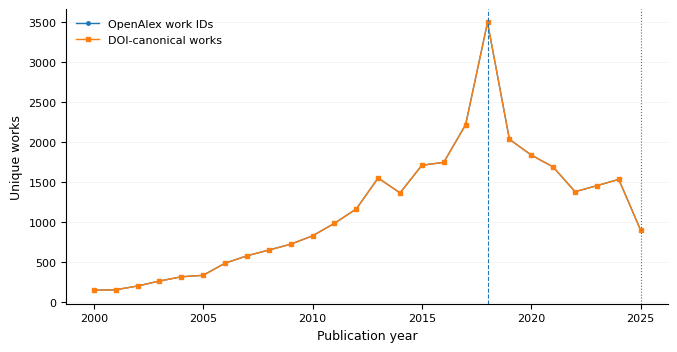


Sheets in main Sucupira workbook: ['BR-CAPES-COLSUCUP-DOCENTE-2022-']

TABLE V — MAIN SUCUPIRA WORKBOOK: TRUE REFERENCE-YEAR SCAN
                                                                                                 file                           sheet reference_year_column  n_unique_years  min_year  max_year  has_2015  has_2020  has_2022 years_preview
/content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/banco-sucupira_docente-PPGCI.xlsx BR-CAPES-COLSUCUP-DOCENTE-2022-               AN_BASE               1      2022      2022         0         0         1          2022


,file,sheet,reference_year_column,n_unique_years,min_year,max_year,has_2015,has_2020,has_2022,years_preview
0,/content/drive/MyDrive/tese_doutoral/runs/run_...,BR-CAPES-COLSUCUP-DOCENTE-2022-,AN_BASE,1,2022,2022,0,0,1,2022



Plausible roster/raw CAPES candidates to scan: 3
[roster scan 01/03] /content/drive/MyDrive/tese_doutoral/input/banco-sucupira_docente-PPGCI.xlsx
[roster scan 02/03] /content/drive/MyDrive/tese_doutoral/runs/run_20260423_173823/input/banco-sucupira_docente-PPGCI (1).xlsx
[roster scan 03/03] /content/drive/MyDrive/tese_doutoral/runs/run_20260423_173823/input/banco-sucupira_docente-PPGCI (2).xlsx

TABLE W — DRIVE REFERENCE-YEAR SCAN
                                                                                                     path                           sheet reference_year_column  n_unique_years  min_year  max_year  has_2015  has_2020  has_2022 years_preview  true_historical_candidate
                             /content/drive/MyDrive/tese_doutoral/input/banco-sucupira_docente-PPGCI.xlsx BR-CAPES-COLSUCUP-DOCENTE-2022-               AN_BASE               1      2022      2022         0         0         1          2022                      False
/content/drive/MyDrive/tese_do

,path,sheet,reference_year_column,n_unique_years,min_year,max_year,has_2015,has_2020,has_2022,years_preview,true_historical_candidate
0,/content/drive/MyDrive/tese_doutoral/input/ban...,BR-CAPES-COLSUCUP-DOCENTE-2022-,AN_BASE,1,2022,2022,0,0,1,2022,False
1,/content/drive/MyDrive/tese_doutoral/runs/run_...,BR-CAPES-COLSUCUP-DOCENTE-2022-,AN_BASE,1,2022,2022,0,0,1,2022,False
2,/content/drive/MyDrive/tese_doutoral/runs/run_...,BR-CAPES-COLSUCUP-DOCENTE-2022-,AN_BASE,1,2022,2022,0,0,1,2022,False



TABLE W2 — TRUE HISTORICAL ROSTER CANDIDATES
(empty)

TABLE X — REVISED COMPLETE 5-YEAR TEMPORAL WINDOWS
         role feature_window  forecast_origin outcome_window  outcome_years  uses_incomplete_2025    status
  development      2010–2014             2014      2015–2019              5                 False candidate
temporal_test      2015–2019             2019      2020–2024              5                 False candidate


,role,feature_window,forecast_origin,outcome_window,outcome_years,uses_incomplete_2025,status
0,development,2010–2014,2014,2015–2019,5,False,candidate
1,temporal_test,2015–2019,2019,2020–2024,5,False,candidate



TABLE Y — CORRECTED PRE-MODELING DECISION GATE
 doi_collision_pct  2018_doi_canonical_collapse_pct  2018_canonical_spike_ratio_vs_2017_2019_mean                        temporal_quality_status                historical_roster_status  ready_to_fit_final_models                                                                                                                                                                                   next_action_temporal                                                                                                                                                                                                                  next_action_cohort
           0.03578                              0.0                                      1.645534 2018_SPIKE_PERSISTS_AFTER_DOI_CANONICALIZATION NO_TRUE_HISTORICAL_ROSTER_FOUND_LOCALLY                      False Do not delete 2018 automatically. Inspect whether the excess is concentrated in a small number of res

,doi_collision_pct,2018_doi_canonical_collapse_pct,2018_canonical_spike_ratio_vs_2017_2019_mean,temporal_quality_status,historical_roster_status,ready_to_fit_final_models,next_action_temporal,next_action_cohort
0,0.03578,0.0,1.645534,2018_SPIKE_PERSISTS_AFTER_DOI_CANONICALIZATION,NO_TRUE_HISTORICAL_ROSTER_FOUND_LOCALLY,False,Do not delete 2018 automatically. Inspect whet...,The local Drive does not contain a verified cu...



FILES SAVED
Tables : /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/04_canonical_roster_forensics/tables
Figures: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/04_canonical_roster_forensics/figures
Notes  : /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/04_canonical_roster_forensics/README_DECISION.txt

SEND THESE BLOCKS NEXT
1) TABLE P — DOI COLLISION SUMMARY
2) TABLE R — ANNUAL RAW VS DOI-CANONICAL WORK COUNTS
3) TABLE S2 — 2018 EXCESS CONCENTRATION
4) TABLE V — MAIN SUCUPIRA WORKBOOK: TRUE REFERENCE-YEAR SCAN
5) TABLE W2 — TRUE HISTORICAL ROSTER CANDIDATES
6) TABLE Y — CORRECTED PRE-MODELING DECISION GATE

DONE.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.4 — CANONICAL WORK AUDIT + 2018 ANOMALY + TRUE HISTORICAL-ROSTER FORENSICS
====================================================================================

This stage deliberately DOES NOT fit predictive models.

Why this stage is necessary
---------------------------
The previous audit produced two findings that must be resolved before modeling:

1) publications.id_openalex is internally consistent as a work identifier, but the annual
   series contains a pronounced 2018 spike and 2025 is clearly incomplete;
2) the previous "historical roster found" flag was a false positive caused by treating
   AN_TITULACAO as if it were a roster reference year. AN_BASE is actually constant at 2022.

This script:
- validates/canonicalizes work identity using DOI collisions and exact title-year checks;
- quantifies whether the 2018 spike is driven by duplicate OpenAlex work IDs, a few authors,
  or broad corpus-wide expansion;
- explicitly marks 2025 as incomplete and proposes complete 5-year rolling windows ending in 2024;
- scans the Drive for TRUE historical roster files using semantic reference-year columns only;
- inspects every sheet of the main Sucupira workbook;
- freezes a defensible cohort-design decision gate;
- prints tables/figures in Colab and saves all outputs to Drive;
- exports figures as EPS + PNG 600 dpi, without embedded titles/captions.

Run in Colab
------------
%run /content/Parte_18_4_Canonical_Work_and_Roster_Forensics.py
"""

from __future__ import annotations

import json
import re
import sys
import math
import hashlib
import unicodedata
import importlib
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Environment is not Colab or Drive unavailable:", repr(e))

# ======================================================================================
# 1. DEPENDENCIES
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("pandas")
ensure("numpy")
ensure("openpyxl")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. PATHS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
BASE_RUN = ROOT / "runs" / "run_20260625_200032"

PUB_PATH = BASE_RUN / "input" / "producoes_final.xlsx"
AUTH_PATH = BASE_RUN / "input" / "autores_final.xlsx"
ROSTER_PATH = BASE_RUN / "input" / "banco-sucupira_docente-PPGCI.xlsx"

OUT = ROOT / "runs" / "temporal_productivity_20260929" / "04_canonical_roster_forensics"
TAB = OUT / "tables"
FIG = OUT / "figures"
AUD = OUT / "audit"

for d in [OUT, TAB, FIG, AUD]:
    d.mkdir(parents=True, exist_ok=True)

for p in [PUB_PATH, AUTH_PATH, ROSTER_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def normalize_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"\s+", " ", s)
    return s

def normalize_title(x):
    s = normalize_text(x)
    s = re.sub(r"[^a-z0-9]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def normalize_doi(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = re.sub(r"^https?://(dx\.)?doi\.org/", "", s)
    s = re.sub(r"^doi:\s*", "", s)
    return s if re.search(r"10\.\d{4,9}/", s) else ""

def show_df(title, df, max_rows=40):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    if df.empty:
        print("(empty)")
    elif len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    if display is not None and not df.empty:
        display(df.head(max_rows))

def infer_col(df, exact=(), contains=()):
    low = {normalize_text(c): c for c in df.columns}
    for e in exact:
        if normalize_text(e) in low:
            return low[normalize_text(e)]
    for c in df.columns:
        n = normalize_text(c)
        if any(normalize_text(t) in n for t in contains):
            return c
    return None

def save_fig(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

def candidate_reference_year_columns(columns):
    """
    STRICT roster-reference-year semantics.
    Explicitly excludes degree/birth years.
    """
    good_tokens = [
        "an_base", "ano_base", "reference_year", "ref_year", "year_ref",
        "ano_referencia", "an_referencia", "ano_coleta", "year"
    ]
    bad_tokens = [
        "titul", "nasc", "birth", "degree", "defesa", "gradu", "ingresso",
        "inicio", "start", "fim", "end"
    ]
    out = []
    for c in columns:
        n = normalize_text(c).replace(" ", "_")
        if any(b in n for b in bad_tokens):
            continue
        if n in good_tokens or "referencia" in n or n.endswith("_base"):
            out.append(c)
    return out

def scan_reference_years_df(df):
    rows = []
    for c in candidate_reference_year_columns(df.columns):
        s = pd.to_numeric(df[c], errors="coerce")
        valid = s.between(1990, 2030)
        if not valid.any():
            continue
        vals = sorted(set(s[valid].astype(int).tolist()))
        rows.append({
            "column": str(c),
            "valid_year_n": int(valid.sum()),
            "n_unique_years": len(vals),
            "min_year": min(vals),
            "max_year": max(vals),
            "has_2015": int(2015 in vals),
            "has_2020": int(2020 in vals),
            "has_2022": int(2022 in vals),
            "years_preview": ",".join(map(str, vals[:25])),
        })
    return pd.DataFrame(rows)

# ======================================================================================
# 4. LOAD
# ======================================================================================

print("\n" + "=" * 120)
print("PARTE 18.4 — CANONICAL WORK AUDIT + TRUE HISTORICAL-ROSTER FORENSICS")
print("=" * 120)
print("[publications]", PUB_PATH)
print("[authors]     ", AUTH_PATH)
print("[roster]      ", ROSTER_PATH)
print("[output]      ", OUT)

pub = pd.read_excel(PUB_PATH)
auth = pd.read_excel(AUTH_PATH)

print(f"\nShapes: publications={pub.shape}; authors={auth.shape}")

# Infer known columns
work_col = infer_col(pub, exact=["id_openalex"])
author_col = infer_col(pub, exact=["autor_id"], contains=["autor_id", "author_id"])
year_col = infer_col(pub, exact=["ano"], contains=["publication_year", "year"])
title_col = infer_col(pub, exact=["titulo"], contains=["title", "titulo"])
doi_col = infer_col(pub, exact=["doi"], contains=["doi"])
type_col = infer_col(pub, exact=["tipo"], contains=["type", "tipo"])

required = {
    "work_col": work_col,
    "author_col": author_col,
    "year_col": year_col,
    "title_col": title_col,
}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise RuntimeError(f"Could not infer required publication columns: {missing}")

# Clean
x = pub.copy()
x["work_id"] = x[work_col].astype(str).str.strip()
x["author_id"] = x[author_col].astype(str).str.strip()
x["year"] = pd.to_numeric(x[year_col], errors="coerce")
x["title_norm"] = x[title_col].map(normalize_title)
x["doi_norm"] = x[doi_col].map(normalize_doi) if doi_col else ""
x["type_norm"] = x[type_col].map(normalize_text) if type_col else ""
x = x[x["year"].between(1900, 2030)].copy()
x["year"] = x["year"].astype(int)

# ======================================================================================
# 5. CROSS-WORK DOI COLLISION AUDIT
# ======================================================================================

doi_x = x[x["doi_norm"].ne("")][["doi_norm", "work_id", "year", "title_norm"]].drop_duplicates()

doi_group = (
    doi_x.groupby("doi_norm")
    .agg(
        n_work_ids=("work_id", "nunique"),
        n_years=("year", "nunique"),
        n_titles=("title_norm", "nunique"),
        min_year=("year", "min"),
        max_year=("year", "max"),
    )
    .reset_index()
)

doi_collisions = doi_group[doi_group["n_work_ids"] > 1].copy()

doi_collision_summary = pd.DataFrame([{
    "unique_dois": int(doi_group["doi_norm"].nunique()),
    "dois_mapping_to_multiple_work_ids": int(len(doi_collisions)),
    "pct_dois_with_multiple_work_ids": float(100 * len(doi_collisions) / max(1, len(doi_group))),
    "max_work_ids_per_doi": int(doi_group["n_work_ids"].max()) if len(doi_group) else 0,
    "collision_groups_inconsistent_year": int((doi_collisions["n_years"] > 1).sum()),
    "collision_groups_inconsistent_title": int((doi_collisions["n_titles"] > 1).sum()),
}])

doi_collision_summary.to_csv(TAB / "Table_P_DOI_collision_summary.csv", index=False)
doi_collisions.to_csv(TAB / "Table_P2_DOI_collision_groups.csv", index=False)

show_df("TABLE P — DOI COLLISION SUMMARY", doi_collision_summary)
show_df("TABLE P2 — DOI COLLISION GROUPS", doi_collisions, max_rows=50)

# ======================================================================================
# 6. EXACT TITLE-YEAR CROSS-WORK COLLISION AUDIT
# ======================================================================================

ty = x[x["title_norm"].ne("")][["title_norm", "year", "work_id", "doi_norm", "type_norm"]].drop_duplicates()

ty_group = (
    ty.groupby(["title_norm", "year"])
    .agg(
        n_work_ids=("work_id", "nunique"),
        n_dois=("doi_norm", lambda s: len(set(v for v in s if v))),
        n_types=("type_norm", "nunique"),
    )
    .reset_index()
)

# Exclude very short/generic titles from any interpretation
ty_group["title_length"] = ty_group["title_norm"].str.len()
ty_collisions = ty_group[
    (ty_group["n_work_ids"] > 1)
    & (ty_group["title_length"] >= 20)
].copy()

ty_summary = pd.DataFrame([{
    "unique_title_year_groups": int(len(ty_group)),
    "title_year_groups_multiple_work_ids_len20plus": int(len(ty_collisions)),
    "pct_title_year_groups_multiple_work_ids_len20plus": float(
        100 * len(ty_collisions) / max(1, (ty_group["title_length"] >= 20).sum())
    ),
    "max_work_ids_same_title_year": int(ty_collisions["n_work_ids"].max()) if len(ty_collisions) else 1,
}])

ty_summary.to_csv(TAB / "Table_Q_title_year_collision_summary.csv", index=False)
ty_collisions.sort_values("n_work_ids", ascending=False).to_csv(
    TAB / "Table_Q2_title_year_collision_groups.csv", index=False
)

show_df("TABLE Q — TITLE-YEAR COLLISION SUMMARY", ty_summary)
show_df(
    "TABLE Q2 — TITLE-YEAR COLLISION GROUPS",
    ty_collisions.sort_values(["n_work_ids", "year"], ascending=[False, True]),
    max_rows=50
)

# ======================================================================================
# 7. CONSERVATIVE CANONICAL WORK KEY
# ======================================================================================

# Primary conservative rule:
# - DOI present -> DOI is canonical
# - otherwise retain OpenAlex Work ID
#
# This only collapses clear DOI-level duplicate work IDs.
x["canonical_work_id"] = np.where(
    x["doi_norm"].ne(""),
    "DOI:" + x["doi_norm"],
    "W:" + x["work_id"].astype(str)
)

canonical_rows = x[["canonical_work_id", "work_id", "author_id", "year", "title_norm", "type_norm", "doi_norm"]].drop_duplicates()

annual_raw = (
    x.groupby("year")
    .agg(
        raw_openalex_works=("work_id", "nunique"),
        active_authors=("author_id", "nunique"),
    )
    .reset_index()
)

annual_can = (
    canonical_rows.groupby("year")
    .agg(
        canonical_works=("canonical_work_id", "nunique"),
    )
    .reset_index()
)

annual = annual_raw.merge(annual_can, on="year", how="outer").sort_values("year")
annual["works_collapsed_by_doi"] = annual["raw_openalex_works"] - annual["canonical_works"]
annual["collapse_pct"] = 100 * annual["works_collapsed_by_doi"] / annual["raw_openalex_works"].clip(lower=1)
annual["yoy_raw"] = annual["raw_openalex_works"] / annual["raw_openalex_works"].shift(1)
annual["yoy_canonical"] = annual["canonical_works"] / annual["canonical_works"].shift(1)

annual.to_csv(TAB / "Table_R_annual_raw_vs_canonical.csv", index=False)
show_df(
    "TABLE R — ANNUAL RAW VS DOI-CANONICAL WORK COUNTS",
    annual[annual["year"].between(2000, 2025)],
    max_rows=40
)

# ======================================================================================
# 8. 2018 ANOMALY — AUTHOR CONCENTRATION
# ======================================================================================

author_year = (
    canonical_rows.groupby(["author_id", "year"])
    .agg(works=("canonical_work_id", "nunique"))
    .reset_index()
)

pivot = author_year[
    author_year["year"].isin([2016, 2017, 2018, 2019, 2020])
].pivot_table(
    index="author_id", columns="year", values="works", fill_value=0, aggfunc="sum"
)

for yr in [2016, 2017, 2018, 2019, 2020]:
    if yr not in pivot.columns:
        pivot[yr] = 0

pivot = pivot[[2016, 2017, 2018, 2019, 2020]].copy()
pivot["neighbor_mean_2017_2019"] = (pivot[2017] + pivot[2019]) / 2.0
pivot["excess_2018_vs_neighbors"] = pivot[2018] - pivot["neighbor_mean_2017_2019"]
pivot["ratio_2018_to_neighbors"] = pivot[2018] / pivot["neighbor_mean_2017_2019"].replace(0, np.nan)

top_2018 = pivot.reset_index().sort_values("excess_2018_vs_neighbors", ascending=False)

positive_excess = top_2018["excess_2018_vs_neighbors"].clip(lower=0)
total_positive_excess = float(positive_excess.sum())

concentration_rows = []
for k in [1, 5, 10, 20, 50, 100]:
    topk = float(positive_excess.nlargest(k).sum())
    concentration_rows.append({
        "top_k_authors": k,
        "share_of_positive_2018_excess_pct": 100 * topk / max(total_positive_excess, 1e-9),
    })

concentration = pd.DataFrame(concentration_rows)

top_2018.head(100).to_csv(TAB / "Table_S_top_authors_2018_excess.csv", index=False)
concentration.to_csv(TAB / "Table_S2_2018_excess_concentration.csv", index=False)

show_df("TABLE S — TOP AUTHORS CONTRIBUTING TO 2018 EXCESS", top_2018.head(30), max_rows=30)
show_df("TABLE S2 — 2018 EXCESS CONCENTRATION", concentration)

# Type comparison, canonical works
canonical_work_once = (
    canonical_rows.sort_values(["canonical_work_id", "year"])
    .drop_duplicates("canonical_work_id")
)

type_year = (
    canonical_work_once[canonical_work_once["year"].between(2016, 2020)]
    .groupby(["year", "type_norm"])
    .agg(unique_works=("canonical_work_id", "nunique"))
    .reset_index()
)

type_year.to_csv(TAB / "Table_T_type_distribution_2016_2020.csv", index=False)
show_df(
    "TABLE T — CANONICAL WORK TYPE DISTRIBUTION 2016–2020",
    type_year.sort_values(["year", "unique_works"], ascending=[True, False]),
    max_rows=100
)

# ======================================================================================
# 9. DOI COVERAGE BY YEAR AFTER CANONICALIZATION
# ======================================================================================

doi_year = (
    canonical_rows.groupby("year")
    .agg(
        author_work_rows=("canonical_work_id", "size"),
        rows_with_doi=("doi_norm", lambda s: int((s != "").sum())),
        unique_works=("canonical_work_id", "nunique"),
        active_authors=("author_id", "nunique"),
    )
    .reset_index()
)

doi_year["doi_present_pct_rows"] = 100 * doi_year["rows_with_doi"] / doi_year["author_work_rows"].clip(lower=1)
doi_year.to_csv(TAB / "Table_U_DOI_coverage_by_year.csv", index=False)
show_df(
    "TABLE U — DOI COVERAGE BY YEAR",
    doi_year[doi_year["year"].between(2010, 2025)],
    max_rows=30
)

# ======================================================================================
# 10. FIGURE — RAW VS CANONICAL TEMPORAL SERIES
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "ps.fonttype": 42,
})

z = annual[annual["year"].between(2000, 2025)].copy()

fig, ax = plt.subplots(figsize=(6.85, 3.6))
ax.plot(z["year"], z["raw_openalex_works"], marker="o", markersize=2.5, linewidth=1.0, label="OpenAlex work IDs")
ax.plot(z["year"], z["canonical_works"], marker="s", markersize=2.3, linewidth=1.0, label="DOI-canonical works")
ax.axvline(2018, linestyle="--", linewidth=0.8)
ax.axvline(2025, linestyle=":", linewidth=0.8)
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique works")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_fig(fig, "Fig_E_raw_vs_canonical_annual_works")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 11. TRUE HISTORICAL ROSTER FORENSICS — ALL SHEETS OF MAIN WORKBOOK
# ======================================================================================

xls = pd.ExcelFile(ROSTER_PATH)
sheet_rows = []

print("\nSheets in main Sucupira workbook:", xls.sheet_names)

for sheet in xls.sheet_names:
    try:
        df_sheet = pd.read_excel(ROSTER_PATH, sheet_name=sheet, nrows=5000)
        scan = scan_reference_years_df(df_sheet)
        if scan.empty:
            sheet_rows.append({
                "file": str(ROSTER_PATH),
                "sheet": sheet,
                "reference_year_column": "",
                "n_unique_years": 0,
                "min_year": np.nan,
                "max_year": np.nan,
                "has_2015": 0,
                "has_2020": 0,
                "has_2022": 0,
                "years_preview": "",
            })
        else:
            for _, r in scan.iterrows():
                sheet_rows.append({
                    "file": str(ROSTER_PATH),
                    "sheet": sheet,
                    "reference_year_column": r["column"],
                    "n_unique_years": int(r["n_unique_years"]),
                    "min_year": int(r["min_year"]),
                    "max_year": int(r["max_year"]),
                    "has_2015": int(r["has_2015"]),
                    "has_2020": int(r["has_2020"]),
                    "has_2022": int(r["has_2022"]),
                    "years_preview": r["years_preview"],
                })
    except Exception as e:
        sheet_rows.append({
            "file": str(ROSTER_PATH),
            "sheet": sheet,
            "reference_year_column": "",
            "n_unique_years": -1,
            "min_year": np.nan,
            "max_year": np.nan,
            "has_2015": 0,
            "has_2020": 0,
            "has_2022": 0,
            "years_preview": f"READ_ERROR: {repr(e)}",
        })

sheet_scan = pd.DataFrame(sheet_rows)
sheet_scan.to_csv(TAB / "Table_V_main_sucupira_all_sheets_reference_year_scan.csv", index=False)
show_df("TABLE V — MAIN SUCUPIRA WORKBOOK: TRUE REFERENCE-YEAR SCAN", sheet_scan, max_rows=100)

# ======================================================================================
# 12. DRIVE SCAN FOR TRUE HISTORICAL ROSTERS
# ======================================================================================

# Restrict to plausible raw/input files, not every result table.
keywords = ("sucupira", "capes", "docente", "professor", "faculty", "roster")
exts = {".xlsx", ".xls", ".csv", ".parquet"}

candidates = []
for p in ROOT.rglob("*"):
    if not p.is_file() or p.suffix.lower() not in exts:
        continue
    name = normalize_text(p.name)
    if not any(k in name for k in keywords):
        continue
    # Avoid output directories created in this temporal project
    if "temporal_productivity_20260929" in str(p):
        continue
    candidates.append(p)

# Deduplicate byte-identical paths by name+size; inspect at most one copy per size/name signature.
unique_candidates = []
seen_sig = set()
for p in sorted(candidates):
    try:
        sig = (p.name.lower(), p.stat().st_size)
    except Exception:
        sig = (p.name.lower(), -1)
    if sig in seen_sig:
        continue
    seen_sig.add(sig)
    unique_candidates.append(p)

print(f"\nPlausible roster/raw CAPES candidates to scan: {len(unique_candidates)}")

drive_scan_rows = []
for i, p in enumerate(unique_candidates, 1):
    print(f"[roster scan {i:02d}/{len(unique_candidates):02d}] {p}")
    try:
        if p.suffix.lower() in {".xlsx", ".xls"}:
            book = pd.ExcelFile(p)
            for sheet in book.sheet_names:
                try:
                    df0 = pd.read_excel(p, sheet_name=sheet, nrows=10000)
                    scan = scan_reference_years_df(df0)
                    if scan.empty:
                        continue
                    for _, r in scan.iterrows():
                        drive_scan_rows.append({
                            "path": str(p),
                            "sheet": sheet,
                            "reference_year_column": r["column"],
                            "n_unique_years": int(r["n_unique_years"]),
                            "min_year": int(r["min_year"]),
                            "max_year": int(r["max_year"]),
                            "has_2015": int(r["has_2015"]),
                            "has_2020": int(r["has_2020"]),
                            "has_2022": int(r["has_2022"]),
                            "years_preview": r["years_preview"],
                        })
                except Exception:
                    pass
        elif p.suffix.lower() == ".csv":
            try:
                df0 = pd.read_csv(p, nrows=10000, low_memory=False)
            except Exception:
                df0 = pd.read_csv(p, sep=";", nrows=10000, low_memory=False)
            scan = scan_reference_years_df(df0)
            for _, r in scan.iterrows():
                drive_scan_rows.append({
                    "path": str(p),
                    "sheet": "",
                    "reference_year_column": r["column"],
                    "n_unique_years": int(r["n_unique_years"]),
                    "min_year": int(r["min_year"]),
                    "max_year": int(r["max_year"]),
                    "has_2015": int(r["has_2015"]),
                    "has_2020": int(r["has_2020"]),
                    "has_2022": int(r["has_2022"]),
                    "years_preview": r["years_preview"],
                })
        elif p.suffix.lower() == ".parquet":
            df0 = pd.read_parquet(p).head(10000)
            scan = scan_reference_years_df(df0)
            for _, r in scan.iterrows():
                drive_scan_rows.append({
                    "path": str(p),
                    "sheet": "",
                    "reference_year_column": r["column"],
                    "n_unique_years": int(r["n_unique_years"]),
                    "min_year": int(r["min_year"]),
                    "max_year": int(r["max_year"]),
                    "has_2015": int(r["has_2015"]),
                    "has_2020": int(r["has_2020"]),
                    "has_2022": int(r["has_2022"]),
                    "years_preview": r["years_preview"],
                })
    except Exception:
        pass

drive_scan = pd.DataFrame(drive_scan_rows)

if drive_scan.empty:
    true_historical = pd.DataFrame()
else:
    drive_scan["true_historical_candidate"] = (
        (drive_scan["n_unique_years"] >= 2)
        & ((drive_scan["has_2015"] == 1) | (drive_scan["has_2020"] == 1))
    )
    true_historical = drive_scan[drive_scan["true_historical_candidate"]].copy()

drive_scan.to_csv(TAB / "Table_W_drive_reference_year_scan.csv", index=False)
true_historical.to_csv(TAB / "Table_W2_true_historical_roster_candidates.csv", index=False)

show_df("TABLE W — DRIVE REFERENCE-YEAR SCAN", drive_scan, max_rows=100)
show_df("TABLE W2 — TRUE HISTORICAL ROSTER CANDIDATES", true_historical, max_rows=100)

# ======================================================================================
# 13. TEMPORAL WINDOW POLICY
# ======================================================================================

# 2025 is known incomplete. Use complete rolling 5-year windows ending in 2024.
windows = pd.DataFrame([
    {
        "role": "development",
        "feature_window": "2010–2014",
        "forecast_origin": 2014,
        "outcome_window": "2015–2019",
        "outcome_years": 5,
        "uses_incomplete_2025": False,
        "status": "candidate",
    },
    {
        "role": "temporal_test",
        "feature_window": "2015–2019",
        "forecast_origin": 2019,
        "outcome_window": "2020–2024",
        "outcome_years": 5,
        "uses_incomplete_2025": False,
        "status": "candidate",
    },
])

windows.to_csv(TAB / "Table_X_revised_complete_temporal_windows.csv", index=False)
show_df("TABLE X — REVISED COMPLETE 5-YEAR TEMPORAL WINDOWS", windows)

# ======================================================================================
# 14. DECISION GATE
# ======================================================================================

doi_collision_pct = float(doi_collision_summary.iloc[0]["pct_dois_with_multiple_work_ids"])
collapse_2018 = annual.loc[annual["year"] == 2018, "collapse_pct"]
collapse_2018 = float(collapse_2018.iloc[0]) if len(collapse_2018) else np.nan

# Is 2018 still anomalous after canonicalization?
can2017 = annual.loc[annual["year"] == 2017, "canonical_works"]
can2018 = annual.loc[annual["year"] == 2018, "canonical_works"]
can2019 = annual.loc[annual["year"] == 2019, "canonical_works"]
if len(can2017) and len(can2018) and len(can2019):
    neighbor = (float(can2017.iloc[0]) + float(can2019.iloc[0])) / 2.0
    spike_ratio = float(can2018.iloc[0]) / max(neighbor, 1e-9)
else:
    spike_ratio = np.nan

historical_found = not true_historical.empty

if historical_found:
    cohort_status = "TRUE_HISTORICAL_ROSTER_CANDIDATE_FOUND"
    cohort_action = (
        "Inspect and link the identified historical roster(s) before modeling. "
        "Do not use AN_TITULACAO as a roster year."
    )
else:
    cohort_status = "NO_TRUE_HISTORICAL_ROSTER_FOUND_LOCALLY"
    cohort_action = (
        "The local Drive does not contain a verified cutoff-specific roster. "
        "For the paper, either acquire historical CAPES/Sucupira rosters or explicitly use "
        "a fixed 2022-defined retrospective cohort and frame the estimand accordingly."
    )

if np.isfinite(spike_ratio) and spike_ratio >= 1.35:
    temporal_status = "2018_SPIKE_PERSISTS_AFTER_DOI_CANONICALIZATION"
    temporal_action = (
        "Do not delete 2018 automatically. Inspect whether the excess is concentrated in a small number "
        "of researchers or is corpus-wide; report this data-source discontinuity and run a sensitivity analysis."
    )
else:
    temporal_status = "2018_SPIKE_SUBSTANTIALLY_EXPLAINED_OR_MODERATE"
    temporal_action = (
        "Proceed with complete 5-year windows and retain a temporal-quality sensitivity analysis."
    )

decision = pd.DataFrame([{
    "doi_collision_pct": doi_collision_pct,
    "2018_doi_canonical_collapse_pct": collapse_2018,
    "2018_canonical_spike_ratio_vs_2017_2019_mean": spike_ratio,
    "temporal_quality_status": temporal_status,
    "historical_roster_status": cohort_status,
    "ready_to_fit_final_models": False,
    "next_action_temporal": temporal_action,
    "next_action_cohort": cohort_action,
}])

decision.to_csv(TAB / "Table_Y_pre_modeling_decision_gate_corrected.csv", index=False)
show_df("TABLE Y — CORRECTED PRE-MODELING DECISION GATE", decision)

# ======================================================================================
# 15. SAVE AUDIT NOTES
# ======================================================================================

notes = f"""
PARTE 18.4 — DECISION NOTES
===========================

Important correction
--------------------
The prior Part 18.3 pre-modeling gate incorrectly treated AN_TITULACAO as evidence of
historical roster years. AN_TITULACAO is a degree/qualification year, not the CAPES roster
reference year. AN_BASE in the main Sucupira file is 2022.

Therefore, the earlier flag:
    historical_roster_found_in_drive_scan = True
must NOT be used as evidence that 2015/2020 rosters exist.

Publication identity
--------------------
Primary OpenAlex work identifier column:
    {work_col}

Author identifier:
    {author_col}

Year:
    {year_col}

DOI:
    {doi_col}

2018 temporal status
--------------------
{temporal_status}

Canonical 2018 spike ratio relative to the mean of 2017 and 2019:
    {spike_ratio:.4f}

Historical roster status
------------------------
{cohort_status}

Recommended cohort action
-------------------------
{cohort_action}

Revised temporal windows
------------------------
Development:
    2010–2014 features -> 2015–2019 productivity

Temporal test:
    2015–2019 features -> 2020–2024 productivity

Reason:
    2025 is incomplete in the current OpenAlex extract and must not be part of the primary outcome.

No predictive model should be treated as final until cohort ascertainment is frozen and the
2018 anomaly is characterized.
""".strip()

(OUT / "README_DECISION.txt").write_text(notes, encoding="utf-8")

print("\n" + "=" * 120)
print("FILES SAVED")
print("=" * 120)
print("Tables :", TAB)
print("Figures:", FIG)
print("Notes  :", OUT / "README_DECISION.txt")

print("\n" + "=" * 120)
print("SEND THESE BLOCKS NEXT")
print("=" * 120)
print("1) TABLE P — DOI COLLISION SUMMARY")
print("2) TABLE R — ANNUAL RAW VS DOI-CANONICAL WORK COUNTS")
print("3) TABLE S2 — 2018 EXCESS CONCENTRATION")
print("4) TABLE V — MAIN SUCUPIRA WORKBOOK: TRUE REFERENCE-YEAR SCAN")
print("5) TABLE W2 — TRUE HISTORICAL ROSTER CANDIDATES")
print("6) TABLE Y — CORRECTED PRE-MODELING DECISION GATE")

print("\nDONE.")


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.5 — HISTORICAL CAPES ROSTERS + SURVIVORSHIP AUDIT + CAPES PRODUCTION BANK LOCATOR
==========================================================================================

Purpose
-------
Resolve the key pre-modeling issue identified in Part 18.4:

1) Download official CAPES/Sucupira faculty rosters for the two forecast origins:
      2014 -> forecast 2015–2019
      2019 -> forecast 2020–2024
2) Identify Information Science graduate-program faculty in each historical roster.
3) Quantify how much of each historical cohort is represented in the current
   2022-resolved OpenAlex author set.
4) Explicitly measure survivorship / cohort-ascertainment loss.
5) Search the Drive for the user's larger CAPES production bank so that the
   anomalous 2018 OpenAlex spike can be externally audited against CAPES records.
6) Do NOT fit predictive models yet.
7) Print manuscript/audit tables in Colab and save all outputs to Drive.

Official CAPES resources used
-----------------------------
2014 faculty roster:
https://dadosabertos.capes.gov.br/dataset/35eab2f8-5a64-4619-b3f1-63a2e6690cfa/resource/c2a78638-479d-4e7e-866e-633238511647/download/br-capes-colsucup-docente-2014-2023-08-01.xlsx

2019 faculty roster:
https://dadosabertos.capes.gov.br/dataset/57f86b23-e751-4834-8537-e9d33bd608b6/resource/57469ecf-c018-4ed1-b68e-06cec87599a8/download/br-capes-colsucup-docente-2019-2021-11-10.csv

Run in Colab
------------
%run /content/Parte_18_5_Historical_CAPES_Rosters.py
"""

from __future__ import annotations

import os
import re
import sys
import json
import math
import unicodedata
import importlib
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Non-Colab environment or Drive unavailable:", repr(e))

# ======================================================================================
# 1. DEPENDENCIES
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("pandas")
ensure("numpy")
ensure("openpyxl")
ensure("requests")

import numpy as np
import pandas as pd
import requests

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. PATHS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
BASE_RUN = ROOT / "runs" / "run_20260625_200032"
TEMP_RUN = ROOT / "runs" / "temporal_productivity_20260929"

AUTH_PATH = BASE_RUN / "input" / "autores_final.xlsx"
ROSTER_2022_PATH = BASE_RUN / "input" / "banco-sucupira_docente-PPGCI.xlsx"

OUT = TEMP_RUN / "05_historical_capes_rosters"
RAW = OUT / "raw_official_capes"
TAB = OUT / "tables"
NOTES = OUT / "notes"

for d in [OUT, RAW, TAB, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

URL_2014 = (
    "https://dadosabertos.capes.gov.br/dataset/"
    "35eab2f8-5a64-4619-b3f1-63a2e6690cfa/resource/"
    "c2a78638-479d-4e7e-866e-633238511647/download/"
    "br-capes-colsucup-docente-2014-2023-08-01.xlsx"
)
URL_2019 = (
    "https://dadosabertos.capes.gov.br/dataset/"
    "57f86b23-e751-4834-8537-e9d33bd608b6/resource/"
    "57469ecf-c018-4ed1-b68e-06cec87599a8/download/"
    "br-capes-colsucup-docente-2019-2021-11-10.csv"
)

F2014 = RAW / "BR-CAPES-COLSUCUP-DOCENTE-2014.xlsx"
F2019 = RAW / "BR-CAPES-COLSUCUP-DOCENTE-2019.csv"

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def norm(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(x):
    s = norm(x)
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def show_df(title, df, max_rows=40):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    if df.empty:
        print("(empty)")
    elif len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    if display is not None and not df.empty:
        display(df.head(max_rows))

def download(url, path):
    if path.exists() and path.stat().st_size > 1000:
        print(f"[download] already exists: {path}")
        return
    print(f"[download] {url}")
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    path.write_bytes(r.content)
    print(f"[saved] {path} ({path.stat().st_size/1024/1024:.2f} MB)")

def read_csv_robust(path):
    attempts = []
    for enc in ["utf-8", "utf-8-sig", "latin1", "cp1252"]:
        for sep in [";", ",", "\t", "|"]:
            try:
                df = pd.read_csv(path, encoding=enc, sep=sep, low_memory=False)
                attempts.append((enc, sep, df.shape[1]))
                if df.shape[1] >= 5:
                    return df, {"encoding": enc, "sep": sep}
            except Exception:
                pass
    raise RuntimeError(f"Could not parse CSV: {path}; attempts={attempts[:10]}")

def schema(df, label):
    return pd.DataFrame({
        "dataset": label,
        "column": [str(c) for c in df.columns],
        "dtype": [str(df[c].dtype) for c in df.columns],
        "non_missing": [int(df[c].notna().sum()) for c in df.columns],
        "n_unique": [int(df[c].nunique(dropna=True)) for c in df.columns],
    })

def detect_column(df, exact_candidates=None, contains_candidates=None):
    exact_candidates = exact_candidates or []
    contains_candidates = contains_candidates or []
    low = {norm(c): c for c in df.columns}

    for cand in exact_candidates:
        if norm(cand) in low:
            return str(low[norm(cand)])

    scored = []
    for c in df.columns:
        nc = norm(c)
        score = sum(1 for x in contains_candidates if norm(x) in nc)
        if score:
            scored.append((score, len(nc), c))
    if scored:
        scored.sort(key=lambda x: (-x[0], x[1]))
        return str(scored[0][2])
    return None

def detect_program_code(df):
    return detect_column(
        df,
        exact_candidates=[
            "CD_PROGRAMA_IES",
            "CD_PROGRAMA",
            "COD_PROGRAMA_IES",
            "CODIGO_PROGRAMA_IES",
        ],
        contains_candidates=["programa", "cod", "cd_"]
    )

def detect_program_name(df):
    return detect_column(
        df,
        exact_candidates=[
            "NM_PROGRAMA_IES", "NM_PROGRAMA", "NOME_PROGRAMA_IES", "NOME_PROGRAMA"
        ],
        contains_candidates=["programa", "nome", "nm_"]
    )

def detect_person_name(df):
    # Try known CAPES fields first
    col = detect_column(
        df,
        exact_candidates=[
            "NM_DOCENTE", "NM_PESSOA", "NOME_DOCENTE", "NOME_PESSOA",
            "nome", "nome_docente"
        ],
        contains_candidates=["docente", "nome"]
    )
    return col

def detect_area_columns(df):
    rows = []
    for c in df.columns:
        nc = norm(c)
        if any(k in nc for k in ["area", "conhecimento", "avaliacao"]):
            rows.append(str(c))
    return rows

def infer_author_resolved_name_col(auth):
    candidates = []
    for c in auth.columns:
        nc = norm(c)
        if any(k in nc for k in ["nome", "name", "autor", "author"]):
            ser = auth[c].dropna().astype(str)
            if len(ser):
                score = float(ser.str.contains(r"\s", regex=True).mean())
                candidates.append((score, c))
    if not candidates:
        return None
    candidates.sort(reverse=True, key=lambda x: x[0])
    return str(candidates[0][1])

def infer_author_openalex_col(auth):
    best = None
    for c in auth.columns:
        s = auth[c].dropna().astype(str).str.strip()
        if len(s) == 0:
            continue
        share = float(s.str.contains(r"(?:openalex\.org/)?A\d+$", regex=True, case=False).mean())
        if best is None or share > best[0]:
            best = (share, c)
    if best and best[0] > 0.5:
        return str(best[1])
    return None

def clean_openalex_author_id(x):
    s = str(x).strip()
    m = re.search(r"(A\d+)$", s, flags=re.I)
    return m.group(1).upper() if m else s

def historical_ppgci_filter(hist, current_2022):
    """
    Two parallel definitions are produced:
    A) program-code continuity with the 2022 PPGCI file
    B) textual Information Science heuristic in area/program fields
    Their union is used only as an audit candidate, not silently as ground truth.
    """
    h_code = detect_program_code(hist)
    c_code = detect_program_code(current_2022)
    h_prog = detect_program_name(hist)
    area_cols = detect_area_columns(hist)

    by_code = pd.Series(False, index=hist.index)
    current_codes = set()

    if h_code and c_code:
        current_codes = set(
            current_2022[c_code]
            .dropna()
            .astype(str)
            .str.strip()
        )
        by_code = hist[h_code].astype(str).str.strip().isin(current_codes)

    text_cols = []
    if h_prog:
        text_cols.append(h_prog)
    text_cols += [c for c in area_cols if c not in text_cols]

    by_text = pd.Series(False, index=hist.index)
    if text_cols:
        txt = pd.Series("", index=hist.index, dtype="object")
        for c in text_cols:
            txt = txt + " " + hist[c].fillna("").astype(str).map(norm)

        # conservative terms directly tied to Information Science / Librarianship
        patterns = [
            "ciencia da informacao",
            "biblioteconomia",
            "gestao da informacao",
            "informacao e conhecimento",
            "memoria social e patrimonio",  # retained for audit; inspect manually
        ]
        patt = "|".join(re.escape(x) for x in patterns)
        by_text = txt.str.contains(patt, regex=True, na=False)

    audit = {
        "historical_program_code_col": h_code,
        "current_program_code_col": c_code,
        "historical_program_name_col": h_prog,
        "historical_area_cols": " | ".join(area_cols),
        "n_current_2022_program_codes": len(current_codes),
        "n_rows_code_match": int(by_code.sum()),
        "n_rows_text_match": int(by_text.sum()),
        "n_rows_union": int((by_code | by_text).sum()),
    }

    out = hist[by_code | by_text].copy()
    out["_matched_by_program_code"] = by_code.loc[out.index].astype(int)
    out["_matched_by_text"] = by_text.loc[out.index].astype(int)
    return out, audit

def unique_names(df, col):
    if col is None:
        return set()
    s = df[col].dropna().map(norm_name)
    return set(x for x in s if x)

# ======================================================================================
# 4. DOWNLOAD OFFICIAL HISTORICAL ROSTERS
# ======================================================================================

print("\n" + "=" * 120)
print("PARTE 18.5 — HISTORICAL CAPES ROSTERS + SURVIVORSHIP AUDIT")
print("=" * 120)

download(URL_2014, F2014)
download(URL_2019, F2019)

hist2014 = pd.read_excel(F2014)
hist2019, csv_meta_2019 = read_csv_robust(F2019)
auth = pd.read_excel(AUTH_PATH)
roster2022 = pd.read_excel(ROSTER_2022_PATH)

print("\nShapes:")
print("2014 official roster:", hist2014.shape)
print("2019 official roster:", hist2019.shape, csv_meta_2019)
print("2022 PPGCI roster   :", roster2022.shape)
print("resolved authors    :", auth.shape)

# ======================================================================================
# 5. SCHEMA AUDIT
# ======================================================================================

schema_all = pd.concat([
    schema(hist2014, "CAPES_2014"),
    schema(hist2019, "CAPES_2019"),
    schema(roster2022, "PPGCI_2022"),
    schema(auth, "resolved_authors_2022"),
], ignore_index=True)

schema_all.to_csv(TAB / "Table_Z1_historical_roster_schema.csv", index=False)
show_df("TABLE Z1 — HISTORICAL ROSTER SCHEMA", schema_all, max_rows=160)

# ======================================================================================
# 6. PPGCI CANDIDATE FILTERING
# ======================================================================================

h14, audit14 = historical_ppgci_filter(hist2014, roster2022)
h19, audit19 = historical_ppgci_filter(hist2019, roster2022)

filter_audit = pd.DataFrame([
    {"year": 2014, **audit14},
    {"year": 2019, **audit19},
])
filter_audit.to_csv(TAB / "Table_Z2_ppgci_filter_audit.csv", index=False)
show_df("TABLE Z2 — PPGCI HISTORICAL FILTER AUDIT", filter_audit)

# ======================================================================================
# 7. NAME LINKAGE TO CURRENT RESOLVED OPENALEX SET
# ======================================================================================

auth_name_col = infer_author_resolved_name_col(auth)
auth_oa_col = infer_author_openalex_col(auth)

if auth_name_col is None:
    raise RuntimeError("Could not infer name column in autores_final.xlsx")

resolved_map = auth[[auth_name_col] + ([auth_oa_col] if auth_oa_col else [])].copy()
resolved_map["_name_norm"] = resolved_map[auth_name_col].map(norm_name)
resolved_map = resolved_map[resolved_map["_name_norm"].ne("")]

# Ambiguous current names are excluded from exact-name linking
counts = resolved_map["_name_norm"].value_counts()
resolved_map["_name_is_unique"] = resolved_map["_name_norm"].map(counts).eq(1)

if auth_oa_col:
    resolved_map["_openalex_author_id"] = resolved_map[auth_oa_col].map(clean_openalex_author_id)
else:
    resolved_map["_openalex_author_id"] = ""

unique_resolved_map = resolved_map[resolved_map["_name_is_unique"]].drop_duplicates("_name_norm")
name_to_oa = dict(zip(unique_resolved_map["_name_norm"], unique_resolved_map["_openalex_author_id"]))

linkage_rows = []
historical_candidate_tables = {}

for year, h in [(2014, h14), (2019, h19)]:
    name_col = detect_person_name(h)
    if name_col is None:
        raise RuntimeError(f"Could not infer historical faculty name column for {year}")

    x = h.copy()
    x["_name_norm"] = x[name_col].map(norm_name)

    historical_names = set(x["_name_norm"]) - {""}
    matched_names = historical_names & set(name_to_oa)
    unmatched_names = historical_names - set(name_to_oa)

    x["_matched_to_2022_resolved"] = x["_name_norm"].isin(matched_names).astype(int)
    x["_openalex_author_id_from_2022_resolution"] = x["_name_norm"].map(name_to_oa)

    x.to_csv(TAB / f"historical_ppgci_candidate_roster_{year}.csv", index=False)
    historical_candidate_tables[year] = x

    unmatched_df = (
        x.loc[x["_name_norm"].isin(unmatched_names), [name_col, "_name_norm"]]
        .drop_duplicates("_name_norm")
        .sort_values(name_col)
    )
    unmatched_df.to_csv(TAB / f"historical_unmatched_faculty_{year}.csv", index=False)

    linkage_rows.append({
        "year": year,
        "historical_faculty_unique_names": len(historical_names),
        "matched_to_current_2022_resolved_set": len(matched_names),
        "unmatched_historical_faculty": len(unmatched_names),
        "historical_match_pct": 100 * len(matched_names) / max(1, len(historical_names)),
        "historical_name_column": name_col,
        "resolved_name_column": auth_name_col,
        "resolved_openalex_column": auth_oa_col or "",
    })

linkage = pd.DataFrame(linkage_rows)
linkage.to_csv(TAB / "Table_Z3_historical_to_current_resolved_linkage.csv", index=False)
show_df("TABLE Z3 — HISTORICAL TO CURRENT RESOLVED LINKAGE", linkage)

# ======================================================================================
# 8. SURVIVORSHIP / COHORT-ASSESSMENT DECISION
# ======================================================================================

min_match = float(linkage["historical_match_pct"].min()) if len(linkage) else 0.0

if min_match >= 95:
    status = "LOW_BUT_NONZERO_SURVIVORSHIP_RISK"
    ready = False
    next_action = (
        "Historical rosters are now available, but even a high overlap does not establish a complete historical cohort. "
        "Resolve the remaining historical-only faculty to OpenAlex before fitting the final models, or explicitly define "
        "the estimand as restricted to later-observed 2022 faculty."
    )
elif min_match >= 80:
    status = "MODERATE_SURVIVORSHIP_RISK"
    ready = False
    next_action = (
        "A material fraction of historical faculty is absent from the 2022-resolved author set. "
        "Perform historical entity resolution for unmatched faculty before final modeling."
    )
else:
    status = "HIGH_SURVIVORSHIP_RISK"
    ready = False
    next_action = (
        "The historical population differs substantially from the 2022-resolved cohort. "
        "Do not make field-level prospective prediction claims until historical-only faculty are resolved to OpenAlex."
    )

decision = pd.DataFrame([{
    "historical_rosters_obtained": True,
    "historical_years": "2014 | 2019",
    "minimum_historical_match_pct_to_2022_resolved": min_match,
    "survivorship_status": status,
    "ready_to_fit_final_models": ready,
    "next_action": next_action,
}])

decision.to_csv(TAB / "Table_Z4_historical_cohort_decision_gate.csv", index=False)
show_df("TABLE Z4 — HISTORICAL COHORT DECISION GATE", decision)

# ======================================================================================
# 9. LOCATE LARGE CAPES PRODUCTION BANK ON DRIVE
# ======================================================================================

print("\nScanning Drive filenames for CAPES/Sucupira production-bank candidates...")

allowed_ext = {
    ".csv", ".xlsx", ".xls", ".parquet", ".zip", ".gz",
    ".7z", ".rar", ".json", ".jsonl"
}

keywords = [
    "producao", "produção", "producoes", "produções",
    "intelectual", "capes", "sucupira", "coleta",
    "bibliograf", "publicacao", "publicação"
]

candidate_rows = []

for p in ROOT.rglob("*"):
    try:
        if not p.is_file() or p.suffix.lower() not in allowed_ext:
            continue
        name_n = norm(p.name)
        score = sum(1 for k in keywords if norm(k) in name_n)
        if score == 0:
            continue

        size_mb = p.stat().st_size / (1024 * 1024)

        candidate_rows.append({
            "name": p.name,
            "ext": p.suffix.lower(),
            "size_mb": size_mb,
            "keyword_score": score,
            "path": str(p),
        })
    except Exception:
        pass

prod_candidates = pd.DataFrame(candidate_rows)

if not prod_candidates.empty:
    prod_candidates = prod_candidates.sort_values(
        ["keyword_score", "size_mb"],
        ascending=[False, False]
    ).reset_index(drop=True)

prod_candidates.to_csv(TAB / "Table_Z5_capes_production_bank_candidates.csv", index=False)
show_df("TABLE Z5 — CAPES PRODUCTION BANK CANDIDATES", prod_candidates, max_rows=60)

# ======================================================================================
# 10. MANUSCRIPT INTERPRETATION NOTE
# ======================================================================================

note = f"""
PART 18.5 — INTERPRETATION
==========================

Official CAPES historical faculty rosters were downloaded for 2014 and 2019.

The current OpenAlex-resolved author set was originally constructed from the 2022
PPGCI roster. Therefore, exact-name overlap between the historical rosters and the
2022-resolved set is an audit of survivorship / cohort-ascertainment, not proof that
the historical cohort has been fully reconstructed.

Historical linkage summary
--------------------------
{linkage.to_string(index=False)}

Decision
--------
Status: {status}

{next_action}

2018 discontinuity
------------------
The 2018 OpenAlex publication spike should not be deleted automatically. DOI
canonicalization already showed that it is not caused by duplicate OpenAlex work IDs
sharing the same DOI. The next audit should compare yearly OpenAlex output against
the user's larger CAPES/Sucupira production bank. If CAPES does not reproduce the
2018 discontinuity, the paper should treat 2018 as a source-specific coverage artifact
and report a pre-specified sensitivity analysis excluding or down-weighting the affected
year rather than silently correcting the data.

Primary forecasting windows remain:
- Development: features 2010–2014 -> publications 2015–2019
- Temporal test: features 2015–2019 -> publications 2020–2024

These windows deliberately avoid incomplete 2025 outcome data.
""".strip()

(NOTES / "README_DECISION.txt").write_text(note, encoding="utf-8")

print("\n" + "=" * 120)
print("FILES SAVED")
print("=" * 120)
print("Official CAPES raw files:", RAW)
print("Tables:", TAB)
print("Decision note:", NOTES / "README_DECISION.txt")

print("\n" + "=" * 120)
print("SEND THESE BLOCKS NEXT")
print("=" * 120)
print("1) TABLE Z2 — PPGCI HISTORICAL FILTER AUDIT")
print("2) TABLE Z3 — HISTORICAL TO CURRENT RESOLVED LINKAGE")
print("3) TABLE Z4 — HISTORICAL COHORT DECISION GATE")
print("4) TABLE Z5 — CAPES PRODUCTION BANK CANDIDATES")

print("\nDONE.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.5 — HISTORICAL CAPES ROSTERS + SURVIVORSHIP AUDIT
[download] https://dadosabertos.capes.gov.br/dataset/35eab2f8-5a64-4619-b3f1-63a2e6690cfa/resource/c2a78638-479d-4e7e-866e-633238511647/download/br-capes-colsucup-docente-2014-2023-08-01.xlsx
[saved] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/05_historical_capes_rosters/raw_official_capes/BR-CAPES-COLSUCUP-DOCENTE-2014.xlsx (14.15 MB)
[download] https://dadosabertos.capes.gov.br/dataset/57f86b23-e751-4834-8537-e9d33bd608b6/resource/57469ecf-c018-4ed1-b68e-06cec87599a8/download/br-capes-colsucup-docente-2019-2021-11-10.csv
[saved] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/05_historical_capes_rosters/raw_official_capes/BR-CAPES-COLSUCUP-DOCENTE-2019.csv (47.11 MB)


/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



Shapes:
2014 official roster: (85650, 42)
2019 official roster: (108346, 41) {'encoding': 'latin1', 'sep': ';'}
2022 PPGCI roster   : (109533, 45)
resolved authors    : (543, 7)

TABLE Z1 — HISTORICAL ROSTER SCHEMA
              dataset                        column   dtype  non_missing  n_unique
           CAPES_2014                       AN_BASE   int64        85650         1
           CAPES_2014             CD_AREA_AVALIACAO   int64        85650        49
           CAPES_2014             NM_AREA_AVALIACAO  object        85650        54
           CAPES_2014   NM_GRANDE_AREA_CONHECIMENTO  object        85650         9
           CAPES_2014          NM_AREA_CONHECIMENTO  object        85650       277
           CAPES_2014               CD_PROGRAMA_IES  object        85650      3765
           CAPES_2014               NM_PROGRAMA_IES  object        85650      1626
           CAPES_2014              NM_GRAU_PROGRAMA  object        85650         4
           CAPES_2014        NM_MODAL

,dataset,column,dtype,non_missing,n_unique
0,CAPES_2014,AN_BASE,int64,85650,1
1,CAPES_2014,CD_AREA_AVALIACAO,int64,85650,49
2,CAPES_2014,NM_AREA_AVALIACAO,object,85650,54
3,CAPES_2014,NM_GRANDE_AREA_CONHECIMENTO,object,85650,9
4,CAPES_2014,NM_AREA_CONHECIMENTO,object,85650,277
...,...,...,...,...,...
130,resolved_authors_2022,nome_openalex,object,535,500
131,resolved_authors_2022,instituicao_openalex,float64,0,0
132,resolved_authors_2022,id_openalex,object,535,500
133,resolved_authors_2022,total_publicacoes,float64,535,176



TABLE Z2 — PPGCI HISTORICAL FILTER AUDIT
 year historical_program_code_col current_program_code_col historical_program_name_col                                                                                                                             historical_area_cols  n_current_2022_program_codes  n_rows_code_match  n_rows_text_match  n_rows_union
 2014             CD_PROGRAMA_IES          CD_PROGRAMA_IES             NM_PROGRAMA_IES CD_AREA_AVALIACAO | NM_AREA_AVALIACAO | NM_GRANDE_AREA_CONHECIMENTO | NM_AREA_CONHECIMENTO | CD_AREA_BASICA_TITULACAO | NM_AREA_BASICA_TITULACAO                          4593                  0                 32            32
 2019             CD_PROGRAMA_IES          CD_PROGRAMA_IES             NM_PROGRAMA_IES CD_AREA_AVALIACAO | NM_AREA_AVALIACAO | NM_GRANDE_AREA_CONHECIMENTO | NM_AREA_CONHECIMENTO | CD_AREA_BASICA_TITULACAO | NM_AREA_BASICA_TITULACAO                          4593             105828                690        105832


...


TABLE Z4 — HISTORICAL COHORT DECISION GATE
 historical_rosters_obtained historical_years  minimum_historical_match_pct_to_2022_resolved    survivorship_status  ready_to_fit_final_models                                                                                                                                                                                  next_action
                        True      2014 | 2019                                            0.0 HIGH_SURVIVORSHIP_RISK                      False The historical population differs substantially from the 2022-resolved cohort. Do not make field-level prospective prediction claims until historical-only faculty are resolved to OpenAlex.


,historical_rosters_obtained,historical_years,minimum_historical_match_pct_to_2022_resolved,survivorship_status,ready_to_fit_final_models,next_action
0,True,2014 | 2019,0.0,HIGH_SURVIVORSHIP_RISK,False,The historical population differs substantiall...



Scanning Drive filenames for CAPES/Sucupira production-bank candidates...

TABLE Z5 — CAPES PRODUCTION BANK CANDIDATES
                                                           name   ext   size_mb  keyword_score                                                                                                                                                                   path
                                             producoes_norm.csv  .csv 12.563931              2                                                                                                   /content/drive/MyDrive/tese_doutoral/intermediate/producoes_norm.csv
                                           producoes_final.xlsx .xlsx  4.516568              2                                                                                                        /content/drive/MyDrive/tese_doutoral/input/producoes_final.xlsx
                                           producoes_final.xlsx .xlsx  4.516568              2

,name,ext,size_mb,keyword_score,path
0,producoes_norm.csv,.csv,12.563931,2,/content/drive/MyDrive/tese_doutoral/intermedi...
1,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/input/pro...
2,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
3,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
4,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
5,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
6,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
7,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
8,producoes_final (1).xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...
9,producoes_final.xlsx,.xlsx,4.516568,2,/content/drive/MyDrive/tese_doutoral/runs/run_...



FILES SAVED
Official CAPES raw files: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/05_historical_capes_rosters/raw_official_capes
Tables: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/05_historical_capes_rosters/tables
Decision note: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/05_historical_capes_rosters/notes/README_DECISION.txt

SEND THESE BLOCKS NEXT
1) TABLE Z2 — PPGCI HISTORICAL FILTER AUDIT
2) TABLE Z3 — HISTORICAL TO CURRENT RESOLVED LINKAGE
3) TABLE Z4 — HISTORICAL COHORT DECISION GATE
4) TABLE Z5 — CAPES PRODUCTION BANK CANDIDATES

DONE.


Google Drive já está montado em /content/drive.

PARTE 18.6 v2 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[authors]      /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2

Shapes: publications=(38138, 9); authors=(543, 7)

TABLE 0 — RAW IDENTIFIER AUDIT
     dataset               column  non_missing  unique                                                                                                                                                                                                                                                                                                                                                                                                                                             

,dataset,column,non_missing,unique,sample_values,openalex_A_extractable,openalex_W_extractable
0,authors,nome_openalex,535,500,Alegria Benchimol | Patrícia Andréa do Prado R...,0,0
1,authors,instituicao_openalex,0,0,,0,0
2,authors,id_openalex,535,500,https://openalex.org/A5074151918 | https://ope...,535,0
3,publications,autores,38138,19792,"Valdenise César Garcia, Franciele Marques Redí...",0,0
4,publications,id_openalex,38138,30503,https://openalex.org/W2893568697 | https://ope...,0,38138
5,publications,autor_id,38138,499,https://openalex.org/A5074151918 | https://ope...,38138,0



TABLE 1 — AUTHOR↔PUBLICATION LINKAGE CANDIDATES
authors_column authors_transform  authors_nonempty  authors_unique publications_column publications_transform  publications_nonempty  publications_unique  intersection_unique  authors_match_share  publication_key_match_share  score
   id_openalex   openalex_author               535             500            autor_id        openalex_author                  38138                  499                  499                0.998                      1.00000  1.048
   id_openalex               raw               535             500            autor_id                    raw                  38138                  499                  499                0.998                      1.00000  0.998
 nome_openalex               raw               535             500             autores                    raw                  38138                19755                  451                0.902                      0.02283  0.902
   id_openalex   openal

,authors_column,authors_transform,authors_nonempty,authors_unique,publications_column,publications_transform,publications_nonempty,publications_unique,intersection_unique,authors_match_share,publication_key_match_share,score
0,id_openalex,openalex_author,535,500,autor_id,openalex_author,38138,499,499,0.998,1.00000,1.048
1,id_openalex,raw,535,500,autor_id,raw,38138,499,499,0.998,1.00000,0.998
2,nome_openalex,raw,535,500,autores,raw,38138,19755,451,0.902,0.02283,0.902
3,id_openalex,openalex_author,535,500,doi,openalex_author,21,17,0,0.000,0.00000,0.050
4,nome_openalex,raw,535,500,doi,openalex_author,21,17,0,0.000,0.00000,0.000
5,nome_openalex,raw,535,500,id_openalex,raw,38138,30503,0,0.000,0.00000,0.000
6,nome_openalex,raw,535,500,autor_id,openalex_author,38138,499,0,0.000,0.00000,0.000
7,nome_openalex,raw,535,500,autor_id,raw,38138,499,0,0.000,0.00000,0.000
8,id_openalex,openalex_author,535,500,autores,raw,38138,19755,0,0.000,0.00000,0.000
9,id_openalex,openalex_author,535,500,id_openalex,raw,38138,30503,0,0.000,0.00000,0.000



BEST LINK
 authors: id_openalex / openalex_author
 pubs:    autor_id / openalex_author
 matched unique authors: 499
 author match share:      0.9980

TABLE 1A — COHORT AUDIT
 raw_author_rows  resolved_author_rows_after_key_extraction  unique_resolved_authors  unique_resolved_authors_found_in_publications  publication_linkage_pct feature_period outcome_period             author_key_source publication_author_key_source                     work_key_source
             543                                        535                      500                                            499                     99.8      2018-2022      2023-2025 id_openalex [openalex_author]    autor_id [openalex_author] OpenAlex Work ID from 'id_openalex'


...


TABLE 1C — PANEL AND NETWORK SUMMARY
 cohort_n  authors_with_past_output  authors_with_future_output  future_zero_n  future_zero_pct  median_past_works  median_future_works  mean_future_works  max_future_works  graph_nodes  graph_edges  isolates  connected_components  gcc_n  gcc_pct  multi_author_ppgci_works_2018_2022
      500                       483                         444             56             11.2               20.0                  5.5              8.692              75.0          500          771       146                   160    320     64.0                                1391


,cohort_n,authors_with_past_output,authors_with_future_output,future_zero_n,future_zero_pct,median_past_works,median_future_works,mean_future_works,max_future_works,graph_nodes,graph_edges,isolates,connected_components,gcc_n,gcc_pct,multi_author_ppgci_works_2018_2022
0,500,483,444,56,11.2,20.0,5.5,8.692,75.0,500,771,146,160,320,64.0,1391



TABLE 1D — PREDICTOR/OUTCOME DESCRIPTIVES
           variable  count      mean       std      min       25%       50%       75%       90%       95%        max
         past_works  500.0 24.142000 19.177732 0.000000 10.000000 20.000000 34.000000 51.000000 64.000000 111.000000
       future_works  500.0  8.692000 10.701316 0.000000  2.000000  5.500000 11.000000 20.100000 30.050000  75.000000
             degree  500.0  3.084000  3.465395 0.000000  0.000000  2.000000  5.000000  8.000000 10.000000  18.000000
           strength  500.0  8.220000 14.810750 0.000000  0.000000  3.000000 10.000000 19.000000 32.000000 132.000000
   avg_tie_strength  500.0  1.711906  2.085292 0.000000  0.000000  1.250000  2.250000  3.450000  5.254167  15.000000
weighted_clustering  500.0  0.015686  0.034188 0.000000  0.000000  0.000000  0.017466  0.043086  0.073098   0.314170
           pagerank  500.0  0.002000  0.001780 0.000399  0.000399  0.001549  0.002747  0.004256  0.005798   0.009565
        betweenness  

,variable,count,mean,std,min,25%,50%,75%,90%,95%,max
0,past_works,500.0,24.142000,19.177732,0.000000,10.000000,20.000000,34.000000,51.000000,64.000000,111.000000
1,future_works,500.0,8.692000,10.701316,0.000000,2.000000,5.500000,11.000000,20.100000,30.050000,75.000000
2,degree,500.0,3.084000,3.465395,0.000000,0.000000,2.000000,5.000000,8.000000,10.000000,18.000000
3,strength,500.0,8.220000,14.810750,0.000000,0.000000,3.000000,10.000000,19.000000,32.000000,132.000000
4,avg_tie_strength,500.0,1.711906,2.085292,0.000000,0.000000,1.250000,2.250000,3.450000,5.254167,15.000000
5,weighted_clustering,500.0,0.015686,0.034188,0.000000,0.000000,0.000000,0.017466,0.043086,0.073098,0.314170
6,pagerank,500.0,0.002000,0.001780,0.000399,0.000399,0.001549,0.002747,0.004256,0.005798,0.009565
7,betweenness,500.0,0.004053,0.009188,0.000000,0.000000,0.000000,0.003754,0.012517,0.019328,0.090081
8,core_number,500.0,1.866000,1.589054,0.000000,0.000000,2.000000,3.000000,4.000000,4.000000,5.000000


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/figures/Fig_A_annual_publication_coverage_2018_2025.png
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/figures/Fig_A_annual_publication_coverage_2018_2025.eps


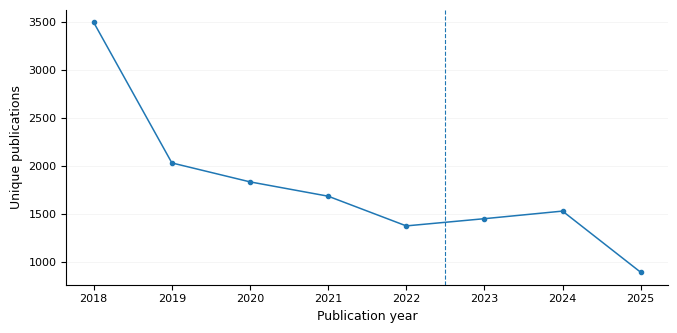

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/figures/Fig_B_future_productivity_distribution.png
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/figures/Fig_B_future_productivity_distribution.eps


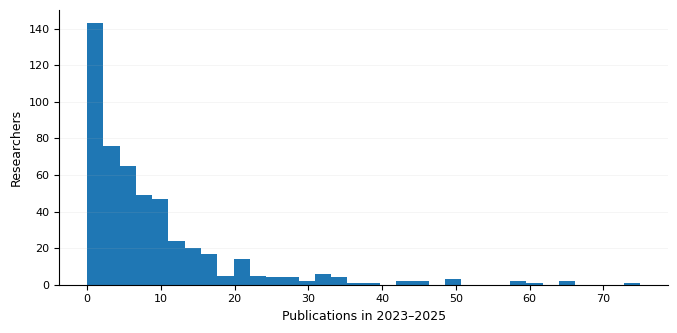


TABLE 1E — MODELING DECISION GATE
 cohort_nonempty  feature_years_2018_2022_complete  outcome_years_2023_2025_complete  author_publication_linkage_ge_80pct  ready_for_predictive_modeling                                          note
            True                              True                              True                                 True                           True Proceed to leakage-aware predictive modeling.


,cohort_nonempty,feature_years_2018_2022_complete,outcome_years_2023_2025_complete,author_publication_linkage_ge_80pct,ready_for_predictive_modeling,note
0,True,True,True,True,True,Proceed to leakage-aware predictive modeling.



ARQUIVOS SALVOS
Panel: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/tables/predictive_panel_2022_to_2025.csv
Tables: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/tables
Figures: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/figures
Artifacts: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/artifacts
README: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/README.txt

BLOCOS A ENVIAR
1) TABLE 0 — RAW IDENTIFIER AUDIT
2) TABLE 1 — AUTHOR↔PUBLICATION LINKAGE CANDIDATES (top rows)
3) TABLE 1A — COHORT AUDIT
4) TABLE 1C — PANEL AND NETWORK SUMMARY
5) TABLE 1E — MODELING DECISION GATE

CONCLUÍDO.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.6 v2 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL
========================================================

Correções principais
--------------------
1. NÃO assume que o OpenAlex Author ID esteja no formato literal "^A\\d+$".
   Aceita URLs como https://openalex.org/A123..., IDs embutidos em strings
   e, se necessário, seleciona empiricamente a melhor chave de ligação
   entre autores_final.xlsx e producoes_final.xlsx.

2. NÃO confunde automaticamente "id_openalex" de produções com Author ID:
   em tabelas de produção esse campo pode ser Work ID (W...).

3. Falha de forma informativa se a ligação autor-publicação for insuficiente,
   em vez de continuar com coorte vazia.

4. graph_features() sempre devolve um DataFrame com "author_key",
   mesmo se a rede estiver vazia, evitando o KeyError observado no merge.

5. Mantém o desenho temporal:
      coorte observada em 2022
      features: 2018–2022
      outcome:  2023–2025

6. Mostra tabelas e figuras no Colab e salva tudo no Google Drive.

Execução
--------
%run /content/Parte_18_6_Coorte2022_PainelTemporal_v2.py
"""

from __future__ import annotations

import re
import sys
import json
import pickle
import unicodedata
import importlib
from itertools import combinations
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    mount_point = Path("/content/drive/MyDrive")
    if not mount_point.exists():
        drive.mount("/content/drive")
    else:
        print("Google Drive já está montado em /content/drive.")
except Exception as e:
    print("[drive]", repr(e))

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("pandas")
ensure("numpy")
ensure("openpyxl")
ensure("networkx")
ensure("matplotlib")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CAMINHOS E JANELAS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
PUB_PATH = ROOT / "runs/run_20260625_200032/input/producoes_final.xlsx"
AUTH_PATH = ROOT / "runs/run_20260625_200032/input/autores_final.xlsx"

OUT = ROOT / "runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"

for d in [OUT, TAB, FIG, ART]:
    d.mkdir(parents=True, exist_ok=True)

FEATURE_START, FEATURE_END = 2018, 2022
OUTCOME_START, OUTCOME_END = 2023, 2025

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def normalize_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.lower() in {"nan", "none", "null", "<na>"}:
        return ""
    s = unicodedata.normalize("NFKC", s)
    return s.strip()

def canonical_openalex_author(x):
    """Extrai A123... de A123..., URLs OpenAlex, API URLs ou strings que o contenham."""
    s = normalize_text(x)
    if not s:
        return ""
    m = re.search(r"(?<![A-Z0-9])A(\d{4,})(?!\d)", s.upper())
    if m:
        return "A" + m.group(1)
    return ""

def canonical_openalex_work(x):
    """Extrai W123... de W123..., URLs OpenAlex, API URLs ou strings que o contenham."""
    s = normalize_text(x)
    if not s:
        return ""
    m = re.search(r"(?<![A-Z0-9])W(\d{4,})(?!\d)", s.upper())
    if m:
        return "W" + m.group(1)
    return ""

def canonical_raw(x):
    s = normalize_text(x)
    return s.upper()

def normalize_doi(x):
    s = normalize_text(x).lower()
    if not s:
        return ""
    s = s.replace("https://doi.org/", "").replace("http://doi.org/", "")
    s = s.replace("doi:", "").strip()
    m = re.search(r"(10\.\d{4,9}/\S+)", s)
    if not m:
        return ""
    return m.group(1).rstrip(".,;)]}")

def normalize_title(x):
    s = normalize_text(x).lower()
    if not s:
        return ""
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def show_df(title, df, max_rows=30):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    if df.empty:
        print("[empty]")
    elif len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    if display is not None:
        display(df.head(max_rows))

def save_figure(fig, stem):
    png = FIG / f"{stem}.png"
    eps = FIG / f"{stem}.eps"
    fig.savefig(png, dpi=600, bbox_inches="tight")
    fig.savefig(eps, format="eps", bbox_inches="tight")
    print("[figure]", png)
    print("[figure]", eps)

def candidate_key_representations(df, dataset_name):
    """
    Cria representações candidatas para colunas potencialmente identificadoras.
    Mantém apenas candidatas razoavelmente informativas.
    """
    reps = []
    n = max(len(df), 1)

    for c in df.columns:
        ser = df[c]

        # Evita colunas numéricas contínuas evidentes.
        if pd.api.types.is_float_dtype(ser) and ser.nunique(dropna=True) > 0.8 * n:
            continue

        raw = ser.map(canonical_raw)
        raw_nonempty = raw.ne("")
        raw_unique = raw[raw_nonempty].nunique()

        oa = ser.map(canonical_openalex_author)
        oa_nonempty = oa.ne("")
        oa_unique = oa[oa_nonempty].nunique()

        # Representação OpenAlex Author, se existir sinal real.
        if oa_nonempty.sum() >= 5:
            reps.append({
                "dataset": dataset_name,
                "column": str(c),
                "transform": "openalex_author",
                "series": oa,
                "nonempty": int(oa_nonempty.sum()),
                "unique": int(oa_unique),
                "coverage": float(oa_nonempty.mean()),
            })

        # Representação raw para IDs internos ou chaves já normalizadas.
        # Exige pelo menos 5 valores e alguma diversidade.
        if raw_nonempty.sum() >= 5 and raw_unique >= 5:
            name = str(c).lower()
            idish = any(t in name for t in ["id", "autor", "author", "openalex", "codigo", "code"])
            if idish:
                reps.append({
                    "dataset": dataset_name,
                    "column": str(c),
                    "transform": "raw",
                    "series": raw,
                    "nonempty": int(raw_nonempty.sum()),
                    "unique": int(raw_unique),
                    "coverage": float(raw_nonempty.mean()),
                })

    return reps

def select_best_author_link(auth_df, pub_df):
    """
    Testa pares de colunas/transformações e escolhe a ligação que maximiza
    a proporção de autores resolvidos que aparecem na tabela de publicações.
    """
    A = candidate_key_representations(auth_df, "authors")
    P = candidate_key_representations(pub_df, "publications")

    rows = []
    best = None

    for a in A:
        aset = set(a["series"][a["series"].ne("")].unique())
        if not aset:
            continue

        for p in P:
            pset = set(p["series"][p["series"].ne("")].unique())
            if not pset:
                continue

            inter = aset & pset
            author_match_share = len(inter) / max(1, len(aset))
            publication_match_share = len(inter) / max(1, len(pset))

            # Bonificação por transformações OpenAlex explícitas.
            bonus = 0.05 if (
                a["transform"] == "openalex_author"
                and p["transform"] == "openalex_author"
            ) else 0.0

            score = author_match_share + bonus

            row = {
                "authors_column": a["column"],
                "authors_transform": a["transform"],
                "authors_nonempty": a["nonempty"],
                "authors_unique": a["unique"],
                "publications_column": p["column"],
                "publications_transform": p["transform"],
                "publications_nonempty": p["nonempty"],
                "publications_unique": p["unique"],
                "intersection_unique": len(inter),
                "authors_match_share": author_match_share,
                "publication_key_match_share": publication_match_share,
                "score": score,
            }
            rows.append(row)

            if best is None or score > best["score"]:
                best = {
                    **row,
                    "authors_series": a["series"],
                    "publications_series": p["series"],
                }

    audit = pd.DataFrame(rows)
    if not audit.empty:
        audit = audit.sort_values(
            ["score", "intersection_unique"],
            ascending=False
        ).reset_index(drop=True)

    return best, audit

def find_year_col(df):
    preferred = ["ano", "year", "publication_year", "ano_publicacao"]
    lower = {str(c).strip().lower(): c for c in df.columns}
    for x in preferred:
        if x in lower:
            return lower[x]

    candidates = []
    for c in df.columns:
        vals = pd.to_numeric(df[c], errors="coerce")
        valid = vals.between(1900, 2030)
        if valid.sum() >= 20:
            candidates.append((float(valid.mean()), c))
    if not candidates:
        raise RuntimeError("Não foi possível identificar a coluna de ano.")
    return sorted(candidates, reverse=True)[0][1]

def find_work_key(df, year_col):
    """
    Prioridade:
    1) OpenAlex Work ID W...
    2) DOI
    3) título + ano
    """
    diagnostics = []

    # 1. Work IDs
    best_w = None
    for c in df.columns:
        w = df[c].map(canonical_openalex_work)
        cov = float(w.ne("").mean())
        uniq = int(w[w.ne("")].nunique())
        diagnostics.append({
            "column": str(c), "kind": "openalex_work",
            "coverage": cov, "unique": uniq
        })
        if best_w is None or (cov, uniq) > (best_w[0], best_w[1]):
            best_w = (cov, uniq, c, w)

    if best_w and best_w[0] >= 0.5:
        return best_w[3], f"OpenAlex Work ID from '{best_w[2]}'", pd.DataFrame(diagnostics)

    # 2. DOI
    best_doi = None
    for c in df.columns:
        doi = df[c].map(normalize_doi)
        cov = float(doi.ne("").mean())
        uniq = int(doi[doi.ne("")].nunique())
        diagnostics.append({
            "column": str(c), "kind": "doi",
            "coverage": cov, "unique": uniq
        })
        if best_doi is None or (cov, uniq) > (best_doi[0], best_doi[1]):
            best_doi = (cov, uniq, c, doi)

    if best_doi and best_doi[0] >= 0.3:
        return best_doi[3].map(lambda x: f"DOI:{x}" if x else ""), \
               f"DOI from '{best_doi[2]}'", pd.DataFrame(diagnostics)

    # 3. título + ano
    title_candidates = [
        c for c in df.columns
        if any(t in str(c).lower() for t in ["titulo", "title", "display_name"])
    ]
    if title_candidates:
        c = title_candidates[0]
        title = df[c].map(normalize_title)
        years = pd.to_numeric(df[year_col], errors="coerce").astype("Int64")
        key = pd.Series("", index=df.index, dtype="object")
        mask = title.ne("") & years.notna()
        key.loc[mask] = (
            "TY:"
            + title.loc[mask]
            + "|"
            + years.loc[mask].astype(str)
        )
        return key, f"title+year from '{c}'", pd.DataFrame(diagnostics)

    raise RuntimeError(
        "Não foi possível construir uma chave de publicação: "
        "nenhum Work ID, DOI ou título utilizável foi encontrado."
    )

GRAPH_FEATURE_COLUMNS = [
    "author_key",
    "degree",
    "strength",
    "avg_tie_strength",
    "weighted_clustering",
    "pagerank",
    "betweenness",
    "core_number",
    "avg_neighbor_degree",
    "component_size",
    "is_isolate",
]

def graph_features(G):
    """
    Sempre retorna as colunas esperadas, inclusive quando G estiver vazio.
    """
    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=GRAPH_FEATURE_COLUMNS)

    nodes = list(G.nodes())
    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))

    if G.number_of_edges() == 0:
        rows = []
        for n in nodes:
            rows.append({
                "author_key": n,
                "degree": 0,
                "strength": 0.0,
                "avg_tie_strength": 0.0,
                "weighted_clustering": 0.0,
                "pagerank": 1.0 / len(nodes),
                "betweenness": 0.0,
                "core_number": 0,
                "avg_neighbor_degree": 0.0,
                "component_size": 1,
                "is_isolate": 1,
            })
        return pd.DataFrame(rows, columns=GRAPH_FEATURE_COLUMNS)

    H = G.copy()
    for u, v, d in H.edges(data=True):
        w = float(d.get("weight", 1.0))
        d["distance"] = 1.0 / w if w > 0 else 1.0

    clustering = nx.clustering(G, weight="weight")
    pagerank = nx.pagerank(G, weight="weight")
    betweenness = nx.betweenness_centrality(H, weight="distance", normalized=True)
    core = nx.core_number(G)
    avg_neigh = nx.average_neighbor_degree(G, weight="weight")

    comp_size = {}
    for comp in nx.connected_components(G):
        size = len(comp)
        for n in comp:
            comp_size[n] = size

    rows = []
    for n in nodes:
        k = int(degree.get(n, 0))
        s = float(strength.get(n, 0.0))
        rows.append({
            "author_key": n,
            "degree": k,
            "strength": s,
            "avg_tie_strength": s / k if k > 0 else 0.0,
            "weighted_clustering": float(clustering.get(n, 0.0)),
            "pagerank": float(pagerank.get(n, 0.0)),
            "betweenness": float(betweenness.get(n, 0.0)),
            "core_number": int(core.get(n, 0)),
            "avg_neighbor_degree": float(avg_neigh.get(n, 0.0)),
            "component_size": int(comp_size.get(n, 1)),
            "is_isolate": int(k == 0),
        })

    return pd.DataFrame(rows, columns=GRAPH_FEATURE_COLUMNS)

def build_coauthorship_graph(long_df, cohort_keys, start_year, end_year):
    x = long_df[
        long_df["author_key"].isin(cohort_keys)
        & long_df["year"].between(start_year, end_year)
    ][["author_key", "work_key"]].drop_duplicates()

    G = nx.Graph()
    G.add_nodes_from(sorted(cohort_keys))

    multi_works = 0
    for _, g in x.groupby("work_key"):
        authors = sorted(set(g["author_key"]))
        if len(authors) < 2:
            continue
        multi_works += 1
        for u, v in combinations(authors, 2):
            if G.has_edge(u, v):
                G[u][v]["weight"] += 1.0
            else:
                G.add_edge(u, v, weight=1.0)

    return G, multi_works

# ======================================================================================
# 4. CARREGAMENTO
# ======================================================================================

print("\n" + "=" * 120)
print("PARTE 18.6 v2 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL")
print("=" * 120)
print("[publications]", PUB_PATH)
print("[authors]     ", AUTH_PATH)
print("[output]      ", OUT)

pub = pd.read_excel(PUB_PATH)
auth = pd.read_excel(AUTH_PATH)

print(f"\nShapes: publications={pub.shape}; authors={auth.shape}")

# ======================================================================================
# 5. AUDITORIA DOS VALORES BRUTOS — IMPORTANTE PARA O ERRO OBSERVADO
# ======================================================================================

raw_samples = []

for dataset_name, df in [("authors", auth), ("publications", pub)]:
    for c in df.columns:
        name = str(c).lower()
        if any(t in name for t in ["id", "autor", "author", "openalex"]):
            values = (
                df[c]
                .dropna()
                .astype(str)
                .drop_duplicates()
                .head(8)
                .tolist()
            )
            raw_samples.append({
                "dataset": dataset_name,
                "column": str(c),
                "non_missing": int(df[c].notna().sum()),
                "unique": int(df[c].nunique(dropna=True)),
                "sample_values": " | ".join(values),
                "openalex_A_extractable": int(df[c].map(canonical_openalex_author).ne("").sum()),
                "openalex_W_extractable": int(df[c].map(canonical_openalex_work).ne("").sum()),
            })

raw_samples_df = pd.DataFrame(raw_samples)
raw_samples_df.to_csv(TAB / "Table_0_raw_identifier_audit.csv", index=False)
show_df("TABLE 0 — RAW IDENTIFIER AUDIT", raw_samples_df, max_rows=50)

# ======================================================================================
# 6. SELEÇÃO EMPÍRICA DA CHAVE AUTOR ↔ PUBLICAÇÃO
# ======================================================================================

best_link, link_audit = select_best_author_link(auth, pub)

if best_link is None:
    raise RuntimeError(
        "Nenhuma chave candidata de ligação entre autores_final.xlsx "
        "e producoes_final.xlsx pôde ser identificada."
    )

link_audit.to_csv(TAB / "Table_1_author_publication_linkage_candidates.csv", index=False)
show_df(
    "TABLE 1 — AUTHOR↔PUBLICATION LINKAGE CANDIDATES",
    link_audit.head(25),
    max_rows=25
)

print("\nBEST LINK")
print(" authors:", best_link["authors_column"], "/", best_link["authors_transform"])
print(" pubs:   ", best_link["publications_column"], "/", best_link["publications_transform"])
print(" matched unique authors:", best_link["intersection_unique"])
print(" author match share:     ", f"{best_link['authors_match_share']:.4f}")

if best_link["authors_match_share"] < 0.50:
    raise RuntimeError(
        "A melhor ligação autor-publicação cobre menos de 50% dos autores. "
        "O script foi interrompido para evitar transformar falha de linkage em zeros de produtividade. "
        "Envie TABLE 0 e TABLE 1 para revisão."
    )

auth2 = auth.copy()
pub2 = pub.copy()

auth2["author_key"] = best_link["authors_series"]
pub2["author_key"] = best_link["publications_series"]

auth2 = auth2[auth2["author_key"].ne("")].copy()
pub2 = pub2[pub2["author_key"].ne("")].copy()

# A coorte 2022 contém apenas IDs resolvidos/unívocos.
cohort_keys = sorted(auth2["author_key"].dropna().unique())
cohort = pd.DataFrame({"author_key": cohort_keys})

# ======================================================================================
# 7. ANO E CHAVE DE PUBLICAÇÃO
# ======================================================================================

year_col = find_year_col(pub2)
pub2["year"] = pd.to_numeric(pub2[year_col], errors="coerce")
pub2 = pub2[pub2["year"].between(1900, 2030)].copy()
pub2["year"] = pub2["year"].astype(int)

work_key, work_key_description, work_diag = find_work_key(pub2, year_col)
pub2["work_key"] = work_key
pub2 = pub2[pub2["work_key"].ne("")].copy()

work_diag.to_csv(TAB / "Table_2_work_key_diagnostics.csv", index=False)

# Deduplicação autor–obra.
long_df = (
    pub2[["author_key", "work_key", "year"]]
    .drop_duplicates()
    .copy()
)

# ======================================================================================
# 8. TABLE 1A — COHORT AUDIT
# ======================================================================================

cohort_set = set(cohort_keys)
pub_author_set = set(long_df["author_key"].unique())
linked = cohort_set & pub_author_set

table_1a = pd.DataFrame([{
    "raw_author_rows": int(len(auth)),
    "resolved_author_rows_after_key_extraction": int(len(auth2)),
    "unique_resolved_authors": int(len(cohort_set)),
    "unique_resolved_authors_found_in_publications": int(len(linked)),
    "publication_linkage_pct": 100.0 * len(linked) / max(1, len(cohort_set)),
    "feature_period": f"{FEATURE_START}-{FEATURE_END}",
    "outcome_period": f"{OUTCOME_START}-{OUTCOME_END}",
    "author_key_source": (
        f"{best_link['authors_column']} [{best_link['authors_transform']}]"
    ),
    "publication_author_key_source": (
        f"{best_link['publications_column']} [{best_link['publications_transform']}]"
    ),
    "work_key_source": work_key_description,
}])

table_1a.to_csv(TAB / "Table_1A_cohort_audit.csv", index=False)
show_df("TABLE 1A — COHORT AUDIT", table_1a)

# ======================================================================================
# 9. COBERTURA TEMPORAL
# ======================================================================================

annual = (
    long_df[long_df["author_key"].isin(cohort_set)]
    .groupby("year")
    .agg(
        unique_works=("work_key", "nunique"),
        active_authors=("author_key", "nunique"),
        author_work_rows=("author_key", "size"),
    )
    .reset_index()
)

annual.to_csv(TAB / "Table_1B_annual_coverage.csv", index=False)
show_df("TABLE 1B — ANNUAL COVERAGE", annual, max_rows=100)

# ======================================================================================
# 10. FEATURES PASSADAS E OUTCOME FUTURO
# ======================================================================================

past = (
    long_df[
        long_df["author_key"].isin(cohort_set)
        & long_df["year"].between(FEATURE_START, FEATURE_END)
    ]
    .groupby("author_key")
    .agg(
        past_works=("work_key", "nunique"),
        past_active_years=("year", "nunique"),
        past_first_year=("year", "min"),
        past_last_year=("year", "max"),
    )
    .reset_index()
)

future = (
    long_df[
        long_df["author_key"].isin(cohort_set)
        & long_df["year"].between(OUTCOME_START, OUTCOME_END)
    ]
    .groupby("author_key")
    .agg(
        future_works=("work_key", "nunique"),
        future_active_years=("year", "nunique"),
    )
    .reset_index()
)

# ======================================================================================
# 11. REDE 2018–2022 + GRAPH FEATURES
# ======================================================================================

G, multi_ppgci_works = build_coauthorship_graph(
    long_df,
    cohort_set,
    FEATURE_START,
    FEATURE_END
)

gf = graph_features(G)

# Esta checagem impede o KeyError original.
assert "author_key" in gf.columns, "graph_features() não devolveu author_key."

panel = cohort.copy()
panel = panel.merge(past, on="author_key", how="left")
panel = panel.merge(gf, on="author_key", how="left")
panel = panel.merge(future, on="author_key", how="left")

zero_cols = [
    "past_works", "past_active_years",
    "future_works", "future_active_years",
    "degree", "strength", "avg_tie_strength",
    "weighted_clustering", "pagerank", "betweenness",
    "core_number", "avg_neighbor_degree",
    "component_size", "is_isolate",
]

for c in zero_cols:
    if c in panel.columns:
        panel[c] = panel[c].fillna(0)

panel["past_annual_rate"] = panel["past_works"] / (FEATURE_END - FEATURE_START + 1)
panel["future_annual_rate"] = panel["future_works"] / (OUTCOME_END - OUTCOME_START + 1)

panel_path = TAB / "predictive_panel_2022_to_2025.csv"
panel.to_csv(panel_path, index=False)

# ======================================================================================
# 12. SUMÁRIOS MANUSCRIPT-READY
# ======================================================================================

components = list(nx.connected_components(G))
gcc_n = max((len(c) for c in components), default=0)

table_1c = pd.DataFrame([{
    "cohort_n": len(panel),
    "authors_with_past_output": int((panel["past_works"] > 0).sum()),
    "authors_with_future_output": int((panel["future_works"] > 0).sum()),
    "future_zero_n": int((panel["future_works"] == 0).sum()),
    "future_zero_pct": float((panel["future_works"] == 0).mean() * 100),
    "median_past_works": float(panel["past_works"].median()),
    "median_future_works": float(panel["future_works"].median()),
    "mean_future_works": float(panel["future_works"].mean()),
    "max_future_works": float(panel["future_works"].max()),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "isolates": int(nx.number_of_isolates(G)),
    "connected_components": nx.number_connected_components(G),
    "gcc_n": gcc_n,
    "gcc_pct": 100.0 * gcc_n / max(1, G.number_of_nodes()),
    "multi_author_ppgci_works_2018_2022": int(multi_ppgci_works),
}])

table_1c.to_csv(TAB / "Table_1C_panel_network_summary.csv", index=False)
show_df("TABLE 1C — PANEL AND NETWORK SUMMARY", table_1c)

desc_cols = [
    "past_works", "future_works", "degree", "strength",
    "avg_tie_strength", "weighted_clustering",
    "pagerank", "betweenness", "core_number"
]

desc = (
    panel[desc_cols]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

desc.to_csv(TAB / "Table_1D_predictor_outcome_descriptives.csv", index=False)
show_df("TABLE 1D — PREDICTOR/OUTCOME DESCRIPTIVES", desc, max_rows=50)

# ======================================================================================
# 13. FIGURAS PARA AUDITORIA / FUTURO MANUSCRITO
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Figura A: cobertura anual 2018–2025
plot_ann = annual[annual["year"].between(FEATURE_START, OUTCOME_END)].copy()

fig, ax = plt.subplots(figsize=(6.85, 3.4))
ax.plot(
    plot_ann["year"],
    plot_ann["unique_works"],
    marker="o",
    markersize=3,
    linewidth=1.1
)
ax.axvline(2022.5, linestyle="--", linewidth=0.8)
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique publications")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig_A_annual_publication_coverage_2018_2025")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Figura B: distribuição do outcome 2023–2025
fig, ax = plt.subplots(figsize=(6.85, 3.4))
ax.hist(panel["future_works"], bins="auto")
ax.set_xlabel("Publications in 2023–2025")
ax.set_ylabel("Researchers")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig_B_future_productivity_distribution")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 14. DECISION GATE
# ======================================================================================

coverage_2023_2025 = set(range(2023, 2026)).issubset(set(annual["year"].tolist()))
coverage_2018_2022 = set(range(2018, 2023)).issubset(set(annual["year"].tolist()))
linkage_ok = best_link["authors_match_share"] >= 0.80
cohort_nonempty = len(cohort_set) > 0

ready = bool(
    cohort_nonempty
    and coverage_2018_2022
    and coverage_2023_2025
    and linkage_ok
)

decision = pd.DataFrame([{
    "cohort_nonempty": cohort_nonempty,
    "feature_years_2018_2022_complete": coverage_2018_2022,
    "outcome_years_2023_2025_complete": coverage_2023_2025,
    "author_publication_linkage_ge_80pct": linkage_ok,
    "ready_for_predictive_modeling": ready,
    "note": (
        "Proceed to leakage-aware predictive modeling."
        if ready
        else "Do not fit final predictive models yet; inspect linkage/coverage audit."
    ),
}])

decision.to_csv(TAB / "Table_1E_modeling_decision_gate.csv", index=False)
show_df("TABLE 1E — MODELING DECISION GATE", decision)

# ======================================================================================
# 15. SALVAR ARTEFATOS
# ======================================================================================

with open(ART / "graph_2018_2022.pkl", "wb") as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

with open(ART / "panel_metadata.json", "w", encoding="utf-8") as f:
    json.dump({
        "feature_period": [FEATURE_START, FEATURE_END],
        "outcome_period": [OUTCOME_START, OUTCOME_END],
        "author_link": {
            "authors_column": best_link["authors_column"],
            "authors_transform": best_link["authors_transform"],
            "publications_column": best_link["publications_column"],
            "publications_transform": best_link["publications_transform"],
            "authors_match_share": best_link["authors_match_share"],
        },
        "year_column": str(year_col),
        "work_key_source": work_key_description,
        "cohort_n": len(cohort_set),
        "ready_for_predictive_modeling": ready,
    }, f, ensure_ascii=False, indent=2)

readme = f"""
PARTE 18.6 v2 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL
========================================================

Feature window: {FEATURE_START}-{FEATURE_END}
Outcome window: {OUTCOME_START}-{OUTCOME_END}

Chosen author linkage:
authors_final.xlsx -> {best_link['authors_column']} [{best_link['authors_transform']}]
producoes_final.xlsx -> {best_link['publications_column']} [{best_link['publications_transform']}]

Author linkage share:
{best_link['authors_match_share']:.4f}

Work key:
{work_key_description}

Cohort n:
{len(cohort_set)}

Graph:
nodes={G.number_of_nodes()}
edges={G.number_of_edges()}
isolates={nx.number_of_isolates(G)}

Ready for predictive modeling:
{ready}

The original failure was caused by treating the author identifier as if every
value were already a bare OpenAlex A-ID. This version canonicalizes IDs and
selects the author-publication linkage empirically before constructing the panel.
""".strip()

(OUT / "README.txt").write_text(readme, encoding="utf-8")

print("\n" + "=" * 120)
print("ARQUIVOS SALVOS")
print("=" * 120)
print("Panel:", panel_path)
print("Tables:", TAB)
print("Figures:", FIG)
print("Artifacts:", ART)
print("README:", OUT / "README.txt")

print("\n" + "=" * 120)
print("BLOCOS A ENVIAR")
print("=" * 120)
print("1) TABLE 0 — RAW IDENTIFIER AUDIT")
print("2) TABLE 1 — AUTHOR↔PUBLICATION LINKAGE CANDIDATES (top rows)")
print("3) TABLE 1A — COHORT AUDIT")
print("4) TABLE 1C — PANEL AND NETWORK SUMMARY")
print("5) TABLE 1E — MODELING DECISION GATE")

print("\nCONCLUÍDO.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.7 — MODELAGEM PREDITIVA PROSPECTIVA
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel_v2/tables/predictive_panel_2022_to_2025.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling

TABLE 2A — OUTCOME AND HISTORY AUDIT
 cohort_n  max_abs_difference_vs_part18_6_past_works  mean_primary_outcome_2023_2024  median_primary_outcome_2023_2024  zero_primary_outcome_pct  mean_sensitivity_outcome_2023_2025  median_sensitivity_outcome_2023_2025  zero_sensitivity_outcome_pct
      500                                        0.0                            6.81                               5.0                      12.6               

,cohort_n,max_abs_difference_vs_part18_6_past_works,mean_primary_outcome_2023_2024,median_primary_outcome_2023_2024,zero_primary_outcome_pct,mean_sensitivity_outcome_2023_2025,median_sensitivity_outcome_2023_2025,zero_sensitivity_outcome_pct
0,500,0.0,6.81,5.0,12.6,8.692,5.5,11.2



TABLE 2B — PREDICTOR BLOCKS
        block  n_features                                                                                                                                                                                                                                                      features
 History-only           4                                                                                                                                                         past_works_2018_2022 | past_active_years_2018_2022 | recent_works_2021_2022 | past_productivity_slope
   Graph-only          10                                                                                                         degree | strength | avg_tie_strength | weighted_clustering | pagerank | betweenness | core_number | avg_neighbor_degree | component_size | is_isolate
History+Graph          14 past_works_2018_2022 | past_active_years_2018_2022 | recent_works_2021_2022 | past_productivity_slope | d

,block,n_features,features
0,History-only,4,past_works_2018_2022 | past_active_years_2018_...
1,Graph-only,10,degree | strength | avg_tie_strength | weighte...
2,History+Graph,14,past_works_2018_2022 | past_active_years_2018_...



TABLE 2C — 2025 COVERAGE GATE
 works_2023  works_2024  works_2025  works_2025_vs_mean_2023_2024_ratio             primary_outcome         sensitivity_outcome                                                                                             reason
       1450        1529         893                             0.59953 2023-2024 publication count 2023-2025 publication count 2025 retained only as sensitivity because observed coverage is substantially lower than 2023-2024.


...


----------------------------------------------------------------------------------------------------------------------
SENSITIVITY 2023-2025 — Poisson History-only
----------------------------------------------------------------------------------------------------------------------
[Poisson History-only] outer split 1/50
[Poisson History-only] outer split 10/50
[Poisson History-only] outer split 20/50
[Poisson History-only] outer split 30/50
[Poisson History-only] outer split 40/50
[Poisson History-only] outer split 50/50

----------------------------------------------------------------------------------------------------------------------
SENSITIVITY 2023-2025 — Poisson Graph-only
----------------------------------------------------------------------------------------------------------------------
[Poisson Graph-only] outer split 1/50
[Poisson Graph-only] outer split 10/50
[Poisson Graph-only] outer split 20/50
[Poisson Graph-only] outer split 30/50
[Poisson Graph-only] outer split 4

,model,outcome,MAE,RMSE,R2,Spearman_rho,Poisson_deviance,Observed_mean,Predicted_mean
0,Poisson History+Graph,Publications 2023-2025 (sensitivity),5.142344,9.657316,0.183967,0.675942,5.061955,8.692,8.984637
1,Poisson History-only,Publications 2023-2025 (sensitivity),5.246761,11.840061,-0.226600,0.701724,5.373388,8.692,8.938003
2,Poisson Graph-only,Publications 2023-2025 (sensitivity),6.723117,10.418103,0.050331,0.226616,8.878941,8.692,8.748391
3,Persistence,Publications 2023-2025 (sensitivity),8.458000,11.665734,-0.190746,0.664336,8.683420,8.692,14.485200



TABLE S2 — HYPERPARAMETER SELECTION FREQUENCY
                  model                        best_params  outer_folds_selected
     Poisson Graph-only              {"model__alpha": 0.1}                    29
     Poisson Graph-only              {"model__alpha": 1.0}                    13
     Poisson Graph-only             {"model__alpha": 10.0}                     7
     Poisson Graph-only             {"model__alpha": 0.01}                     1
  Poisson History+Graph              {"model__alpha": 0.1}                    21
  Poisson History+Graph            {"model__alpha": 0.001}                     9
  Poisson History+Graph             {"model__alpha": 0.01}                     9
  Poisson History+Graph              {"model__alpha": 1.0}                     8
  Poisson History+Graph             {"model__alpha": 10.0}                     3
   Poisson History-only            {"model__alpha": 0.001}                    21
   Poisson History-only              {"model__alpha": 0.1}    

,model,best_params,outer_folds_selected
1,Poisson Graph-only,"{""model__alpha"": 0.1}",29
2,Poisson Graph-only,"{""model__alpha"": 1.0}",13
3,Poisson Graph-only,"{""model__alpha"": 10.0}",7
0,Poisson Graph-only,"{""model__alpha"": 0.01}",1
6,Poisson History+Graph,"{""model__alpha"": 0.1}",21
4,Poisson History+Graph,"{""model__alpha"": 0.001}",9
5,Poisson History+Graph,"{""model__alpha"": 0.01}",9
7,Poisson History+Graph,"{""model__alpha"": 1.0}",8
8,Poisson History+Graph,"{""model__alpha"": 10.0}",3
9,Poisson History-only,"{""model__alpha"": 0.001}",21


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures/Fig2_observed_vs_predicted_primary.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures/Fig2_observed_vs_predicted_primary.png


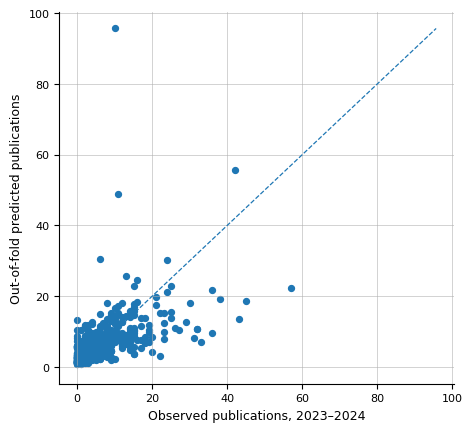

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures/Fig3_bootstrap_incremental_graph_value.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures/Fig3_bootstrap_incremental_graph_value.png


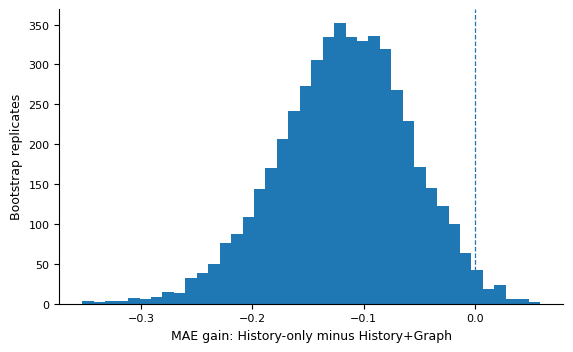

/tmp/ipykernel_1569/2689358181.py:882: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["History-only", "History+Graph"], showfliers=False)


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures/FigS1_outer_fold_mae.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures/FigS1_outer_fold_mae.png


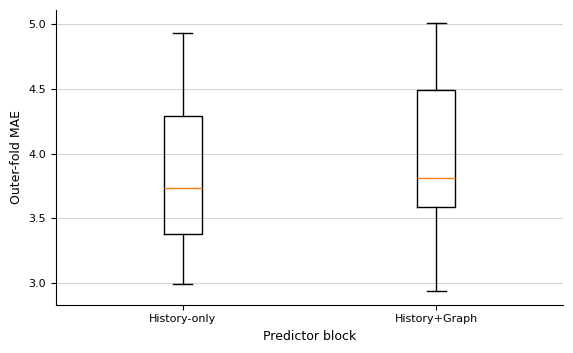


TABLE 4 — PRIMARY INCREMENTAL-VALUE DECISION GATE
primary_model_family             primary_outcome            primary_comparison  MAE_gain_bootstrap_median  MAE_gain_CI_low  MAE_gain_CI_high       decision_gate                                                                                                                         interpretation
    PoissonRegressor 2023-2024 publication count History+Graph vs History-only                  -0.115919         -0.24093          -0.00895 GRAPH_FEATURES_HARM Graph features reduce predictive performance relative to the historical productivity baseline under the primary Poisson specification.


,primary_model_family,primary_outcome,primary_comparison,MAE_gain_bootstrap_median,MAE_gain_CI_low,MAE_gain_CI_high,decision_gate,interpretation
0,PoissonRegressor,2023-2024 publication count,History+Graph vs History-only,-0.115919,-0.24093,-0.00895,GRAPH_FEATURES_HARM,Graph features reduce predictive performance r...



ARQUIVOS SALVOS
Tables:    /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/tables
Figures:   /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/figures
Artifacts: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/artifacts
README:    /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_predictive_modeling/README.txt

BLOCOS A ENVIAR PARA A PRÓXIMA ETAPA
1) TABLE 2A — OUTCOME AND HISTORY AUDIT
2) TABLE 2 — PRIMARY OUT-OF-FOLD PREDICTIVE PERFORMANCE
3) TABLE 3 — INCREMENTAL PREDICTIVE VALUE OF GRAPH FEATURES
4) TABLE S1 — 2023-2025 SENSITIVITY PERFORMANCE
5) TABLE 4 — PRIMARY INCREMENTAL-VALUE DECISION GATE
6) Fig. 2 e Fig. 3

CONCLUÍDO.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.7 — MODELAGEM PREDITIVA PROSPECTIVA, LEAKAGE-AWARE
============================================================

Artigo:
Do Collaboration Graph Features Predict Future Scientific Productivity?
A Leakage-Aware Temporal Evaluation in Brazilian Information Science

Decisão metodológica congelada nesta etapa
------------------------------------------
- Coorte: pesquisadores resolvidos no roster de 2022 (n ~ 500).
- Features: apenas informação observada até 31/12/2022.
- Janela de features: 2018–2022.
- Desfecho PRIMÁRIO: publicações em 2023–2024.
- Desfecho de SENSIBILIDADE: publicações em 2023–2025.

Por que 2025 não é primário?
----------------------------
A auditoria anterior mostrou 893 trabalhos em 2025, contra 1450 em 2023 e 1529
em 2024, além de queda expressiva no número de autores ativos. Isso sugere
cobertura/indexação incompleta de 2025 no snapshot usado. Portanto, 2025 é
mantido como análise de sensibilidade, não como endpoint primário.

Pergunta principal
------------------
As características da rede de colaboração observadas até 2022 acrescentam
capacidade preditiva para produtividade futura além do histórico de produtividade?

Modelos
-------
1. Persistence baseline (sem ajuste).
2. PoissonRegressor:
   a) history-only
   b) graph-only
   c) history + graph
3. Ridge com transformação log1p do alvo:
   a) history-only
   b) graph-only
   c) history + graph

Validação
---------
- Repeated 5-fold CV, 10 repetições (50 outer splits).
- Tuning de hiperparâmetro exclusivamente dentro do training fold.
- Cada pesquisador recebe 10 previsões out-of-fold por modelo; a previsão final
  usada nas métricas é a média dessas previsões.
- Bootstrap pareado no nível do pesquisador para a comparação history vs combined.
- Nenhuma feature usa informação de 2023 em diante.

Outputs
-------
- Tabelas CSV + Excel no Drive.
- Predições por pesquisador.
- Objetos/modelos auxiliares.
- Figuras EPS + PNG 600 dpi, sem título embutido.
- Resultados mostrados também no Colab.

Execução
--------
%run /content/Parte_18_7_Modelagem_Preditiva_Prospectiva.py
"""

from __future__ import annotations

import json
import math
import sys
import pickle
import warnings
import importlib
from pathlib import Path
from collections import defaultdict

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("scipy")
ensure("sklearn", "scikit-learn")
ensure("matplotlib")
ensure("openpyxl")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
    make_scorer,
)
from sklearn.model_selection import (
    RepeatedKFold,
    KFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings("ignore", category=UserWarning)

# ======================================================================================
# 2. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
BASE = ROOT / "runs" / "temporal_productivity_20260929"

PANEL_CANDIDATES = [
    BASE / "06_cohort2022_prospective_panel_v2/tables/predictive_panel_2022_to_2025.csv",
    BASE / "06_cohort2022_prospective_panel/tables/predictive_panel_2022_to_2025.csv",
]

PUB_PATH = ROOT / "runs/run_20260625_200032/input/producoes_final.xlsx"

PANEL_PATH = next((p for p in PANEL_CANDIDATES if p.exists()), None)
if PANEL_PATH is None:
    raise FileNotFoundError(
        "Não encontrei o painel da Parte 18.6 v2.\n"
        + "\n".join(str(p) for p in PANEL_CANDIDATES)
    )

if not PUB_PATH.exists():
    raise FileNotFoundError(f"Arquivo de publicações não encontrado: {PUB_PATH}")

OUT = BASE / "07_predictive_modeling"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"

for d in [OUT, TAB, FIG, ART]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 20260929
N_OUTER_SPLITS = 5
N_REPEATS = 10
N_BOOT = 5000

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def show_df(name, df, max_rows=50):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if len(df) > max_rows:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    else:
        print(df.to_string(index=False))
    if display is not None:
        display(df.head(max_rows))

def extract_openalex_id(series, prefix):
    pat = rf"({prefix}\d+)"
    return (
        series.astype(str)
        .str.extract(pat, flags=0, expand=False)
        .str.upper()
    )

def clip_pred(x):
    return np.maximum(np.asarray(x, dtype=float), 1e-9)

def metric_dict(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    pred_pos = clip_pred(pred)
    rho = spearmanr(y, pred).statistic
    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": math.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "Poisson_deviance": mean_poisson_deviance(y, pred_pos),
        "Observed_mean": float(np.mean(y)),
        "Predicted_mean": float(np.mean(pred)),
    }

def make_poisson_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(max_iter=4000))
    ])

def make_ridge_log_pipeline():
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

def primary_scorer():
    # PoissonRegressor retorna predições positivas.
    return make_scorer(mean_poisson_deviance, greater_is_better=False)

def run_nested_repeated_cv(X, y, family, model_name):
    """
    Retorna:
      - previsão média OOF por pesquisador;
      - todas as previsões OOF;
      - tabela de folds;
      - hiperparâmetros selecionados.
    """
    n = len(y)
    pred_lists = [[] for _ in range(n)]
    fold_rows = []
    param_rows = []

    outer = RepeatedKFold(
        n_splits=N_OUTER_SPLITS,
        n_repeats=N_REPEATS,
        random_state=SEED,
    )

    for split_idx, (tr, te) in enumerate(outer.split(X), start=1):
        repeat_idx = (split_idx - 1) // N_OUTER_SPLITS + 1
        fold_idx = (split_idx - 1) % N_OUTER_SPLITS + 1

        inner = KFold(
            n_splits=5,
            shuffle=True,
            random_state=SEED + split_idx,
        )

        if family == "poisson":
            estimator = make_poisson_pipeline()
            param_grid = {
                "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
            }
            scorer = primary_scorer()

        elif family == "ridge_log":
            estimator = make_ridge_log_pipeline()
            param_grid = {
                "regressor__ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
            }
            scorer = "neg_mean_absolute_error"

        else:
            raise ValueError(f"Família desconhecida: {family}")

        search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=scorer,
            cv=inner,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X.iloc[tr], y[tr])

        pred = np.asarray(search.predict(X.iloc[te]), dtype=float)
        pred = np.maximum(pred, 0.0)

        for idx, p in zip(te, pred):
            pred_lists[idx].append(float(p))

        m = metric_dict(y[te], pred)
        fold_rows.append({
            "model": model_name,
            "family": family,
            "repeat": repeat_idx,
            "fold": fold_idx,
            "n_train": len(tr),
            "n_test": len(te),
            **m,
        })

        best_params = dict(search.best_params_)
        param_rows.append({
            "model": model_name,
            "family": family,
            "repeat": repeat_idx,
            "fold": fold_idx,
            "best_params": json.dumps(best_params, sort_keys=True),
            "best_inner_score": float(search.best_score_),
        })

        if split_idx % 10 == 0 or split_idx == 1:
            print(
                f"[{model_name}] outer split {split_idx}/"
                f"{N_OUTER_SPLITS * N_REPEATS}"
            )

    pred_mean = np.array([
        np.mean(v) if len(v) else np.nan
        for v in pred_lists
    ])

    pred_count = np.array([len(v) for v in pred_lists])

    if not np.all(pred_count == N_REPEATS):
        raise RuntimeError(
            f"{model_name}: cada pesquisador deveria ter {N_REPEATS} "
            f"predições OOF; observado min={pred_count.min()}, max={pred_count.max()}."
        )

    return (
        pred_mean,
        pd.DataFrame(fold_rows),
        pd.DataFrame(param_rows),
        pred_count,
    )

def bootstrap_metric_difference(y, pred_a, pred_b, n_boot=N_BOOT, seed=SEED):
    """
    Diferença definida como:
      MAE_gain = MAE(A) - MAE(B), portanto positivo favorece B.
      RMSE_gain = RMSE(A) - RMSE(B), positivo favorece B.
      R2_gain = R2(B) - R2(A), positivo favorece B.
      rho_gain = rho(B) - rho(A), positivo favorece B.
    A = history-only; B = history + graph.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    a = np.asarray(pred_a, dtype=float)
    b = np.asarray(pred_b, dtype=float)
    n = len(y)

    rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yy, aa, bb = y[idx], a[idx], b[idx]

        mae_gain = mean_absolute_error(yy, aa) - mean_absolute_error(yy, bb)
        rmse_gain = (
            math.sqrt(mean_squared_error(yy, aa))
            - math.sqrt(mean_squared_error(yy, bb))
        )
        r2_gain = r2_score(yy, bb) - r2_score(yy, aa)

        rho_a = spearmanr(yy, aa).statistic
        rho_b = spearmanr(yy, bb).statistic
        rho_gain = rho_b - rho_a

        rows.append((mae_gain, rmse_gain, r2_gain, rho_gain))

    boot = pd.DataFrame(
        rows,
        columns=["MAE_gain", "RMSE_gain", "R2_gain", "Spearman_rho_gain"]
    )

    summary_rows = []
    for c in boot.columns:
        arr = boot[c].to_numpy()
        summary_rows.append({
            "metric": c,
            "estimate": float(np.mean(arr)),
            "median": float(np.median(arr)),
            "ci_2.5": float(np.quantile(arr, 0.025)),
            "ci_97.5": float(np.quantile(arr, 0.975)),
            "probability_gt_0": float(np.mean(arr > 0)),
        })

    return boot, pd.DataFrame(summary_rows)

def save_fig(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

# ======================================================================================
# 4. CARREGAR PAINEL E RECONSTRUIR DESFECHOS
# ======================================================================================

print("\n" + "=" * 118)
print("PARTE 18.7 — MODELAGEM PREDITIVA PROSPECTIVA")
print("=" * 118)
print("[panel]       ", PANEL_PATH)
print("[publications]", PUB_PATH)
print("[output]      ", OUT)

panel = pd.read_csv(PANEL_PATH)
pub = pd.read_excel(PUB_PATH)

if "author_key" not in panel.columns:
    raise KeyError(
        "O painel não contém 'author_key'. "
        f"Colunas: {list(panel.columns)}"
    )

panel["author_key"] = extract_openalex_id(panel["author_key"], "A").fillna(
    panel["author_key"].astype(str).str.upper()
)

# OpenAlex Work ID em id_openalex; OpenAlex Author ID em autor_id.
if "autor_id" not in pub.columns or "id_openalex" not in pub.columns or "ano" not in pub.columns:
    raise KeyError(
        "O arquivo producoes_final.xlsx precisa conter autor_id, id_openalex e ano."
    )

long_df = pd.DataFrame({
    "author_key": extract_openalex_id(pub["autor_id"], "A"),
    "work_key": extract_openalex_id(pub["id_openalex"], "W"),
    "year": pd.to_numeric(pub["ano"], errors="coerce"),
})

long_df = long_df.dropna(subset=["author_key", "work_key", "year"]).copy()
long_df["year"] = long_df["year"].astype(int)
long_df = long_df.drop_duplicates(["author_key", "work_key"])

cohort_ids = set(panel["author_key"].dropna().astype(str))
long_df = long_df[long_df["author_key"].isin(cohort_ids)].copy()

def outcome_counts(start, end, name):
    x = (
        long_df[long_df["year"].between(start, end)]
        .groupby("author_key")["work_key"]
        .nunique()
        .rename(name)
        .reset_index()
    )
    return x

out_2324 = outcome_counts(2023, 2024, "future_works_2023_2024")
out_2325 = outcome_counts(2023, 2025, "future_works_2023_2025")

panel = panel.merge(out_2324, on="author_key", how="left")
panel = panel.merge(out_2325, on="author_key", how="left")
panel["future_works_2023_2024"] = panel["future_works_2023_2024"].fillna(0).astype(int)
panel["future_works_2023_2025"] = panel["future_works_2023_2025"].fillna(0).astype(int)

# ======================================================================================
# 5. HISTÓRICO DE PRODUTIVIDADE — BASELINE FORTE
# ======================================================================================

years_hist = list(range(2018, 2023))

annual_hist = (
    long_df[long_df["year"].between(2018, 2022)]
    .groupby(["author_key", "year"])["work_key"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=years_hist, fill_value=0)
)

annual_hist.columns = [f"works_{y}" for y in annual_hist.columns]
annual_hist = annual_hist.reset_index()

for y in years_hist:
    c = f"works_{y}"
    if c not in annual_hist.columns:
        annual_hist[c] = 0

def slope_row(row):
    x = np.arange(len(years_hist), dtype=float)
    y = np.array([row[f"works_{yr}"] for yr in years_hist], dtype=float)
    if np.all(y == y[0]):
        return 0.0
    return float(np.polyfit(x, y, 1)[0])

annual_hist["past_works_2018_2022"] = annual_hist[
    [f"works_{y}" for y in years_hist]
].sum(axis=1)

annual_hist["past_active_years_2018_2022"] = (
    annual_hist[[f"works_{y}" for y in years_hist]] > 0
).sum(axis=1)

annual_hist["recent_works_2021_2022"] = (
    annual_hist["works_2021"] + annual_hist["works_2022"]
)

annual_hist["past_productivity_slope"] = annual_hist.apply(slope_row, axis=1)

panel = panel.merge(annual_hist, on="author_key", how="left")

hist_fill = [
    *[f"works_{y}" for y in years_hist],
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
    "past_productivity_slope",
]
for c in hist_fill:
    panel[c] = panel[c].fillna(0)

# Auditoria contra past_works da Parte 18.6, se disponível.
if "past_works" in panel.columns:
    panel["past_works_difference_audit"] = (
        panel["past_works_2018_2022"] - panel["past_works"]
    )
else:
    panel["past_works_difference_audit"] = np.nan

audit_hist = pd.DataFrame([{
    "cohort_n": len(panel),
    "max_abs_difference_vs_part18_6_past_works": (
        float(panel["past_works_difference_audit"].abs().max())
        if panel["past_works_difference_audit"].notna().any()
        else np.nan
    ),
    "mean_primary_outcome_2023_2024": float(panel["future_works_2023_2024"].mean()),
    "median_primary_outcome_2023_2024": float(panel["future_works_2023_2024"].median()),
    "zero_primary_outcome_pct": float((panel["future_works_2023_2024"] == 0).mean() * 100),
    "mean_sensitivity_outcome_2023_2025": float(panel["future_works_2023_2025"].mean()),
    "median_sensitivity_outcome_2023_2025": float(panel["future_works_2023_2025"].median()),
    "zero_sensitivity_outcome_pct": float((panel["future_works_2023_2025"] == 0).mean() * 100),
}])

show_df("TABLE 2A — OUTCOME AND HISTORY AUDIT", audit_hist)

# ======================================================================================
# 6. FEATURE BLOCKS
# ======================================================================================

history_features = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
    "past_productivity_slope",
]

graph_candidates = [
    "degree",
    "strength",
    "avg_tie_strength",
    "weighted_clustering",
    "pagerank",
    "betweenness",
    "core_number",
    "avg_neighbor_degree",
    "component_size",
    "is_isolate",
]
graph_features = [c for c in graph_candidates if c in panel.columns]

if len(graph_features) < 5:
    raise RuntimeError(
        "Poucas features de rede encontradas no painel. "
        f"Encontradas: {graph_features}"
    )

combined_features = history_features + graph_features

blocks = {
    "History-only": history_features,
    "Graph-only": graph_features,
    "History+Graph": combined_features,
}

feature_table = pd.DataFrame([
    {
        "block": block,
        "n_features": len(features),
        "features": " | ".join(features),
    }
    for block, features in blocks.items()
])

show_df("TABLE 2B — PREDICTOR BLOCKS", feature_table)

# ======================================================================================
# 7. COBERTURA 2025 — JUSTIFICATIVA DO ENDPOINT PRIMÁRIO
# ======================================================================================

annual_coverage = (
    long_df[long_df["year"].between(2018, 2025)]
    .groupby("year")
    .agg(
        unique_works=("work_key", "nunique"),
        active_authors=("author_key", "nunique"),
    )
    .reset_index()
)

works_2023 = int(annual_coverage.loc[annual_coverage.year == 2023, "unique_works"].iloc[0])
works_2024 = int(annual_coverage.loc[annual_coverage.year == 2024, "unique_works"].iloc[0])
works_2025 = int(annual_coverage.loc[annual_coverage.year == 2025, "unique_works"].iloc[0])

ratio_2025 = works_2025 / np.mean([works_2023, works_2024])

coverage_gate = pd.DataFrame([{
    "works_2023": works_2023,
    "works_2024": works_2024,
    "works_2025": works_2025,
    "works_2025_vs_mean_2023_2024_ratio": ratio_2025,
    "primary_outcome": "2023-2024 publication count",
    "sensitivity_outcome": "2023-2025 publication count",
    "reason": (
        "2025 retained only as sensitivity because observed coverage is "
        "substantially lower than 2023-2024."
    ),
}])

show_df("TABLE 2C — 2025 COVERAGE GATE", coverage_gate)

# ======================================================================================
# 8. MODELAGEM PRIMÁRIA — 2023-2024
# ======================================================================================

y_primary = panel["future_works_2023_2024"].to_numpy(dtype=float)

predictions = pd.DataFrame({
    "author_key": panel["author_key"].astype(str),
    "observed_2023_2024": y_primary,
})

# Persistence baseline: 2-year projection from 5-year past output.
predictions["Persistence"] = (
    panel["past_works_2018_2022"].to_numpy(dtype=float) * (2.0 / 5.0)
)

fold_tables = []
param_tables = []

for family, prefix in [
    ("poisson", "Poisson"),
    ("ridge_log", "Ridge-log"),
]:
    for block_name, feats in blocks.items():
        model_name = f"{prefix} {block_name}"
        print("\n" + "-" * 118)
        print(model_name)
        print("-" * 118)

        X = panel[feats].copy()

        pred, fold_df, param_df, pred_count = run_nested_repeated_cv(
            X=X,
            y=y_primary,
            family=family,
            model_name=model_name,
        )

        predictions[model_name] = pred
        fold_tables.append(fold_df)
        param_tables.append(param_df)

fold_results = pd.concat(fold_tables, ignore_index=True)
param_results = pd.concat(param_tables, ignore_index=True)

# ======================================================================================
# 9. PERFORMANCE PRIMÁRIA
# ======================================================================================

performance_rows = []
for model in [c for c in predictions.columns if c not in {"author_key", "observed_2023_2024"}]:
    m = metric_dict(y_primary, predictions[model].to_numpy())
    performance_rows.append({
        "model": model,
        "outcome": "Publications 2023-2024",
        **m,
    })

performance = pd.DataFrame(performance_rows).sort_values(
    ["MAE", "RMSE"],
    ascending=True
).reset_index(drop=True)

show_df("TABLE 2 — PRIMARY OUT-OF-FOLD PREDICTIVE PERFORMANCE", performance)

# ======================================================================================
# 10. INCREMENTAL VALUE — GRAPH FEATURES
# ======================================================================================

incremental_rows = []
boot_objects = {}

for prefix in ["Poisson", "Ridge-log"]:
    history_col = f"{prefix} History-only"
    combined_col = f"{prefix} History+Graph"

    boot, boot_summary = bootstrap_metric_difference(
        y_primary,
        predictions[history_col].to_numpy(),
        predictions[combined_col].to_numpy(),
        n_boot=N_BOOT,
        seed=SEED + (0 if prefix == "Poisson" else 1000),
    )

    boot["model_family"] = prefix
    boot_objects[prefix] = boot

    abs_err_hist = np.abs(y_primary - predictions[history_col].to_numpy())
    abs_err_comb = np.abs(y_primary - predictions[combined_col].to_numpy())

    try:
        w = wilcoxon(
            abs_err_hist,
            abs_err_comb,
            alternative="two-sided",
            zero_method="wilcox",
        )
        wilcoxon_stat = float(w.statistic)
        wilcoxon_p = float(w.pvalue)
    except Exception:
        wilcoxon_stat = np.nan
        wilcoxon_p = np.nan

    for _, r in boot_summary.iterrows():
        incremental_rows.append({
            "model_family": prefix,
            "comparison": "History+Graph vs History-only",
            "metric": r["metric"],
            "bootstrap_estimate": r["estimate"],
            "bootstrap_median": r["median"],
            "ci_2.5": r["ci_2.5"],
            "ci_97.5": r["ci_97.5"],
            "bootstrap_probability_gain_gt_0": r["probability_gt_0"],
            "wilcoxon_abs_error_statistic": wilcoxon_stat if r["metric"] == "MAE_gain" else np.nan,
            "wilcoxon_abs_error_p": wilcoxon_p if r["metric"] == "MAE_gain" else np.nan,
        })

incremental = pd.DataFrame(incremental_rows)

show_df("TABLE 3 — INCREMENTAL PREDICTIVE VALUE OF GRAPH FEATURES", incremental)

# ======================================================================================
# 11. SENSIBILIDADE — DESFECHO 2023-2025
# ======================================================================================

y_sens = panel["future_works_2023_2025"].to_numpy(dtype=float)

sens_predictions = pd.DataFrame({
    "author_key": panel["author_key"].astype(str),
    "observed_2023_2025": y_sens,
    "Persistence": panel["past_works_2018_2022"].to_numpy(dtype=float) * (3.0 / 5.0),
})

# Para a sensibilidade repetimos apenas a família primária Poisson.
sens_fold_tables = []
sens_param_tables = []

for block_name, feats in blocks.items():
    model_name = f"Poisson {block_name}"
    print("\n" + "-" * 118)
    print(f"SENSITIVITY 2023-2025 — {model_name}")
    print("-" * 118)

    pred, fold_df, param_df, _ = run_nested_repeated_cv(
        X=panel[feats].copy(),
        y=y_sens,
        family="poisson",
        model_name=model_name,
    )
    sens_predictions[model_name] = pred
    fold_df["outcome"] = "2023-2025"
    param_df["outcome"] = "2023-2025"
    sens_fold_tables.append(fold_df)
    sens_param_tables.append(param_df)

sens_perf_rows = []
for model in [c for c in sens_predictions.columns if c not in {"author_key", "observed_2023_2025"}]:
    m = metric_dict(y_sens, sens_predictions[model].to_numpy())
    sens_perf_rows.append({
        "model": model,
        "outcome": "Publications 2023-2025 (sensitivity)",
        **m,
    })

sensitivity_performance = pd.DataFrame(sens_perf_rows).sort_values(
    ["MAE", "RMSE"]
).reset_index(drop=True)

show_df("TABLE S1 — 2023-2025 SENSITIVITY PERFORMANCE", sensitivity_performance)

# ======================================================================================
# 12. HIPERPARÂMETROS
# ======================================================================================

param_summary = (
    param_results.groupby(["model", "best_params"])
    .size()
    .reset_index(name="outer_folds_selected")
    .sort_values(["model", "outer_folds_selected"], ascending=[True, False])
)

show_df("TABLE S2 — HYPERPARAMETER SELECTION FREQUENCY", param_summary, max_rows=100)

# ======================================================================================
# 13. FIGURAS — SEM TÍTULOS EMBUTIDOS
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Fig. 2 — observado vs previsto, modelo Poisson combinado
obs = predictions["observed_2023_2024"].to_numpy()
pred_comb = predictions["Poisson History+Graph"].to_numpy()

fig, ax = plt.subplots(figsize=(4.8, 4.4))
ax.scatter(obs, pred_comb, s=18)
lim = max(float(np.max(obs)), float(np.max(pred_comb)))
ax.plot([0, lim], [0, lim], linestyle="--", linewidth=0.9)
ax.set_xlabel("Observed publications, 2023–2024")
ax.set_ylabel("Out-of-fold predicted publications")
ax.grid(linewidth=0.4)
fig.tight_layout()
save_fig(fig, "Fig2_observed_vs_predicted_primary")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 3 — distribuição bootstrap do ganho de MAE (Poisson)
boot_pois = boot_objects["Poisson"]
fig, ax = plt.subplots(figsize=(5.8, 3.6))
ax.hist(boot_pois["MAE_gain"], bins=40)
ax.axvline(0, linestyle="--", linewidth=0.9)
ax.set_xlabel("MAE gain: History-only minus History+Graph")
ax.set_ylabel("Bootstrap replicates")
fig.tight_layout()
save_fig(fig, "Fig3_bootstrap_incremental_graph_value")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. S1 — performance por fold para Poisson history vs combined
fold_plot = fold_results[
    fold_results["model"].isin([
        "Poisson History-only",
        "Poisson History+Graph"
    ])
].copy()

fig, ax = plt.subplots(figsize=(5.8, 3.6))
data = [
    fold_plot.loc[fold_plot["model"] == "Poisson History-only", "MAE"].to_numpy(),
    fold_plot.loc[fold_plot["model"] == "Poisson History+Graph", "MAE"].to_numpy(),
]
ax.boxplot(data, labels=["History-only", "History+Graph"], showfliers=False)
ax.set_ylabel("Outer-fold MAE")
ax.set_xlabel("Predictor block")
ax.grid(axis="y", linewidth=0.4)
fig.tight_layout()
save_fig(fig, "FigS1_outer_fold_mae")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 14. DECISION GATE AUTOMÁTICO
# ======================================================================================

pois_mae = incremental[
    (incremental["model_family"] == "Poisson")
    & (incremental["metric"] == "MAE_gain")
].iloc[0]

if pois_mae["ci_2.5"] > 0:
    conclusion = (
        "Graph features provide incremental predictive value beyond historical "
        "productivity under the primary Poisson specification: the 95% paired "
        "bootstrap interval for MAE gain is entirely above zero."
    )
    gate = "SUPPORTS_INCREMENTAL_VALUE"
elif pois_mae["ci_97.5"] < 0:
    conclusion = (
        "Graph features reduce predictive performance relative to the historical "
        "productivity baseline under the primary Poisson specification."
    )
    gate = "GRAPH_FEATURES_HARM"
else:
    conclusion = (
        "The primary analysis does not establish a clear incremental predictive "
        "gain from graph features beyond historical productivity because the "
        "95% paired bootstrap interval for MAE gain includes zero."
    )
    gate = "NO_CLEAR_INCREMENTAL_GAIN"

decision = pd.DataFrame([{
    "primary_model_family": "PoissonRegressor",
    "primary_outcome": "2023-2024 publication count",
    "primary_comparison": "History+Graph vs History-only",
    "MAE_gain_bootstrap_median": float(pois_mae["bootstrap_median"]),
    "MAE_gain_CI_low": float(pois_mae["ci_2.5"]),
    "MAE_gain_CI_high": float(pois_mae["ci_97.5"]),
    "decision_gate": gate,
    "interpretation": conclusion,
}])

show_df("TABLE 4 — PRIMARY INCREMENTAL-VALUE DECISION GATE", decision)

# ======================================================================================
# 15. SALVAR TUDO
# ======================================================================================

panel.to_csv(TAB / "modeling_panel_primary_and_sensitivity.csv", index=False)
predictions.to_csv(TAB / "primary_oof_predictions_by_researcher.csv", index=False)
sens_predictions.to_csv(TAB / "sensitivity_oof_predictions_by_researcher.csv", index=False)

audit_hist.to_csv(TAB / "Table_2A_outcome_history_audit.csv", index=False)
feature_table.to_csv(TAB / "Table_2B_predictor_blocks.csv", index=False)
coverage_gate.to_csv(TAB / "Table_2C_2025_coverage_gate.csv", index=False)
performance.to_csv(TAB / "Table_2_primary_predictive_performance.csv", index=False)
incremental.to_csv(TAB / "Table_3_incremental_graph_value.csv", index=False)
decision.to_csv(TAB / "Table_4_primary_decision_gate.csv", index=False)
sensitivity_performance.to_csv(TAB / "Table_S1_2023_2025_sensitivity_performance.csv", index=False)
param_summary.to_csv(TAB / "Table_S2_hyperparameter_selection_frequency.csv", index=False)
fold_results.to_csv(TAB / "outer_fold_metrics_primary.csv", index=False)
param_results.to_csv(TAB / "outer_fold_hyperparameters_primary.csv", index=False)

for family, boot in boot_objects.items():
    boot.to_csv(TAB / f"bootstrap_incremental_{family.replace('-', '_')}.csv", index=False)

with pd.ExcelWriter(TAB / "manuscript_tables_part18_7.xlsx") as writer:
    performance.to_excel(writer, sheet_name="Table2_Performance", index=False)
    incremental.to_excel(writer, sheet_name="Table3_Incremental", index=False)
    decision.to_excel(writer, sheet_name="Table4_Decision", index=False)
    sensitivity_performance.to_excel(writer, sheet_name="TableS1_Sensitivity", index=False)
    param_summary.to_excel(writer, sheet_name="TableS2_Hyperparams", index=False)
    audit_hist.to_excel(writer, sheet_name="Audit", index=False)
    coverage_gate.to_excel(writer, sheet_name="Coverage2025", index=False)

with open(ART / "part18_7_objects.pkl", "wb") as f:
    pickle.dump({
        "performance": performance,
        "incremental": incremental,
        "decision": decision,
        "predictions": predictions,
        "sensitivity_performance": sensitivity_performance,
        "feature_blocks": blocks,
        "seed": SEED,
        "outer_splits": N_OUTER_SPLITS,
        "repeats": N_REPEATS,
        "bootstrap_replicates": N_BOOT,
    }, f, pickle.HIGHEST_PROTOCOL)

readme = f"""
PARTE 18.7 — MODELAGEM PREDITIVA PROSPECTIVA
=============================================

Primary outcome:
2023–2024 publication count.

Sensitivity outcome:
2023–2025 publication count.

Feature window:
2018–2022 only.

Primary model family:
PoissonRegressor with nested alpha tuning.

Validation:
Repeated 5-fold CV x 10 repetitions.
Each researcher receives 10 out-of-fold predictions.
Researcher-level mean OOF prediction is used for final metrics.
Paired bootstrap is performed at the researcher level.

Decision gate:
{gate}

Interpretation:
{conclusion}

Important:
The prediction task is transductive with respect to the fixed 2022 cohort:
all researchers and their graph positions are observed at the forecast cutoff,
while future productivity is unknown. The study does not claim inductive
prediction for entirely unseen researchers.

2025 coverage:
works_2023={works_2023}
works_2024={works_2024}
works_2025={works_2025}
ratio_2025_to_mean_2023_2024={ratio_2025:.4f}

For the manuscript, 2025 remains a sensitivity endpoint unless independent
coverage auditing supports treating it as complete.
""".strip()

(OUT / "README.txt").write_text(readme, encoding="utf-8")

print("\n" + "=" * 118)
print("ARQUIVOS SALVOS")
print("=" * 118)
print("Tables:   ", TAB)
print("Figures:  ", FIG)
print("Artifacts:", ART)
print("README:   ", OUT / "README.txt")

print("\n" + "=" * 118)
print("BLOCOS A ENVIAR PARA A PRÓXIMA ETAPA")
print("=" * 118)
print("1) TABLE 2A — OUTCOME AND HISTORY AUDIT")
print("2) TABLE 2 — PRIMARY OUT-OF-FOLD PREDICTIVE PERFORMANCE")
print("3) TABLE 3 — INCREMENTAL PREDICTIVE VALUE OF GRAPH FEATURES")
print("4) TABLE S1 — 2023-2025 SENSITIVITY PERFORMANCE")
print("5) TABLE 4 — PRIMARY INCREMENTAL-VALUE DECISION GATE")
print("6) Fig. 2 e Fig. 3")

print("\nCONCLUÍDO.")


Google Drive já está montado em /content/drive.

PARTE 18.6 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL — CORRIGIDO
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[authors]      /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel

Shape publications: (38138, 9)
Shape authors:      (543, 7)

TABLE 0 — IDENTIFIER ROLE AUDIT
        dataset source_column  raw_rows  nonmissing_source  extractable_author_A_ids  unique_author_A_ids  extractable_work_W_ids
  authors_final   id_openalex       543                535                     535.0                500.0                     NaN
producoes_final      autor_id     38138              38138                   38138.0                499.0                     NaN
producoes_final   id_openalex     38138              38138                  

,dataset,source_column,raw_rows,nonmissing_source,extractable_author_A_ids,unique_author_A_ids,extractable_work_W_ids
0,authors_final,id_openalex,543,535,535.0,500.0,NaN
1,producoes_final,autor_id,38138,38138,38138.0,499.0,NaN
2,producoes_final,id_openalex,38138,38138,NaN,NaN,38138.0



TABLE 1A — COHORT AUDIT
 raw_author_rows  nonmissing_openalex_rows  valid_openalex_author_rows  unique_resolved_authors  unique_resolved_authors_found_in_publications  publication_linkage_pct feature_period outcome_period
             543                       535                         535                      500                                            499                     99.8      2018-2022      2023-2025


,raw_author_rows,nonmissing_openalex_rows,valid_openalex_author_rows,unique_resolved_authors,unique_resolved_authors_found_in_publications,publication_linkage_pct,feature_period,outcome_period
0,543,535,535,500,499,99.8,2018-2022,2023-2025



TABLE 1B — TEMPORAL COVERAGE
 cohort_authors  author_work_rows  unique_works_all_years  min_publication_year  max_publication_year  works_feature_period  works_outcome_period  authors_with_feature_period_output  authors_with_outcome_period_output
            500             34613                   30503                  1914                  2025                 10413                  3872                                 483                                 444


...


TABLE 1E — OUTCOME SUMMARY
 n_authors                outcome  zero_outcome_n  zero_outcome_pct  mean        sd  median  p25  p75  p90   p95  max   variance  variance_to_mean
       500 future_works_2023_2025              56              11.2 8.692 10.701316     5.5  2.0 11.0 20.1 30.05 75.0 114.518172         13.175123


,n_authors,outcome,zero_outcome_n,zero_outcome_pct,mean,sd,median,p25,p75,p90,p95,max,variance,variance_to_mean
0,500,future_works_2023_2025,56,11.2,8.692,10.701316,5.5,2.0,11.0,20.1,30.05,75.0,114.518172,13.175123



ANNUAL COVERAGE 2010–2025
 year  unique_works  active_authors
 2010           823             273
 2011           979             308
 2012          1159             332
 2013          1546             377
 2014          1360             366
 2015          1705             408
 2016          1742             409
 2017          2213             425
 2018          3491             460
 2019          2030             431
 2020          1833             414
 2021          1684             420
 2022          1375             396
 2023          1450             389
 2024          1529             376
 2025           893             240


,year,unique_works,active_authors
0,2010,823,273
1,2011,979,308
2,2012,1159,332
3,2013,1546,377
4,2014,1360,366
5,2015,1705,408
6,2016,1742,409
7,2017,2213,425
8,2018,3491,460
9,2019,2030,431


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/figures/Fig1_annual_publication_coverage_2010_2025.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/figures/Fig1_annual_publication_coverage_2010_2025.png


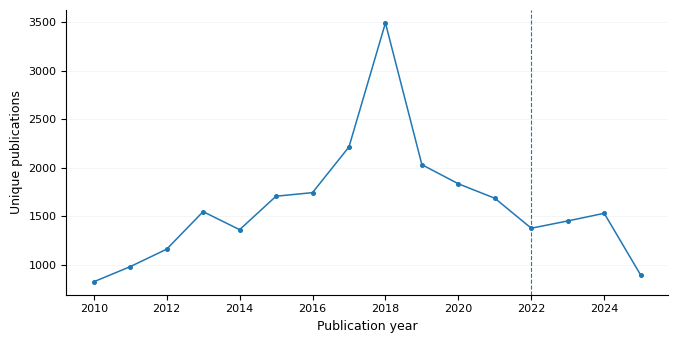

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/figures/Fig2_future_productivity_distribution_2023_2025.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/figures/Fig2_future_productivity_distribution_2023_2025.png


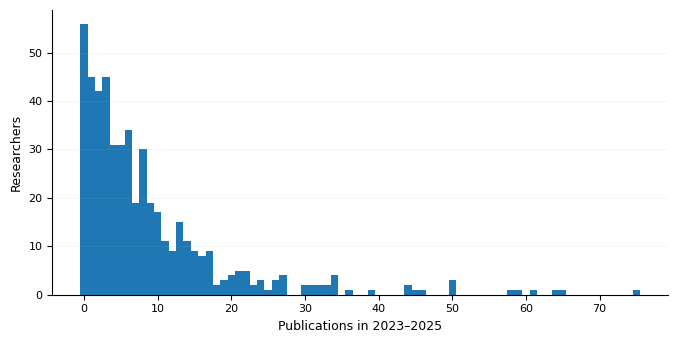

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/figures/Fig3_past_vs_future_productivity.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/figures/Fig3_past_vs_future_productivity.png


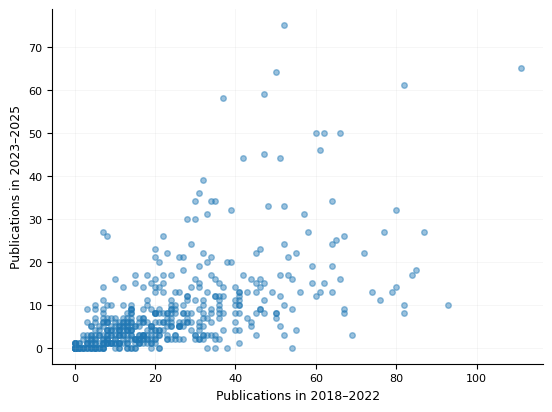


TABLE 1F — FINAL PANEL AUDIT
 panel_rows  unique_authors  duplicate_author_rows  required_features_missing  any_na_in_required_features  outcome_nonnegative  all_graph_nodes_retained  model_ready
        500             500                      0                          0                        False                 True                      True         True


,panel_rows,unique_authors,duplicate_author_rows,required_features_missing,any_na_in_required_features,outcome_nonnegative,all_graph_nodes_retained,model_ready
0,500,500,0,0,False,True,True,True



ARQUIVOS PRINCIPAIS SALVOS
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/panel_cohort2022_2018_2022_to_2023_2025.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/panel_model_ready.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/prospective_panel.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/feature_manifest.json
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/tables/Table_0_identifier_role_audit.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/tables/Table_1A_cohort_audit.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/tables/Table_1B_temporal_coverage.csv
/content/drive/

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.6 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL — VERSÃO CORRIGIDA
========================================================================

Artigo:
Do Collaboration Graph Features Predict Future Scientific Productivity?
A Leakage-Aware Temporal Evaluation in Brazilian Information Science

Correções centrais desta versão
-------------------------------
1. Os IDs OpenAlex são URLs completas:
      https://openalex.org/A...
   e não strings que começam diretamente por "A".
2. Em producoes_final.xlsx:
      autor_id     = ID OpenAlex do AUTOR (A...)
      id_openalex  = ID OpenAlex do TRABALHO (W...)
3. Em autores_final.xlsx:
      id_openalex  = ID OpenAlex do AUTOR (A...)
4. O script gera explicitamente os nomes de features esperados pela etapa de modelagem:
      past_works_2018_2022
      past_active_years_2018_2022
      recent_works_2021_2022
      past_productivity_slope
5. Mantém pesquisadores isolados na rede.
6. Mostra tabelas/figuras no Colab e salva todos os artefatos no Drive.
7. Evita erro quando o Drive já está montado.
8. Exporta figuras em EPS + PNG 600 dpi, sem título embutido.

Execução
--------
%run /content/Parte_18_6_Coorte2022_PainelProspectivo_CORRIGIDO.py
"""

from __future__ import annotations

import os
import re
import json
import math
import pickle
import sys
import importlib
from pathlib import Path
from itertools import combinations

# ======================================================================================
# 0. GOOGLE DRIVE
# ======================================================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

if not DRIVE_ROOT.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        raise RuntimeError(f"Não foi possível montar o Google Drive: {e}") from e
else:
    print("Google Drive já está montado em /content/drive.")

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("openpyxl")
ensure("networkx")
ensure("matplotlib")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CONFIGURAÇÃO
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")

PUB_PATH = ROOT / "runs/run_20260625_200032/input/producoes_final.xlsx"
AUTH_PATH = ROOT / "runs/run_20260625_200032/input/autores_final.xlsx"

OUT = ROOT / "runs/temporal_productivity_20260929/06_cohort2022_prospective_panel"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"

for d in [OUT, TAB, FIG, ART]:
    d.mkdir(parents=True, exist_ok=True)

FEATURE_START = 2018
FEATURE_END = 2022
OUTCOME_START = 2023
OUTCOME_END = 2025

RECENT_START = 2021
RECENT_END = 2022

HISTORY_FEATURES = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
    "past_productivity_slope",
]

GRAPH_FEATURES = [
    "degree",
    "strength",
    "avg_tie_strength",
    "weighted_clustering",
    "pagerank",
    "betweenness",
    "core_number",
    "avg_neighbor_degree",
    "component_size",
    "is_isolate",
]

PRIMARY_OUTCOME = "future_works_2023_2025"

for p in [PUB_PATH, AUTH_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

# ======================================================================================
# 3. FUNÇÕES AUXILIARES
# ======================================================================================

def show_df(title, df, max_rows=40):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    if len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... {len(df):,} linhas no total")
    if display is not None:
        display(df.head(max_rows))

def extract_openalex_author_id(value):
    """
    Aceita:
      A5074151918
      https://openalex.org/A5074151918
      https://api.openalex.org/authors/A5074151918
      strings com o A-id embutido
    Retorna sempre A########## em maiúsculas.
    """
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    m = re.search(r"(?<![A-Za-z0-9])(A\d+)(?!\d)", s, flags=re.I)
    if m:
        return m.group(1).upper()
    return np.nan

def extract_openalex_work_id(value):
    """
    Aceita URL OpenAlex ou W-id cru e retorna W##########.
    """
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    m = re.search(r"(?<![A-Za-z0-9])(W\d+)(?!\d)", s, flags=re.I)
    if m:
        return m.group(1).upper()
    return np.nan

def clean_doi(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if not s or s in {"nan", "none"}:
        return np.nan
    s = re.sub(r"^https?://(dx\.)?doi\.org/", "", s)
    s = s.strip()
    return s if re.search(r"10\.\d{4,9}/", s) else np.nan

def clean_title(value):
    if pd.isna(value):
        return ""
    s = str(value).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[^\w\s]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def productivity_slope(author_year_counts, years):
    """
    Inclui anos sem publicação como zero.
    """
    y = np.array([author_year_counts.get(int(yr), 0) for yr in years], dtype=float)
    x = np.array(list(years), dtype=float)
    if len(x) < 2:
        return 0.0
    x = x - x.mean()
    denom = np.sum(x * x)
    if denom == 0:
        return 0.0
    return float(np.sum(x * (y - y.mean())) / denom)

def graph_features(G):
    nodes = list(G.nodes())
    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))

    H = G.copy()
    for u, v, d in H.edges(data=True):
        w = float(d.get("weight", 1.0))
        d["distance"] = 1.0 / w if w > 0 else 1.0

    if G.number_of_edges() > 0:
        clustering = nx.clustering(G, weight="weight")
        pagerank = nx.pagerank(G, weight="weight")
        avg_neighbor_degree = nx.average_neighbor_degree(G, weight="weight")
        betweenness = nx.betweenness_centrality(
            H, weight="distance", normalized=True
        )
        core = nx.core_number(G)
    else:
        clustering = {n: 0.0 for n in nodes}
        pagerank = {n: 0.0 for n in nodes}
        avg_neighbor_degree = {n: 0.0 for n in nodes}
        betweenness = {n: 0.0 for n in nodes}
        core = {n: 0 for n in nodes}

    comp_size = {}
    for comp in nx.connected_components(G):
        n_comp = len(comp)
        for n in comp:
            comp_size[n] = n_comp

    rows = []
    for n in nodes:
        k = int(degree.get(n, 0))
        s = float(strength.get(n, 0.0))
        rows.append({
            "author_key": n,
            "degree": k,
            "strength": s,
            "avg_tie_strength": (s / k) if k > 0 else 0.0,
            "weighted_clustering": float(clustering.get(n, 0.0)),
            "pagerank": float(pagerank.get(n, 0.0)),
            "betweenness": float(betweenness.get(n, 0.0)),
            "core_number": int(core.get(n, 0)),
            "avg_neighbor_degree": float(avg_neighbor_degree.get(n, 0.0)),
            "component_size": int(comp_size.get(n, 1)),
            "is_isolate": int(k == 0),
        })

    # Sempre retorna as colunas, mesmo se a lista de nós estiver vazia.
    return pd.DataFrame(
        rows,
        columns=["author_key"] + GRAPH_FEATURES
    )

def save_figure(fig, stem):
    eps_path = FIG / f"{stem}.eps"
    png_path = FIG / f"{stem}.png"
    fig.savefig(eps_path, format="eps", bbox_inches="tight")
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    print("[figure]", eps_path)
    print("[figure]", png_path)

# ======================================================================================
# 4. CARREGAR DADOS
# ======================================================================================

print("\n" + "=" * 120)
print("PARTE 18.6 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL — CORRIGIDO")
print("=" * 120)
print("[publications]", PUB_PATH)
print("[authors]     ", AUTH_PATH)
print("[output]      ", OUT)

pub = pd.read_excel(PUB_PATH)
auth = pd.read_excel(AUTH_PATH)

print(f"\nShape publications: {pub.shape}")
print(f"Shape authors:      {auth.shape}")

required_pub_cols = {
    "titulo", "ano", "doi", "id_openalex", "autor_id"
}
required_auth_cols = {
    "nome_pesquisado", "instituicao_original", "id_openalex"
}

missing_pub = sorted(required_pub_cols - set(pub.columns))
missing_auth = sorted(required_auth_cols - set(auth.columns))

if missing_pub:
    raise KeyError(f"Colunas ausentes em producoes_final.xlsx: {missing_pub}")
if missing_auth:
    raise KeyError(f"Colunas ausentes em autores_final.xlsx: {missing_auth}")

# ======================================================================================
# 5. NORMALIZAR IDs CORRETAMENTE
# ======================================================================================

# autores_final.xlsx: id_openalex = autor A...
auth = auth.copy()
auth["author_key"] = auth["id_openalex"].map(extract_openalex_author_id)

# producoes_final.xlsx:
#   autor_id    = autor A...
#   id_openalex = trabalho W...
pub = pub.copy()
pub["author_key"] = pub["autor_id"].map(extract_openalex_author_id)
pub["work_key"] = pub["id_openalex"].map(extract_openalex_work_id)
pub["doi_clean"] = pub["doi"].map(clean_doi)
pub["title_clean"] = pub["titulo"].map(clean_title)
pub["year"] = pd.to_numeric(pub["ano"], errors="coerce")

# Fallback para work_key caso uma linha não tenha W-id.
mask_no_work = pub["work_key"].isna()

pub.loc[
    mask_no_work & pub["doi_clean"].notna(),
    "work_key"
] = "DOI:" + pub.loc[
    mask_no_work & pub["doi_clean"].notna(),
    "doi_clean"
].astype(str)

mask_no_work = pub["work_key"].isna()

pub.loc[
    mask_no_work & pub["title_clean"].ne("") & pub["year"].notna(),
    "work_key"
] = (
    "TY:"
    + pub.loc[
        mask_no_work & pub["title_clean"].ne("") & pub["year"].notna(),
        "title_clean"
    ].astype(str)
    + "|"
    + pub.loc[
        mask_no_work & pub["title_clean"].ne("") & pub["year"].notna(),
        "year"
    ].astype("Int64").astype(str)
)

# Auditoria dos IDs.
id_audit = pd.DataFrame([
    {
        "dataset": "authors_final",
        "source_column": "id_openalex",
        "raw_rows": len(auth),
        "nonmissing_source": int(auth["id_openalex"].notna().sum()),
        "extractable_author_A_ids": int(auth["author_key"].notna().sum()),
        "unique_author_A_ids": int(auth["author_key"].nunique(dropna=True)),
        "extractable_work_W_ids": np.nan,
    },
    {
        "dataset": "producoes_final",
        "source_column": "autor_id",
        "raw_rows": len(pub),
        "nonmissing_source": int(pub["autor_id"].notna().sum()),
        "extractable_author_A_ids": int(pub["author_key"].notna().sum()),
        "unique_author_A_ids": int(pub["author_key"].nunique(dropna=True)),
        "extractable_work_W_ids": np.nan,
    },
    {
        "dataset": "producoes_final",
        "source_column": "id_openalex",
        "raw_rows": len(pub),
        "nonmissing_source": int(pub["id_openalex"].notna().sum()),
        "extractable_author_A_ids": np.nan,
        "unique_author_A_ids": np.nan,
        "extractable_work_W_ids": int(
            pub["id_openalex"].map(extract_openalex_work_id).notna().sum()
        ),
    },
])

id_audit.to_csv(TAB / "Table_0_identifier_role_audit.csv", index=False)
show_df("TABLE 0 — IDENTIFIER ROLE AUDIT", id_audit)

# Segurança: não continuar com coorte vazia.
unique_valid_authors = int(auth["author_key"].nunique(dropna=True))
if unique_valid_authors < 100:
    samples = auth["id_openalex"].dropna().astype(str).head(10).tolist()
    raise RuntimeError(
        "Falha ao extrair IDs OpenAlex de autores. "
        f"Foram encontrados apenas {unique_valid_authors} IDs únicos. "
        f"Amostra da coluna id_openalex: {samples}"
    )

# ======================================================================================
# 6. DEFINIR COORTE 2022
# ======================================================================================

# Uma linha por OpenAlex Author ID.
cohort = (
    auth[auth["author_key"].notna()]
    .sort_values(["author_key", "nome_pesquisado"])
    .drop_duplicates("author_key", keep="first")
    [
        [
            "author_key",
            "nome_pesquisado",
            "instituicao_original",
            "nome_openalex",
            "total_publicacoes",
            "total_citacoes",
        ]
    ]
    .copy()
)

cohort_ids = set(cohort["author_key"])

pub_valid = pub[
    pub["author_key"].notna()
    & pub["work_key"].notna()
    & pub["year"].between(1900, 2030)
].copy()

pub_valid["year"] = pub_valid["year"].astype(int)

pub_author_ids = set(pub_valid["author_key"].unique())
linked_ids = cohort_ids & pub_author_ids

cohort_audit = pd.DataFrame([{
    "raw_author_rows": int(len(auth)),
    "nonmissing_openalex_rows": int(auth["id_openalex"].notna().sum()),
    "valid_openalex_author_rows": int(auth["author_key"].notna().sum()),
    "unique_resolved_authors": int(len(cohort_ids)),
    "unique_resolved_authors_found_in_publications": int(len(linked_ids)),
    "publication_linkage_pct": float(
        100 * len(linked_ids) / max(1, len(cohort_ids))
    ),
    "feature_period": f"{FEATURE_START}-{FEATURE_END}",
    "outcome_period": f"{OUTCOME_START}-{OUTCOME_END}",
}])

cohort_audit.to_csv(TAB / "Table_1A_cohort_audit.csv", index=False)
show_df("TABLE 1A — COHORT AUDIT", cohort_audit)

# Auditoria crítica.
if cohort_audit.loc[0, "publication_linkage_pct"] < 90:
    raise RuntimeError(
        "A ligação autor↔publicação ficou abaixo de 90%. "
        "Interrompendo para evitar um painel incorreto."
    )

# ======================================================================================
# 7. TABELA LONGA AUTOR–TRABALHO
# ======================================================================================

long_df = (
    pub_valid[
        ["author_key", "work_key", "year", "tipo", "citations"]
    ]
    .drop_duplicates(["author_key", "work_key"])
    .copy()
)

# Apenas autores da coorte 2022.
long_cohort = long_df[long_df["author_key"].isin(cohort_ids)].copy()

coverage = pd.DataFrame([{
    "cohort_authors": int(len(cohort_ids)),
    "author_work_rows": int(len(long_cohort)),
    "unique_works_all_years": int(long_cohort["work_key"].nunique()),
    "min_publication_year": int(long_cohort["year"].min()),
    "max_publication_year": int(long_cohort["year"].max()),
    "works_feature_period": int(
        long_cohort.loc[
            long_cohort["year"].between(FEATURE_START, FEATURE_END),
            "work_key"
        ].nunique()
    ),
    "works_outcome_period": int(
        long_cohort.loc[
            long_cohort["year"].between(OUTCOME_START, OUTCOME_END),
            "work_key"
        ].nunique()
    ),
    "authors_with_feature_period_output": int(
        long_cohort.loc[
            long_cohort["year"].between(FEATURE_START, FEATURE_END),
            "author_key"
        ].nunique()
    ),
    "authors_with_outcome_period_output": int(
        long_cohort.loc[
            long_cohort["year"].between(OUTCOME_START, OUTCOME_END),
            "author_key"
        ].nunique()
    ),
}])

coverage.to_csv(TAB / "Table_1B_temporal_coverage.csv", index=False)
show_df("TABLE 1B — TEMPORAL COVERAGE", coverage)

# ======================================================================================
# 8. FEATURES HISTÓRICAS DE PRODUTIVIDADE
# ======================================================================================

feature_long = long_cohort[
    long_cohort["year"].between(FEATURE_START, FEATURE_END)
].copy()

recent_long = long_cohort[
    long_cohort["year"].between(RECENT_START, RECENT_END)
].copy()

outcome_long = long_cohort[
    long_cohort["year"].between(OUTCOME_START, OUTCOME_END)
].copy()

past = (
    feature_long
    .groupby("author_key")
    .agg(
        past_works_2018_2022=("work_key", "nunique"),
        past_active_years_2018_2022=("year", "nunique"),
    )
    .reset_index()
)

recent = (
    recent_long
    .groupby("author_key")
    .agg(
        recent_works_2021_2022=("work_key", "nunique")
    )
    .reset_index()
)

future = (
    outcome_long
    .groupby("author_key")
    .agg(
        future_works_2023_2025=("work_key", "nunique"),
        future_active_years_2023_2025=("year", "nunique"),
    )
    .reset_index()
)

# Slope anual 2018–2022.
annual_counts = (
    feature_long
    .groupby(["author_key", "year"])["work_key"]
    .nunique()
    .reset_index(name="n_works")
)

annual_map = {}
for author_key, g in annual_counts.groupby("author_key"):
    annual_map[author_key] = dict(zip(g["year"], g["n_works"]))

slope_rows = []
years_feature = range(FEATURE_START, FEATURE_END + 1)

for author_key in cohort["author_key"]:
    slope_rows.append({
        "author_key": author_key,
        "past_productivity_slope": productivity_slope(
            annual_map.get(author_key, {}),
            years_feature
        )
    })

slopes = pd.DataFrame(slope_rows)

# ======================================================================================
# 9. REDE DE COAUTORIA HISTÓRICA 2018–2022
# ======================================================================================

G = nx.Graph()
G.add_nodes_from(sorted(cohort_ids))

# Agrupa autores da coorte que aparecem em cada publicação.
work_authors = (
    feature_long[
        ["work_key", "author_key"]
    ]
    .drop_duplicates()
    .groupby("work_key")["author_key"]
    .apply(lambda s: sorted(set(s)))
)

n_multi_author_works = 0

for authors_in_work in work_authors:
    if len(authors_in_work) < 2:
        continue

    n_multi_author_works += 1

    for u, v in combinations(authors_in_work, 2):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1.0
        else:
            G.add_edge(u, v, weight=1.0)

gf = graph_features(G)

if gf.empty and len(cohort_ids) > 0:
    raise RuntimeError(
        "A coorte contém autores, mas a tabela de graph features ficou vazia. "
        "Isso não deveria ocorrer nesta versão."
    )

components = list(nx.connected_components(G))
largest_component = max((len(c) for c in components), default=0)

graph_summary = pd.DataFrame([{
    "feature_period": f"{FEATURE_START}-{FEATURE_END}",
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
    "isolates": int(nx.number_of_isolates(G)),
    "connected_components": int(nx.number_connected_components(G)),
    "largest_component_n": int(largest_component),
    "largest_component_pct": float(
        100 * largest_component / max(1, G.number_of_nodes())
    ),
    "multi_cohort_author_works": int(n_multi_author_works),
    "total_edge_weight": float(
        sum(d.get("weight", 1.0) for _, _, d in G.edges(data=True))
    ),
}])

graph_summary.to_csv(TAB / "Table_1C_network_summary.csv", index=False)
show_df("TABLE 1C — HISTORICAL NETWORK SUMMARY", graph_summary)

with open(ART / "graph_2018_2022_full_cohort.pkl", "wb") as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

# ======================================================================================
# 10. MONTAR PAINEL FINAL
# ======================================================================================

panel = cohort.copy()

panel = panel.merge(
    past,
    on="author_key",
    how="left",
    validate="one_to_one"
)

panel = panel.merge(
    recent,
    on="author_key",
    how="left",
    validate="one_to_one"
)

panel = panel.merge(
    slopes,
    on="author_key",
    how="left",
    validate="one_to_one"
)

panel = panel.merge(
    gf,
    on="author_key",
    how="left",
    validate="one_to_one"
)

panel = panel.merge(
    future,
    on="author_key",
    how="left",
    validate="one_to_one"
)

zero_cols = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
    "past_productivity_slope",
    "future_works_2023_2025",
    "future_active_years_2023_2025",
] + GRAPH_FEATURES

for c in zero_cols:
    if c not in panel.columns:
        panel[c] = 0.0
    panel[c] = pd.to_numeric(panel[c], errors="coerce").fillna(0)

# Tipos inteiros quando apropriado.
int_cols = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
    "future_works_2023_2025",
    "future_active_years_2023_2025",
    "degree",
    "core_number",
    "component_size",
    "is_isolate",
]

for c in int_cols:
    panel[c] = panel[c].astype(int)

# Aliases de compatibilidade com scripts posteriores.
panel["past_works"] = panel["past_works_2018_2022"]
panel["past_active_years"] = panel["past_active_years_2018_2022"]
panel["recent_works"] = panel["recent_works_2021_2022"]
panel["future_works"] = panel["future_works_2023_2025"]
panel["outcome_works_2023_2025"] = panel["future_works_2023_2025"]

# Aliases temporais das graph features, caso algum script posterior use sufixo.
for c in GRAPH_FEATURES:
    panel[f"{c}_2018_2022"] = panel[c]

panel["feature_period"] = f"{FEATURE_START}-{FEATURE_END}"
panel["outcome_period"] = f"{OUTCOME_START}-{OUTCOME_END}"

# ======================================================================================
# 11. AUDITORIA FORMAL DAS FEATURES ESPERADAS
# ======================================================================================

required_for_model = HISTORY_FEATURES + GRAPH_FEATURES + [PRIMARY_OUTCOME]
missing_required = [c for c in required_for_model if c not in panel.columns]

feature_audit_rows = []

for c in required_for_model:
    if c in panel.columns:
        feature_audit_rows.append({
            "feature": c,
            "present": True,
            "dtype": str(panel[c].dtype),
            "missing_n": int(panel[c].isna().sum()),
            "n_unique": int(panel[c].nunique(dropna=True)),
            "min": float(panel[c].min()) if pd.api.types.is_numeric_dtype(panel[c]) else np.nan,
            "median": float(panel[c].median()) if pd.api.types.is_numeric_dtype(panel[c]) else np.nan,
            "max": float(panel[c].max()) if pd.api.types.is_numeric_dtype(panel[c]) else np.nan,
        })
    else:
        feature_audit_rows.append({
            "feature": c,
            "present": False,
            "dtype": "",
            "missing_n": np.nan,
            "n_unique": np.nan,
            "min": np.nan,
            "median": np.nan,
            "max": np.nan,
        })

feature_audit = pd.DataFrame(feature_audit_rows)

feature_audit.to_csv(TAB / "Table_1D_model_feature_audit.csv", index=False)
show_df("TABLE 1D — MODEL FEATURE AUDIT", feature_audit, max_rows=100)

if missing_required:
    raise KeyError(
        "Ainda faltam features obrigatórias após a construção do painel: "
        f"{missing_required}"
    )

# ======================================================================================
# 12. RESUMO DO DESFECHO
# ======================================================================================

y = panel[PRIMARY_OUTCOME]

outcome_summary = pd.DataFrame([{
    "n_authors": int(len(panel)),
    "outcome": PRIMARY_OUTCOME,
    "zero_outcome_n": int((y == 0).sum()),
    "zero_outcome_pct": float(100 * (y == 0).mean()),
    "mean": float(y.mean()),
    "sd": float(y.std(ddof=1)),
    "median": float(y.median()),
    "p25": float(y.quantile(0.25)),
    "p75": float(y.quantile(0.75)),
    "p90": float(y.quantile(0.90)),
    "p95": float(y.quantile(0.95)),
    "max": float(y.max()),
    "variance": float(y.var(ddof=1)),
    "variance_to_mean": float(
        y.var(ddof=1) / y.mean()
    ) if y.mean() > 0 else np.nan,
}])

outcome_summary.to_csv(TAB / "Table_1E_outcome_summary.csv", index=False)
show_df("TABLE 1E — OUTCOME SUMMARY", outcome_summary)

# ======================================================================================
# 13. COBERTURA ANUAL
# ======================================================================================

annual = (
    long_cohort[
        long_cohort["year"].between(2010, 2025)
    ]
    .groupby("year")
    .agg(
        unique_works=("work_key", "nunique"),
        active_authors=("author_key", "nunique"),
    )
    .reset_index()
)

annual.to_csv(TAB / "annual_coverage_2010_2025.csv", index=False)
show_df("ANNUAL COVERAGE 2010–2025", annual, max_rows=30)

# ======================================================================================
# 14. FIGURAS — PRONTAS PARA SPRINGER/SCIENTOMETRICS
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "ps.fonttype": 42,
    "pdf.fonttype": 42,
})

# Fig. 1 — cobertura anual.
fig, ax = plt.subplots(figsize=(6.85, 3.5))
ax.plot(
    annual["year"],
    annual["unique_works"],
    marker="o",
    markersize=2.6,
    linewidth=1.1
)
ax.axvline(2022, linestyle="--", linewidth=0.8)
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique publications")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig1_annual_publication_coverage_2010_2025")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 2 — desfecho.
fig, ax = plt.subplots(figsize=(6.85, 3.5))
bins = np.arange(0, int(y.max()) + 2) - 0.5
ax.hist(y, bins=bins)
ax.set_xlabel("Publications in 2023–2025")
ax.set_ylabel("Researchers")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig2_future_productivity_distribution_2023_2025")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 3 — produtividade passada vs futura, diagnóstico visual apenas.
fig, ax = plt.subplots(figsize=(5.6, 4.2))
ax.scatter(
    panel["past_works_2018_2022"],
    panel["future_works_2023_2025"],
    alpha=0.45,
    s=16
)
ax.set_xlabel("Publications in 2018–2022")
ax.set_ylabel("Publications in 2023–2025")
ax.grid(alpha=0.15, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig3_past_vs_future_productivity")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 15. SALVAR PAINEL EM NOMES COMPATÍVEIS
# ======================================================================================

panel_main = OUT / "panel_cohort2022_2018_2022_to_2023_2025.csv"
panel_model = OUT / "panel_model_ready.csv"
panel_alt = OUT / "prospective_panel.csv"

panel.to_csv(panel_main, index=False)
panel.to_csv(panel_model, index=False)
panel.to_csv(panel_alt, index=False)

# Também em Parquet se pyarrow estiver disponível.
try:
    ensure("pyarrow")
    panel.to_parquet(
        OUT / "panel_model_ready.parquet",
        index=False
    )
except Exception as e:
    print("[parquet] Não foi possível salvar Parquet:", repr(e))

# Manifesto para os scripts seguintes.
manifest = {
    "article": (
        "Do Collaboration Graph Features Predict Future Scientific Productivity? "
        "A Leakage-Aware Temporal Evaluation in Brazilian Information Science"
    ),
    "cohort_reference_year": 2022,
    "feature_period": [FEATURE_START, FEATURE_END],
    "outcome_period": [OUTCOME_START, OUTCOME_END],
    "history_features": HISTORY_FEATURES,
    "graph_features": GRAPH_FEATURES,
    "primary_outcome": PRIMARY_OUTCOME,
    "panel_file": str(panel_model),
    "n_authors": int(len(panel)),
    "author_id_source": "autores_final.id_openalex -> OpenAlex A-id",
    "publication_author_id_source": "producoes_final.autor_id -> OpenAlex A-id",
    "publication_work_id_source": "producoes_final.id_openalex -> OpenAlex W-id",
}

(OUT / "feature_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# ======================================================================================
# 16. FINAL AUDIT
# ======================================================================================

final_audit = pd.DataFrame([{
    "panel_rows": int(len(panel)),
    "unique_authors": int(panel["author_key"].nunique()),
    "duplicate_author_rows": int(panel["author_key"].duplicated().sum()),
    "required_features_missing": len(missing_required),
    "any_na_in_required_features": bool(
        panel[required_for_model].isna().any().any()
    ),
    "outcome_nonnegative": bool((panel[PRIMARY_OUTCOME] >= 0).all()),
    "all_graph_nodes_retained": bool(
        len(panel) == G.number_of_nodes()
    ),
    "model_ready": bool(
        len(panel) > 0
        and len(missing_required) == 0
        and not panel[required_for_model].isna().any().any()
        and panel["author_key"].duplicated().sum() == 0
    ),
}])

final_audit.to_csv(TAB / "Table_1F_final_panel_audit.csv", index=False)
show_df("TABLE 1F — FINAL PANEL AUDIT", final_audit)

if not bool(final_audit.loc[0, "model_ready"]):
    raise RuntimeError(
        "O painel não passou no audit final. "
        "Não execute a etapa de modelagem ainda."
    )

# ======================================================================================
# 17. README
# ======================================================================================

readme = f"""
PARTE 18.6 — COORTE 2022 E PAINEL PREDITIVO TEMPORAL — CORRIGIDO
=================================================================

Correção de IDs
---------------
autores_final.id_openalex
  -> OpenAlex Author ID A...

producoes_final.autor_id
  -> OpenAlex Author ID A...

producoes_final.id_openalex
  -> OpenAlex Work ID W...

Cohort
------
Reference year: 2022
Unique resolved authors in panel: {len(panel)}

Feature window
--------------
2018–2022

Outcome window
--------------
2023–2025

Primary historical features
---------------------------
{HISTORY_FEATURES}

Primary graph features
----------------------
{GRAPH_FEATURES}

Primary outcome
---------------
{PRIMARY_OUTCOME}

Model-ready file
----------------
{panel_model}

Important
---------
The panel contains the exact feature names expected by the next modeling stage:
- past_works_2018_2022
- past_active_years_2018_2022
- recent_works_2021_2022
- past_productivity_slope

It also contains generic aliases and 2018_2022-suffixed aliases for graph features
to maximize compatibility with downstream scripts.

All isolates are retained.
No outcome information from 2023–2025 is used in the construction of graph features.
""".strip()

(OUT / "README.txt").write_text(readme, encoding="utf-8")

# ======================================================================================
# 18. IMPRESSÃO FINAL
# ======================================================================================

print("\n" + "=" * 120)
print("ARQUIVOS PRINCIPAIS SALVOS")
print("=" * 120)
print(panel_main)
print(panel_model)
print(panel_alt)
print(OUT / "feature_manifest.json")
print(TAB / "Table_0_identifier_role_audit.csv")
print(TAB / "Table_1A_cohort_audit.csv")
print(TAB / "Table_1B_temporal_coverage.csv")
print(TAB / "Table_1C_network_summary.csv")
print(TAB / "Table_1D_model_feature_audit.csv")
print(TAB / "Table_1E_outcome_summary.csv")
print(TAB / "Table_1F_final_panel_audit.csv")
print(ART / "graph_2018_2022_full_cohort.pkl")
print(FIG / "Fig1_annual_publication_coverage_2010_2025.eps")
print(FIG / "Fig2_future_productivity_distribution_2023_2025.eps")
print(FIG / "Fig3_past_vs_future_productivity.eps")

print("\n" + "=" * 120)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 120)
print("1) TABLE 0 — IDENTIFIER ROLE AUDIT")
print("2) TABLE 1A — COHORT AUDIT")
print("3) TABLE 1B — TEMPORAL COVERAGE")
print("4) TABLE 1C — HISTORICAL NETWORK SUMMARY")
print("5) TABLE 1D — MODEL FEATURE AUDIT")
print("6) TABLE 1E — OUTCOME SUMMARY")
print("7) TABLE 1F — FINAL PANEL AUDIT")

print("\nCONCLUÍDO COM SUCESSO.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.7 — MODELAGEM PROSPECTIVA LEAKAGE-AWARE
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/panel_model_ready.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[authors]      /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/autores_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling

Panel shape: (500, 39)
Publication shape: (38138, 9)
Authors shape: (543, 7)

TABLE 2A — OUTCOME HORIZON QC
 works_2024  works_2025  works_2025_as_pct_of_2024  active_authors_2024  active_authors_2025  active_authors_2025_as_pct_of_2024        primary_outcome    sensitivity_outcome                                                                              

,works_2024,works_2025,works_2025_as_pct_of_2024,active_authors_2024,active_authors_2025,active_authors_2025_as_pct_of_2024,primary_outcome,sensitivity_outcome,primary_reason
0,1529.0,893.0,58.404186,376.0,240.0,63.829787,future_works_2023_2024,future_works_2023_2025,2025 is treated as potentially right-truncated...



TABLE 2B — OUTCOME SUMMARY
               outcome   n  zero_n  zero_pct  mean        sd  median  p25  p75  p90   p95  max   variance  variance_to_mean
future_works_2023_2024 500      63      12.6 6.810  7.574209     5.0  2.0  9.0 15.0 22.00 57.0  57.368637          8.424176
future_works_2023_2025 500      56      11.2 8.692 10.701316     5.5  2.0 11.0 20.1 30.05 75.0 114.518172         13.175123


,outcome,n,zero_n,zero_pct,mean,sd,median,p25,p75,p90,p95,max,variance,variance_to_mean
0,future_works_2023_2024,500,63,12.6,6.810,7.574209,5.0,2.0,9.0,15.0,22.00,57.0,57.368637,8.424176
1,future_works_2023_2025,500,56,11.2,8.692,10.701316,5.5,2.0,11.0,20.1,30.05,75.0,114.518172,13.175123



NESTED 10-FOLD CV — HISTORY ONLY
  [history_poisson] fold 01: alpha=0.0001 | MAE=4.778 | RMSE=8.547
  [history_poisson] fold 02: alpha=0.1 | MAE=3.566 | RMSE=4.851
  [history_poisson] fold 03: alpha=0.1 | MAE=3.523 | RMSE=6.835
  [history_poisson] fold 04: alpha=0.1 | MAE=3.571 | RMSE=6.237
  [history_poisson] fold 05: alpha=0.1 | MAE=4.489 | RMSE=6.848
  [history_poisson] fold 06: alpha=1 | MAE=3.383 | RMSE=4.633
  [history_poisson] fold 07: alpha=0.1 | MAE=4.053 | RMSE=9.204
  [history_poisson] fold 08: alpha=0.1 | MAE=3.757 | RMSE=5.019
  [history_poisson] fold 09: alpha=0.1 | MAE=3.777 | RMSE=6.093
  [history_poisson] fold 10: alpha=0.1 | MAE=4.061 | RMSE=5.309

NESTED 10-FOLD CV — GRAPH ONLY
  [graph_poisson] fold 01: alpha=0.1 | MAE=6.311 | RMSE=10.435
  [graph_poisson] fold 02: alpha=0.1 | MAE=4.994 | RMSE=6.669
  [graph_poisson] fold 03: alpha=1 | MAE=4.397 | RMSE=7.747
  [graph_poisson] fold 04: alpha=1 | MAE=4.440 | RMSE=5.589
  [graph_poisson] fold 05: alpha=0.01 | MAE=6.91

...


TABLE 7B — GROUPKFOLD INCREMENT
  institution_column  n_groups  n_splits  delta_R2_combined_minus_history  delta_MAE_history_minus_combined
instituicao_original        24         5                          0.09643                         -0.020714


,institution_column,n_groups,n_splits,delta_R2_combined_minus_history,delta_MAE_history_minus_combined
0,instituicao_original,24,5,0.09643,-0.020714



TABLE 8 — STANDARDIZED POISSON COEFFICIENTS
                    feature   block  standardized_log_rate_coefficient  abs_coefficient
past_active_years_2018_2022 history                           0.354215         0.354215
       past_works_2018_2022 history                           0.293341         0.293341
     recent_works_2021_2022 history                           0.142469         0.142469
           avg_tie_strength   graph                           0.131239         0.131239
                 is_isolate   graph                           0.097055         0.097055
                     degree   graph                           0.089630         0.089630
                   strength   graph                          -0.079624         0.079624
                   pagerank   graph                          -0.076835         0.076835
        avg_neighbor_degree   graph                          -0.032919         0.032919
                betweenness   graph                           0.026217     

,feature,block,standardized_log_rate_coefficient,abs_coefficient
1,past_active_years_2018_2022,history,0.354215,0.354215
0,past_works_2018_2022,history,0.293341,0.293341
2,recent_works_2021_2022,history,0.142469,0.142469
5,avg_tie_strength,graph,0.131239,0.131239
12,is_isolate,graph,0.097055,0.097055
3,degree,graph,0.089630,0.089630
4,strength,graph,-0.079624,0.079624
7,pagerank,graph,-0.076835,0.076835
10,avg_neighbor_degree,graph,-0.032919,0.032919
8,betweenness,graph,0.026217,0.026217


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig4_observed_vs_predicted_primary.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig4_observed_vs_predicted_primary.png


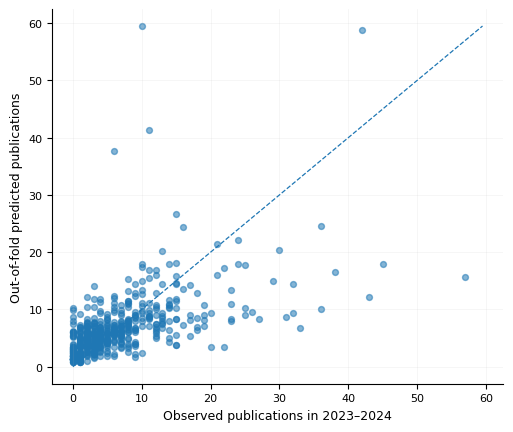

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig5_model_comparison_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig5_model_comparison_MAE.png


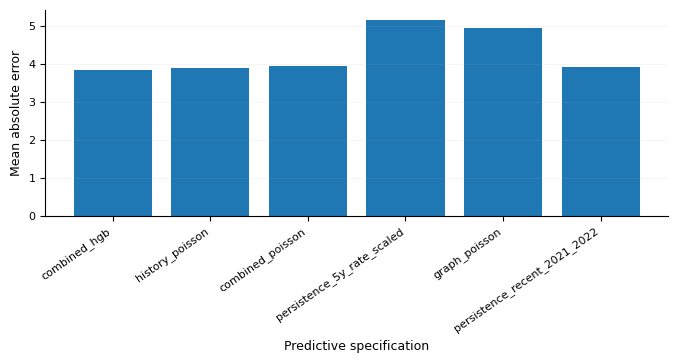

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig6_incremental_graph_value_bootstrap_R2.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig6_incremental_graph_value_bootstrap_R2.png


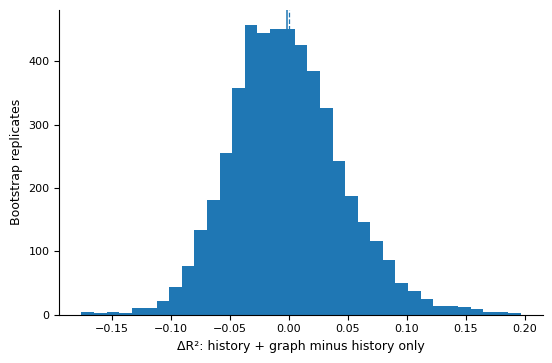

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig7_top_standardized_coefficients.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/Fig7_top_standardized_coefficients.png


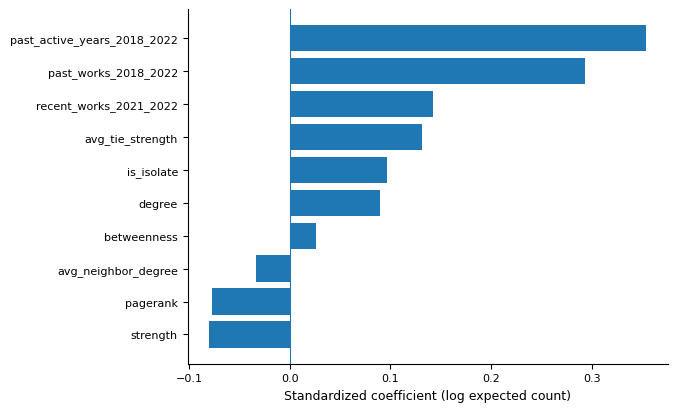

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/FigS1_negative_control_graph_permutation.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/figures/FigS1_negative_control_graph_permutation.png


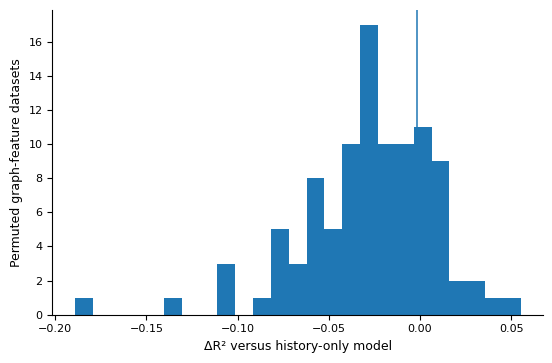


TABLE 9 — MANUSCRIPT-READY SUMMARY
       primary_outcome  n_researchers  history_R2  combined_R2  delta_R2  history_MAE  combined_MAE  delta_MAE_history_minus_combined  history_RMSE  combined_RMSE  delta_RMSE_history_minus_combined  bootstrap_delta_R2_ci_low  bootstrap_delta_R2_ci_high  negative_control_empirical_p_R2 best_primary_model_by_poisson_deviance
future_works_2023_2024            500    0.256326     0.254856  -0.00147     3.895854      3.944391                         -0.048537      6.525202       6.531648                          -0.006446                  -0.087499                     0.10049                         0.227723                           combined_hgb


,primary_outcome,n_researchers,history_R2,combined_R2,delta_R2,history_MAE,combined_MAE,delta_MAE_history_minus_combined,history_RMSE,combined_RMSE,delta_RMSE_history_minus_combined,bootstrap_delta_R2_ci_low,bootstrap_delta_R2_ci_high,negative_control_empirical_p_R2,best_primary_model_by_poisson_deviance
0,future_works_2023_2024,500,0.256326,0.254856,-0.00147,3.895854,3.944391,-0.048537,6.525202,6.531648,-0.006446,-0.087499,0.10049,0.227723,combined_hgb



ARQUIVOS PRINCIPAIS SALVOS
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/tables/Table_2A_outcome_horizon_qc.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/tables/Table_2B_outcome_summary_primary_sensitivity.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/tables/Table_3_primary_predictive_performance.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/tables/Table_4_incremental_graph_value_bootstrap.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/tables/Table_5_negative_control_summary.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling/tables/Table_6_sensitivity_2023_2025_performance.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modelin

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.7 — MODELAGEM PROSPECTIVA LEAKAGE-AWARE
=================================================

Artigo:
Do Collaboration Graph Features Predict Future Scientific Productivity?
A Leakage-Aware Prospective Evaluation in Brazilian Information Science

Esta etapa parte do painel validado na Parte 18.6.

Decisões metodológicas congeladas
---------------------------------
1. Coorte: 500 pesquisadores resolvidos no cutoff de 2022.
2. Features históricas: somente informação de 2018–2022.
3. Desfecho PRIMÁRIO: publicações em 2023–2024.
   Motivo: 2025 apresenta forte sinal de truncamento/indexação incompleta.
4. Sensibilidade: publicações em 2023–2025.
5. Validação principal: nested 10-fold CV entre pesquisadores.
6. Validação adicional: GroupKFold por instituição, se um campo institucional
   confiável estiver disponível no arquivo de autores.
7. Blocos preditivos:
      - persistence baseline
      - history only
      - graph only
      - history + graph
      - history + graph, non-linear benchmark (HistGradientBoosting)
8. Métricas:
      MAE, RMSE, R², mean Poisson deviance e Spearman rho.
9. Valor incremental das features de rede:
      comparação pareada entre history-only e history+graph usando bootstrap
      por pesquisador sobre predições out-of-fold.
10. Negative control:
      permutação das features de rede entre pesquisadores.
11. Output editorial:
      tabelas CSV + figuras EPS/PNG 600 dpi, sem título embutido, além de
      visualização no Colab.

Execução
--------
%run /content/Parte_18_7_Modelagem_Prospectiva_Leakage_Aware.py
"""

from __future__ import annotations

import json
import math
import re
import sys
import pickle
import warnings
import importlib
from pathlib import Path

# ======================================================================================
# 0. GOOGLE DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("openpyxl")
ensure("scipy")
ensure("sklearn", "scikit-learn")
ensure("matplotlib")
ensure("statsmodels")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)
from sklearn.model_selection import (
    KFold,
    GroupKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ======================================================================================
# 2. CAMINHOS E CONFIGURAÇÕES
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
BASE = ROOT / "runs" / "temporal_productivity_20260929"

PART18_6 = BASE / "06_cohort2022_prospective_panel"
PANEL_PATH = PART18_6 / "panel_model_ready.csv"

PUB_PATH = ROOT / "runs/run_20260625_200032/input/producoes_final.xlsx"
AUTH_PATH = ROOT / "runs/run_20260625_200032/input/autores_final.xlsx"

OUT = BASE / "07_prospective_modeling"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"

for d in [OUT, TAB, FIG, ART]:
    d.mkdir(parents=True, exist_ok=True)

for p in [PANEL_PATH, PUB_PATH, AUTH_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

SEED = 20260929

PRIMARY_OUTCOME = "future_works_2023_2024"
SENSITIVITY_OUTCOME = "future_works_2023_2025"

# Primary history block deliberately excludes past_productivity_slope.
# The annual coverage audit shows a marked 2018 peak followed by declining counts,
# so the slope may partially encode database-year coverage rather than researcher change.
HISTORY = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
]

HISTORY_SLOPE_SENSITIVITY = HISTORY + [
    "past_productivity_slope",
]

GRAPH = [
    "degree",
    "strength",
    "avg_tie_strength",
    "weighted_clustering",
    "pagerank",
    "betweenness",
    "core_number",
    "avg_neighbor_degree",
    "component_size",
    "is_isolate",
]

COMBINED = HISTORY + GRAPH
COMBINED_SLOPE_SENSITIVITY = HISTORY_SLOPE_SENSITIVITY + GRAPH

ALPHA_GRID = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]

# Grid deliberadamente contido para manter o laboratório reprodutível e manejável.
HGB_GRID = {
    "learning_rate": [0.03, 0.07],
    "max_iter": [200, 400],
    "max_leaf_nodes": [7, 15],
    "l2_regularization": [0.0, 1.0],
}

BOOT_B = 5000
NEGATIVE_CONTROL_PERMUTATIONS = 100

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def show_df(name, df, max_rows=50):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if len(df) > max_rows:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    else:
        print(df.to_string(index=False))
    if display is not None:
        display(df.head(max_rows))

def safe_poisson_deviance(y, pred):
    pred = np.clip(np.asarray(pred, dtype=float), 1e-9, None)
    return float(mean_poisson_deviance(np.asarray(y, dtype=float), pred))

def metric_row(y, pred, model, outcome, validation="10-fold OOF"):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)

    rho = spearmanr(y, pred).statistic
    if not np.isfinite(rho):
        rho = np.nan

    return {
        "outcome": outcome,
        "validation": validation,
        "model": model,
        "MAE": float(mean_absolute_error(y, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
        "R2": float(r2_score(y, pred)),
        "Poisson_deviance": safe_poisson_deviance(y, pred),
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "mean_observed": float(np.mean(y)),
        "mean_predicted": float(np.mean(pred)),
    }

def make_poisson_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(max_iter=5000, tol=1e-8)),
    ])

def fit_predict_nested_poisson(X, y, outer_cv, groups=None, label=""):
    """
    Nested CV. OOF predictions are generated only from models that did not see
    the target of the held-out researcher.

    If outer_cv is GroupKFold, groups must be supplied.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    pred = np.full(len(y), np.nan, dtype=float)
    best_alphas = []
    fold_rows = []

    split_iter = (
        outer_cv.split(X, y, groups)
        if groups is not None
        else outer_cv.split(X, y)
    )

    for fold, (tr, te) in enumerate(split_iter, start=1):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        # Inner tuning remains researcher-level and is restricted to outer train.
        n_inner = min(5, max(3, len(tr) // 40))
        inner = KFold(n_splits=n_inner, shuffle=True, random_state=SEED + fold)

        search = GridSearchCV(
            estimator=make_poisson_pipeline(),
            param_grid={"model__alpha": ALPHA_GRID},
            scoring="neg_mean_poisson_deviance",
            cv=inner,
            n_jobs=-1,
            refit=True,
        )
        search.fit(Xtr, ytr)

        p = np.clip(search.predict(Xte), 1e-9, None)
        pred[te] = p

        alpha = float(search.best_params_["model__alpha"])
        best_alphas.append(alpha)

        fold_rows.append({
            "model_label": label,
            "fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "best_alpha": alpha,
            "MAE": mean_absolute_error(yte, p),
            "RMSE": np.sqrt(mean_squared_error(yte, p)),
            "R2": r2_score(yte, p) if len(np.unique(yte)) > 1 else np.nan,
            "Poisson_deviance": safe_poisson_deviance(yte, p),
            "Spearman_rho": spearmanr(yte, p).statistic,
        })

        print(
            f"  [{label}] fold {fold:02d}: "
            f"alpha={alpha:g} | MAE={fold_rows[-1]['MAE']:.3f} | "
            f"RMSE={fold_rows[-1]['RMSE']:.3f}"
        )

    if np.isnan(pred).any():
        raise RuntimeError(f"OOF predictions incompletas para {label}")

    return pred, pd.DataFrame(fold_rows), best_alphas

def fit_predict_nested_hgb(X, y, outer_cv, label="combined_hgb"):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    pred = np.full(len(y), np.nan, dtype=float)
    params_rows = []
    fold_rows = []

    for fold, (tr, te) in enumerate(outer_cv.split(X, y), start=1):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        inner = KFold(n_splits=5, shuffle=True, random_state=SEED + 100 + fold)

        estimator = HistGradientBoostingRegressor(
            loss="poisson",
            random_state=SEED,
            early_stopping=False,
        )

        search = GridSearchCV(
            estimator=estimator,
            param_grid=HGB_GRID,
            scoring="neg_mean_poisson_deviance",
            cv=inner,
            n_jobs=-1,
            refit=True,
        )
        search.fit(Xtr, ytr)

        p = np.clip(search.predict(Xte), 1e-9, None)
        pred[te] = p

        par = dict(search.best_params_)
        par["fold"] = fold
        params_rows.append(par)

        fold_rows.append({
            "model_label": label,
            "fold": fold,
            "n_train": len(tr),
            "n_test": len(te),
            "MAE": mean_absolute_error(yte, p),
            "RMSE": np.sqrt(mean_squared_error(yte, p)),
            "R2": r2_score(yte, p) if len(np.unique(yte)) > 1 else np.nan,
            "Poisson_deviance": safe_poisson_deviance(yte, p),
            "Spearman_rho": spearmanr(yte, p).statistic,
        })

        print(
            f"  [{label}] fold {fold:02d}: "
            f"params={search.best_params_} | "
            f"MAE={fold_rows[-1]['MAE']:.3f}"
        )

    if np.isnan(pred).any():
        raise RuntimeError("OOF predictions incompletas no HGB.")

    return pred, pd.DataFrame(fold_rows), pd.DataFrame(params_rows)

def paired_bootstrap_increment(y, pred_history, pred_combined, B=5000, seed=SEED):
    """
    Bootstrap do pesquisador como unidade inferencial.
    Positivo = vantagem do modelo combinado para todas as três métricas:
      delta_MAE  = MAE(history) - MAE(combined)
      delta_RMSE = RMSE(history) - RMSE(combined)
      delta_R2   = R2(combined) - R2(history)
    """
    y = np.asarray(y, dtype=float)
    ph = np.asarray(pred_history, dtype=float)
    pc = np.asarray(pred_combined, dtype=float)

    rng = np.random.default_rng(seed)
    n = len(y)
    rows = []

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        yy, hh, cc = y[idx], ph[idx], pc[idx]

        rows.append({
            "delta_MAE": mean_absolute_error(yy, hh) - mean_absolute_error(yy, cc),
            "delta_RMSE": (
                np.sqrt(mean_squared_error(yy, hh))
                - np.sqrt(mean_squared_error(yy, cc))
            ),
            "delta_R2": (
                r2_score(yy, cc) - r2_score(yy, hh)
                if np.var(yy) > 0 else np.nan
            ),
        })

    boot = pd.DataFrame(rows)

    observed = {
        "delta_MAE": mean_absolute_error(y, ph) - mean_absolute_error(y, pc),
        "delta_RMSE": (
            np.sqrt(mean_squared_error(y, ph))
            - np.sqrt(mean_squared_error(y, pc))
        ),
        "delta_R2": r2_score(y, pc) - r2_score(y, ph),
    }

    summary = []
    for metric in ["delta_MAE", "delta_RMSE", "delta_R2"]:
        vals = boot[metric].dropna().to_numpy()
        summary.append({
            "metric": metric,
            "observed": observed[metric],
            "bootstrap_median": float(np.median(vals)),
            "ci95_low": float(np.quantile(vals, 0.025)),
            "ci95_high": float(np.quantile(vals, 0.975)),
            "p_bootstrap_le_zero": float((np.sum(vals <= 0) + 1) / (len(vals) + 1)),
            "positive_share": float(np.mean(vals > 0)),
        })

    return boot, pd.DataFrame(summary)

def cross_val_fixed_alpha(X, y, alpha, outer_cv):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    pred = np.full(len(y), np.nan)

    for tr, te in outer_cv.split(X, y):
        pipe = make_poisson_pipeline()
        pipe.set_params(model__alpha=float(alpha))
        pipe.fit(X[tr], y[tr])
        pred[te] = np.clip(pipe.predict(X[te]), 1e-9, None)

    return pred

def negative_control_graph_permutation(
    X_hist,
    X_graph,
    y,
    alpha_combined,
    pred_history_reference,
    n_perm=100,
    seed=SEED,
):
    """
    Permuta a associação pesquisador -> vetor de features de rede.
    Mantém distribuições marginais das features, mas rompe a correspondência
    entre posição estrutural e indivíduo.
    """
    rng = np.random.default_rng(seed + 909)
    y = np.asarray(y, dtype=float)
    X_hist = np.asarray(X_hist, dtype=float)
    X_graph = np.asarray(X_graph, dtype=float)
    ph = np.asarray(pred_history_reference, dtype=float)

    cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
    rows = []

    for b in range(n_perm):
        perm = rng.permutation(len(y))
        Xp = np.column_stack([X_hist, X_graph[perm]])
        pred = cross_val_fixed_alpha(Xp, y, alpha_combined, cv)

        rows.append({
            "permutation": b + 1,
            "delta_R2_vs_history": r2_score(y, pred) - r2_score(y, ph),
            "delta_MAE_vs_history": mean_absolute_error(y, ph) - mean_absolute_error(y, pred),
            "delta_RMSE_vs_history": (
                np.sqrt(mean_squared_error(y, ph))
                - np.sqrt(mean_squared_error(y, pred))
            ),
        })

        if (b + 1) % 20 == 0:
            print(f"  negative control: {b + 1}/{n_perm}")

    return pd.DataFrame(rows)

def save_figure(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

def infer_institution_column(auth):
    """
    Busca apenas um agrupador institucional plausível para GroupKFold.
    Não usa instituição como predictor.
    """
    preferred_tokens = [
        "sg_entidade_ensino",
        "nm_entidade_ensino",
        "instituicao",
        "instituição",
        "institution",
        "ies",
        "entidade",
    ]

    candidates = []
    for c in auth.columns:
        cc = str(c).strip().lower()
        score = 0
        for i, token in enumerate(preferred_tokens):
            if token in cc:
                score += (len(preferred_tokens) - i)
        if score > 0:
            candidates.append((c, score, auth[c].nunique(dropna=True)))

    if not candidates:
        return None

    # Preferir coluna com vários grupos, mas não praticamente um ID individual.
    candidates = [
        x for x in candidates
        if 3 <= x[2] <= max(100, len(auth) // 2)
    ]
    if not candidates:
        return None

    candidates.sort(key=lambda x: (-x[1], x[2]))
    return candidates[0][0]

# ======================================================================================
# 4. CARREGAMENTO E AUDITORIA DO DESFECHO
# ======================================================================================

print("\n" + "=" * 118)
print("PARTE 18.7 — MODELAGEM PROSPECTIVA LEAKAGE-AWARE")
print("=" * 118)
print("[panel]       ", PANEL_PATH)
print("[publications]", PUB_PATH)
print("[authors]     ", AUTH_PATH)
print("[output]      ", OUT)

panel = pd.read_csv(PANEL_PATH)
pub = pd.read_excel(PUB_PATH)
auth = pd.read_excel(AUTH_PATH)

print(f"\nPanel shape: {panel.shape}")
print(f"Publication shape: {pub.shape}")
print(f"Authors shape: {auth.shape}")

required = ["author_key"] + HISTORY_SLOPE_SENSITIVITY + GRAPH
missing = [c for c in required if c not in panel.columns]
if missing:
    raise KeyError(f"Features ausentes no painel: {missing}")

# author key = OpenAlex author A-id
pub["author_key"] = (
    pub["autor_id"]
    .astype(str)
    .str.extract(r"(A\d+)", expand=False)
    .str.upper()
)

# work key = OpenAlex work W-id
pub["work_key"] = (
    pub["id_openalex"]
    .astype(str)
    .str.extract(r"(W\d+)", expand=False)
    .str.upper()
)

pub["year"] = pd.to_numeric(pub["ano"], errors="coerce")

pub = pub[
    pub["author_key"].notna()
    & pub["work_key"].notna()
    & pub["year"].between(1900, 2030)
].copy()

pub["year"] = pub["year"].astype(int)

cohort_ids = set(panel["author_key"].astype(str).str.upper())

# Recalcular desfechos por work ID único dentro da coorte.
for start, end, col in [
    (2023, 2024, PRIMARY_OUTCOME),
    (2023, 2025, SENSITIVITY_OUTCOME),
]:
    tmp = (
        pub[
            pub["author_key"].isin(cohort_ids)
            & pub["year"].between(start, end)
        ][["author_key", "work_key"]]
        .drop_duplicates()
        .groupby("author_key")
        .size()
        .rename(col)
    )
    panel = panel.drop(columns=[col], errors="ignore")
    panel = panel.merge(tmp, left_on="author_key", right_index=True, how="left")
    panel[col] = panel[col].fillna(0).astype(int)

# QC da possível incompletude de 2025
annual = (
    pub[
        pub["author_key"].isin(cohort_ids)
        & pub["year"].between(2020, 2025)
    ][["year", "work_key", "author_key"]]
    .drop_duplicates()
    .groupby("year")
    .agg(
        unique_works=("work_key", "nunique"),
        active_authors=("author_key", "nunique"),
    )
    .reset_index()
)

works_2024 = float(annual.loc[annual["year"] == 2024, "unique_works"].iloc[0])
works_2025 = float(annual.loc[annual["year"] == 2025, "unique_works"].iloc[0])
authors_2024 = float(annual.loc[annual["year"] == 2024, "active_authors"].iloc[0])
authors_2025 = float(annual.loc[annual["year"] == 2025, "active_authors"].iloc[0])

coverage_qc = pd.DataFrame([{
    "works_2024": works_2024,
    "works_2025": works_2025,
    "works_2025_as_pct_of_2024": 100 * works_2025 / works_2024,
    "active_authors_2024": authors_2024,
    "active_authors_2025": authors_2025,
    "active_authors_2025_as_pct_of_2024": 100 * authors_2025 / authors_2024,
    "primary_outcome": PRIMARY_OUTCOME,
    "sensitivity_outcome": SENSITIVITY_OUTCOME,
    "primary_reason": (
        "2025 is treated as potentially right-truncated/incompletely indexed; "
        "2023–2024 is therefore the primary forecast horizon."
    ),
}])

coverage_qc.to_csv(TAB / "Table_2A_outcome_horizon_qc.csv", index=False)
show_df("TABLE 2A — OUTCOME HORIZON QC", coverage_qc)

# Novo painel congelado com os dois outcomes.
panel.to_csv(ART / "panel_with_primary_and_sensitivity_outcomes.csv", index=False)

# ======================================================================================
# 5. OUTCOME SUMMARIES
# ======================================================================================

outcome_rows = []
for out in [PRIMARY_OUTCOME, SENSITIVITY_OUTCOME]:
    y = panel[out].to_numpy(dtype=float)
    outcome_rows.append({
        "outcome": out,
        "n": len(y),
        "zero_n": int(np.sum(y == 0)),
        "zero_pct": float(np.mean(y == 0) * 100),
        "mean": float(np.mean(y)),
        "sd": float(np.std(y, ddof=1)),
        "median": float(np.median(y)),
        "p25": float(np.quantile(y, 0.25)),
        "p75": float(np.quantile(y, 0.75)),
        "p90": float(np.quantile(y, 0.90)),
        "p95": float(np.quantile(y, 0.95)),
        "max": float(np.max(y)),
        "variance": float(np.var(y, ddof=1)),
        "variance_to_mean": float(np.var(y, ddof=1) / max(np.mean(y), 1e-12)),
    })

outcome_summary = pd.DataFrame(outcome_rows)
outcome_summary.to_csv(TAB / "Table_2B_outcome_summary_primary_sensitivity.csv", index=False)
show_df("TABLE 2B — OUTCOME SUMMARY", outcome_summary)

# ======================================================================================
# 6. PRIMARY NESTED CV — 2023–2024
# ======================================================================================

y = panel[PRIMARY_OUTCOME].to_numpy(dtype=float)

Xh = panel[HISTORY].to_numpy(dtype=float)
Xg = panel[GRAPH].to_numpy(dtype=float)
Xc = panel[COMBINED].to_numpy(dtype=float)

outer = KFold(n_splits=10, shuffle=True, random_state=SEED)

print("\n" + "=" * 118)
print("NESTED 10-FOLD CV — HISTORY ONLY")
print("=" * 118)
pred_h, folds_h, alphas_h = fit_predict_nested_poisson(
    Xh, y, outer, label="history_poisson"
)

print("\n" + "=" * 118)
print("NESTED 10-FOLD CV — GRAPH ONLY")
print("=" * 118)
pred_g, folds_g, alphas_g = fit_predict_nested_poisson(
    Xg, y, outer, label="graph_poisson"
)

print("\n" + "=" * 118)
print("NESTED 10-FOLD CV — HISTORY + GRAPH")
print("=" * 118)
pred_c, folds_c, alphas_c = fit_predict_nested_poisson(
    Xc, y, outer, label="combined_poisson"
)

print("\n" + "=" * 118)
print("NESTED 10-FOLD CV — NON-LINEAR COMBINED BENCHMARK")
print("=" * 118)
pred_hgb, folds_hgb, hgb_params = fit_predict_nested_hgb(
    Xc, y, outer, label="combined_hgb"
)

# Baselines sem treinamento:
# 2-year future horizon; recent_works_2021_2022 is a directly comparable 2-year persistence baseline.
pred_persistence_recent = panel["recent_works_2021_2022"].to_numpy(dtype=float)
pred_persistence_rate = (
    panel["past_works_2018_2022"].to_numpy(dtype=float) / 5.0 * 2.0
)

metric_rows = [
    metric_row(y, pred_persistence_recent, "persistence_recent_2021_2022", PRIMARY_OUTCOME),
    metric_row(y, pred_persistence_rate, "persistence_5y_rate_scaled", PRIMARY_OUTCOME),
    metric_row(y, pred_h, "history_poisson", PRIMARY_OUTCOME),
    metric_row(y, pred_g, "graph_poisson", PRIMARY_OUTCOME),
    metric_row(y, pred_c, "combined_poisson", PRIMARY_OUTCOME),
    metric_row(y, pred_hgb, "combined_hgb", PRIMARY_OUTCOME),
]

metrics_primary = pd.DataFrame(metric_rows).sort_values(
    ["Poisson_deviance", "MAE"]
).reset_index(drop=True)

metrics_primary.to_csv(TAB / "Table_3_primary_predictive_performance.csv", index=False)
show_df("TABLE 3 — PRIMARY PREDICTIVE PERFORMANCE", metrics_primary)

fold_metrics = pd.concat(
    [folds_h, folds_g, folds_c, folds_hgb],
    ignore_index=True
)
fold_metrics.to_csv(TAB / "Supplement_fold_level_metrics_primary.csv", index=False)

hgb_params.to_csv(TAB / "Supplement_hgb_best_params_by_fold.csv", index=False)

# OOF predictions
predictions = panel[["author_key", PRIMARY_OUTCOME, SENSITIVITY_OUTCOME]].copy()
predictions["pred_persistence_recent"] = pred_persistence_recent
predictions["pred_persistence_rate"] = pred_persistence_rate
predictions["pred_history_poisson"] = pred_h
predictions["pred_graph_poisson"] = pred_g
predictions["pred_combined_poisson"] = pred_c
predictions["pred_combined_hgb"] = pred_hgb
predictions.to_csv(ART / "oof_predictions_primary.csv", index=False)

# ======================================================================================
# 7. INCREMENTAL GRAPH VALUE — PAIRED BOOTSTRAP
# ======================================================================================

boot, incremental = paired_bootstrap_increment(
    y,
    pred_h,
    pred_c,
    B=BOOT_B,
    seed=SEED,
)

boot.to_csv(ART / "bootstrap_incremental_graph_value.csv", index=False)
incremental.to_csv(TAB / "Table_4_incremental_graph_value_bootstrap.csv", index=False)
show_df("TABLE 4 — INCREMENTAL GRAPH VALUE", incremental)

# ======================================================================================
# 8. NEGATIVE CONTROL — PERMUTED GRAPH FEATURES
# ======================================================================================

alpha_combined = float(np.median(alphas_c))
alpha_history = float(np.median(alphas_h))

print("\n" + "=" * 118)
print("NEGATIVE CONTROL — GRAPH FEATURE PERMUTATION")
print("=" * 118)
print(f"Fixed combined alpha from outer-fold median: {alpha_combined:g}")

negative = negative_control_graph_permutation(
    X_hist=Xh,
    X_graph=Xg,
    y=y,
    alpha_combined=alpha_combined,
    pred_history_reference=pred_h,
    n_perm=NEGATIVE_CONTROL_PERMUTATIONS,
    seed=SEED,
)

obs_delta_r2 = r2_score(y, pred_c) - r2_score(y, pred_h)
obs_delta_mae = mean_absolute_error(y, pred_h) - mean_absolute_error(y, pred_c)

negative_summary = pd.DataFrame([{
    "observed_delta_R2_history_plus_graph_vs_history": obs_delta_r2,
    "observed_delta_MAE_history_minus_combined": obs_delta_mae,
    "permutations": len(negative),
    "permuted_delta_R2_mean": negative["delta_R2_vs_history"].mean(),
    "permuted_delta_R2_p95": negative["delta_R2_vs_history"].quantile(0.95),
    "empirical_p_delta_R2": (
        (np.sum(negative["delta_R2_vs_history"] >= obs_delta_r2) + 1)
        / (len(negative) + 1)
    ),
    "permuted_delta_MAE_mean": negative["delta_MAE_vs_history"].mean(),
    "permuted_delta_MAE_p95": negative["delta_MAE_vs_history"].quantile(0.95),
    "empirical_p_delta_MAE": (
        (np.sum(negative["delta_MAE_vs_history"] >= obs_delta_mae) + 1)
        / (len(negative) + 1)
    ),
}])

negative.to_csv(ART / "negative_control_graph_permutations.csv", index=False)
negative_summary.to_csv(TAB / "Table_5_negative_control_summary.csv", index=False)
show_df("TABLE 5 — NEGATIVE CONTROL SUMMARY", negative_summary)

# ======================================================================================
# 9. SENSITIVITY OUTCOME — 2023–2025
# ======================================================================================

ys = panel[SENSITIVITY_OUTCOME].to_numpy(dtype=float)

outer_s = KFold(n_splits=10, shuffle=True, random_state=SEED)

print("\n" + "=" * 118)
print("SENSITIVITY — 2023–2025 — HISTORY ONLY")
print("=" * 118)
pred_h_s, folds_h_s, _ = fit_predict_nested_poisson(
    Xh, ys, outer_s, label="history_poisson_sensitivity"
)

print("\n" + "=" * 118)
print("SENSITIVITY — 2023–2025 — GRAPH ONLY")
print("=" * 118)
pred_g_s, folds_g_s, _ = fit_predict_nested_poisson(
    Xg, ys, outer_s, label="graph_poisson_sensitivity"
)

print("\n" + "=" * 118)
print("SENSITIVITY — 2023–2025 — HISTORY + GRAPH")
print("=" * 118)
pred_c_s, folds_c_s, _ = fit_predict_nested_poisson(
    Xc, ys, outer_s, label="combined_poisson_sensitivity"
)

pred_persistence_rate_s = (
    panel["past_works_2018_2022"].to_numpy(dtype=float) / 5.0 * 3.0
)

metrics_sensitivity = pd.DataFrame([
    metric_row(
        ys,
        pred_persistence_rate_s,
        "persistence_5y_rate_scaled",
        SENSITIVITY_OUTCOME,
    ),
    metric_row(ys, pred_h_s, "history_poisson", SENSITIVITY_OUTCOME),
    metric_row(ys, pred_g_s, "graph_poisson", SENSITIVITY_OUTCOME),
    metric_row(ys, pred_c_s, "combined_poisson", SENSITIVITY_OUTCOME),
]).sort_values(["Poisson_deviance", "MAE"])

metrics_sensitivity.to_csv(
    TAB / "Table_6_sensitivity_2023_2025_performance.csv",
    index=False
)
show_df("TABLE 6 — SENSITIVITY PERFORMANCE 2023–2025", metrics_sensitivity)

# ======================================================================================
# 9B. SENSITIVITY — INCLUDING THE 2018–2022 PRODUCTIVITY SLOPE
# ======================================================================================

Xs_h = panel[HISTORY_SLOPE_SENSITIVITY].to_numpy(dtype=float)
Xs_c = panel[COMBINED_SLOPE_SENSITIVITY].to_numpy(dtype=float)

print("\n" + "=" * 118)
print("SENSITIVITY — ADDING past_productivity_slope")
print("=" * 118)

pred_h_slope, folds_h_slope, _ = fit_predict_nested_poisson(
    Xs_h,
    y,
    KFold(n_splits=10, shuffle=True, random_state=SEED),
    label="history_plus_slope_poisson",
)

pred_c_slope, folds_c_slope, _ = fit_predict_nested_poisson(
    Xs_c,
    y,
    KFold(n_splits=10, shuffle=True, random_state=SEED),
    label="combined_plus_slope_poisson",
)

slope_sensitivity = pd.DataFrame([
    metric_row(
        y, pred_h_slope, "history_plus_slope_poisson",
        PRIMARY_OUTCOME, validation="10-fold OOF sensitivity"
    ),
    metric_row(
        y, pred_c_slope, "combined_plus_slope_poisson",
        PRIMARY_OUTCOME, validation="10-fold OOF sensitivity"
    ),
])

slope_sensitivity.to_csv(
    TAB / "Table_6B_sensitivity_productivity_slope.csv",
    index=False
)
show_df("TABLE 6B — SENSITIVITY INCLUDING PRODUCTIVITY SLOPE", slope_sensitivity)

pd.concat([folds_h_slope, folds_c_slope], ignore_index=True).to_csv(
    TAB / "Supplement_slope_sensitivity_fold_metrics.csv",
    index=False
)

# ======================================================================================
# 10. GROUPKFold POR INSTITUIÇÃO, SE DISPONÍVEL
# ======================================================================================

inst_col = infer_institution_column(auth)
group_summary = pd.DataFrame()
group_metrics = pd.DataFrame()

if inst_col is not None:
    # map author ID -> institution
    auth2 = auth.copy()
    auth2["author_key"] = (
        auth2["id_openalex"]
        .astype(str)
        .str.extract(r"(A\d+)", expand=False)
        .str.upper()
    )
    grp_map = (
        auth2[["author_key", inst_col]]
        .dropna(subset=["author_key"])
        .drop_duplicates("author_key")
    )

    panel_group = panel[["author_key"]].merge(grp_map, on="author_key", how="left")
    groups = panel_group[inst_col].astype(str).replace("nan", "MISSING").to_numpy()
    n_groups = len(np.unique(groups))

    if n_groups >= 5:
        n_splits = min(5, n_groups)
        gcv = GroupKFold(n_splits=n_splits)

        print("\n" + "=" * 118)
        print(f"GROUPKFOLD ROBUSTNESS — INSTITUTION: {inst_col} | groups={n_groups}")
        print("=" * 118)

        pg_h, gf_h, _ = fit_predict_nested_poisson(
            Xh, y, gcv, groups=groups, label="group_history_poisson"
        )
        pg_c, gf_c, _ = fit_predict_nested_poisson(
            Xc, y, gcv, groups=groups, label="group_combined_poisson"
        )

        group_metrics = pd.DataFrame([
            metric_row(
                y, pg_h, "history_poisson",
                PRIMARY_OUTCOME, validation=f"GroupKFold({inst_col})"
            ),
            metric_row(
                y, pg_c, "combined_poisson",
                PRIMARY_OUTCOME, validation=f"GroupKFold({inst_col})"
            ),
        ])

        group_summary = pd.DataFrame([{
            "institution_column": inst_col,
            "n_groups": n_groups,
            "n_splits": n_splits,
            "delta_R2_combined_minus_history": (
                r2_score(y, pg_c) - r2_score(y, pg_h)
            ),
            "delta_MAE_history_minus_combined": (
                mean_absolute_error(y, pg_h) - mean_absolute_error(y, pg_c)
            ),
        }])

        group_metrics.to_csv(TAB / "Table_7_groupkfold_performance.csv", index=False)
        group_summary.to_csv(TAB / "Table_7B_groupkfold_increment.csv", index=False)

        show_df("TABLE 7 — GROUPKFOLD PERFORMANCE", group_metrics)
        show_df("TABLE 7B — GROUPKFOLD INCREMENT", group_summary)

        pd.concat([gf_h, gf_c], ignore_index=True).to_csv(
            TAB / "Supplement_groupkfold_fold_metrics.csv",
            index=False
        )
    else:
        print(f"[GroupKFold] coluna {inst_col} encontrada, mas apenas {n_groups} grupos.")
else:
    print("[GroupKFold] Nenhuma coluna institucional confiável identificada; análise ignorada.")

# ======================================================================================
# 11. FINAL FIT FOR INTERPRETATION — STANDARDIZED POISSON COEFFICIENTS
# ======================================================================================

final_pipe = make_poisson_pipeline()
final_pipe.set_params(model__alpha=alpha_combined)
final_pipe.fit(panel[COMBINED], y)

coef = final_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": COMBINED,
    "block": ["history"] * len(HISTORY) + ["graph"] * len(GRAPH),
    "standardized_log_rate_coefficient": coef,
    "abs_coefficient": np.abs(coef),
}).sort_values("abs_coefficient", ascending=False)

coef_df.to_csv(TAB / "Table_8_standardized_poisson_coefficients.csv", index=False)
show_df("TABLE 8 — STANDARDIZED POISSON COEFFICIENTS", coef_df)

# ======================================================================================
# 12. FIGURAS EDITORIALMENTE ÚTEIS
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Fig. 4 — observed vs OOF predicted (combined Poisson)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.scatter(y, pred_c, s=18, alpha=0.55)
mx = max(float(np.max(y)), float(np.max(pred_c)))
ax.plot([0, mx], [0, mx], linestyle="--", linewidth=0.9)
ax.set_xlabel("Observed publications in 2023–2024")
ax.set_ylabel("Out-of-fold predicted publications")
ax.grid(alpha=0.16, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig4_observed_vs_predicted_primary")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 5 — performance across model blocks, MAE
plot_metrics = metrics_primary.copy()
fig, ax = plt.subplots(figsize=(6.85, 3.7))
order = plot_metrics["model"].tolist()
vals = plot_metrics["MAE"].to_numpy()
x = np.arange(len(order))
ax.bar(x, vals)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=35, ha="right")
ax.set_ylabel("Mean absolute error")
ax.set_xlabel("Predictive specification")
ax.grid(axis="y", alpha=0.16, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig5_model_comparison_MAE")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 6 — paired-bootstrap incremental graph value (delta R2)
fig, ax = plt.subplots(figsize=(5.6, 3.7))
vals = boot["delta_R2"].dropna().to_numpy()
ax.hist(vals, bins=35)
ax.axvline(0, linestyle="--", linewidth=0.9)
ax.axvline(obs_delta_r2, linewidth=1.1)
ax.set_xlabel("ΔR²: history + graph minus history only")
ax.set_ylabel("Bootstrap replicates")
fig.tight_layout()
save_figure(fig, "Fig6_incremental_graph_value_bootstrap_R2")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 7 — standardized coefficients, top 10
top = coef_df.head(10).sort_values("standardized_log_rate_coefficient")
fig, ax = plt.subplots(figsize=(6.85, 4.2))
ax.barh(
    np.arange(len(top)),
    top["standardized_log_rate_coefficient"].to_numpy()
)
ax.set_yticks(np.arange(len(top)))
ax.set_yticklabels(top["feature"])
ax.axvline(0, linewidth=0.8)
ax.set_xlabel("Standardized coefficient (log expected count)")
fig.tight_layout()
save_figure(fig, "Fig7_top_standardized_coefficients")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. S1 — negative control distribution
fig, ax = plt.subplots(figsize=(5.6, 3.7))
ax.hist(negative["delta_R2_vs_history"], bins=25)
ax.axvline(obs_delta_r2, linewidth=1.1)
ax.set_xlabel("ΔR² versus history-only model")
ax.set_ylabel("Permuted graph-feature datasets")
fig.tight_layout()
save_figure(fig, "FigS1_negative_control_graph_permutation")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 13. MANUSCRIPT-READY SUMMARY
# ======================================================================================

best_primary = metrics_primary.iloc[0]

hist_row = metrics_primary.loc[
    metrics_primary["model"] == "history_poisson"
].iloc[0]

comb_row = metrics_primary.loc[
    metrics_primary["model"] == "combined_poisson"
].iloc[0]

summary = pd.DataFrame([{
    "primary_outcome": PRIMARY_OUTCOME,
    "n_researchers": len(panel),
    "history_R2": hist_row["R2"],
    "combined_R2": comb_row["R2"],
    "delta_R2": comb_row["R2"] - hist_row["R2"],
    "history_MAE": hist_row["MAE"],
    "combined_MAE": comb_row["MAE"],
    "delta_MAE_history_minus_combined": hist_row["MAE"] - comb_row["MAE"],
    "history_RMSE": hist_row["RMSE"],
    "combined_RMSE": comb_row["RMSE"],
    "delta_RMSE_history_minus_combined": hist_row["RMSE"] - comb_row["RMSE"],
    "bootstrap_delta_R2_ci_low": incremental.loc[
        incremental["metric"] == "delta_R2", "ci95_low"
    ].iloc[0],
    "bootstrap_delta_R2_ci_high": incremental.loc[
        incremental["metric"] == "delta_R2", "ci95_high"
    ].iloc[0],
    "negative_control_empirical_p_R2": negative_summary["empirical_p_delta_R2"].iloc[0],
    "best_primary_model_by_poisson_deviance": best_primary["model"],
}])

summary.to_csv(TAB / "Table_9_manuscript_ready_summary.csv", index=False)
show_df("TABLE 9 — MANUSCRIPT-READY SUMMARY", summary)

# ======================================================================================
# 14. FREEZE OBJECT
# ======================================================================================

freeze = {
    "seed": SEED,
    "primary_outcome": PRIMARY_OUTCOME,
    "sensitivity_outcome": SENSITIVITY_OUTCOME,
    "history_features_primary": HISTORY,
    "history_features_slope_sensitivity": HISTORY_SLOPE_SENSITIVITY,
    "graph_features": GRAPH,
    "combined_features": COMBINED,
    "alpha_grid": ALPHA_GRID,
    "selected_alpha_history_median": alpha_history,
    "selected_alpha_combined_median": alpha_combined,
    "primary_metrics": metrics_primary,
    "incremental_bootstrap_summary": incremental,
    "negative_control_summary": negative_summary,
    "sensitivity_metrics": metrics_sensitivity,
    "group_metrics": group_metrics,
    "group_summary": group_summary,
    "coefficient_table": coef_df,
}

with open(ART / "prospective_modeling_freeze.pkl", "wb") as f:
    pickle.dump(freeze, f, pickle.HIGHEST_PROTOCOL)

# ======================================================================================
# 15. README
# ======================================================================================

readme = f"""
PARTE 18.7 — MODELAGEM PROSPECTIVA LEAKAGE-AWARE
=================================================

Primary outcome:
{PRIMARY_OUTCOME}

Sensitivity outcome:
{SENSITIVITY_OUTCOME}

Primary rationale:
2025 is not used in the primary outcome because annual coverage in the current
OpenAlex-derived corpus falls strongly relative to 2024. It is retained as a
sensitivity analysis only.

Predictor cutoff:
All model features are derived from 2018–2022 data.

Primary history specification:
past_works_2018_2022, past_active_years_2018_2022, and
recent_works_2021_2022. The productivity-slope variable is excluded from the
primary specification because the annual corpus audit shows a marked 2018
publication peak followed by declining annual coverage. It is evaluated only
as a prespecified sensitivity analysis.

Primary validation:
Nested 10-fold cross-validation across researchers.

Model blocks:
- persistence baselines
- history-only Poisson regression
- graph-only Poisson regression
- history + graph Poisson regression
- history + graph HistGradientBoosting (non-linear benchmark)

Incremental graph value:
Assessed by paired researcher-level bootstrap comparing history-only and
history + graph OOF predictions.

Negative control:
Graph feature vectors are permuted across researchers while their marginal
distributions are preserved.

Important interpretation rule:
Do not claim that collaboration structure "causes" future productivity.
The study evaluates incremental predictive information conditional on
historical productivity and a temporally frozen feature window.
""".strip()

(OUT / "README.txt").write_text(readme, encoding="utf-8")

# ======================================================================================
# 16. OUTPUT BLOCKS
# ======================================================================================

print("\n" + "=" * 118)
print("ARQUIVOS PRINCIPAIS SALVOS")
print("=" * 118)
for p in [
    TAB / "Table_2A_outcome_horizon_qc.csv",
    TAB / "Table_2B_outcome_summary_primary_sensitivity.csv",
    TAB / "Table_3_primary_predictive_performance.csv",
    TAB / "Table_4_incremental_graph_value_bootstrap.csv",
    TAB / "Table_5_negative_control_summary.csv",
    TAB / "Table_6_sensitivity_2023_2025_performance.csv",
    TAB / "Table_7_groupkfold_performance.csv",
    TAB / "Table_8_standardized_poisson_coefficients.csv",
    TAB / "Table_9_manuscript_ready_summary.csv",
    ART / "oof_predictions_primary.csv",
    ART / "prospective_modeling_freeze.pkl",
]:
    if p.exists():
        print(p)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 2A — OUTCOME HORIZON QC")
print("2) TABLE 3 — PRIMARY PREDICTIVE PERFORMANCE")
print("3) TABLE 4 — INCREMENTAL GRAPH VALUE")
print("4) TABLE 5 — NEGATIVE CONTROL SUMMARY")
print("5) TABLE 6 — SENSITIVITY PERFORMANCE 2023–2025")
print("6) TABLE 6B — SENSITIVITY INCLUDING PRODUCTIVITY SLOPE")
print("7) TABLE 7 — GROUPKFOLD PERFORMANCE (se aparecer)")
print("8) TABLE 8 — STANDARDIZED POISSON COEFFICIENTS")
print("9) TABLE 9 — MANUSCRIPT-READY SUMMARY")

print("\nCONCLUÍDO.")


[drive] Google Drive já está montado; reutilizando /content/drive.

PARTE 18.8 — VALIDAÇÃO FINAL PAREADA DO VALOR INCREMENTAL DAS FEATURES DE REDE
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/06_cohort2022_prospective_panel/panel_model_ready.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[part 18.7]    /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/07_prospective_modeling
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation

Panel shape: (500, 39)
Publications shape: (38138, 9)

Colunas originais do painel:
  01. author_key
  02. nome_pesquisado
  03. instituicao_original
  04. nome_openalex
  05. total_publicacoes
  06. total_citacoes
  07. past_works_2018_2022
  08. past_active_years_2018_2022
  09. recent_works_2021_2022
  10. past_productivity_slope
  11. degree
  12. strength
  13.

,outcome,period,present_in_original_panel,n_discrepant_vs_reconstruction,max_abs_difference_vs_reconstruction,action,n,zero_n,mean,median,max
0,future_works_2023_2024,2023-2024,False,NaN,NaN,RECONSTRUCTED_FROM_PUBLICATIONS,500,63,6.810,5.0,57.0
1,future_works_2023_2025,2023-2025,True,0.0,0.0,EXISTING_PANEL_VALUE_CONFIRMED,500,56,8.692,5.5,75.0



[repaired panel] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/panel_model_ready_with_primary_outcome.csv

TABLE 10B — FEATURE AUDIT
                    feature               block dtype_original  missing_n_after_numeric_coercion  n_unique       min     median        max
       past_works_2018_2022             history          int64                                 0        80  0.000000  20.000000 111.000000
past_active_years_2018_2022             history          int64                                 0         6  0.000000   5.000000   5.000000
     recent_works_2021_2022             history          int64                                 0        34  0.000000   5.000000  51.000000
                     degree               graph          int64                                 0        19  0.000000   2.000000  18.000000
                   strength               graph        float64                                 0

,feature,block,dtype_original,missing_n_after_numeric_coercion,n_unique,min,median,max
0,past_works_2018_2022,history,int64,0,80,0.000000,20.000000,111.000000
1,past_active_years_2018_2022,history,int64,0,6,0.000000,5.000000,5.000000
2,recent_works_2021_2022,history,int64,0,34,0.000000,5.000000,51.000000
3,degree,graph,int64,0,19,0.000000,2.000000,18.000000
4,strength,graph,float64,0,51,0.000000,3.000000,132.000000
5,avg_tie_strength,graph,float64,0,87,0.000000,1.250000,15.000000
6,weighted_clustering,graph,float64,0,191,0.000000,0.000000,0.314170
7,pagerank,graph,float64,0,330,0.000399,0.001549,0.009565
8,betweenness,graph,float64,0,207,0.000000,0.000000,0.090081
9,core_number,graph,int64,0,6,0.000000,2.000000,5.000000



NESTED 10-FOLD CV PAREADA — POISSON
  [Poisson] fold 01 | alpha H=0.1, C=0.5 | MAE H=4.779, C=4.790
  [Poisson] fold 02 | alpha H=0.5, C=1 | MAE H=3.598, C=3.719
  [Poisson] fold 03 | alpha H=0.0001, C=1 | MAE H=3.529, C=3.474
  [Poisson] fold 04 | alpha H=1, C=0.1 | MAE H=3.632, C=3.759
  [Poisson] fold 05 | alpha H=1, C=0.1 | MAE H=4.420, C=4.890
  [Poisson] fold 06 | alpha H=0.5, C=1 | MAE H=3.360, C=3.475
  [Poisson] fold 07 | alpha H=0.01, C=1 | MAE H=4.044, C=4.275
  [Poisson] fold 08 | alpha H=1, C=0.001 | MAE H=3.719, C=3.885
  [Poisson] fold 09 | alpha H=0.5, C=1 | MAE H=3.769, C=3.540
  [Poisson] fold 10 | alpha H=0.5, C=1 | MAE H=4.013, C=3.900

NESTED 10-FOLD CV PAREADA — HISTGRADIENTBOOSTING
  [HGB] fold 01 | MAE H=4.430, C=4.764
  [HGB] fold 02 | MAE H=4.069, C=3.890
  [HGB] fold 03 | MAE H=3.224, C=3.502
  [HGB] fold 04 | MAE H=3.256, C=2.950
  [HGB] fold 05 | MAE H=4.935, C=5.037
  [HGB] fold 06 | MAE H=3.238, C=3.299
  [HGB] fold 07 | MAE H=3.461, C=3.380
  [HGB] fold

...


TABLE 15 — SENSITIVITY HORIZON 2023–2025
               outcome  family     block      MAE      RMSE       R2  Poisson_deviance  Spearman_rho  mean_observed  mean_predicted  delta_MAE  delta_RMSE  delta_R2  delta_Poisson_deviance
future_works_2023_2025 poisson   history 5.349926 10.027641 0.120183          5.593755      0.690828          8.692        8.746456        NaN         NaN       NaN                     NaN
future_works_2023_2025 poisson  combined 5.162051  8.822442 0.318960          5.153904      0.673493          8.692        8.780409        NaN         NaN       NaN                     NaN
future_works_2023_2025 poisson increment      NaN       NaN      NaN               NaN           NaN            NaN             NaN   0.187875    1.205199  0.198777                0.439851
future_works_2023_2025     hgb   history 5.266730  8.671941 0.341997          5.398197      0.673907          8.692        8.535462        NaN         NaN       NaN                     NaN
future_works_

,outcome,family,block,MAE,RMSE,R2,Poisson_deviance,Spearman_rho,mean_observed,mean_predicted,delta_MAE,delta_RMSE,delta_R2,delta_Poisson_deviance
0,future_works_2023_2025,poisson,history,5.349926,10.027641,0.120183,5.593755,0.690828,8.692,8.746456,NaN,NaN,NaN,NaN
1,future_works_2023_2025,poisson,combined,5.162051,8.822442,0.318960,5.153904,0.673493,8.692,8.780409,NaN,NaN,NaN,NaN
2,future_works_2023_2025,poisson,increment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.187875,1.205199,0.198777,0.439851
3,future_works_2023_2025,hgb,history,5.266730,8.671941,0.341997,5.398197,0.673907,8.692,8.535462,NaN,NaN,NaN,NaN
4,future_works_2023_2025,hgb,combined,4.842646,7.772220,0.471451,4.844818,0.681944,8.692,8.567294,NaN,NaN,NaN,NaN
5,future_works_2023_2025,hgb,increment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.424084,0.899722,0.129454,0.553380



TABLE 16 — ISOLATE / CONNECTED SENSITIVITY
 family  subgroup   n  history_MAE  combined_MAE  delta_MAE_history_minus_combined  history_R2  combined_R2  delta_R2_combined_minus_history
poisson  isolates 146     3.190883      3.227711                         -0.036828    0.594446     0.597789                         0.003344
poisson connected 354     4.172907      4.276881                         -0.103974    0.051476    -0.000708                        -0.052184
    hgb  isolates 146     3.308520      3.376651                         -0.068131    0.533989     0.571454                         0.037465
    hgb connected 354     4.046048      4.059236                         -0.013188    0.293372     0.231327                        -0.062045


,family,subgroup,n,history_MAE,combined_MAE,delta_MAE_history_minus_combined,history_R2,combined_R2,delta_R2_combined_minus_history
0,poisson,isolates,146,3.190883,3.227711,-0.036828,0.594446,0.597789,0.003344
1,poisson,connected,354,4.172907,4.276881,-0.103974,0.051476,-0.000708,-0.052184
2,hgb,isolates,146,3.308520,3.376651,-0.068131,0.533989,0.571454,0.037465
3,hgb,connected,354,4.046048,4.059236,-0.013188,0.293372,0.231327,-0.062045


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/figures/Fig8_repeated_cv_incremental_R2.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/figures/Fig8_repeated_cv_incremental_R2.png


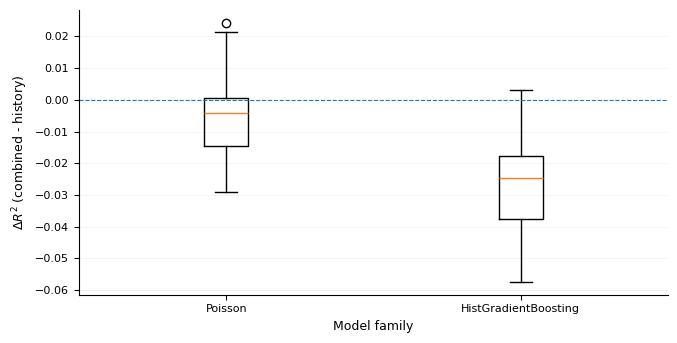

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/figures/Fig9_repeated_cv_incremental_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/figures/Fig9_repeated_cv_incremental_MAE.png


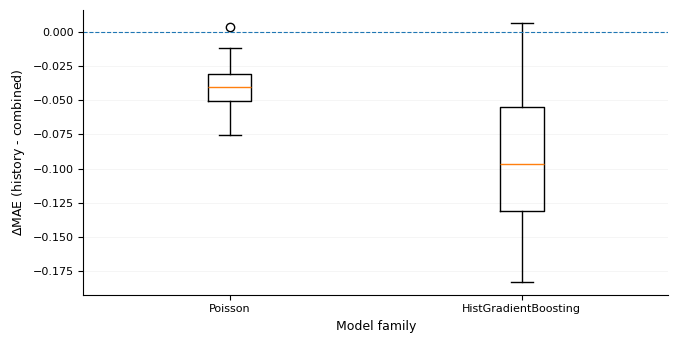


TABLE 17 — FINAL INCREMENTAL GRAPH DECISION
 family  delta_R2_observed  delta_R2_ci95_low  delta_R2_ci95_high  delta_MAE_observed  delta_MAE_ci95_low  delta_MAE_ci95_high                                                                                                   interpretation
poisson          -0.030863          -0.100851            0.029189           -0.084368           -0.216982             0.031917 No clear evidence that graph features improve prediction beyond past-productivity features in this model family.
    hgb          -0.023874          -0.086364            0.037914           -0.029231           -0.201962             0.143897 No clear evidence that graph features improve prediction beyond past-productivity features in this model family.


,family,delta_R2_observed,delta_R2_ci95_low,delta_R2_ci95_high,delta_MAE_observed,delta_MAE_ci95_low,delta_MAE_ci95_high,interpretation
0,poisson,-0.030863,-0.100851,0.029189,-0.084368,-0.216982,0.031917,No clear evidence that graph features improve ...
1,hgb,-0.023874,-0.086364,0.037914,-0.029231,-0.201962,0.143897,No clear evidence that graph features improve ...



AUDIT — PART 18.7 MANUSCRIPT-READY SUMMARY
       primary_outcome  n_researchers  history_R2  combined_R2  delta_R2  history_MAE  combined_MAE  delta_MAE_history_minus_combined  history_RMSE  combined_RMSE  delta_RMSE_history_minus_combined  bootstrap_delta_R2_ci_low  bootstrap_delta_R2_ci_high  negative_control_empirical_p_R2 best_primary_model_by_poisson_deviance
future_works_2023_2024            500    0.256326     0.254856  -0.00147     3.895854      3.944391                         -0.048537      6.525202       6.531648                          -0.006446                  -0.087499                     0.10049                         0.227723                           combined_hgb


,primary_outcome,n_researchers,history_R2,combined_R2,delta_R2,history_MAE,combined_MAE,delta_MAE_history_minus_combined,history_RMSE,combined_RMSE,delta_RMSE_history_minus_combined,bootstrap_delta_R2_ci_low,bootstrap_delta_R2_ci_high,negative_control_empirical_p_R2,best_primary_model_by_poisson_deviance
0,future_works_2023_2024,500,0.256326,0.254856,-0.00147,3.895854,3.944391,-0.048537,6.525202,6.531648,-0.006446,-0.087499,0.10049,0.227723,combined_hgb



ARQUIVOS PRINCIPAIS SALVOS
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/tables/Table_10A_outcome_reconstruction_audit.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/tables/Table_10B_feature_audit.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/tables/Table_10C_nested_tuning_by_fold.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/tables/Table_10D_outer_fold_paired_results.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/tables/Table_11_primary_paired_predictive_performance.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/tables/Table_12_incremental_graph_value_paired_bootstrap.csv
/content/dri

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.8 — VALIDAÇÃO FINAL PAREADA DO VALOR INCREMENTAL DAS FEATURES DE REDE
VERSÃO CORRIGIDA / ROBUSTA
================================================================================

Correção principal
------------------
O painel salvo pela Parte 18.6 contém o desfecho 2023–2025, mas o desfecho
primário 2023–2024 foi construído dinamicamente na Parte 18.7 a partir de
producoes_final.xlsx e não necessariamente foi persistido no CSV original.

Esta versão:
1) NÃO falha se future_works_2023_2024 estiver ausente;
2) reconstrói o desfecho primário diretamente de producoes_final.xlsx;
3) verifica/replica future_works_2023_2025;
4) mantém os mesmos blocos de preditores da Parte 18.7;
5) compara HISTORY vs HISTORY+GRAPH dentro da MESMA família de modelo;
6) usa nested 10-fold CV para Poisson e HistGradientBoosting;
7) usa bootstrap pareado entre pesquisadores para o ganho incremental;
8) testa sensibilidade a partições de CV repetidas;
9) salva tabelas e figuras no Drive e mostra os resultados no Colab;
10) não sobrescreve o painel original; salva uma cópia reparada/auditada.

Execução no Colab
-----------------
%run /content/Parte_18_8_Validacao_Final_Incremental_Graph_CORRIGIDO.py
"""

from __future__ import annotations

import os
import re
import json
import sys
import math
import pickle
import warnings
import importlib
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# ======================================================================================
# 0. GOOGLE DRIVE — não remonta se já estiver disponível
# ======================================================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

if not DRIVE_ROOT.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))
else:
    print("[drive] Google Drive já está montado; reutilizando /content/drive.")

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("scipy")
ensure("sklearn", "scikit-learn")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CAMINHOS E CONSTANTES
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")

PANEL_PATH = (
    ROOT
    / "runs/temporal_productivity_20260929/06_cohort2022_prospective_panel"
    / "panel_model_ready.csv"
)

PUB_PATH = (
    ROOT
    / "runs/run_20260625_200032/input"
    / "producoes_final.xlsx"
)

PART7_DIR = (
    ROOT
    / "runs/temporal_productivity_20260929/07_prospective_modeling"
)

OUT = (
    ROOT
    / "runs/temporal_productivity_20260929/08_final_incremental_graph_validation"
)
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
LOG = OUT / "logs"

for d in [OUT, TAB, FIG, ART, LOG]:
    d.mkdir(parents=True, exist_ok=True)

PRIMARY_OUTCOME = "future_works_2023_2024"
SENSITIVITY_OUTCOME = "future_works_2023_2025"

HISTORY = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
]

GRAPH = [
    "degree",
    "strength",
    "avg_tie_strength",
    "weighted_clustering",
    "pagerank",
    "betweenness",
    "core_number",
    "avg_neighbor_degree",
    "component_size",
    "is_isolate",
]

SLOPE = "past_productivity_slope"

BASE_SEED = 20260929
OUTER_SPLITS = 10
INNER_SPLITS = 5
REPEATED_CV_REPEATS = 30
BOOTSTRAP_B = 5000

POISSON_ALPHA_GRID = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1.0, 5.0]

HGB_PARAM_GRID = [
    {
        "learning_rate": lr,
        "max_iter": 200,
        "max_leaf_nodes": leaves,
        "l2_regularization": l2,
        "min_samples_leaf": 15,
    }
    for lr in [0.03, 0.05]
    for leaves in [7, 15]
    for l2 in [0.0, 1.0]
]

# ======================================================================================
# 3. HELPERS DE EXIBIÇÃO / SALVAMENTO
# ======================================================================================

def show_df(title, df, max_rows=50):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    if len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} linhas no total)")
    if display is not None:
        display(df.head(max_rows))

def save_figure(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")

def extract_openalex_author(x):
    if pd.isna(x):
        return None
    m = re.search(r"(A\d+)", str(x).upper())
    return m.group(1) if m else None

def extract_openalex_work(x):
    if pd.isna(x):
        return None
    m = re.search(r"(W\d+)", str(x).upper())
    return m.group(1) if m else None

# ======================================================================================
# 4. CARREGAMENTO
# ======================================================================================

if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Painel não encontrado: {PANEL_PATH}")

if not PUB_PATH.exists():
    raise FileNotFoundError(f"Arquivo de publicações não encontrado: {PUB_PATH}")

print("\n" + "=" * 120)
print("PARTE 18.8 — VALIDAÇÃO FINAL PAREADA DO VALOR INCREMENTAL DAS FEATURES DE REDE")
print("=" * 120)
print("[panel]       ", PANEL_PATH)
print("[publications]", PUB_PATH)
print("[part 18.7]   ", PART7_DIR)
print("[output]      ", OUT)

df = pd.read_csv(PANEL_PATH)
pub = pd.read_excel(PUB_PATH)

print(f"\nPanel shape: {df.shape}")
print(f"Publications shape: {pub.shape}")

print("\nColunas originais do painel:")
for i, c in enumerate(df.columns, start=1):
    print(f"  {i:02d}. {c}")

# ======================================================================================
# 5. IDENTIFICAR A CHAVE DE AUTOR DO PAINEL
# ======================================================================================

def infer_panel_author_column(data):
    preferred = [
        "author_key",
        "openalex_author",
        "openalex_author_id",
        "author_id",
        "autor_id",
        "id_openalex",
    ]

    for c in preferred:
        if c in data.columns:
            extracted = data[c].map(extract_openalex_author)
            share = extracted.notna().mean()
            if share >= 0.80:
                return c, extracted, share

    # busca em qualquer coluna
    best = None
    for c in data.columns:
        if data[c].dtype == "object" or pd.api.types.is_string_dtype(data[c]):
            extracted = data[c].map(extract_openalex_author)
            share = extracted.notna().mean()
            if best is None or share > best[2]:
                best = (c, extracted, share)

    if best is not None and best[2] >= 0.80:
        return best

    return None, None, 0.0

panel_author_col, panel_author_key, panel_author_share = infer_panel_author_column(df)

if panel_author_col is None:
    raise KeyError(
        "Não foi possível identificar no painel uma coluna contendo IDs OpenAlex de autores (A...). "
        "Colunas disponíveis:\n" + "\n".join(map(str, df.columns))
    )

df = df.copy()
df["__author_key__"] = panel_author_key

if df["__author_key__"].isna().any():
    bad = int(df["__author_key__"].isna().sum())
    raise ValueError(
        f"A coluna inferida '{panel_author_col}' deixou {bad} autores sem OpenAlex A-id válido."
    )

print(
    f"\n[author key] painel: coluna='{panel_author_col}' | "
    f"extração A-id={panel_author_share*100:.1f}%"
)

# ======================================================================================
# 6. RECONSTRUIR OS DESFECHOS 2023–2024 E 2023–2025
# ======================================================================================

required_pub_cols = ["autor_id", "id_openalex", "ano"]
missing_pub = [c for c in required_pub_cols if c not in pub.columns]

if missing_pub:
    raise KeyError(
        "O arquivo producoes_final.xlsx não contém as colunas necessárias para "
        f"reconstrução dos desfechos: {missing_pub}\n"
        f"Colunas disponíveis: {list(pub.columns)}"
    )

pub2 = pub.copy()
pub2["__author_key__"] = pub2["autor_id"].map(extract_openalex_author)
pub2["__work_key__"] = pub2["id_openalex"].map(extract_openalex_work)
pub2["__year__"] = pd.to_numeric(pub2["ano"], errors="coerce")

pub2 = pub2[
    pub2["__author_key__"].notna()
    & pub2["__work_key__"].notna()
    & pub2["__year__"].notna()
].copy()

pub2["__year__"] = pub2["__year__"].astype(int)

def count_unique_works(start_year, end_year):
    x = pub2[pub2["__year__"].between(start_year, end_year)]
    counts = (
        x.groupby("__author_key__")["__work_key__"]
        .nunique()
        .rename("count")
    )
    return df["__author_key__"].map(counts).fillna(0).astype(int)

reconstructed_primary = count_unique_works(2023, 2024)
reconstructed_sensitivity = count_unique_works(2023, 2025)

repair_rows = []

def audit_or_repair_outcome(column, reconstructed, start_year, end_year):
    existed = column in df.columns
    if existed:
        original = pd.to_numeric(df[column], errors="coerce")
        comparable = original.notna()
        if comparable.any():
            diff = original[comparable] - reconstructed[comparable]
            max_abs_diff = float(np.abs(diff).max())
            n_diff = int((np.abs(diff) > 1e-9).sum())
        else:
            max_abs_diff = np.nan
            n_diff = int(len(df))
    else:
        max_abs_diff = np.nan
        n_diff = np.nan

    # Para o primário ausente, cria.
    # Para desfecho existente e consistente, preserva; se inconsistente, usa reconstrução
    # porque a reconstrução é feita diretamente por autor + OpenAlex Work ID + ano.
    use_reconstructed = (
        (not existed)
        or (not pd.to_numeric(df[column], errors="coerce").notna().all())
        or (pd.notna(max_abs_diff) and max_abs_diff > 1e-9)
    )

    if use_reconstructed:
        df[column] = reconstructed.astype(int)
        action = "RECONSTRUCTED_FROM_PUBLICATIONS"
    else:
        df[column] = pd.to_numeric(df[column], errors="raise").astype(int)
        action = "EXISTING_PANEL_VALUE_CONFIRMED"

    repair_rows.append({
        "outcome": column,
        "period": f"{start_year}-{end_year}",
        "present_in_original_panel": bool(existed),
        "n_discrepant_vs_reconstruction": n_diff,
        "max_abs_difference_vs_reconstruction": max_abs_diff,
        "action": action,
        "n": int(len(df)),
        "zero_n": int((df[column] == 0).sum()),
        "mean": float(df[column].mean()),
        "median": float(df[column].median()),
        "max": float(df[column].max()),
    })

audit_or_repair_outcome(
    PRIMARY_OUTCOME, reconstructed_primary, 2023, 2024
)
audit_or_repair_outcome(
    SENSITIVITY_OUTCOME, reconstructed_sensitivity, 2023, 2025
)

outcome_repair = pd.DataFrame(repair_rows)
outcome_repair.to_csv(TAB / "Table_10A_outcome_reconstruction_audit.csv", index=False)
show_df("TABLE 10A — OUTCOME RECONSTRUCTION AUDIT", outcome_repair)

# Salva painel reparado, sem sobrescrever o original.
REPAIRED_PANEL = ART / "panel_model_ready_with_primary_outcome.csv"
df.to_csv(REPAIRED_PANEL, index=False)

print("\n[repaired panel]", REPAIRED_PANEL)

# ======================================================================================
# 7. RESOLVER / AUDITAR FEATURES
# ======================================================================================

ALIASES = {
    "past_works_2018_2022": [
        "past_works_2018_2022", "past_works", "works_2018_2022"
    ],
    "past_active_years_2018_2022": [
        "past_active_years_2018_2022", "past_active_years", "active_years_2018_2022"
    ],
    "recent_works_2021_2022": [
        "recent_works_2021_2022", "recent_works", "works_2021_2022"
    ],
    "past_productivity_slope": [
        "past_productivity_slope", "productivity_slope", "past_slope"
    ],
}

for canonical, candidates in ALIASES.items():
    if canonical in df.columns:
        continue
    found = next((c for c in candidates if c in df.columns), None)
    if found is not None:
        df[canonical] = df[found]
        print(f"[alias] {canonical} <- {found}")

missing_features = [c for c in HISTORY + GRAPH if c not in df.columns]

if missing_features:
    raise KeyError(
        "Features necessárias ausentes no painel, mesmo após resolução de aliases:\n"
        + "\n".join(missing_features)
        + "\n\nColunas disponíveis:\n"
        + "\n".join(map(str, df.columns))
    )

feature_audit_rows = []

for c in HISTORY + GRAPH + ([SLOPE] if SLOPE in df.columns else []):
    s = pd.to_numeric(df[c], errors="coerce")
    feature_audit_rows.append({
        "feature": c,
        "block": (
            "history"
            if c in HISTORY
            else "graph"
            if c in GRAPH
            else "history_sensitivity"
        ),
        "dtype_original": str(df[c].dtype),
        "missing_n_after_numeric_coercion": int(s.isna().sum()),
        "n_unique": int(s.nunique(dropna=True)),
        "min": float(s.min()) if s.notna().any() else np.nan,
        "median": float(s.median()) if s.notna().any() else np.nan,
        "max": float(s.max()) if s.notna().any() else np.nan,
    })
    df[c] = s

feature_audit = pd.DataFrame(feature_audit_rows)
feature_audit.to_csv(TAB / "Table_10B_feature_audit.csv", index=False)
show_df("TABLE 10B — FEATURE AUDIT", feature_audit)

if df[HISTORY + GRAPH].isna().any().any():
    bad = df[HISTORY + GRAPH].isna().sum()
    bad = bad[bad > 0]
    raise ValueError(
        "Há missing values nas features primárias:\n" + bad.to_string()
    )

for outcome in [PRIMARY_OUTCOME, SENSITIVITY_OUTCOME]:
    if df[outcome].isna().any():
        raise ValueError(f"Há valores ausentes em {outcome}.")
    if (df[outcome] < 0).any():
        raise ValueError(f"Há valores negativos em {outcome}.")

# ======================================================================================
# 8. MÉTRICAS E CONSTRUTORES DE MODELO
# ======================================================================================

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-9, None)

    rho = spearmanr(y_true, y_pred).statistic
    if not np.isfinite(rho):
        rho = np.nan

    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
        "Poisson_deviance": float(mean_poisson_deviance(y_true, y_pred)),
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "mean_observed": float(np.mean(y_true)),
        "mean_predicted": float(np.mean(y_pred)),
    }

def make_poisson(alpha):
    return Pipeline([
        ("scale", StandardScaler()),
        (
            "model",
            PoissonRegressor(
                alpha=float(alpha),
                max_iter=5000,
                tol=1e-8,
            ),
        ),
    ])

def make_hgb(params, seed):
    return HistGradientBoostingRegressor(
        loss="poisson",
        learning_rate=float(params["learning_rate"]),
        max_iter=int(params["max_iter"]),
        max_leaf_nodes=int(params["max_leaf_nodes"]),
        l2_regularization=float(params["l2_regularization"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        early_stopping=False,
        random_state=int(seed),
    )

# ======================================================================================
# 9. NESTED CV PAREADA — POISSON
# ======================================================================================

def tune_poisson_inner(X, y, train_idx, seed):
    inner = KFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=seed,
    )

    Xtr = X[train_idx]
    ytr = y[train_idx]

    scores = []

    for alpha in POISSON_ALPHA_GRID:
        fold_mae = []

        for itr, iva in inner.split(Xtr):
            model = make_poisson(alpha)
            model.fit(Xtr[itr], ytr[itr])
            pred = model.predict(Xtr[iva])
            fold_mae.append(mean_absolute_error(ytr[iva], pred))

        scores.append((float(np.mean(fold_mae)), float(alpha)))

    scores.sort(key=lambda z: (z[0], z[1]))
    return scores[0][1]

def nested_poisson_pair(X_history, X_combined, y, outer_splits):
    pred_hist = np.zeros(len(y), dtype=float)
    pred_comb = np.zeros(len(y), dtype=float)

    tuning_rows = []
    fold_rows = []

    for fold, (tr, te) in enumerate(outer_splits, start=1):
        seed = BASE_SEED + fold * 101

        alpha_h = tune_poisson_inner(X_history, y, tr, seed)
        alpha_c = tune_poisson_inner(X_combined, y, tr, seed + 1)

        mh = make_poisson(alpha_h)
        mc = make_poisson(alpha_c)

        mh.fit(X_history[tr], y[tr])
        mc.fit(X_combined[tr], y[tr])

        ph = mh.predict(X_history[te])
        pc = mc.predict(X_combined[te])

        pred_hist[te] = ph
        pred_comb[te] = pc

        met_h = metrics(y[te], ph)
        met_c = metrics(y[te], pc)

        tuning_rows.extend([
            {
                "family": "poisson",
                "fold": fold,
                "block": "history",
                "alpha": alpha_h,
            },
            {
                "family": "poisson",
                "fold": fold,
                "block": "combined",
                "alpha": alpha_c,
            },
        ])

        fold_rows.append({
            "family": "poisson",
            "fold": fold,
            "history_MAE": met_h["MAE"],
            "combined_MAE": met_c["MAE"],
            "delta_MAE_history_minus_combined": met_h["MAE"] - met_c["MAE"],
            "history_RMSE": met_h["RMSE"],
            "combined_RMSE": met_c["RMSE"],
            "delta_RMSE_history_minus_combined": met_h["RMSE"] - met_c["RMSE"],
            "history_R2": met_h["R2"],
            "combined_R2": met_c["R2"],
            "delta_R2_combined_minus_history": met_c["R2"] - met_h["R2"],
        })

        print(
            f"  [Poisson] fold {fold:02d} | "
            f"alpha H={alpha_h:g}, C={alpha_c:g} | "
            f"MAE H={met_h['MAE']:.3f}, C={met_c['MAE']:.3f}"
        )

    return (
        pred_hist,
        pred_comb,
        pd.DataFrame(tuning_rows),
        pd.DataFrame(fold_rows),
    )

# ======================================================================================
# 10. NESTED CV PAREADA — HISTGRADIENTBOOSTING
# ======================================================================================

def tune_hgb_inner(X, y, train_idx, seed):
    inner = KFold(
        n_splits=INNER_SPLITS,
        shuffle=True,
        random_state=seed,
    )

    Xtr = X[train_idx]
    ytr = y[train_idx]

    scored = []

    for j, params in enumerate(HGB_PARAM_GRID):
        fold_mae = []

        for inner_fold, (itr, iva) in enumerate(inner.split(Xtr), start=1):
            model = make_hgb(
                params,
                seed=seed + j * 100 + inner_fold
            )
            model.fit(Xtr[itr], ytr[itr])
            pred = model.predict(Xtr[iva])
            fold_mae.append(mean_absolute_error(ytr[iva], pred))

        scored.append((
            float(np.mean(fold_mae)),
            json.dumps(params, sort_keys=True),
            params,
        ))

    scored.sort(key=lambda z: (z[0], z[1]))
    return scored[0][2]

def nested_hgb_pair(X_history, X_combined, y, outer_splits):
    pred_hist = np.zeros(len(y), dtype=float)
    pred_comb = np.zeros(len(y), dtype=float)

    tuning_rows = []
    fold_rows = []

    for fold, (tr, te) in enumerate(outer_splits, start=1):
        seed = BASE_SEED + 10000 + fold * 101

        params_h = tune_hgb_inner(X_history, y, tr, seed)
        params_c = tune_hgb_inner(X_combined, y, tr, seed + 1)

        mh = make_hgb(params_h, seed=seed + 2)
        mc = make_hgb(params_c, seed=seed + 3)

        mh.fit(X_history[tr], y[tr])
        mc.fit(X_combined[tr], y[tr])

        ph = mh.predict(X_history[te])
        pc = mc.predict(X_combined[te])

        pred_hist[te] = ph
        pred_comb[te] = pc

        met_h = metrics(y[te], ph)
        met_c = metrics(y[te], pc)

        tuning_rows.extend([
            {
                "family": "hgb",
                "fold": fold,
                "block": "history",
                "params_json": json.dumps(params_h, sort_keys=True),
            },
            {
                "family": "hgb",
                "fold": fold,
                "block": "combined",
                "params_json": json.dumps(params_c, sort_keys=True),
            },
        ])

        fold_rows.append({
            "family": "hgb",
            "fold": fold,
            "history_MAE": met_h["MAE"],
            "combined_MAE": met_c["MAE"],
            "delta_MAE_history_minus_combined": met_h["MAE"] - met_c["MAE"],
            "history_RMSE": met_h["RMSE"],
            "combined_RMSE": met_c["RMSE"],
            "delta_RMSE_history_minus_combined": met_h["RMSE"] - met_c["RMSE"],
            "history_R2": met_h["R2"],
            "combined_R2": met_c["R2"],
            "delta_R2_combined_minus_history": met_c["R2"] - met_h["R2"],
        })

        print(
            f"  [HGB] fold {fold:02d} | "
            f"MAE H={met_h['MAE']:.3f}, C={met_c['MAE']:.3f}"
        )

    return (
        pred_hist,
        pred_comb,
        pd.DataFrame(tuning_rows),
        pd.DataFrame(fold_rows),
    )

# ======================================================================================
# 11. MATRIZES
# ======================================================================================

XH = df[HISTORY].to_numpy(dtype=float)
XC = df[HISTORY + GRAPH].to_numpy(dtype=float)
y = df[PRIMARY_OUTCOME].to_numpy(dtype=float)

outer = KFold(
    n_splits=OUTER_SPLITS,
    shuffle=True,
    random_state=BASE_SEED,
)
outer_splits = list(outer.split(XH))

print("\n" + "=" * 120)
print("NESTED 10-FOLD CV PAREADA — POISSON")
print("=" * 120)

ph_pois, pc_pois, tune_pois, folds_pois = nested_poisson_pair(
    XH, XC, y, outer_splits
)

print("\n" + "=" * 120)
print("NESTED 10-FOLD CV PAREADA — HISTGRADIENTBOOSTING")
print("=" * 120)

ph_hgb, pc_hgb, tune_hgb, folds_hgb = nested_hgb_pair(
    XH, XC, y, outer_splits
)

tuning = pd.concat([tune_pois, tune_hgb], ignore_index=True, sort=False)
fold_results = pd.concat([folds_pois, folds_hgb], ignore_index=True)

tuning.to_csv(TAB / "Table_10C_nested_tuning_by_fold.csv", index=False)
fold_results.to_csv(TAB / "Table_10D_outer_fold_paired_results.csv", index=False)

# ======================================================================================
# 12. PERFORMANCE OOF PAREADA
# ======================================================================================

prediction_map = {
    ("poisson", "history"): ph_pois,
    ("poisson", "combined"): pc_pois,
    ("hgb", "history"): ph_hgb,
    ("hgb", "combined"): pc_hgb,
}

perf_rows = []

for family in ["poisson", "hgb"]:
    for block in ["history", "combined"]:
        pred = prediction_map[(family, block)]
        m = metrics(y, pred)
        perf_rows.append({
            "outcome": PRIMARY_OUTCOME,
            "validation": "nested 10-fold OOF",
            "family": family,
            "block": block,
            **m,
        })

performance = pd.DataFrame(perf_rows)
performance.to_csv(TAB / "Table_11_primary_paired_predictive_performance.csv", index=False)
show_df("TABLE 11 — PRIMARY PAIRED PREDICTIVE PERFORMANCE", performance)

# ======================================================================================
# 13. BOOTSTRAP PAREADO — INCREMENTO DE GRAPH FEATURES
# ======================================================================================

def incremental_metrics(y_true, pred_h, pred_c):
    mh = metrics(y_true, pred_h)
    mc = metrics(y_true, pred_c)
    return {
        "delta_MAE": mh["MAE"] - mc["MAE"],
        "delta_RMSE": mh["RMSE"] - mc["RMSE"],
        "delta_R2": mc["R2"] - mh["R2"],
        "delta_Poisson_deviance": (
            mh["Poisson_deviance"] - mc["Poisson_deviance"]
        ),
    }

def paired_bootstrap_increment(y_true, pred_h, pred_c, family, B=BOOTSTRAP_B):
    rng = np.random.default_rng(BASE_SEED + (0 if family == "poisson" else 1000))
    n = len(y_true)

    observed = incremental_metrics(y_true, pred_h, pred_c)

    storage = {k: np.empty(B, dtype=float) for k in observed}

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        vals = incremental_metrics(
            y_true[idx],
            pred_h[idx],
            pred_c[idx],
        )
        for k, v in vals.items():
            storage[k][b] = v

        if (b + 1) % 1000 == 0:
            print(f"  [{family}] bootstrap {b+1}/{B}")

    rows = []
    raw = pd.DataFrame(storage)
    raw["family"] = family

    for metric_name, obs in observed.items():
        arr = storage[metric_name]
        pos_share = float(np.mean(arr > 0))
        p_two_sided = min(
            1.0,
            2.0 * min(
                (np.sum(arr <= 0) + 1) / (B + 1),
                (np.sum(arr >= 0) + 1) / (B + 1),
            ),
        )
        rows.append({
            "family": family,
            "metric": metric_name,
            "favorable_direction": "positive = graph block improves prediction",
            "observed": float(obs),
            "bootstrap_median": float(np.median(arr)),
            "ci95_low": float(np.quantile(arr, 0.025)),
            "ci95_high": float(np.quantile(arr, 0.975)),
            "positive_share": pos_share,
            "two_sided_bootstrap_p": p_two_sided,
            "bootstrap_B": B,
        })

    return pd.DataFrame(rows), raw

print("\n" + "=" * 120)
print("PAIRED RESEARCHER-LEVEL BOOTSTRAP")
print("=" * 120)

boot_pois_summary, boot_pois_raw = paired_bootstrap_increment(
    y, ph_pois, pc_pois, "poisson"
)

boot_hgb_summary, boot_hgb_raw = paired_bootstrap_increment(
    y, ph_hgb, pc_hgb, "hgb"
)

bootstrap_summary = pd.concat(
    [boot_pois_summary, boot_hgb_summary],
    ignore_index=True
)
bootstrap_raw = pd.concat(
    [boot_pois_raw, boot_hgb_raw],
    ignore_index=True
)

bootstrap_summary.to_csv(
    TAB / "Table_12_incremental_graph_value_paired_bootstrap.csv",
    index=False
)
bootstrap_raw.to_csv(
    ART / "paired_bootstrap_incremental_graph_value_raw.csv",
    index=False
)

show_df(
    "TABLE 12 — INCREMENTAL GRAPH VALUE: PAIRED BOOTSTRAP",
    bootstrap_summary
)

# ======================================================================================
# 14. TESTE PAREADO DE ERRO ABSOLUTO POR PESQUISADOR
# ======================================================================================

wilcoxon_rows = []

for family, ph, pc in [
    ("poisson", ph_pois, pc_pois),
    ("hgb", ph_hgb, pc_hgb),
]:
    err_h = np.abs(y - ph)
    err_c = np.abs(y - pc)

    try:
        stat, p = wilcoxon(err_h, err_c, alternative="two-sided", zero_method="wilcox")
    except Exception:
        stat, p = np.nan, np.nan

    wilcoxon_rows.append({
        "family": family,
        "median_abs_error_history": float(np.median(err_h)),
        "median_abs_error_combined": float(np.median(err_c)),
        "median_paired_difference_history_minus_combined": float(
            np.median(err_h - err_c)
        ),
        "wilcoxon_statistic": float(stat) if np.isfinite(stat) else np.nan,
        "wilcoxon_p_two_sided": float(p) if np.isfinite(p) else np.nan,
    })

wilcoxon_table = pd.DataFrame(wilcoxon_rows)
wilcoxon_table.to_csv(
    TAB / "Table_13_paired_absolute_error_wilcoxon.csv",
    index=False
)
show_df(
    "TABLE 13 — PAIRED ABSOLUTE-ERROR COMPARISON",
    wilcoxon_table
)

# ======================================================================================
# 15. CONGELAR HIPERPARÂMETROS A PARTIR DO NESTED CV
# ======================================================================================

def frozen_poisson_alpha(tune_df, block):
    vals = (
        tune_df[
            (tune_df["family"] == "poisson")
            & (tune_df["block"] == block)
        ]["alpha"]
        .dropna()
        .astype(float)
        .to_numpy()
    )
    return float(np.median(vals))

def frozen_hgb_params(tune_df, block):
    vals = (
        tune_df[
            (tune_df["family"] == "hgb")
            & (tune_df["block"] == block)
        ]["params_json"]
        .dropna()
        .astype(str)
        .tolist()
    )
    most_common = Counter(vals).most_common(1)[0][0]
    return json.loads(most_common)

frozen = {
    "poisson_history_alpha": frozen_poisson_alpha(tuning, "history"),
    "poisson_combined_alpha": frozen_poisson_alpha(tuning, "combined"),
    "hgb_history_params": frozen_hgb_params(tuning, "history"),
    "hgb_combined_params": frozen_hgb_params(tuning, "combined"),
}

(ART / "frozen_hyperparameters.json").write_text(
    json.dumps(frozen, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("\nFrozen hyperparameters:")
print(json.dumps(frozen, indent=2))

# ======================================================================================
# 16. SENSIBILIDADE A PARTIÇÕES DE CV — 30 REPETIÇÕES PAREADAS
# ======================================================================================

def repeated_cv_one_family(family, Xh, Xc, y_true, n_repeats):
    rows = []

    for r in range(n_repeats):
        cv = KFold(
            n_splits=OUTER_SPLITS,
            shuffle=True,
            random_state=BASE_SEED + 20000 + r,
        )

        ph = np.zeros(len(y_true), dtype=float)
        pc = np.zeros(len(y_true), dtype=float)

        for fold, (tr, te) in enumerate(cv.split(Xh), start=1):
            seed = BASE_SEED + 30000 + r * 100 + fold

            if family == "poisson":
                mh = make_poisson(frozen["poisson_history_alpha"])
                mc = make_poisson(frozen["poisson_combined_alpha"])
            else:
                mh = make_hgb(frozen["hgb_history_params"], seed=seed)
                mc = make_hgb(frozen["hgb_combined_params"], seed=seed + 1)

            mh.fit(Xh[tr], y_true[tr])
            mc.fit(Xc[tr], y_true[tr])

            ph[te] = mh.predict(Xh[te])
            pc[te] = mc.predict(Xc[te])

        inc = incremental_metrics(y_true, ph, pc)
        rows.append({
            "family": family,
            "repeat": r + 1,
            **inc,
        })

        if (r + 1) % 5 == 0:
            print(f"  [{family}] repeated CV {r+1}/{n_repeats}")

    return pd.DataFrame(rows)

print("\n" + "=" * 120)
print("REPEATED 10-FOLD CV — SPLIT SENSITIVITY")
print("=" * 120)

rep_pois = repeated_cv_one_family(
    "poisson", XH, XC, y, REPEATED_CV_REPEATS
)
rep_hgb = repeated_cv_one_family(
    "hgb", XH, XC, y, REPEATED_CV_REPEATS
)

repeat_raw = pd.concat([rep_pois, rep_hgb], ignore_index=True)
repeat_raw.to_csv(
    ART / "repeated_cv_incremental_graph_value_raw.csv",
    index=False
)

repeat_summary_rows = []

for family, g in repeat_raw.groupby("family"):
    for metric_name in [
        "delta_MAE",
        "delta_RMSE",
        "delta_R2",
        "delta_Poisson_deviance",
    ]:
        vals = g[metric_name].to_numpy(dtype=float)
        repeat_summary_rows.append({
            "family": family,
            "metric": metric_name,
            "n_repeats": int(len(vals)),
            "median": float(np.median(vals)),
            "mean": float(np.mean(vals)),
            "sd": float(np.std(vals, ddof=1)),
            "p2_5": float(np.quantile(vals, 0.025)),
            "p97_5": float(np.quantile(vals, 0.975)),
            "positive_share": float(np.mean(vals > 0)),
        })

repeat_summary = pd.DataFrame(repeat_summary_rows)
repeat_summary.to_csv(
    TAB / "Table_14_repeated_cv_split_sensitivity.csv",
    index=False
)
show_df(
    "TABLE 14 — REPEATED-CV SPLIT SENSITIVITY",
    repeat_summary
)

# ======================================================================================
# 17. SENSIBILIDADE DO HORIZONTE 2023–2025
# ======================================================================================

y_sens = df[SENSITIVITY_OUTCOME].to_numpy(dtype=float)

def fixed_oof_pair(family, Xh, Xc, y_true, splits):
    ph = np.zeros(len(y_true), dtype=float)
    pc = np.zeros(len(y_true), dtype=float)

    for fold, (tr, te) in enumerate(splits, start=1):
        seed = BASE_SEED + 40000 + fold

        if family == "poisson":
            mh = make_poisson(frozen["poisson_history_alpha"])
            mc = make_poisson(frozen["poisson_combined_alpha"])
        else:
            mh = make_hgb(frozen["hgb_history_params"], seed=seed)
            mc = make_hgb(frozen["hgb_combined_params"], seed=seed + 1)

        mh.fit(Xh[tr], y_true[tr])
        mc.fit(Xc[tr], y_true[tr])

        ph[te] = mh.predict(Xh[te])
        pc[te] = mc.predict(Xc[te])

    return ph, pc

sensitivity_rows = []

for family in ["poisson", "hgb"]:
    ph, pc = fixed_oof_pair(
        family, XH, XC, y_sens, outer_splits
    )

    mh = metrics(y_sens, ph)
    mc = metrics(y_sens, pc)
    inc = incremental_metrics(y_sens, ph, pc)

    sensitivity_rows.extend([
        {
            "outcome": SENSITIVITY_OUTCOME,
            "family": family,
            "block": "history",
            **mh,
        },
        {
            "outcome": SENSITIVITY_OUTCOME,
            "family": family,
            "block": "combined",
            **mc,
        },
        {
            "outcome": SENSITIVITY_OUTCOME,
            "family": family,
            "block": "increment",
            **inc,
        },
    ])

sensitivity_table = pd.DataFrame(sensitivity_rows)
sensitivity_table.to_csv(
    TAB / "Table_15_sensitivity_2023_2025.csv",
    index=False
)
show_df(
    "TABLE 15 — SENSITIVITY HORIZON 2023–2025",
    sensitivity_table
)

# ======================================================================================
# 18. SUBGRUPO ISOLATES VS CONNECTED — RESULTADOS OOF PRIMÁRIOS
# ======================================================================================

subgroup_rows = []

for family, ph, pc in [
    ("poisson", ph_pois, pc_pois),
    ("hgb", ph_hgb, pc_hgb),
]:
    for subgroup_name, mask in [
        ("isolates", df["is_isolate"].to_numpy(dtype=int) == 1),
        ("connected", df["is_isolate"].to_numpy(dtype=int) == 0),
    ]:
        if mask.sum() < 3:
            continue

        mh = metrics(y[mask], ph[mask])
        mc = metrics(y[mask], pc[mask])
        inc = incremental_metrics(y[mask], ph[mask], pc[mask])

        subgroup_rows.append({
            "family": family,
            "subgroup": subgroup_name,
            "n": int(mask.sum()),
            "history_MAE": mh["MAE"],
            "combined_MAE": mc["MAE"],
            "delta_MAE_history_minus_combined": inc["delta_MAE"],
            "history_R2": mh["R2"],
            "combined_R2": mc["R2"],
            "delta_R2_combined_minus_history": inc["delta_R2"],
        })

subgroup_table = pd.DataFrame(subgroup_rows)
subgroup_table.to_csv(
    TAB / "Table_16_isolate_connected_sensitivity.csv",
    index=False
)
show_df(
    "TABLE 16 — ISOLATE / CONNECTED SENSITIVITY",
    subgroup_table
)

# ======================================================================================
# 19. OOF PREDICTIONS — SALVAR
# ======================================================================================

oof = pd.DataFrame({
    "author_key": df["__author_key__"],
    PRIMARY_OUTCOME: y.astype(int),
    "poisson_history_pred": ph_pois,
    "poisson_combined_pred": pc_pois,
    "hgb_history_pred": ph_hgb,
    "hgb_combined_pred": pc_hgb,
    "is_isolate": df["is_isolate"].astype(int),
})

oof.to_csv(
    ART / "oof_predictions_final_paired_primary.csv",
    index=False
)

# ======================================================================================
# 20. FIGURAS — SCIENTOMETRICS / SPRINGER
# Sem título/caption dentro da figura.
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Fig. 8 — ΔR² por repetição de CV
fig, ax = plt.subplots(figsize=(6.85, 3.5))

data_r2 = [
    repeat_raw.loc[repeat_raw["family"] == "poisson", "delta_R2"].to_numpy(),
    repeat_raw.loc[repeat_raw["family"] == "hgb", "delta_R2"].to_numpy(),
]

ax.boxplot(
    data_r2,
    labels=["Poisson", "HistGradientBoosting"],
    showfliers=True,
)
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_ylabel(r"$\Delta R^2$ (combined - history)")
ax.set_xlabel("Model family")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig8_repeated_cv_incremental_R2")

if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig. 9 — ΔMAE por repetição de CV
fig, ax = plt.subplots(figsize=(6.85, 3.5))

data_mae = [
    repeat_raw.loc[repeat_raw["family"] == "poisson", "delta_MAE"].to_numpy(),
    repeat_raw.loc[repeat_raw["family"] == "hgb", "delta_MAE"].to_numpy(),
]

ax.boxplot(
    data_mae,
    labels=["Poisson", "HistGradientBoosting"],
    showfliers=True,
)
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_ylabel(r"$\Delta$MAE (history - combined)")
ax.set_xlabel("Model family")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig9_repeated_cv_incremental_MAE")

if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 21. DECISION TABLE — SEM FORÇAR CONCLUSÃO
# ======================================================================================

decision_rows = []

for family in ["poisson", "hgb"]:
    sub = bootstrap_summary[bootstrap_summary["family"] == family]

    r2row = sub[sub["metric"] == "delta_R2"].iloc[0]
    maerow = sub[sub["metric"] == "delta_MAE"].iloc[0]

    r2_positive_ci = bool(r2row["ci95_low"] > 0)
    mae_positive_ci = bool(maerow["ci95_low"] > 0)

    if r2_positive_ci and mae_positive_ci:
        interpretation = (
            "Evidence of incremental predictive value of graph features "
            "under both R2 and MAE."
        )
    elif r2_positive_ci or mae_positive_ci:
        interpretation = (
            "Mixed evidence: incremental value is supported by one primary "
            "metric but not by both."
        )
    else:
        interpretation = (
            "No clear evidence that graph features improve prediction beyond "
            "past-productivity features in this model family."
        )

    decision_rows.append({
        "family": family,
        "delta_R2_observed": float(r2row["observed"]),
        "delta_R2_ci95_low": float(r2row["ci95_low"]),
        "delta_R2_ci95_high": float(r2row["ci95_high"]),
        "delta_MAE_observed": float(maerow["observed"]),
        "delta_MAE_ci95_low": float(maerow["ci95_low"]),
        "delta_MAE_ci95_high": float(maerow["ci95_high"]),
        "interpretation": interpretation,
    })

decision = pd.DataFrame(decision_rows)
decision.to_csv(
    TAB / "Table_17_final_incremental_graph_decision.csv",
    index=False
)
show_df(
    "TABLE 17 — FINAL INCREMENTAL GRAPH DECISION",
    decision
)

# ======================================================================================
# 22. AUDIT COM A PARTE 18.7, SE DISPONÍVEL
# ======================================================================================

part7_summary_path = PART7_DIR / "tables/Table_9_manuscript_ready_summary.csv"

if part7_summary_path.exists():
    part7_summary = pd.read_csv(part7_summary_path)
    show_df(
        "AUDIT — PART 18.7 MANUSCRIPT-READY SUMMARY",
        part7_summary
    )

    # Apenas salvar cópia referencial.
    part7_summary.to_csv(
        TAB / "audit_Part18_7_Table9_reference.csv",
        index=False
    )
else:
    print("\n[audit] Table_9 da Parte 18.7 não encontrada; seguindo sem ela.")

# ======================================================================================
# 23. FREEZE
# ======================================================================================

freeze = {
    "panel_original": str(PANEL_PATH),
    "panel_repaired": str(REPAIRED_PANEL),
    "publications": str(PUB_PATH),
    "primary_outcome": PRIMARY_OUTCOME,
    "sensitivity_outcome": SENSITIVITY_OUTCOME,
    "history_features": HISTORY,
    "graph_features": GRAPH,
    "slope_available": bool(SLOPE in df.columns),
    "outer_splits": OUTER_SPLITS,
    "inner_splits": INNER_SPLITS,
    "repeated_cv_repeats": REPEATED_CV_REPEATS,
    "bootstrap_B": BOOTSTRAP_B,
    "base_seed": BASE_SEED,
    "frozen_hyperparameters": frozen,
}

with open(ART / "part18_8_final_validation_freeze.pkl", "wb") as f:
    pickle.dump(
        {
            "freeze": freeze,
            "performance": performance,
            "bootstrap_summary": bootstrap_summary,
            "repeat_summary": repeat_summary,
            "sensitivity_table": sensitivity_table,
            "subgroup_table": subgroup_table,
            "decision": decision,
            "oof": oof,
        },
        f,
        pickle.HIGHEST_PROTOCOL,
    )

(ART / "part18_8_final_validation_freeze.json").write_text(
    json.dumps(freeze, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

# ======================================================================================
# 24. README
# ======================================================================================

readme = f"""
PARTE 18.8 — VALIDAÇÃO FINAL PAREADA DO VALOR INCREMENTAL DAS FEATURES DE REDE
================================================================================

Primary outcome:
{PRIMARY_OUTCOME}

Primary horizon:
2023–2024

Sensitivity horizon:
2023–2025

Why 2023–2024 is primary:
The Part 18.7 audit showed 2025 output at only about 58.4% of the 2024 work count
and about 63.8% of the 2024 active-author count, consistent with possible
right-truncation/incomplete indexing. Therefore 2023–2024 remains the primary
forecast horizon.

Correction implemented:
The original Part 18.6 panel did not necessarily persist future_works_2023_2024.
This script reconstructs it directly from producoes_final.xlsx using:
- publication author: autor_id -> OpenAlex A-id
- work identifier: id_openalex -> OpenAlex W-id
- publication year: ano
- count: unique works per author in 2023–2024

Primary comparison:
History-only vs History+Graph WITHIN THE SAME model family.

Families:
1. PoissonRegressor with nested inner tuning of alpha.
2. HistGradientBoostingRegressor with Poisson loss and nested inner tuning.

Inference / robustness:
- paired researcher-level bootstrap ({BOOTSTRAP_B} resamples)
- paired absolute-error Wilcoxon comparison
- {REPEATED_CV_REPEATS} repeated 10-fold CV partitions as split-sensitivity analysis
- 2023–2025 horizon sensitivity
- isolates vs connected-node sensitivity

History features:
{HISTORY}

Graph features:
{GRAPH}

Output:
{OUT}
""".strip()

(LOG / "README_Part18_8.txt").write_text(readme, encoding="utf-8")

# ======================================================================================
# 25. FINAL PRINT
# ======================================================================================

print("\n" + "=" * 120)
print("ARQUIVOS PRINCIPAIS SALVOS")
print("=" * 120)

files_to_print = [
    TAB / "Table_10A_outcome_reconstruction_audit.csv",
    TAB / "Table_10B_feature_audit.csv",
    TAB / "Table_10C_nested_tuning_by_fold.csv",
    TAB / "Table_10D_outer_fold_paired_results.csv",
    TAB / "Table_11_primary_paired_predictive_performance.csv",
    TAB / "Table_12_incremental_graph_value_paired_bootstrap.csv",
    TAB / "Table_13_paired_absolute_error_wilcoxon.csv",
    TAB / "Table_14_repeated_cv_split_sensitivity.csv",
    TAB / "Table_15_sensitivity_2023_2025.csv",
    TAB / "Table_16_isolate_connected_sensitivity.csv",
    TAB / "Table_17_final_incremental_graph_decision.csv",
    ART / "oof_predictions_final_paired_primary.csv",
    ART / "frozen_hyperparameters.json",
    ART / "part18_8_final_validation_freeze.pkl",
    ART / "part18_8_final_validation_freeze.json",
    FIG / "Fig8_repeated_cv_incremental_R2.eps",
    FIG / "Fig8_repeated_cv_incremental_R2.png",
    FIG / "Fig9_repeated_cv_incremental_MAE.eps",
    FIG / "Fig9_repeated_cv_incremental_MAE.png",
    LOG / "README_Part18_8.txt",
]

for p in files_to_print:
    print(p)

print("\n" + "=" * 120)
print("BLOCOS PARA ENVIAR DE VOLTA")
print("=" * 120)
print("1) TABLE 10A — OUTCOME RECONSTRUCTION AUDIT")
print("2) TABLE 11 — PRIMARY PAIRED PREDICTIVE PERFORMANCE")
print("3) TABLE 12 — INCREMENTAL GRAPH VALUE: PAIRED BOOTSTRAP")
print("4) TABLE 14 — REPEATED-CV SPLIT SENSITIVITY")
print("5) TABLE 15 — SENSITIVITY HORIZON 2023–2025")
print("6) TABLE 16 — ISOLATE / CONNECTED SENSITIVITY")
print("7) TABLE 17 — FINAL INCREMENTAL GRAPH DECISION")

print("\nCONCLUÍDO.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.9 — DEPENDÊNCIA DO HORIZONTE E VALIDAÇÃO FINAL
[panel]  /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/panel_model_ready_with_primary_outcome.csv
[hp]     /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/frozen_hyperparameters.json
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final
Panel shape: (500, 41)

TABLE 18A — HORIZON INPUT AUDIT
                     column  missing_n  n_unique       min     median        max
       past_works_2018_2022          0        80  0.000000  20.000000 111.000000
past_active_years_2018_2022          0         6  0.000000   5.000000   5.000000
     recent_works_2021_2022          0        34  0.000000   5.000000  51

,column,missing_n,n_unique,min,median,max
0,past_works_2018_2022,0,80,0.000000,20.000000,111.000000
1,past_active_years_2018_2022,0,6,0.000000,5.000000,5.000000
2,recent_works_2021_2022,0,34,0.000000,5.000000,51.000000
3,past_productivity_slope,0,100,-9.200000,-0.700000,4.200000
4,degree,0,19,0.000000,2.000000,18.000000
5,strength,0,51,0.000000,3.000000,132.000000
6,avg_tie_strength,0,87,0.000000,1.250000,15.000000
7,weighted_clustering,0,191,0.000000,0.000000,0.314170
8,pagerank,0,330,0.000399,0.001549,0.009565
9,betweenness,0,207,0.000000,0.000000,0.090081



TABLE 18B — NAIVE PERSISTENCE BASELINE
               outcome   horizon              status             model    MAE      RMSE        R2  Poisson_deviance  Spearman_rho  mean_observed  mean_predicted
future_works_2023_2024 2023-2024             primary naive_persistence 5.1556  7.234180  0.085942          5.215969      0.668634          6.810          9.6568
future_works_2023_2025 2023-2025 horizon_sensitivity naive_persistence 8.4580 11.665734 -0.190746          8.683420      0.664336          8.692         14.4852


,outcome,horizon,status,model,MAE,RMSE,R2,Poisson_deviance,Spearman_rho,mean_observed,mean_predicted
0,future_works_2023_2024,2023-2024,primary,naive_persistence,5.1556,7.234180,0.085942,5.215969,0.668634,6.810,9.6568
1,future_works_2023_2025,2023-2025,horizon_sensitivity,naive_persistence,8.4580,11.665734,-0.190746,8.683420,0.664336,8.692,14.4852



CANONICAL PAIRED 10-FOLD OOF — 2023-2024

  [poisson] paired bootstrap — 2023-2024
    bootstrap 2000/10000
    bootstrap 4000/10000
    bootstrap 6000/10000
    bootstrap 8000/10000
    bootstrap 10000/10000

  [hgb] paired bootstrap — 2023-2024
    bootstrap 2000/10000
    bootstrap 4000/10000
    bootstrap 6000/10000
    bootstrap 8000/10000
    bootstrap 10000/10000

CANONICAL PAIRED 10-FOLD OOF — 2023-2025

  [poisson] paired bootstrap — 2023-2025
    bootstrap 2000/10000
    bootstrap 4000/10000
    bootstrap 6000/10000
    bootstrap 8000/10000
    bootstrap 10000/10000

  [hgb] paired bootstrap — 2023-2025
    bootstrap 2000/10000
    bootstrap 4000/10000
    bootstrap 6000/10000
    bootstrap 8000/10000
    bootstrap 10000/10000

TABLE 19 — CANONICAL HORIZON PERFORMANCE
               outcome   horizon              status  family    block      MAE      RMSE       R2  Poisson_deviance  Spearman_rho  mean_observed  mean_predicted
future_works_2023_2024 2023-2024             prim

...


TABLE 22A — SLOPE-ADJUSTED PERFORMANCE
               outcome   horizon              status  family               block      MAE      RMSE        R2  Poisson_deviance  Spearman_rho  mean_observed  mean_predicted
future_works_2023_2024 2023-2024             primary poisson  history_plus_slope 3.853278  6.767319  0.200114          3.873592      0.692312          6.810        6.871568
future_works_2023_2024 2023-2024             primary poisson combined_plus_slope 3.915423  6.744477  0.205504          3.990956      0.683035          6.810        6.897828
future_works_2023_2024 2023-2024             primary     hgb  history_plus_slope 3.749900  5.868795  0.398421          3.700981      0.670797          6.810        6.705540
future_works_2023_2024 2023-2024             primary     hgb combined_plus_slope 3.846459  6.012261  0.368649          3.852105      0.667062          6.810        6.720600
future_works_2023_2025 2023-2025 horizon_sensitivity poisson  history_plus_slope 5.307713 10.91

,outcome,horizon,status,family,block,MAE,RMSE,R2,Poisson_deviance,Spearman_rho,mean_observed,mean_predicted
0,future_works_2023_2024,2023-2024,primary,poisson,history_plus_slope,3.853278,6.767319,0.200114,3.873592,0.692312,6.810,6.871568
1,future_works_2023_2024,2023-2024,primary,poisson,combined_plus_slope,3.915423,6.744477,0.205504,3.990956,0.683035,6.810,6.897828
2,future_works_2023_2024,2023-2024,primary,hgb,history_plus_slope,3.749900,5.868795,0.398421,3.700981,0.670797,6.810,6.705540
3,future_works_2023_2024,2023-2024,primary,hgb,combined_plus_slope,3.846459,6.012261,0.368649,3.852105,0.667062,6.810,6.720600
4,future_works_2023_2025,2023-2025,horizon_sensitivity,poisson,history_plus_slope,5.307713,10.915867,-0.042585,5.475469,0.701468,8.692,8.817915
5,future_works_2023_2025,2023-2025,horizon_sensitivity,poisson,combined_plus_slope,5.158604,9.209660,0.257866,5.159940,0.677519,8.692,8.820703
6,future_works_2023_2025,2023-2025,horizon_sensitivity,hgb,history_plus_slope,5.074903,8.354960,0.389221,5.121072,0.681067,8.692,8.524101
7,future_works_2023_2025,2023-2025,horizon_sensitivity,hgb,combined_plus_slope,4.841830,7.838199,0.462439,4.852155,0.685465,8.692,8.538008



TABLE 22B — SLOPE-ADJUSTED INCREMENTAL VALUE
               outcome   horizon              status  family  delta_MAE  delta_RMSE  delta_R2  delta_Poisson_deviance
future_works_2023_2024 2023-2024             primary     hgb  -0.096559   -0.143466 -0.029771               -0.151124
future_works_2023_2024 2023-2024             primary poisson  -0.062145    0.022842  0.005391               -0.117365
future_works_2023_2025 2023-2025 horizon_sensitivity     hgb   0.233073    0.516762  0.073218                0.268916
future_works_2023_2025 2023-2025 horizon_sensitivity poisson   0.149109    1.706206  0.300451                0.315529


,outcome,horizon,status,family,delta_MAE,delta_RMSE,delta_R2,delta_Poisson_deviance
0,future_works_2023_2024,2023-2024,primary,hgb,-0.096559,-0.143466,-0.029771,-0.151124
1,future_works_2023_2024,2023-2024,primary,poisson,-0.062145,0.022842,0.005391,-0.117365
2,future_works_2023_2025,2023-2025,horizon_sensitivity,hgb,0.233073,0.516762,0.073218,0.268916
3,future_works_2023_2025,2023-2025,horizon_sensitivity,poisson,0.149109,1.706206,0.300451,0.315529


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/figures/Fig10_horizon_effect_delta_R2.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/figures/Fig10_horizon_effect_delta_R2.png


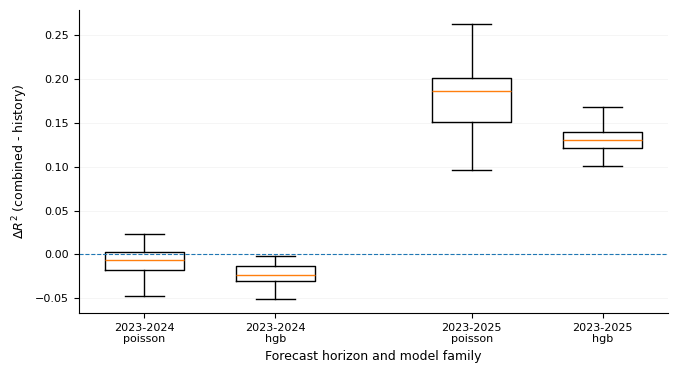

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/figures/Fig11_horizon_effect_relative_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/figures/Fig11_horizon_effect_relative_MAE.png


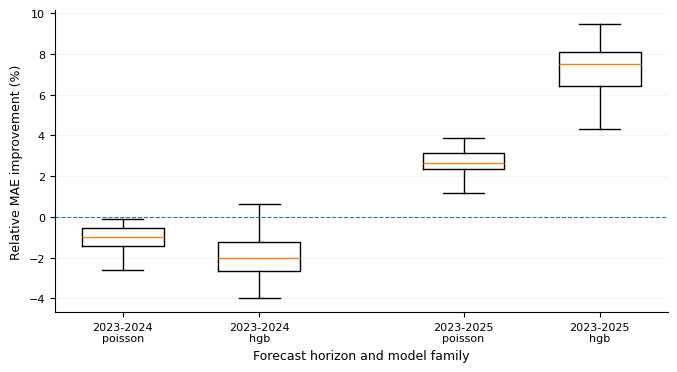


TABLE 23 — FINAL HORIZON DECISION
               outcome   horizon              status  family  delta_R2_observed  delta_R2_ci95_low  delta_R2_ci95_high  delta_MAE_observed  delta_MAE_ci95_low  delta_MAE_ci95_high  repeat_positive_share_R2  repeat_positive_share_MAE                                                                        interpretation
future_works_2023_2024 2023-2024             primary poisson           0.003634          -0.062681            0.066753           -0.019302           -0.114778             0.064328                      0.32                       0.00 No robust evidence that graph features improve prediction beyond publication history.
future_works_2023_2024 2023-2024             primary     hgb          -0.023755          -0.087699            0.036997           -0.046802           -0.217687             0.120921                      0.00                       0.04 No robust evidence that graph features improve prediction beyond publication history.
future_w

,outcome,horizon,status,family,delta_R2_observed,delta_R2_ci95_low,delta_R2_ci95_high,delta_MAE_observed,delta_MAE_ci95_low,delta_MAE_ci95_high,repeat_positive_share_R2,repeat_positive_share_MAE,interpretation
0,future_works_2023_2024,2023-2024,primary,poisson,0.003634,-0.062681,0.066753,-0.019302,-0.114778,0.064328,0.32,0.00,No robust evidence that graph features improve...
1,future_works_2023_2024,2023-2024,primary,hgb,-0.023755,-0.087699,0.036997,-0.046802,-0.217687,0.120921,0.00,0.04,No robust evidence that graph features improve...
2,future_works_2023_2025,2023-2025,horizon_sensitivity,poisson,0.198781,0.006989,0.540001,0.187887,-0.074831,0.458375,1.00,1.00,Suggestive but not fully stable evidence of in...
3,future_works_2023_2025,2023-2025,horizon_sensitivity,hgb,0.129454,0.038190,0.211047,0.424084,0.086187,0.770718,1.00,1.00,Consistent evidence of incremental predictive ...



ARQUIVOS PRINCIPAIS SALVOS
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/tables/Table_18A_horizon_input_audit.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/tables/Table_18B_naive_persistence_baseline.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/tables/Table_19_canonical_horizon_performance.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/tables/Table_20_horizon_incremental_paired_bootstrap.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/tables/Table_21_repeated_cv_horizon_sensitivity.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/09_horizon_sensitivity_final/tables/Table_22A_slope_adjusted_performance.csv
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.9 — DEPENDÊNCIA DO HORIZONTE, BASELINES E VALIDAÇÃO FINAL DO VALOR INCREMENTAL DA REDE
===============================================================================================

Objetivo
--------
Resolver a divergência observada na Parte 18.8:
- horizonte principal 2023–2024: features de rede não melhoraram a previsão;
- sensibilidade 2023–2025: apareceu melhora importante.

Esta etapa aplica o MESMO protocolo pareado aos dois horizontes, acrescenta
graph-only e naive persistence baselines, e testa se o resultado depende do
horizonte de previsão.

Princípios
----------
1) 2023–2024 permanece o horizonte primário pré-especificado.
2) 2023–2025 é sensibilidade de horizonte, não substitui silenciosamente o primário.
3) Os hiperparâmetros congelados na Parte 18.8 são reutilizados.
4) As mesmas divisões de CV são usadas para history, graph-only e combined.
5) O ganho incremental é sempre definido em direção favorável:
      delta_MAE = MAE_history - MAE_combined
      delta_RMSE = RMSE_history - RMSE_combined
      delta_R2 = R2_combined - R2_history
      delta_Deviance = Deviance_history - Deviance_combined
   Logo, valores positivos favorecem a inclusão das features de rede.
6) Resultados são mostrados no Colab e salvos no Drive.
7) Figuras: EPS + PNG 600 dpi, sem título/caption embutido.

Execução
--------
%run /content/Parte_18_9_Horizon_Sensitivity_Final.py
"""

from __future__ import annotations

import json
import math
import pickle
import sys
import importlib
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("sklearn", "scikit-learn")
ensure("scipy")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)
from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929")

PANEL_CANDIDATES = [
    ROOT / "08_final_incremental_graph_validation/artifacts/panel_model_ready_with_primary_outcome.csv",
    ROOT / "06_cohort2022_prospective_panel/panel_model_ready.csv",
]

PANEL_PATH = next((p for p in PANEL_CANDIDATES if p.exists()), None)
if PANEL_PATH is None:
    raise FileNotFoundError(
        "Nenhum painel encontrado. Testados:\n" +
        "\n".join(str(p) for p in PANEL_CANDIDATES)
    )

HP_PATH = ROOT / "08_final_incremental_graph_validation/artifacts/frozen_hyperparameters.json"
if not HP_PATH.exists():
    raise FileNotFoundError(f"Hiperparâmetros congelados não encontrados: {HP_PATH}")

OUT = ROOT / "09_horizon_sensitivity_final"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
LOG = OUT / "logs"

for d in [OUT, TAB, FIG, ART, LOG]:
    d.mkdir(parents=True, exist_ok=True)

# ======================================================================================
# 3. CONFIGURAÇÃO
# ======================================================================================

RANDOM_SEED = 20260929
N_SPLITS = 10
N_REPEATS = 50
BOOT_B = 10000

HISTORY = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
]

HISTORY_SENSITIVITY = HISTORY + ["past_productivity_slope"]

GRAPH = [
    "degree",
    "strength",
    "avg_tie_strength",
    "weighted_clustering",
    "pagerank",
    "betweenness",
    "core_number",
    "avg_neighbor_degree",
    "component_size",
    "is_isolate",
]

OUTCOMES = [
    {
        "column": "future_works_2023_2024",
        "label": "2023-2024",
        "years": 2,
        "status": "primary",
    },
    {
        "column": "future_works_2023_2025",
        "label": "2023-2025",
        "years": 3,
        "status": "horizon_sensitivity",
    },
]

# ======================================================================================
# 4. HELPERS
# ======================================================================================

def show_df(name, df, max_rows=60):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    if display is not None:
        display(df.head(max_rows))

def safe_poisson_deviance(y, pred):
    pred = np.clip(np.asarray(pred, dtype=float), 1e-9, None)
    y = np.asarray(y, dtype=float)
    return float(mean_poisson_deviance(y, pred))

def metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.clip(np.asarray(pred, dtype=float), 0.0, None)
    rho = spearmanr(y, pred).statistic
    return {
        "MAE": float(mean_absolute_error(y, pred)),
        "RMSE": float(mean_squared_error(y, pred) ** 0.5),
        "R2": float(r2_score(y, pred)),
        "Poisson_deviance": safe_poisson_deviance(y, pred),
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "mean_observed": float(np.mean(y)),
        "mean_predicted": float(np.mean(pred)),
    }

def build_poisson(alpha):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(alpha=float(alpha), max_iter=5000)),
    ])

def build_hgb(params):
    # loss="poisson" is appropriate for non-negative count targets.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            loss="poisson",
            random_state=RANDOM_SEED,
            **params
        )),
    ])

def make_model(family, block, hp):
    if family == "poisson":
        alpha = hp[f"poisson_{block}_alpha"]
        return build_poisson(alpha)

    if family == "hgb":
        params = hp[f"hgb_{block}_params"].copy()
        return build_hgb(params)

    raise ValueError(f"Família desconhecida: {family}")

def oof_predictions_fixed(model, X, y, splits):
    pred = np.zeros(len(y), dtype=float)
    fold_rows = []

    for fold, (tr, te) in enumerate(splits, start=1):
        m = clone(model)
        m.fit(X.iloc[tr], y[tr])
        p = np.clip(m.predict(X.iloc[te]), 0.0, None)
        pred[te] = p

        row = {"fold": fold}
        row.update(metrics(y[te], p))
        fold_rows.append(row)

    return pred, pd.DataFrame(fold_rows)

def bootstrap_increment(y, pred_h, pred_c, B=10000, seed=123):
    rng = np.random.default_rng(seed)
    n = len(y)
    rows = []

    base_h = metrics(y, pred_h)
    base_c = metrics(y, pred_c)

    observed = {
        "delta_MAE": base_h["MAE"] - base_c["MAE"],
        "delta_RMSE": base_h["RMSE"] - base_c["RMSE"],
        "delta_R2": base_c["R2"] - base_h["R2"],
        "delta_Poisson_deviance": base_h["Poisson_deviance"] - base_c["Poisson_deviance"],
    }

    boot = {k: [] for k in observed}

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        yy = y[idx]
        ph = pred_h[idx]
        pc = pred_c[idx]

        mh = metrics(yy, ph)
        mc = metrics(yy, pc)

        boot["delta_MAE"].append(mh["MAE"] - mc["MAE"])
        boot["delta_RMSE"].append(mh["RMSE"] - mc["RMSE"])
        boot["delta_R2"].append(mc["R2"] - mh["R2"])
        boot["delta_Poisson_deviance"].append(
            mh["Poisson_deviance"] - mc["Poisson_deviance"]
        )

        if (b + 1) % 2000 == 0:
            print(f"    bootstrap {b+1}/{B}")

    for k, vals in boot.items():
        vals = np.asarray(vals, dtype=float)
        rows.append({
            "metric": k,
            "observed": observed[k],
            "bootstrap_median": float(np.median(vals)),
            "ci95_low": float(np.quantile(vals, 0.025)),
            "ci95_high": float(np.quantile(vals, 0.975)),
            "positive_share": float(np.mean(vals > 0)),
            "bootstrap_B": B,
        })

    return pd.DataFrame(rows), boot

def relative_mae_improvement(mae_h, mae_c):
    if mae_h <= 0:
        return np.nan
    return float((mae_h - mae_c) / mae_h)

def save_fig(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

# ======================================================================================
# 5. CARREGAR PAINEL E HIPERPARÂMETROS
# ======================================================================================

df = pd.read_csv(PANEL_PATH)
hp = json.loads(HP_PATH.read_text(encoding="utf-8"))

print("\n" + "=" * 118)
print("PARTE 18.9 — DEPENDÊNCIA DO HORIZONTE E VALIDAÇÃO FINAL")
print("=" * 118)
print("[panel] ", PANEL_PATH)
print("[hp]    ", HP_PATH)
print("[output]", OUT)
print("Panel shape:", df.shape)

required = list(dict.fromkeys(HISTORY + HISTORY_SENSITIVITY + GRAPH + [x["column"] for x in OUTCOMES]))
missing = [c for c in required if c not in df.columns]

if missing:
    raise KeyError(
        "Colunas necessárias ausentes no painel:\n" + "\n".join(missing)
    )

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# auditoria mínima
audit = []
for c in required:
    audit.append({
        "column": c,
        "missing_n": int(df[c].isna().sum()),
        "n_unique": int(df[c].nunique(dropna=True)),
        "min": float(df[c].min()),
        "median": float(df[c].median()),
        "max": float(df[c].max()),
    })
audit = pd.DataFrame(audit)
audit.to_csv(TAB / "Table_18A_horizon_input_audit.csv", index=False)
show_df("TABLE 18A — HORIZON INPUT AUDIT", audit)

# ======================================================================================
# 6. NAIVE PERSISTENCE BASELINE
# ======================================================================================

naive_rows = []

for out in OUTCOMES:
    y = df[out["column"]].to_numpy(dtype=float)

    # passado = 5 anos (2018-2022); previsão = taxa anual passada x comprimento do horizonte
    pred_naive = np.clip(
        (df["past_works_2018_2022"].to_numpy(dtype=float) / 5.0) * out["years"],
        0.0,
        None
    )

    m = metrics(y, pred_naive)
    naive_rows.append({
        "outcome": out["column"],
        "horizon": out["label"],
        "status": out["status"],
        "model": "naive_persistence",
        **m
    })

naive_df = pd.DataFrame(naive_rows)
naive_df.to_csv(TAB / "Table_18B_naive_persistence_baseline.csv", index=False)
show_df("TABLE 18B — NAIVE PERSISTENCE BASELINE", naive_df)

# ======================================================================================
# 7. CANONICAL 10-FOLD OOF — HISTORY, GRAPH-ONLY, COMBINED
# ======================================================================================

families = ["poisson", "hgb"]
blocks = {
    "history": HISTORY,
    "graph": GRAPH,
    "combined": HISTORY + GRAPH,
}

canonical_rows = []
canonical_predictions = []
bootstrap_tables = []

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
canonical_splits = list(kf.split(df))

for out in OUTCOMES:
    y = df[out["column"]].to_numpy(dtype=float)

    print("\n" + "=" * 118)
    print(f"CANONICAL PAIRED 10-FOLD OOF — {out['label']}")
    print("=" * 118)

    preds_by_family_block = {}

    for family in families:
        for block, feats in blocks.items():
            X = df[feats].copy()

            # frozen hyperparameters only exist for history/combined in Part 18.8.
            # For graph-only, use the combined-model hyperparameters of the same family.
            hp_block = block if block in {"history", "combined"} else "combined"

            model = make_model(family, hp_block, hp)
            pred, fold_df = oof_predictions_fixed(model, X, y, canonical_splits)
            preds_by_family_block[(family, block)] = pred

            m = metrics(y, pred)
            canonical_rows.append({
                "outcome": out["column"],
                "horizon": out["label"],
                "status": out["status"],
                "family": family,
                "block": block,
                **m
            })

            for i in range(len(df)):
                canonical_predictions.append({
                    "row_id": i,
                    "author_key": df.loc[i, "author_key"] if "author_key" in df.columns else i,
                    "outcome": out["column"],
                    "horizon": out["label"],
                    "family": family,
                    "block": block,
                    "observed": y[i],
                    "predicted": pred[i],
                })

        # bootstrap incremental history vs combined
        print(f"\n  [{family}] paired bootstrap — {out['label']}")
        boot_df, _ = bootstrap_increment(
            y,
            preds_by_family_block[(family, "history")],
            preds_by_family_block[(family, "combined")],
            B=BOOT_B,
            seed=RANDOM_SEED + (0 if family == "poisson" else 1000) + out["years"],
        )
        boot_df.insert(0, "family", family)
        boot_df.insert(0, "status", out["status"])
        boot_df.insert(0, "horizon", out["label"])
        boot_df.insert(0, "outcome", out["column"])
        bootstrap_tables.append(boot_df)

canonical_df = pd.DataFrame(canonical_rows)
canonical_df.to_csv(TAB / "Table_19_canonical_horizon_performance.csv", index=False)
show_df("TABLE 19 — CANONICAL HORIZON PERFORMANCE", canonical_df)

pred_df = pd.DataFrame(canonical_predictions)
pred_df.to_csv(ART / "oof_predictions_by_horizon_and_block.csv", index=False)

bootstrap_df = pd.concat(bootstrap_tables, ignore_index=True)
bootstrap_df.to_csv(TAB / "Table_20_horizon_incremental_paired_bootstrap.csv", index=False)
show_df("TABLE 20 — HORIZON INCREMENTAL VALUE: PAIRED BOOTSTRAP", bootstrap_df)

# ======================================================================================
# 8. REPEATED 10-FOLD — HISTORY VS COMBINED, MESMAS DIVISÕES
# ======================================================================================

repeat_rows = []

for out in OUTCOMES:
    y = df[out["column"]].to_numpy(dtype=float)

    print("\n" + "=" * 118)
    print(f"REPEATED 10-FOLD — {out['label']}")
    print("=" * 118)

    for family in families:
        rkf = RepeatedKFold(
            n_splits=N_SPLITS,
            n_repeats=N_REPEATS,
            random_state=RANDOM_SEED
        )

        # RepeatedKFold gera N_SPLITS*N_REPEATS splits sequenciais.
        all_splits = list(rkf.split(df))

        for repeat in range(N_REPEATS):
            repeat_splits = all_splits[
                repeat * N_SPLITS:(repeat + 1) * N_SPLITS
            ]

            preds = {}
            for block in ["history", "combined"]:
                feats = blocks[block]
                X = df[feats].copy()
                model = make_model(family, block, hp)
                pred, _ = oof_predictions_fixed(model, X, y, repeat_splits)
                preds[block] = pred

            mh = metrics(y, preds["history"])
            mc = metrics(y, preds["combined"])

            repeat_rows.append({
                "outcome": out["column"],
                "horizon": out["label"],
                "status": out["status"],
                "family": family,
                "repeat": repeat + 1,
                "delta_MAE": mh["MAE"] - mc["MAE"],
                "delta_RMSE": mh["RMSE"] - mc["RMSE"],
                "delta_R2": mc["R2"] - mh["R2"],
                "delta_Poisson_deviance": mh["Poisson_deviance"] - mc["Poisson_deviance"],
                "relative_MAE_improvement": relative_mae_improvement(mh["MAE"], mc["MAE"]),
                "history_MAE": mh["MAE"],
                "combined_MAE": mc["MAE"],
                "history_R2": mh["R2"],
                "combined_R2": mc["R2"],
            })

            if (repeat + 1) % 10 == 0:
                print(f"  [{family}] repeat {repeat+1}/{N_REPEATS}")

repeat_df = pd.DataFrame(repeat_rows)
repeat_df.to_csv(ART / "repeated_cv_horizon_level_results.csv", index=False)

summary_rows = []
for keys, g in repeat_df.groupby(["outcome", "horizon", "status", "family"]):
    outcome, horizon, status, family = keys

    for metric in [
        "delta_MAE",
        "delta_RMSE",
        "delta_R2",
        "delta_Poisson_deviance",
        "relative_MAE_improvement",
    ]:
        vals = g[metric].to_numpy(dtype=float)
        summary_rows.append({
            "outcome": outcome,
            "horizon": horizon,
            "status": status,
            "family": family,
            "metric": metric,
            "n_repeats": len(vals),
            "median": float(np.median(vals)),
            "mean": float(np.mean(vals)),
            "sd": float(np.std(vals, ddof=1)),
            "p2_5": float(np.quantile(vals, 0.025)),
            "p97_5": float(np.quantile(vals, 0.975)),
            "positive_share": float(np.mean(vals > 0)),
        })

repeat_summary = pd.DataFrame(summary_rows)
repeat_summary.to_csv(TAB / "Table_21_repeated_cv_horizon_sensitivity.csv", index=False)
show_df("TABLE 21 — REPEATED-CV HORIZON SENSITIVITY", repeat_summary)

# ======================================================================================
# 9. HISTORY-SLOPE SENSITIVITY
# ======================================================================================

slope_rows = []

for out in OUTCOMES:
    y = df[out["column"]].to_numpy(dtype=float)

    for family in families:
        for block_name, feats in {
            "history_plus_slope": HISTORY_SENSITIVITY,
            "combined_plus_slope": HISTORY_SENSITIVITY + GRAPH,
        }.items():
            hp_block = "history" if block_name == "history_plus_slope" else "combined"
            model = make_model(family, hp_block, hp)
            pred, _ = oof_predictions_fixed(model, df[feats].copy(), y, canonical_splits)
            m = metrics(y, pred)
            slope_rows.append({
                "outcome": out["column"],
                "horizon": out["label"],
                "status": out["status"],
                "family": family,
                "block": block_name,
                **m
            })

slope_df = pd.DataFrame(slope_rows)

# increments slope-adjusted
inc_rows = []
for keys, g in slope_df.groupby(["outcome", "horizon", "status", "family"]):
    outcome, horizon, status, family = keys
    h = g[g["block"] == "history_plus_slope"].iloc[0]
    c = g[g["block"] == "combined_plus_slope"].iloc[0]
    inc_rows.append({
        "outcome": outcome,
        "horizon": horizon,
        "status": status,
        "family": family,
        "delta_MAE": h["MAE"] - c["MAE"],
        "delta_RMSE": h["RMSE"] - c["RMSE"],
        "delta_R2": c["R2"] - h["R2"],
        "delta_Poisson_deviance": h["Poisson_deviance"] - c["Poisson_deviance"],
    })

slope_inc_df = pd.DataFrame(inc_rows)
slope_df.to_csv(TAB / "Table_22A_slope_adjusted_performance.csv", index=False)
slope_inc_df.to_csv(TAB / "Table_22B_slope_adjusted_incremental_value.csv", index=False)
show_df("TABLE 22A — SLOPE-ADJUSTED PERFORMANCE", slope_df)
show_df("TABLE 22B — SLOPE-ADJUSTED INCREMENTAL VALUE", slope_inc_df)

# ======================================================================================
# 10. FIGURAS — HORIZON EFFECT
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Fig 10 — delta R2 by horizon/family
fig, ax = plt.subplots(figsize=(6.85, 3.8))

positions = []
data = []
labels = []
pos = 1

for horizon in [x["label"] for x in OUTCOMES]:
    for family in families:
        vals = repeat_df[
            (repeat_df["horizon"] == horizon)
            & (repeat_df["family"] == family)
        ]["delta_R2"].to_numpy()
        data.append(vals)
        positions.append(pos)
        labels.append(f"{horizon}\n{family}")
        pos += 1
    pos += 0.5

ax.boxplot(data, positions=positions, widths=0.6, showfliers=False)
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel(r"$\Delta R^2$ (combined - history)")
ax.set_xlabel("Forecast horizon and model family")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_fig(fig, "Fig10_horizon_effect_delta_R2")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# Fig 11 — relative MAE improvement
fig, ax = plt.subplots(figsize=(6.85, 3.8))

positions = []
data = []
labels = []
pos = 1

for horizon in [x["label"] for x in OUTCOMES]:
    for family in families:
        vals = 100 * repeat_df[
            (repeat_df["horizon"] == horizon)
            & (repeat_df["family"] == family)
        ]["relative_MAE_improvement"].to_numpy()
        data.append(vals)
        positions.append(pos)
        labels.append(f"{horizon}\n{family}")
        pos += 1
    pos += 0.5

ax.boxplot(data, positions=positions, widths=0.6, showfliers=False)
ax.axhline(0, linewidth=0.8, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Relative MAE improvement (%)")
ax.set_xlabel("Forecast horizon and model family")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_fig(fig, "Fig11_horizon_effect_relative_MAE")
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# ======================================================================================
# 11. DECISION TABLE
# ======================================================================================

decision_rows = []

for out in OUTCOMES:
    for family in families:
        b = bootstrap_df[
            (bootstrap_df["outcome"] == out["column"])
            & (bootstrap_df["family"] == family)
        ]

        b_r2 = b[b["metric"] == "delta_R2"].iloc[0]
        b_mae = b[b["metric"] == "delta_MAE"].iloc[0]

        rs = repeat_summary[
            (repeat_summary["outcome"] == out["column"])
            & (repeat_summary["family"] == family)
        ]

        rs_r2 = rs[rs["metric"] == "delta_R2"].iloc[0]
        rs_mae = rs[rs["metric"] == "delta_MAE"].iloc[0]

        # conservative interpretation
        r2_positive_ci = b_r2["ci95_low"] > 0
        mae_positive_ci = b_mae["ci95_low"] > 0
        repeated_r2_majority = rs_r2["positive_share"] >= 0.80
        repeated_mae_majority = rs_mae["positive_share"] >= 0.80

        if r2_positive_ci and mae_positive_ci and repeated_r2_majority and repeated_mae_majority:
            interp = "Consistent evidence of incremental predictive value from graph features."
        elif (
            b_r2["observed"] > 0
            and b_mae["observed"] > 0
            and (rs_r2["positive_share"] > 0.50 or rs_mae["positive_share"] > 0.50)
        ):
            interp = "Suggestive but not fully stable evidence of incremental graph value."
        else:
            interp = "No robust evidence that graph features improve prediction beyond publication history."

        decision_rows.append({
            "outcome": out["column"],
            "horizon": out["label"],
            "status": out["status"],
            "family": family,
            "delta_R2_observed": b_r2["observed"],
            "delta_R2_ci95_low": b_r2["ci95_low"],
            "delta_R2_ci95_high": b_r2["ci95_high"],
            "delta_MAE_observed": b_mae["observed"],
            "delta_MAE_ci95_low": b_mae["ci95_low"],
            "delta_MAE_ci95_high": b_mae["ci95_high"],
            "repeat_positive_share_R2": rs_r2["positive_share"],
            "repeat_positive_share_MAE": rs_mae["positive_share"],
            "interpretation": interp,
        })

decision_df = pd.DataFrame(decision_rows)
decision_df.to_csv(TAB / "Table_23_final_horizon_decision.csv", index=False)
show_df("TABLE 23 — FINAL HORIZON DECISION", decision_df)

# ======================================================================================
# 12. FREEZE
# ======================================================================================

freeze = {
    "panel_path": str(PANEL_PATH),
    "hyperparameters_path": str(HP_PATH),
    "history_features": HISTORY,
    "history_sensitivity_features": HISTORY_SENSITIVITY,
    "graph_features": GRAPH,
    "outcomes": OUTCOMES,
    "n_splits": N_SPLITS,
    "n_repeats": N_REPEATS,
    "bootstrap_B": BOOT_B,
    "random_seed": RANDOM_SEED,
}

(ART / "part18_9_freeze.json").write_text(
    json.dumps(freeze, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

with open(ART / "part18_9_freeze.pkl", "wb") as f:
    pickle.dump({
        "freeze": freeze,
        "canonical_performance": canonical_df,
        "bootstrap": bootstrap_df,
        "repeated_summary": repeat_summary,
        "slope_performance": slope_df,
        "slope_increment": slope_inc_df,
        "decision": decision_df,
    }, f, pickle.HIGHEST_PROTOCOL)

readme = f"""
PARTE 18.9 — HORIZON SENSITIVITY FINAL
======================================

Panel:
{PANEL_PATH}

Primary horizon:
2023-2024

Exploratory horizon sensitivity:
2023-2025

The 2023-2025 result does not replace the primary horizon.
It is evaluated using the same paired framework to test whether
incremental graph value depends on forecast horizon.

Positive increments always favor the combined model.

Outputs:
- Table 19: canonical performance for history, graph-only, combined
- Table 20: paired researcher-level bootstrap by horizon
- Table 21: repeated-CV split sensitivity by horizon
- Table 22: sensitivity including past-productivity slope
- Table 23: conservative final horizon decision
- Fig10: delta R2 by horizon
- Fig11: relative MAE improvement by horizon
""".strip()

(LOG / "README_Part18_9.txt").write_text(readme, encoding="utf-8")

print("\n" + "=" * 118)
print("ARQUIVOS PRINCIPAIS SALVOS")
print("=" * 118)
for p in [
    TAB / "Table_18A_horizon_input_audit.csv",
    TAB / "Table_18B_naive_persistence_baseline.csv",
    TAB / "Table_19_canonical_horizon_performance.csv",
    TAB / "Table_20_horizon_incremental_paired_bootstrap.csv",
    TAB / "Table_21_repeated_cv_horizon_sensitivity.csv",
    TAB / "Table_22A_slope_adjusted_performance.csv",
    TAB / "Table_22B_slope_adjusted_incremental_value.csv",
    TAB / "Table_23_final_horizon_decision.csv",
    ART / "oof_predictions_by_horizon_and_block.csv",
    ART / "repeated_cv_horizon_level_results.csv",
    ART / "part18_9_freeze.json",
    ART / "part18_9_freeze.pkl",
    FIG / "Fig10_horizon_effect_delta_R2.eps",
    FIG / "Fig10_horizon_effect_delta_R2.png",
    FIG / "Fig11_horizon_effect_relative_MAE.eps",
    FIG / "Fig11_horizon_effect_relative_MAE.png",
    LOG / "README_Part18_9.txt",
]:
    print(p)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR DE VOLTA")
print("=" * 118)
print("1) TABLE 19 — CANONICAL HORIZON PERFORMANCE")
print("2) TABLE 20 — HORIZON INCREMENTAL VALUE: PAIRED BOOTSTRAP")
print("3) TABLE 21 — REPEATED-CV HORIZON SENSITIVITY")
print("4) TABLE 22B — SLOPE-ADJUSTED INCREMENTAL VALUE")
print("5) TABLE 23 — FINAL HORIZON DECISION")

print("\nCONCLUÍDO.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.10 — DECOMPOSIÇÃO ANUAL DO HORIZONTE E ABLAÇÃO DE FEATURES DE REDE
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/panel_model_ready_with_primary_outcome.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[hp]           /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/frozen_hyperparameters.json
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation
Panel shape: (500, 41)
Publications shape: (38138, 9)

TABLE 24A — PUBLICATION IDENTIFIER AUDIT
author_col    work_col year_col doi_col title_col  n_long_rows  n_authors  n_works  min_year  max_year
  autor_id id_openalex      ano  

,author_col,work_col,year_col,doi_col,title_col,n_long_rows,n_authors,n_works,min_year,max_year
0,autor_id,id_openalex,ano,doi,titulo,34613,499,30503,1914,2025



Frozen hyperparameters source: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/frozen_hyperparameters.json
{
  "poisson_history_alpha": 0.5,
  "poisson_combined_alpha": 1.0,
  "hgb_history_params": {
    "l2_regularization": 1.0,
    "learning_rate": 0.03,
    "max_iter": 200,
    "max_leaf_nodes": 7,
    "min_samples_leaf": 15
  },
  "hgb_combined_params": {
    "l2_regularization": 0.0,
    "learning_rate": 0.03,
    "max_iter": 200,
    "max_leaf_nodes": 7,
    "min_samples_leaf": 15
  }
}

TABLE 24B — ANNUAL OUTCOME RECONSTRUCTION AUDIT
               outcome   n  n_discrepant_vs_annual_sum  max_abs_difference
future_works_2023_2024 500                           0                 0.0
future_works_2023_2025 500                           0                 0.0


,outcome,n,n_discrepant_vs_annual_sum,max_abs_difference
0,future_works_2023_2024,500,0,0.0
1,future_works_2023_2025,500,0,0.0



TABLE 24C — OUTCOME DISTRIBUTION BY HORIZON
               outcome   horizon              status   n  zero_n  zero_pct  mean  median   p95  max
     future_works_2023      2023      posthoc_annual 500     111      22.2 3.338     2.0 11.00 27.0
     future_works_2024      2024      posthoc_annual 500     124      24.8 3.472     2.0 12.00 37.0
     future_works_2025      2025      posthoc_annual 500     260      52.0 1.882     0.0 10.00 51.0
future_works_2023_2024 2023-2024             primary 500      63      12.6 6.810     5.0 22.00 57.0
future_works_2023_2025 2023-2025 horizon_sensitivity 500      56      11.2 8.692     5.5 30.05 75.0


...


TABLE 29 — HORIZON MECHANISM SUMMARY
 family  primary_2023_2024_delta_R2  primary_ci95_low  primary_ci95_high  long_2023_2025_delta_R2  long_ci95_low  long_ci95_high largest_annual_delta_R2_year  largest_annual_delta_R2  largest_annual_ci95_low  largest_annual_ci95_high
poisson                    0.003607         -0.063992           0.068812                 0.198777       0.005165        0.542449                         2025                 0.604586                 0.183818                  1.727642
    hgb                   -0.023755         -0.086902           0.037959                 0.129454       0.035591        0.211318                         2025                 0.307955                 0.153761                  0.504380


,family,primary_2023_2024_delta_R2,primary_ci95_low,primary_ci95_high,long_2023_2025_delta_R2,long_ci95_low,long_ci95_high,largest_annual_delta_R2_year,largest_annual_delta_R2,largest_annual_ci95_low,largest_annual_ci95_high
0,poisson,0.003607,-0.063992,0.068812,0.198777,0.005165,0.542449,2025,0.604586,0.183818,1.727642
1,hgb,-0.023755,-0.086902,0.037959,0.129454,0.035591,0.211318,2025,0.307955,0.153761,0.504380



TABLE 30 — GRAPH-GROUP ABLATION SUMMARY
 family            graph_group  n_graph_features  delta_R2  delta_R2_ci95_low  delta_R2_ci95_high  delta_R2_positive_share  delta_MAE  delta_MAE_ci95_low  delta_MAE_ci95_high  delta_MAE_positive_share
poisson connectivity_intensity                 3  0.103201           0.008424            0.273508                   0.9888   0.046890           -0.116951             0.211329                    0.7098
poisson         local_cohesion                 3  0.211878           0.035531            0.564944                   0.9984   0.197679           -0.029314             0.450414                    0.9530
poisson        global_position                 4  0.182538           0.012120            0.492191                   0.9870   0.234415           -0.017573             0.492653                    0.9690
poisson              all_graph                10  0.198777           0.005402            0.552148                   0.9802   0.187875           -0.074096  

,family,graph_group,n_graph_features,delta_R2,delta_R2_ci95_low,delta_R2_ci95_high,delta_R2_positive_share,delta_MAE,delta_MAE_ci95_low,delta_MAE_ci95_high,delta_MAE_positive_share
0,poisson,connectivity_intensity,3,0.103201,0.008424,0.273508,0.9888,0.046890,-0.116951,0.211329,0.7098
1,poisson,local_cohesion,3,0.211878,0.035531,0.564944,0.9984,0.197679,-0.029314,0.450414,0.9530
2,poisson,global_position,4,0.182538,0.012120,0.492191,0.9870,0.234415,-0.017573,0.492653,0.9690
3,poisson,all_graph,10,0.198777,0.005402,0.552148,0.9802,0.187875,-0.074096,0.463501,0.9166
4,hgb,connectivity_intensity,3,0.145277,0.060518,0.223612,0.9990,0.523443,0.189257,0.870893,0.9990
5,hgb,local_cohesion,3,0.139714,0.056563,0.215747,0.9980,0.374715,0.048175,0.704137,0.9886
6,hgb,global_position,4,0.131505,0.043527,0.209802,0.9972,0.447331,0.112268,0.788231,0.9972
7,hgb,all_graph,10,0.129454,0.038307,0.214307,0.9956,0.424084,0.079542,0.778689,0.9928


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation/figures/Fig12_horizon_delta_R2_poisson.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation/figures/Fig12_horizon_delta_R2_poisson.png


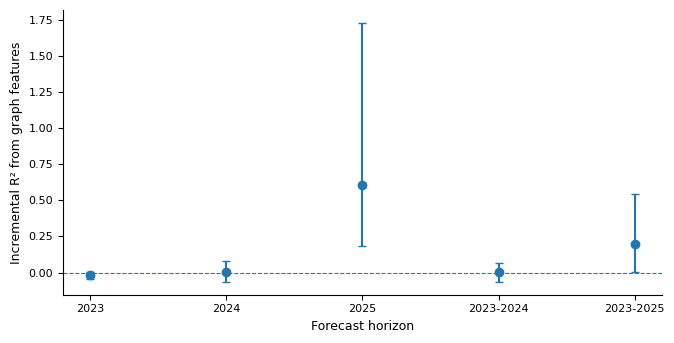

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation/figures/Fig13_horizon_delta_R2_hgb.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation/figures/Fig13_horizon_delta_R2_hgb.png


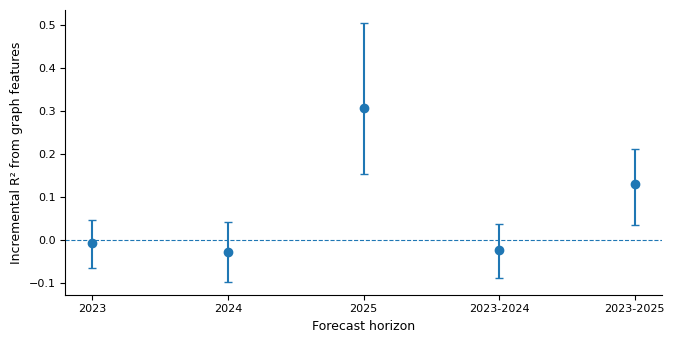

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation/figures/Fig14_graph_group_ablation_hgb_2023_2025.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation/figures/Fig14_graph_group_ablation_hgb_2023_2025.png


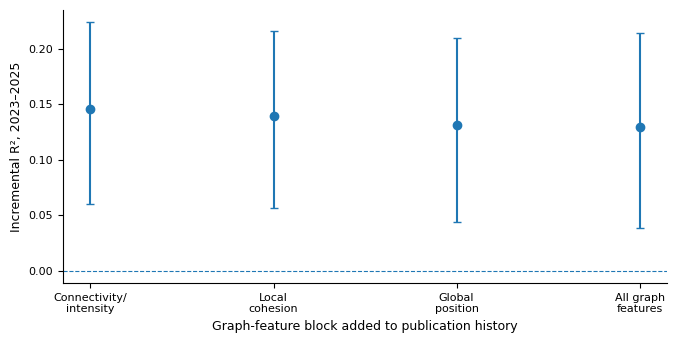


BLOCOS PARA ENVIAR DE VOLTA
1) TABLE 24B — ANNUAL OUTCOME RECONSTRUCTION AUDIT
2) TABLE 24C — OUTCOME DISTRIBUTION BY HORIZON
3) TABLE 25 — HORIZON DECOMPOSITION PERFORMANCE
4) TABLE 26 — HORIZON DECOMPOSITION: PAIRED BOOTSTRAP
5) TABLE 29 — HORIZON MECHANISM SUMMARY
6) TABLE 30 — GRAPH-GROUP ABLATION SUMMARY

Saved to: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/10_horizon_annual_ablation

CONCLUÍDO.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.10 — DECOMPOSIÇÃO ANUAL DO HORIZONTE E ABLAÇÃO DE FEATURES DE REDE

Esta etapa é diagnóstica/post hoc. O endpoint primário continua sendo
future_works_2023_2024; 2023–2025 continua como sensibilidade de horizonte.

Execução no Colab:
%run /content/Parte_18_10_Horizon_Annual_Ablation.py
"""

from __future__ import annotations

import json
import pickle
import re
import sys
import warnings
import importlib
from pathlib import Path

# --------------------------------------------------------------------------------------
# 0. DRIVE
# --------------------------------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception as e:
    print('[drive]', repr(e))

# --------------------------------------------------------------------------------------
# 1. DEPENDÊNCIAS
# --------------------------------------------------------------------------------------
def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name or import_name])
        return importlib.import_module(import_name)

ensure('numpy')
ensure('pandas')
ensure('openpyxl')
ensure('sklearn', 'scikit-learn')
ensure('scipy')
ensure('matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings('ignore', category=RuntimeWarning)

# --------------------------------------------------------------------------------------
# 2. CAMINHOS / FREEZE
# --------------------------------------------------------------------------------------
ROOT = Path('/content/drive/MyDrive/tese_doutoral')
RUN_ROOT = ROOT / 'runs' / 'temporal_productivity_20260929'

PANEL_CANDIDATES = [
    RUN_ROOT / '09_horizon_sensitivity_final' / 'artifacts' / 'panel_model_ready_with_primary_outcome.csv',
    RUN_ROOT / '08_final_incremental_graph_validation' / 'artifacts' / 'panel_model_ready_with_primary_outcome.csv',
    RUN_ROOT / '06_cohort2022_prospective_panel' / 'panel_model_ready.csv',
]
PANEL_PATH = next((p for p in PANEL_CANDIDATES if p.exists()), None)
if PANEL_PATH is None:
    raise FileNotFoundError('Painel model-ready não encontrado.\n' + '\n'.join(map(str, PANEL_CANDIDATES)))

PUB_PATH = ROOT / 'runs/run_20260625_200032/input/producoes_final.xlsx'

HP_CANDIDATES = [
    RUN_ROOT / '08_final_incremental_graph_validation' / 'artifacts' / 'frozen_hyperparameters.json',
    RUN_ROOT / '07_prospective_modeling' / 'artifacts' / 'frozen_hyperparameters.json',
]
HP_PATH = next((p for p in HP_CANDIDATES if p.exists()), None)

OUT = RUN_ROOT / '10_horizon_annual_ablation'
TAB = OUT / 'tables'
FIG = OUT / 'figures'
ART = OUT / 'artifacts'
LOG = OUT / 'logs'
for d in [OUT, TAB, FIG, ART, LOG]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 20260929
N_SPLITS = 10
BOOTSTRAP_B = 5000

HISTORY = [
    'past_works_2018_2022',
    'past_active_years_2018_2022',
    'recent_works_2021_2022',
]

GRAPH_ALL = [
    'degree', 'strength', 'avg_tie_strength', 'weighted_clustering',
    'pagerank', 'betweenness', 'core_number', 'avg_neighbor_degree',
    'component_size', 'is_isolate',
]

GRAPH_GROUPS = {
    'connectivity_intensity': ['degree', 'strength', 'avg_tie_strength'],
    'local_cohesion': ['weighted_clustering', 'core_number', 'avg_neighbor_degree'],
    'global_position': ['pagerank', 'betweenness', 'component_size', 'is_isolate'],
    'all_graph': GRAPH_ALL,
}

OUTCOME_SPECS = [
    ('future_works_2023', '2023', 'posthoc_annual'),
    ('future_works_2024', '2024', 'posthoc_annual'),
    ('future_works_2025', '2025', 'posthoc_annual'),
    ('future_works_2023_2024', '2023-2024', 'primary'),
    ('future_works_2023_2025', '2023-2025', 'horizon_sensitivity'),
]

# --------------------------------------------------------------------------------------
# 3. HELPERS
# --------------------------------------------------------------------------------------
def show_df(name, df, max_rows=80):
    print('\n' + '=' * 120)
    print(name)
    print('=' * 120)
    print(df.head(max_rows).to_string(index=False))
    if len(df) > max_rows:
        print(f'... ({len(df):,} rows total)')
    if display is not None:
        display(df.head(max_rows))


def extract_openalex(series, prefix):
    return series.astype(str).str.upper().str.extract(rf'({prefix}\d+)', expand=False)


def best_openalex_column(df, prefix):
    rows = []
    for c in df.columns:
        ids = extract_openalex(df[c], prefix)
        rows.append({'column': c, 'share': float(ids.notna().mean()), 'n_unique': int(ids.nunique(dropna=True))})
    audit = pd.DataFrame(rows).sort_values(['share', 'n_unique'], ascending=False)
    if audit.empty or audit.iloc[0]['share'] <= 0:
        return None, audit
    return str(audit.iloc[0]['column']), audit


def best_year_column(df):
    rows = []
    for c in df.columns:
        vals = pd.to_numeric(df[c], errors='coerce')
        ok = vals.between(1900, 2030)
        if ok.sum() == 0:
            continue
        name = str(c).lower()
        bonus = 10 if name in {'ano', 'year', 'publication_year'} else (3 if ('ano' in name or 'year' in name) else 0)
        rows.append({
            'column': c,
            'valid_share': float(ok.mean()),
            'valid_n': int(ok.sum()),
            'min': float(vals[ok].min()),
            'max': float(vals[ok].max()),
            'n_unique': int(vals[ok].nunique()),
            'score': float(ok.mean()) + bonus,
        })
    audit = pd.DataFrame(rows).sort_values(['score', 'n_unique', 'valid_n'], ascending=False)
    if audit.empty:
        return None, audit
    return str(audit.iloc[0]['column']), audit


def find_doi_column(df):
    best = None
    best_share = 0.0
    for c in df.columns:
        s = df[c].astype(str).str.lower()
        share = float(s.str.contains(r'10\.\d{4,9}/', regex=True, na=False).mean())
        if share > best_share:
            best, best_share = c, share
    if best_share > 0.01:
        return str(best)
    for c in df.columns:
        if 'doi' in str(c).lower():
            return str(c)
    return None


def find_title_column(df):
    low = {str(c).lower(): c for c in df.columns}
    for k in ['titulo', 'title', 'display_name', 'work_title']:
        if k in low:
            return str(low[k])
    for c in df.columns:
        if 'titulo' in str(c).lower() or 'title' in str(c).lower():
            return str(c)
    return None


def normalize_title(x):
    s = str(x).lower().strip()
    s = re.sub(r'\s+', ' ', s)
    s = re.sub(r'[^a-z0-9à-ÿ ]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()


def build_publication_long(pub):
    author_col, author_audit = best_openalex_column(pub, 'A')
    work_col, work_audit = best_openalex_column(pub, 'W')
    year_col, year_audit = best_year_column(pub)
    if author_col is None:
        raise RuntimeError('Não foi possível identificar coluna de OpenAlex Author ID (A...).')
    if year_col is None:
        raise RuntimeError('Não foi possível identificar coluna de ano.')

    author_key = extract_openalex(pub[author_col], 'A')
    year = pd.to_numeric(pub[year_col], errors='coerce')
    work_key = pd.Series(index=pub.index, dtype='object')
    key_source = pd.Series(index=pub.index, dtype='object')

    if work_col is not None:
        wid = extract_openalex(pub[work_col], 'W')
        m = wid.notna()
        work_key.loc[m] = 'W:' + wid.loc[m]
        key_source.loc[m] = 'openalex_work_id'

    doi_col = find_doi_column(pub)
    if doi_col is not None:
        doi = pub[doi_col].astype(str).str.lower().str.strip()
        doi = doi.str.replace('https://doi.org/', '', regex=False).str.replace('http://doi.org/', '', regex=False)
        m = work_key.isna() & doi.str.contains(r'10\.\d{4,9}/', regex=True, na=False)
        work_key.loc[m] = 'DOI:' + doi.loc[m]
        key_source.loc[m] = 'doi'

    title_col = find_title_column(pub)
    if title_col is not None:
        title = pub[title_col].map(normalize_title)
        ytxt = year.round().astype('Int64').astype(str)
        m = work_key.isna() & title.ne('')
        work_key.loc[m] = 'TY:' + title.loc[m] + '|' + ytxt.loc[m]
        key_source.loc[m] = 'title_year'

    x = pd.DataFrame({'author_key': author_key, 'year': year, 'work_key': work_key, 'work_key_source': key_source})
    x = x[x['author_key'].notna() & x['year'].between(1900, 2030) & x['work_key'].notna()].copy()
    x['year'] = x['year'].astype(int)
    x = x.drop_duplicates(['author_key', 'work_key', 'year'])

    meta = {
        'author_col': author_col,
        'work_col': work_col,
        'year_col': year_col,
        'doi_col': doi_col,
        'title_col': title_col,
        'n_long_rows': int(len(x)),
        'n_authors': int(x['author_key'].nunique()),
        'n_works': int(x['work_key'].nunique()),
        'min_year': int(x['year'].min()),
        'max_year': int(x['year'].max()),
    }
    return x, meta, {'author_audit': author_audit, 'work_audit': work_audit, 'year_audit': year_audit}


def load_hp():
    defaults = {
        'poisson_history_alpha': 0.5,
        'poisson_combined_alpha': 1.0,
        'hgb_history_params': {
            'l2_regularization': 1.0, 'learning_rate': 0.03, 'max_iter': 200,
            'max_leaf_nodes': 7, 'min_samples_leaf': 15,
        },
        'hgb_combined_params': {
            'l2_regularization': 0.0, 'learning_rate': 0.03, 'max_iter': 200,
            'max_leaf_nodes': 7, 'min_samples_leaf': 15,
        },
    }
    if HP_PATH is None:
        return defaults, 'Part18.8 reported defaults'
    try:
        hp = json.loads(HP_PATH.read_text(encoding='utf-8'))
        for k, v in defaults.items():
            hp.setdefault(k, v)
        return hp, str(HP_PATH)
    except Exception:
        return defaults, 'Part18.8 reported defaults after JSON read failure'


def make_model(family, block_type, hp):
    if family == 'poisson':
        alpha = float(hp['poisson_history_alpha'] if block_type == 'history' else hp['poisson_combined_alpha'])
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', PoissonRegressor(alpha=alpha, max_iter=3000, tol=1e-8)),
        ])
    if family == 'hgb':
        params = dict(hp['hgb_history_params'] if block_type == 'history' else hp['hgb_combined_params'])
        params['random_state'] = RANDOM_STATE
        params['loss'] = 'poisson'
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', HistGradientBoostingRegressor(**params)),
        ])
    raise ValueError(f'Unknown family: {family}')


def clip_pred(pred):
    return np.clip(np.asarray(pred, dtype=float), 1e-9, None)


def perf(y, pred):
    y = np.asarray(y, dtype=float)
    pred = clip_pred(pred)
    rho = spearmanr(y, pred).statistic
    if not np.isfinite(rho):
        rho = np.nan
    return {
        'MAE': float(mean_absolute_error(y, pred)),
        'RMSE': float(mean_squared_error(y, pred) ** 0.5),
        'R2': float(r2_score(y, pred)),
        'Poisson_deviance': float(mean_poisson_deviance(y, pred)),
        'Spearman_rho': float(rho) if np.isfinite(rho) else np.nan,
        'mean_observed': float(np.mean(y)),
        'mean_predicted': float(np.mean(pred)),
    }


def oof_predict(df, features, outcome, family, block_type, hp, splits):
    X = df[features].apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(df[outcome], errors='coerce').to_numpy(dtype=float)
    pred = np.full(len(df), np.nan)
    for train_idx, test_idx in splits:
        model = make_model(family, block_type, hp)
        model.fit(X.iloc[train_idx], y[train_idx])
        pred[test_idx] = clip_pred(model.predict(X.iloc[test_idx]))
    if np.isnan(pred).any():
        raise RuntimeError(f'OOF incompleto: {outcome}, {family}, {block_type}')
    return pred


def incremental(y, pred_h, pred_c):
    h, c = perf(y, pred_h), perf(y, pred_c)
    return {
        'delta_MAE': h['MAE'] - c['MAE'],
        'delta_RMSE': h['RMSE'] - c['RMSE'],
        'delta_R2': c['R2'] - h['R2'],
        'delta_Poisson_deviance': h['Poisson_deviance'] - c['Poisson_deviance'],
    }


def paired_bootstrap(y, pred_h, pred_c, B, seed):
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    pred_h, pred_c = np.asarray(pred_h), np.asarray(pred_c)
    obs = incremental(y, pred_h, pred_c)
    vals = {k: np.empty(B) for k in obs}
    n = len(y)
    for b in range(B):
        idx = rng.integers(0, n, n)
        d = incremental(y[idx], pred_h[idx], pred_c[idx])
        for k in vals:
            vals[k][b] = d[k]
        if (b + 1) % 1000 == 0:
            print(f'    bootstrap {b+1}/{B}')
    rows = []
    for k, arr in vals.items():
        rows.append({
            'metric': k,
            'observed': float(obs[k]),
            'bootstrap_median': float(np.median(arr)),
            'ci95_low': float(np.quantile(arr, 0.025)),
            'ci95_high': float(np.quantile(arr, 0.975)),
            'positive_share': float(np.mean(arr > 0)),
            'bootstrap_B': B,
        })
    return pd.DataFrame(rows)


def save_figure(fig, stem):
    eps = FIG / f'{stem}.eps'
    png = FIG / f'{stem}.png'
    fig.savefig(eps, format='eps', bbox_inches='tight')
    fig.savefig(png, dpi=600, bbox_inches='tight')
    print('[figure]', eps)
    print('[figure]', png)

# --------------------------------------------------------------------------------------
# 4. INPUT
# --------------------------------------------------------------------------------------
print('\n' + '=' * 120)
print('PARTE 18.10 — DECOMPOSIÇÃO ANUAL DO HORIZONTE E ABLAÇÃO DE FEATURES DE REDE')
print('=' * 120)
print('[panel]       ', PANEL_PATH)
print('[publications]', PUB_PATH)
print('[hp]          ', HP_PATH if HP_PATH else 'fallback')
print('[output]      ', OUT)

panel = pd.read_csv(PANEL_PATH)
pub = pd.read_excel(PUB_PATH)
print('Panel shape:', panel.shape)
print('Publications shape:', pub.shape)

required = ['author_key'] + HISTORY + GRAPH_ALL
missing = [c for c in required if c not in panel.columns]
if missing:
    raise KeyError('Features ausentes no painel:\n' + '\n'.join(missing))

panel['author_key'] = extract_openalex(panel['author_key'], 'A')
if panel['author_key'].isna().any():
    raise RuntimeError('Há author_key sem A-id válido no painel.')
if panel['author_key'].duplicated().any():
    raise RuntimeError('Há author_key duplicado no painel.')

long_pub, pub_meta, audits = build_publication_long(pub)
pd.DataFrame([pub_meta]).to_csv(TAB / 'Table_24A_publication_identifier_audit.csv', index=False)
audits['author_audit'].to_csv(TAB / 'audit_author_columns.csv', index=False)
audits['work_audit'].to_csv(TAB / 'audit_work_columns.csv', index=False)
audits['year_audit'].to_csv(TAB / 'audit_year_columns.csv', index=False)
show_df('TABLE 24A — PUBLICATION IDENTIFIER AUDIT', pd.DataFrame([pub_meta]))

hp, hp_source = load_hp()
print('\nFrozen hyperparameters source:', hp_source)
print(json.dumps(hp, indent=2, ensure_ascii=False))

# --------------------------------------------------------------------------------------
# 5. OUTCOMES ANUAIS
# --------------------------------------------------------------------------------------
cohort_ids = set(panel['author_key'])
annual = (
    long_pub[long_pub['author_key'].isin(cohort_ids) & long_pub['year'].between(2023, 2025)]
    .groupby(['author_key', 'year'])['work_key'].nunique().unstack(fill_value=0)
)
for yr in [2023, 2024, 2025]:
    if yr not in annual.columns:
        annual[yr] = 0
annual = annual[[2023, 2024, 2025]]
annual.columns = ['future_works_2023', 'future_works_2024', 'future_works_2025']
annual = annual.reset_index()

panel2 = panel.merge(annual, on='author_key', how='left')
for c in ['future_works_2023', 'future_works_2024', 'future_works_2025']:
    panel2[c] = panel2[c].fillna(0).astype(int)

panel2['reconstructed_2023_2024'] = panel2['future_works_2023'] + panel2['future_works_2024']
panel2['reconstructed_2023_2025'] = panel2['reconstructed_2023_2024'] + panel2['future_works_2025']

if 'future_works_2023_2024' not in panel2.columns:
    panel2['future_works_2023_2024'] = panel2['reconstructed_2023_2024']
if 'future_works_2023_2025' not in panel2.columns:
    panel2['future_works_2023_2025'] = panel2['reconstructed_2023_2025']

panel2['future_works_2023_2024'] = pd.to_numeric(panel2['future_works_2023_2024'], errors='coerce').fillna(panel2['reconstructed_2023_2024'])
panel2['future_works_2023_2025'] = pd.to_numeric(panel2['future_works_2023_2025'], errors='coerce').fillna(panel2['reconstructed_2023_2025'])

audit_rows = []
for col, recon in [('future_works_2023_2024', 'reconstructed_2023_2024'), ('future_works_2023_2025', 'reconstructed_2023_2025')]:
    diff = panel2[col] - panel2[recon]
    audit_rows.append({
        'outcome': col,
        'n': len(panel2),
        'n_discrepant_vs_annual_sum': int((diff.abs() > 1e-9).sum()),
        'max_abs_difference': float(diff.abs().max()),
    })
outcome_audit = pd.DataFrame(audit_rows)
outcome_audit.to_csv(TAB / 'Table_24B_annual_outcome_reconstruction_audit.csv', index=False)
show_df('TABLE 24B — ANNUAL OUTCOME RECONSTRUCTION AUDIT', outcome_audit)
if (outcome_audit['n_discrepant_vs_annual_sum'] > 0).any():
    raise RuntimeError('Cumulativos não coincidem com a soma anual. Interrompido.')

outcome_desc = []
for outcome, horizon, status in OUTCOME_SPECS:
    y = panel2[outcome]
    outcome_desc.append({
        'outcome': outcome, 'horizon': horizon, 'status': status, 'n': len(y),
        'zero_n': int((y == 0).sum()), 'zero_pct': float((y == 0).mean() * 100),
        'mean': float(y.mean()), 'median': float(y.median()),
        'p95': float(y.quantile(.95)), 'max': float(y.max()),
    })
outcome_desc = pd.DataFrame(outcome_desc)
outcome_desc.to_csv(TAB / 'Table_24C_outcome_distribution_by_horizon.csv', index=False)
show_df('TABLE 24C — OUTCOME DISTRIBUTION BY HORIZON', outcome_desc)
panel2.to_csv(ART / 'panel_with_annual_and_cumulative_outcomes.csv', index=False)

# --------------------------------------------------------------------------------------
# 6. FOLDS PAREADOS
# --------------------------------------------------------------------------------------
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
splits = list(kf.split(panel2))
fold_assignment = np.full(len(panel2), -1, dtype=int)
for fold, (_, test_idx) in enumerate(splits, start=1):
    fold_assignment[test_idx] = fold
pd.DataFrame({'author_key': panel2['author_key'], 'fold': fold_assignment}).to_csv(ART / 'canonical_10fold_assignments.csv', index=False)

# --------------------------------------------------------------------------------------
# 7. DECOMPOSIÇÃO DO HORIZONTE
# --------------------------------------------------------------------------------------
performance_rows = []
increment_list = []
oof_rows = []

for outcome, horizon, status in OUTCOME_SPECS:
    print('\n' + '=' * 120)
    print(f'HORIZON DECOMPOSITION — {outcome} ({horizon}; {status})')
    print('=' * 120)
    y = panel2[outcome].to_numpy(dtype=float)

    for family in ['poisson', 'hgb']:
        print(f'[{family}] history vs combined')
        pred_h = oof_predict(panel2, HISTORY, outcome, family, 'history', hp, splits)
        pred_c = oof_predict(panel2, HISTORY + GRAPH_ALL, outcome, family, 'combined', hp, splits)

        for block, pred in [('history', pred_h), ('combined', pred_c)]:
            performance_rows.append({
                'outcome': outcome, 'horizon': horizon, 'status': status,
                'family': family, 'block': block, **perf(y, pred)
            })
            for i in range(len(panel2)):
                oof_rows.append({
                    'author_key': panel2.loc[i, 'author_key'], 'outcome': outcome,
                    'horizon': horizon, 'status': status, 'family': family,
                    'block': block, 'fold': int(fold_assignment[i]),
                    'y': float(y[i]), 'prediction': float(pred[i])
                })

        print(f'  paired bootstrap B={BOOTSTRAP_B}')
        b = paired_bootstrap(y, pred_h, pred_c, BOOTSTRAP_B, RANDOM_STATE + sum(map(ord, outcome + family)))
        b.insert(0, 'family', family)
        b.insert(0, 'status', status)
        b.insert(0, 'horizon', horizon)
        b.insert(0, 'outcome', outcome)
        increment_list.append(b)

performance = pd.DataFrame(performance_rows)
increment = pd.concat(increment_list, ignore_index=True)
oof = pd.DataFrame(oof_rows)
performance.to_csv(TAB / 'Table_25_horizon_decomposition_performance.csv', index=False)
increment.to_csv(TAB / 'Table_26_horizon_decomposition_paired_bootstrap.csv', index=False)
oof.to_csv(ART / 'oof_predictions_horizon_decomposition.csv', index=False)
show_df('TABLE 25 — HORIZON DECOMPOSITION PERFORMANCE', performance)
show_df('TABLE 26 — HORIZON DECOMPOSITION: PAIRED BOOTSTRAP', increment)

# --------------------------------------------------------------------------------------
# 8. ABLAÇÃO DE BLOCOS — 2023–2025
# --------------------------------------------------------------------------------------
ABLATION_OUTCOME = 'future_works_2023_2025'
y_ab = panel2[ABLATION_OUTCOME].to_numpy(dtype=float)
ab_perf_rows, ab_boot_list, ab_oof_rows = [], [], []

for family in ['poisson', 'hgb']:
    print('\n' + '=' * 120)
    print(f'GRAPH-GROUP ABLATION — {family.upper()} — 2023–2025')
    print('=' * 120)
    pred_h = oof_predict(panel2, HISTORY, ABLATION_OUTCOME, family, 'history', hp, splits)
    ab_perf_rows.append({'family': family, 'graph_group': 'history_only', 'n_graph_features': 0, **perf(y_ab, pred_h)})

    for group_name, graph_feats in GRAPH_GROUPS.items():
        print(f'[{group_name}] {len(graph_feats)} feature(s)')
        pred_g = oof_predict(panel2, HISTORY + graph_feats, ABLATION_OUTCOME, family, 'combined', hp, splits)
        ab_perf_rows.append({'family': family, 'graph_group': group_name, 'n_graph_features': len(graph_feats), **perf(y_ab, pred_g)})

        b = paired_bootstrap(y_ab, pred_h, pred_g, BOOTSTRAP_B, RANDOM_STATE + sum(map(ord, family + group_name)))
        b.insert(0, 'n_graph_features', len(graph_feats))
        b.insert(0, 'graph_group', group_name)
        b.insert(0, 'family', family)
        ab_boot_list.append(b)

        for i in range(len(panel2)):
            ab_oof_rows.append({
                'author_key': panel2.loc[i, 'author_key'], 'family': family,
                'graph_group': group_name, 'fold': int(fold_assignment[i]),
                'y': float(y_ab[i]), 'history_prediction': float(pred_h[i]),
                'candidate_prediction': float(pred_g[i])
            })

ab_perf = pd.DataFrame(ab_perf_rows)
ab_boot = pd.concat(ab_boot_list, ignore_index=True)
ab_oof = pd.DataFrame(ab_oof_rows)
ab_perf.to_csv(TAB / 'Table_27_graph_group_ablation_performance.csv', index=False)
ab_boot.to_csv(TAB / 'Table_28_graph_group_ablation_bootstrap.csv', index=False)
ab_oof.to_csv(ART / 'oof_predictions_graph_group_ablation.csv', index=False)
show_df('TABLE 27 — GRAPH-GROUP ABLATION PERFORMANCE', ab_perf)
show_df('TABLE 28 — GRAPH-GROUP ABLATION: PAIRED BOOTSTRAP', ab_boot)

# --------------------------------------------------------------------------------------
# 9. RESUMOS MECANÍSTICOS
# --------------------------------------------------------------------------------------
delta_r2 = increment[increment['metric'] == 'delta_R2'].copy()
annual_only = delta_r2[delta_r2['status'] == 'posthoc_annual'].copy()
mechanism_rows = []
for family in ['poisson', 'hgb']:
    sub = annual_only[annual_only['family'] == family].copy()
    best = sub.sort_values('observed', ascending=False).iloc[0]
    primary = delta_r2[(delta_r2['family'] == family) & (delta_r2['outcome'] == 'future_works_2023_2024')].iloc[0]
    long = delta_r2[(delta_r2['family'] == family) & (delta_r2['outcome'] == 'future_works_2023_2025')].iloc[0]
    mechanism_rows.append({
        'family': family,
        'primary_2023_2024_delta_R2': float(primary['observed']),
        'primary_ci95_low': float(primary['ci95_low']),
        'primary_ci95_high': float(primary['ci95_high']),
        'long_2023_2025_delta_R2': float(long['observed']),
        'long_ci95_low': float(long['ci95_low']),
        'long_ci95_high': float(long['ci95_high']),
        'largest_annual_delta_R2_year': str(best['horizon']),
        'largest_annual_delta_R2': float(best['observed']),
        'largest_annual_ci95_low': float(best['ci95_low']),
        'largest_annual_ci95_high': float(best['ci95_high']),
    })
mechanism = pd.DataFrame(mechanism_rows)
mechanism.to_csv(TAB / 'Table_29_horizon_mechanism_summary.csv', index=False)
show_df('TABLE 29 — HORIZON MECHANISM SUMMARY', mechanism)

r2 = ab_boot[ab_boot['metric'] == 'delta_R2'][['family', 'graph_group', 'n_graph_features', 'observed', 'ci95_low', 'ci95_high', 'positive_share']].rename(columns={
    'observed': 'delta_R2', 'ci95_low': 'delta_R2_ci95_low', 'ci95_high': 'delta_R2_ci95_high', 'positive_share': 'delta_R2_positive_share'
})
mae = ab_boot[ab_boot['metric'] == 'delta_MAE'][['family', 'graph_group', 'observed', 'ci95_low', 'ci95_high', 'positive_share']].rename(columns={
    'observed': 'delta_MAE', 'ci95_low': 'delta_MAE_ci95_low', 'ci95_high': 'delta_MAE_ci95_high', 'positive_share': 'delta_MAE_positive_share'
})
ab_summary = r2.merge(mae, on=['family', 'graph_group'], how='left')
ab_summary.to_csv(TAB / 'Table_30_graph_group_ablation_summary.csv', index=False)
show_df('TABLE 30 — GRAPH-GROUP ABLATION SUMMARY', ab_summary)

# --------------------------------------------------------------------------------------
# 10. FIGURAS
# --------------------------------------------------------------------------------------
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 9, 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

order = ['2023', '2024', '2025', '2023-2024', '2023-2025']
for family, stem in [('poisson', 'Fig12_horizon_delta_R2_poisson'), ('hgb', 'Fig13_horizon_delta_R2_hgb')]:
    p = delta_r2[delta_r2['family'] == family].copy()
    p['horizon'] = pd.Categorical(p['horizon'], categories=order, ordered=True)
    p = p.sort_values('horizon')
    x = np.arange(len(p))
    y = p['observed'].to_numpy()
    lo = y - p['ci95_low'].to_numpy()
    hi = p['ci95_high'].to_numpy() - y
    fig, ax = plt.subplots(figsize=(6.85, 3.5))
    ax.errorbar(x, y, yerr=np.vstack([lo, hi]), fmt='o', capsize=3)
    ax.axhline(0, linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(p['horizon'].astype(str))
    ax.set_xlabel('Forecast horizon')
    ax.set_ylabel('Incremental R² from graph features')
    fig.tight_layout()
    save_figure(fig, stem)
    if display is not None:
        display(fig)
    else:
        plt.show()
    plt.close(fig)

p = ab_summary[ab_summary['family'] == 'hgb'].copy()
ab_order = ['connectivity_intensity', 'local_cohesion', 'global_position', 'all_graph']
p['graph_group'] = pd.Categorical(p['graph_group'], categories=ab_order, ordered=True)
p = p.sort_values('graph_group')
x = np.arange(len(p))
y = p['delta_R2'].to_numpy()
lo = y - p['delta_R2_ci95_low'].to_numpy()
hi = p['delta_R2_ci95_high'].to_numpy() - y
fig, ax = plt.subplots(figsize=(6.85, 3.5))
ax.errorbar(x, y, yerr=np.vstack([lo, hi]), fmt='o', capsize=3)
ax.axhline(0, linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(['Connectivity/\nintensity', 'Local\ncohesion', 'Global\nposition', 'All graph\nfeatures'])
ax.set_xlabel('Graph-feature block added to publication history')
ax.set_ylabel('Incremental R², 2023–2025')
fig.tight_layout()
save_figure(fig, 'Fig14_graph_group_ablation_hgb_2023_2025')
if display is not None:
    display(fig)
else:
    plt.show()
plt.close(fig)

# --------------------------------------------------------------------------------------
# 11. FREEZE
# --------------------------------------------------------------------------------------
freeze = {
    'part': '18.10',
    'status': 'diagnostic_posthoc',
    'primary_outcome_remains': 'future_works_2023_2024',
    'horizon_sensitivity': 'future_works_2023_2025',
    'annual_outcomes_are': 'posthoc diagnostics',
    'panel_path': str(PANEL_PATH),
    'publication_path': str(PUB_PATH),
    'hyperparameter_source': hp_source,
    'history_features': HISTORY,
    'graph_groups': GRAPH_GROUPS,
    'random_state': RANDOM_STATE,
    'n_splits': N_SPLITS,
    'bootstrap_B': BOOTSTRAP_B,
}
(ART / 'part18_10_freeze.json').write_text(json.dumps(freeze, indent=2, ensure_ascii=False), encoding='utf-8')
with open(ART / 'part18_10_freeze.pkl', 'wb') as f:
    pickle.dump({
        'freeze': freeze,
        'performance': performance,
        'increment': increment,
        'ablation_performance': ab_perf,
        'ablation_bootstrap': ab_boot,
        'mechanism': mechanism,
        'panel': panel2,
        'oof': oof,
    }, f, pickle.HIGHEST_PROTOCOL)

readme = f'''PARTE 18.10 — DECOMPOSIÇÃO ANUAL E ABLAÇÃO

Esta análise é DIAGNÓSTICA/POST HOC.
Endpoint primário congelado: future_works_2023_2024
Sensibilidade de horizonte: future_works_2023_2025

Objetivos:
- decompor 2023–2025 em 2023, 2024 e 2025;
- localizar temporalmente o ganho incremental;
- testar connectivity/intensity, local cohesion, global position e all graph.

Nenhum resultado desta etapa redefine retrospectivamente o endpoint primário.

Hyperparameters:
{json.dumps(hp, indent=2, ensure_ascii=False)}
'''
(LOG / 'README_Part18_10.txt').write_text(readme, encoding='utf-8')

print('\n' + '=' * 120)
print('BLOCOS PARA ENVIAR DE VOLTA')
print('=' * 120)
print('1) TABLE 24B — ANNUAL OUTCOME RECONSTRUCTION AUDIT')
print('2) TABLE 24C — OUTCOME DISTRIBUTION BY HORIZON')
print('3) TABLE 25 — HORIZON DECOMPOSITION PERFORMANCE')
print('4) TABLE 26 — HORIZON DECOMPOSITION: PAIRED BOOTSTRAP')
print('5) TABLE 29 — HORIZON MECHANISM SUMMARY')
print('6) TABLE 30 — GRAPH-GROUP ABLATION SUMMARY')
print('\nSaved to:', OUT)
print('\nCONCLUÍDO.')


[drive] Google Drive já montado; reutilizando /content/drive.
[hp] frozen hyperparameters loaded: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/frozen_hyperparameters.json

PARTE 18.11 v2 — MECANISMO 2025: MARGEM EXTENSIVA E INTENSIVA
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/08_final_incremental_graph_validation/artifacts/panel_model_ready_with_primary_outcome.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive
Panel shape: (500, 41)
Publications shape: (38138, 9)

TABLE 30 — PUBLICATION IDENTIFIER AUDIT
author_col    work_col year_col doi_col title_col  n_long_rows  n_authors  n_works  min_year  max_year  openalex_work_key_share
  autor_id id_openalex      ano     doi    titulo        3

,author_col,work_col,year_col,doi_col,title_col,n_long_rows,n_authors,n_works,min_year,max_year,openalex_work_key_share
0,autor_id,id_openalex,ano,doi,titulo,34613,499,30503,1914,2025,1.0


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/tables/Table_30_publication_identifier_audit.csv

TABLE 31 — ANNUAL OUTCOME RECONSTRUCTION AUDIT
                      comparison   n  n_discrepant  max_abs_difference
existing_2023_2024_vs_annual_sum 500             0                 0.0
existing_2023_2025_vs_annual_sum 500             0                 0.0


,comparison,n,n_discrepant,max_abs_difference
0,existing_2023_2024_vs_annual_sum,500,0,0.0
1,existing_2023_2025_vs_annual_sum,500,0,0.0


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/tables/Table_31_annual_outcome_reconstruction_audit.csv
[panel repaired] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/panel_with_annual_2023_2025_outcomes.csv

TABLE 32 — ANNUAL AUTHOR-LEVEL OUTCOME AUDIT
 year  n_authors  active_authors  inactive_authors  active_pct  total_author_work_counts  mean  median  p95  max
 2023        500             389               111        77.8                      1669 3.338     2.0 11.0 27.0
 2024        500             376               124        75.2                      1736 3.472     2.0 12.0 37.0
 2025        500             240               260        48.0                       941 1.882     0.0 10.0 51.0


...

,family,metric,favorable_direction,observed,bootstrap_median,ci95_low,ci95_high,positive_share,two_sided_bootstrap_p,bootstrap_B
0,poisson,delta_MAE,positive = graph block improves prediction,0.539781,0.532815,0.185666,0.920845,0.9982,0.0036,5000
1,poisson,delta_RMSE,positive = graph block improves prediction,1.171309,1.129498,0.374419,2.063313,0.9988,0.0024,5000
2,poisson,delta_R2,positive = graph block improves prediction,0.333062,0.316769,0.111586,0.732828,0.9988,0.0024,5000
3,poisson,delta_Poisson_deviance,positive = graph block improves prediction,1.491392,1.476549,0.733500,2.318755,1.0000,0.0000,5000
4,hgb,delta_MAE,positive = graph block improves prediction,0.778763,0.777647,0.328164,1.235278,1.0000,0.0000,5000
5,hgb,delta_RMSE,positive = graph block improves prediction,1.370237,1.362751,0.460054,2.253158,0.9980,0.0040,5000
6,hgb,delta_R2,positive = graph block improves prediction,0.386831,0.384159,0.142563,0.757500,0.9980,0.0040,5000
7,hgb,delta_Poisson_deviance,positive = graph block improves prediction,1.911637,1.900520,1.038274,2.825572,1.0000,0.0000,5000


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/tables/Table_37_intensive_margin_incremental_graph_value.csv

TABLE 38 — SLOPE-ADJUSTED MECHANISM SENSITIVITY
   margin   family               block  metric    value
extensive logistic  history_plus_slope ROC_AUC 0.766715
extensive logistic combined_plus_slope ROC_AUC 0.748974
intensive  poisson  history_plus_slope     MAE 3.043902
intensive  poisson combined_plus_slope     MAE 2.569038


,margin,family,block,metric,value
0,extensive,logistic,history_plus_slope,ROC_AUC,0.766715
1,extensive,logistic,combined_plus_slope,ROC_AUC,0.748974
2,intensive,poisson,history_plus_slope,MAE,3.043902
3,intensive,poisson,combined_plus_slope,MAE,2.569038


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/tables/Table_38_slope_adjusted_mechanism_sensitivity.csv


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/figures/Fig_11A_2025_extensive_margin_ROC.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/figures/Fig_11A_2025_extensive_margin_ROC.png


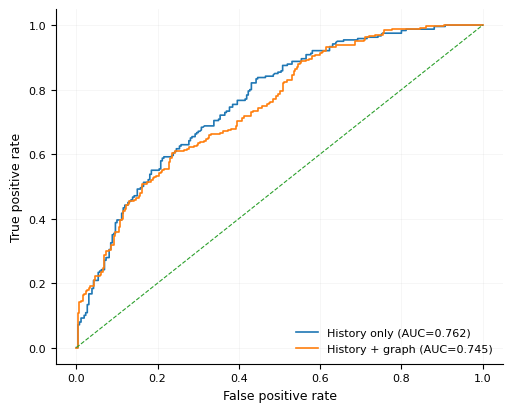

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/figures/Fig_11B_2025_intensive_margin_observed_predicted.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/figures/Fig_11B_2025_intensive_margin_observed_predicted.png


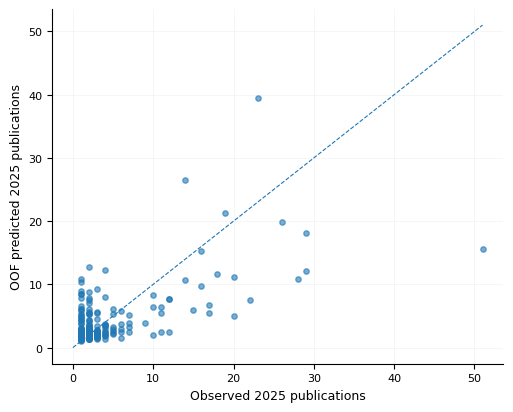

[artifact] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/oof_predictions_2025_extensive_margin.csv
[artifact] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/oof_predictions_2025_intensive_margin.csv

PART 18.11 v2 — SUMMARY
PARTE 18.11 v2 — MECANISMO 2025
Painel: 500 pesquisadores
Ativos em 2025: 240
Inativos em 2025: 260
Prevalência de atividade 2025: 48.00%

Margem extensiva — Logistic OOF
History-only ROC AUC: 0.7624
History+Graph ROC AUC: 0.7452
Delta ROC AUC: -0.0173

Margem intensiva — Poisson OOF | atividade 2025 > 0
n: 240
History-only MAE: 3.1428
History+Graph MAE: 2.6030
Delta MAE (history - combined; positivo favorece graph): +0.5398
History-only R2: 0.0856
History+Graph R2: 0.4187
Delta R2: +0.3331

Status interpretativo:
Análise pós-hoc/mecanística de 2025. Não substitui o desfecho primário 2023–2024.
[summary] /content/drive/

,type,name,path
0,table,Table_30_publication_identifier_audit.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
1,table,Table_31A_annual_outcome_reconstruction_audit.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
2,table,Table_31B_2025_activity_transition_summary.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
3,table,Table_31C_2025_activity_transition_counts.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
4,table,Table_31_annual_outcome_reconstruction_audit.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
5,table,Table_32A_feature_blocks.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
6,table,Table_32B_2025_mechanism_decision_gate.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
7,table,Table_32B_binary_task_composition.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
8,table,Table_32C_binary_cv_audit.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...
9,table,Table_32_annual_author_level_outcome_audit.csv,/content/drive/MyDrive/tese_doutoral/runs/temp...



BLOCOS PARA ENVIAR AO CHATGPT
1) TABLE 32 — ANNUAL AUTHOR-LEVEL OUTCOME AUDIT
2) TABLE 32B — 2025 MECHANISM DECISION GATE
3) TABLE 33 — EXTENSIVE-MARGIN BINARY PERFORMANCE
4) TABLE 34 — EXTENSIVE-MARGIN INCREMENTAL GRAPH VALUE
5) TABLE 35 — INTENSIVE-MARGIN COHORT SUMMARY
6) TABLE 36 — INTENSIVE-MARGIN COUNT PERFORMANCE
7) TABLE 37 — INTENSIVE-MARGIN INCREMENTAL GRAPH VALUE
8) TABLE 38 — SLOPE-ADJUSTED MECHANISM SENSITIVITY
9) PART 18.11 v2 — SUMMARY

CONCLUÍDO.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.11 v2 — MECANISMO 2025: MARGEM EXTENSIVA E INTENSIVA
==============================================================

Correção central
----------------
A versão anterior produziu Tables 33/34 vazias e depois IndexError porque o
subconjunto ativo em 2025 ficou vazio. Aqui `future_works_2025` é reconstruído
DIRETAMENTE do arquivo bruto `producoes_final.xlsx`, usando o esquema já
validado nas Partes 18.8/18.10:

    autor_id    -> autor OpenAlex (A...)
    id_openalex -> trabalho OpenAlex (W...)
    ano         -> ano de publicação

Fallback de chave de trabalho: W-id > DOI > título+ano.

Esta análise é pós-hoc/mecanística porque 2025 apresentou cobertura inferior
a 2023–2024. Ela NÃO substitui o desfecho primário 2023–2024.

Executar no Colab:
    %run /content/Parte_18_11_Mecanismo_2025_Extensive_Intensive_v2.py
"""

from __future__ import annotations

import json
import re
import sys
import warnings
import importlib
from pathlib import Path

warnings.filterwarnings("ignore")

# =============================================================================
# 0. DRIVE
# =============================================================================

if not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("[drive] falha ao montar:", repr(e))
else:
    print("[drive] Google Drive já montado; reutilizando /content/drive.")

# =============================================================================
# 1. DEPENDÊNCIAS
# =============================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("openpyxl")
ensure("sklearn", "scikit-learn")
ensure("scipy")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    accuracy_score, balanced_accuracy_score, mean_absolute_error,
    mean_squared_error, r2_score, mean_poisson_deviance, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

# =============================================================================
# 2. CAMINHOS
# =============================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
RUN = ROOT / "runs" / "temporal_productivity_20260929"

PANEL = RUN / "08_final_incremental_graph_validation" / "artifacts" / "panel_model_ready_with_primary_outcome.csv"
PANEL_FALLBACK = RUN / "06_cohort2022_prospective_panel" / "panel_model_ready.csv"
PUBLICATIONS = ROOT / "runs" / "run_20260625_200032" / "input" / "producoes_final.xlsx"
HP_PATH = RUN / "08_final_incremental_graph_validation" / "artifacts" / "frozen_hyperparameters.json"

if not PANEL.exists():
    PANEL = PANEL_FALLBACK

OUT = RUN / "11_mechanism_2025_extensive_intensive"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
ARTIFACTS = OUT / "artifacts"
NOTES = OUT / "notes"
for d in [TABLES, FIGURES, ARTIFACTS, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

for p in [PANEL, PUBLICATIONS]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {p}")

# =============================================================================
# 3. CONFIGURAÇÕES
# =============================================================================

SEED = 20260930
N_SPLITS = 10
BOOT_B = 5000

# Bloco primário da Parte 18.8: slope ficou como sensibilidade.
HISTORY = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
]
HISTORY_SLOPE = HISTORY + ["past_productivity_slope"]
GRAPH = [
    "degree", "strength", "avg_tie_strength", "weighted_clustering",
    "pagerank", "betweenness", "core_number", "avg_neighbor_degree",
    "component_size", "is_isolate",
]
COMBINED = HISTORY + GRAPH

DEFAULT_HP = {
    "poisson_history_alpha": 0.5,
    "poisson_combined_alpha": 1.0,
    "hgb_history_params": {
        "l2_regularization": 1.0, "learning_rate": 0.03,
        "max_iter": 200, "max_leaf_nodes": 7, "min_samples_leaf": 15,
    },
    "hgb_combined_params": {
        "l2_regularization": 0.0, "learning_rate": 0.03,
        "max_iter": 200, "max_leaf_nodes": 7, "min_samples_leaf": 15,
    },
}

if HP_PATH.exists():
    HP = json.loads(HP_PATH.read_text(encoding="utf-8"))
    print("[hp] frozen hyperparameters loaded:", HP_PATH)
else:
    HP = DEFAULT_HP.copy()
    print("[hp] usando defaults auditados porque o JSON não foi encontrado")

# =============================================================================
# 4. HELPERS
# =============================================================================

def header(text):
    print("\n" + "=" * 118)
    print(text)
    print("=" * 118)


def show_table(title, df, filename=None, max_rows=100):
    header(title)
    if df is None or df.empty:
        print("[vazio]")
    else:
        with pd.option_context("display.max_columns", None, "display.width", 220, "display.max_colwidth", 100):
            print(df.head(max_rows).to_string(index=False))
        if display is not None:
            display(df.head(max_rows))
    if filename:
        path = TABLES / filename
        (df if df is not None else pd.DataFrame()).to_csv(path, index=False)
        print("[table]", path)
    return df


def save_figure(fig, stem):
    eps = FIGURES / f"{stem}.eps"
    png = FIGURES / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)


def extract_aid(s):
    return s.astype(str).str.upper().str.extract(r"(A\d+)", expand=False)


def extract_wid(s):
    return s.astype(str).str.upper().str.extract(r"(W\d+)", expand=False)


def normalize_doi(s):
    z = s.astype(str).str.lower().str.strip()
    z = z.str.replace("https://doi.org/", "", regex=False)
    z = z.str.replace("http://doi.org/", "", regex=False)
    z = z.str.replace("doi:", "", regex=False)
    return z.where(z.str.contains(r"10\.\d{4,9}/", regex=True, na=False))


def normalize_title(s):
    z = s.fillna("").astype(str).str.lower()
    z = z.str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("ascii")
    z = z.str.replace(r"[^a-z0-9]+", " ", regex=True)
    return z.str.replace(r"\s+", " ", regex=True).str.strip()


def infer_publication_columns(pub):
    cols = list(pub.columns)
    lower = {str(c).strip().lower(): c for c in cols}

    # autor: maior proporção A-id; prefere autor_id quando válido
    author_scores = []
    for c in cols:
        try:
            share = extract_aid(pub[c]).notna().mean()
        except Exception:
            share = 0.0
        author_scores.append((c, share))
    author_scores.sort(key=lambda x: x[1], reverse=True)
    author_col = author_scores[0][0] if author_scores and author_scores[0][1] > .5 else None
    if "autor_id" in lower and extract_aid(pub[lower["autor_id"]]).notna().mean() > .5:
        author_col = lower["autor_id"]

    # trabalho: maior proporção W-id; prefere id_openalex quando válido
    work_scores = []
    for c in cols:
        if c == author_col:
            continue
        try:
            share = extract_wid(pub[c]).notna().mean()
        except Exception:
            share = 0.0
        work_scores.append((c, share))
    work_scores.sort(key=lambda x: x[1], reverse=True)
    work_col = work_scores[0][0] if work_scores and work_scores[0][1] > .2 else None
    if "id_openalex" in lower and extract_wid(pub[lower["id_openalex"]]).notna().mean() > .2:
        work_col = lower["id_openalex"]

    year_col = lower.get("ano", lower.get("year", lower.get("publication_year")))
    doi_col = lower.get("doi")
    title_col = lower.get("titulo", lower.get("title"))

    if year_col is None:
        best = (None, -1.0)
        for c in cols:
            num = pd.to_numeric(pub[c], errors="coerce")
            share = num.between(1900, 2030).mean()
            if share > best[1]:
                best = (c, share)
        year_col = best[0]

    return author_col, work_col, year_col, doi_col, title_col


def build_long_publications(pub, panel_authors):
    author_col, work_col, year_col, doi_col, title_col = infer_publication_columns(pub)
    if author_col is None or year_col is None:
        raise RuntimeError("Não foi possível inferir autor/ano nas publicações.")

    z = pd.DataFrame(index=pub.index)
    z["author_key"] = extract_aid(pub[author_col])
    z["year"] = pd.to_numeric(pub[year_col], errors="coerce")

    wid = extract_wid(pub[work_col]) if work_col is not None else pd.Series(index=pub.index, dtype="object")
    doi = normalize_doi(pub[doi_col]) if doi_col is not None else pd.Series(index=pub.index, dtype="object")
    ttl = normalize_title(pub[title_col]) if title_col is not None else pd.Series("", index=pub.index)
    ystr = z["year"].astype("Int64").astype(str)

    key = pd.Series(index=pub.index, dtype="object")
    src = pd.Series(index=pub.index, dtype="object")

    m = wid.notna()
    key.loc[m] = "W:" + wid.loc[m]
    src.loc[m] = "openalex_work_id"

    m = key.isna() & doi.notna()
    key.loc[m] = "DOI:" + doi.loc[m]
    src.loc[m] = "doi"

    m = key.isna() & ttl.ne("")
    key.loc[m] = "TY:" + ttl.loc[m] + "|" + ystr.loc[m]
    src.loc[m] = "title_year"

    z["work_key"] = key
    z["work_key_source"] = src

    z = z[
        z["author_key"].notna()
        & z["author_key"].isin(panel_authors)
        & z["year"].between(1900, 2030)
        & z["work_key"].notna()
    ].copy()
    z["year"] = z["year"].astype(int)
    z = z.drop_duplicates(["author_key", "work_key", "year"])

    audit = pd.DataFrame([{
        "author_col": author_col,
        "work_col": work_col or "",
        "year_col": year_col,
        "doi_col": doi_col or "",
        "title_col": title_col or "",
        "n_long_rows": len(z),
        "n_authors": z["author_key"].nunique(),
        "n_works": z["work_key"].nunique(),
        "min_year": int(z["year"].min()) if len(z) else np.nan,
        "max_year": int(z["year"].max()) if len(z) else np.nan,
        "openalex_work_key_share": float((z["work_key_source"] == "openalex_work_id").mean()) if len(z) else np.nan,
    }])
    return z, audit


def add_annual_outcomes(panel, long_pub):
    out = panel.copy()
    for year in [2023, 2024, 2025]:
        col = f"future_works_{year}"
        cnt = long_pub.loc[long_pub["year"] == year].groupby("author_key")["work_key"].nunique().rename(col)
        out = out.drop(columns=[col], errors="ignore").merge(cnt, on="author_key", how="left")
        out[col] = out[col].fillna(0).astype(int)
    out["future_works_2023_2024_reconstructed"] = out["future_works_2023"] + out["future_works_2024"]
    out["future_works_2023_2025_reconstructed"] = out["future_works_2023"] + out["future_works_2024"] + out["future_works_2025"]
    out["active_2025"] = (out["future_works_2025"] > 0).astype(int)
    return out


def Xnum(df, cols):
    X = df[cols].copy()
    for c in cols:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


def classifier(kind, block):
    if kind == "logistic":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=1.0, penalty="l2", solver="liblinear", max_iter=5000, random_state=SEED)),
        ])
    pars = dict(HP.get("hgb_history_params" if block == "history" else "hgb_combined_params",
                       DEFAULT_HP["hgb_history_params" if block == "history" else "hgb_combined_params"]))
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(loss="log_loss", random_state=SEED, **pars)),
    ])


def regressor(kind, block):
    if kind == "poisson":
        alpha = float(HP.get("poisson_history_alpha" if block == "history" else "poisson_combined_alpha",
                             .5 if block == "history" else 1.0))
        return Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", PoissonRegressor(alpha=alpha, max_iter=5000, tol=1e-8)),
        ])
    pars = dict(HP.get("hgb_history_params" if block == "history" else "hgb_combined_params",
                       DEFAULT_HP["hgb_history_params" if block == "history" else "hgb_combined_params"]))
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(loss="poisson", random_state=SEED, **pars)),
    ])


def binary_metrics(y, p):
    p = np.clip(np.asarray(p, float), 1e-8, 1 - 1e-8)
    y = np.asarray(y, int)
    pred = (p >= .5).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y, p),
        "PR_AUC": average_precision_score(y, p),
        "log_loss": log_loss(y, p, labels=[0, 1]),
        "Brier": brier_score_loss(y, p),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "mean_observed": float(y.mean()),
        "mean_predicted": float(p.mean()),
    }


def count_metrics(y, pred):
    y = np.asarray(y, float)
    pred = np.clip(np.asarray(pred, float), 1e-8, None)
    rho = spearmanr(y, pred).statistic if len(np.unique(y)) > 1 else np.nan
    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": mean_squared_error(y, pred) ** .5,
        "R2": r2_score(y, pred),
        "Poisson_deviance": mean_poisson_deviance(y, pred),
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "mean_observed": float(y.mean()),
        "mean_predicted": float(pred.mean()),
    }


def oof_binary(df, features, kind, block):
    X = Xnum(df, features)
    y = df["active_2025"].astype(int).to_numpy()
    counts = np.bincount(y, minlength=2)
    minority = int(counts.min())
    if minority < 2:
        raise RuntimeError(f"Margem extensiva inviável: classes active_2025={counts.tolist()}")
    ns = min(N_SPLITS, minority)
    cv = StratifiedKFold(n_splits=ns, shuffle=True, random_state=SEED)
    p = np.full(len(df), np.nan)
    fold = np.full(len(df), -1)
    for k, (tr, te) in enumerate(cv.split(X, y), 1):
        m = classifier(kind, block)
        m.fit(X.iloc[tr], y[tr])
        p[te] = m.predict_proba(X.iloc[te])[:, 1]
        fold[te] = k
    if np.isnan(p).any():
        raise RuntimeError(f"OOF incompleto: {kind}-{block}")
    return p, fold, ns


def oof_count(df, features, kind, block):
    X = Xnum(df, features)
    y = df["future_works_2025"].astype(float).to_numpy()
    if len(df) < 2:
        raise RuntimeError("Amostra intensiva insuficiente.")
    ns = min(N_SPLITS, len(df))
    cv = KFold(n_splits=ns, shuffle=True, random_state=SEED)
    pred = np.full(len(df), np.nan)
    fold = np.full(len(df), -1)
    for k, (tr, te) in enumerate(cv.split(X), 1):
        m = regressor(kind, block)
        m.fit(X.iloc[tr], y[tr])
        pred[te] = np.clip(m.predict(X.iloc[te]), 1e-8, None)
        fold[te] = k
    if np.isnan(pred).any():
        raise RuntimeError(f"OOF incompleto: {kind}-{block}")
    return pred, fold, ns


def two_sided_sign_p(arr):
    a = np.asarray(arr, float)
    a = a[np.isfinite(a)]
    if not len(a):
        return np.nan
    return min(1.0, 2 * min(np.mean(a >= 0), np.mean(a <= 0)))


def boot_binary(y, ph, pc, B=BOOT_B, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    vals = {k: [] for k in ["delta_ROC_AUC", "delta_PR_AUC", "delta_Brier", "delta_log_loss"]}
    for _ in range(B):
        idx = rng.integers(0, n, n)
        yy = y[idx]
        if np.unique(yy).size < 2:
            continue
        hh, cc = ph[idx], pc[idx]
        vals["delta_ROC_AUC"].append(roc_auc_score(yy, cc) - roc_auc_score(yy, hh))
        vals["delta_PR_AUC"].append(average_precision_score(yy, cc) - average_precision_score(yy, hh))
        vals["delta_Brier"].append(brier_score_loss(yy, hh) - brier_score_loss(yy, cc))
        vals["delta_log_loss"].append(log_loss(yy, hh, labels=[0,1]) - log_loss(yy, cc, labels=[0,1]))
    obs = {
        "delta_ROC_AUC": roc_auc_score(y, pc) - roc_auc_score(y, ph),
        "delta_PR_AUC": average_precision_score(y, pc) - average_precision_score(y, ph),
        "delta_Brier": brier_score_loss(y, ph) - brier_score_loss(y, pc),
        "delta_log_loss": log_loss(y, ph, labels=[0,1]) - log_loss(y, pc, labels=[0,1]),
    }
    rows = []
    for metric, arr in vals.items():
        a = np.asarray(arr, float)
        rows.append({
            "metric": metric,
            "favorable_direction": "positive = graph block improves prediction",
            "observed": obs[metric],
            "bootstrap_median": float(np.median(a)),
            "ci95_low": float(np.quantile(a, .025)),
            "ci95_high": float(np.quantile(a, .975)),
            "positive_share": float(np.mean(a > 0)),
            "two_sided_bootstrap_p": two_sided_sign_p(a),
            "bootstrap_effective_B": len(a),
        })
    return pd.DataFrame(rows)


def boot_count(y, ph, pc, B=BOOT_B, seed=SEED+1):
    rng = np.random.default_rng(seed)
    n = len(y)
    obs = {
        "delta_MAE": mean_absolute_error(y, ph) - mean_absolute_error(y, pc),
        "delta_RMSE": mean_squared_error(y, ph)**.5 - mean_squared_error(y, pc)**.5,
        "delta_R2": r2_score(y, pc) - r2_score(y, ph),
        "delta_Poisson_deviance": mean_poisson_deviance(y, np.clip(ph,1e-8,None)) - mean_poisson_deviance(y, np.clip(pc,1e-8,None)),
    }
    vals = {k: [] for k in obs}
    for _ in range(B):
        idx = rng.integers(0, n, n)
        yy = y[idx]
        hh = np.clip(ph[idx], 1e-8, None)
        cc = np.clip(pc[idx], 1e-8, None)
        vals["delta_MAE"].append(mean_absolute_error(yy, hh) - mean_absolute_error(yy, cc))
        vals["delta_RMSE"].append(mean_squared_error(yy, hh)**.5 - mean_squared_error(yy, cc)**.5)
        vals["delta_R2"].append(r2_score(yy, cc) - r2_score(yy, hh))
        vals["delta_Poisson_deviance"].append(mean_poisson_deviance(yy, hh) - mean_poisson_deviance(yy, cc))
    rows = []
    for metric, arr in vals.items():
        a = np.asarray(arr, float)
        rows.append({
            "metric": metric,
            "favorable_direction": "positive = graph block improves prediction",
            "observed": obs[metric],
            "bootstrap_median": float(np.median(a)),
            "ci95_low": float(np.quantile(a, .025)),
            "ci95_high": float(np.quantile(a, .975)),
            "positive_share": float(np.mean(a > 0)),
            "two_sided_bootstrap_p": two_sided_sign_p(a),
            "bootstrap_B": B,
        })
    return pd.DataFrame(rows)

# =============================================================================
# 5. CARREGAMENTO
# =============================================================================

header("PARTE 18.11 v2 — MECANISMO 2025: MARGEM EXTENSIVA E INTENSIVA")
print("[panel]       ", PANEL)
print("[publications]", PUBLICATIONS)
print("[output]      ", OUT)

panel = pd.read_csv(PANEL)
pub = pd.read_excel(PUBLICATIONS)
print("Panel shape:", panel.shape)
print("Publications shape:", pub.shape)

if "author_key" not in panel.columns:
    raise KeyError("Painel sem `author_key`.")
panel["author_key"] = extract_aid(panel["author_key"])
if panel["author_key"].isna().any():
    raise RuntimeError(f"author_key inválidos: {panel['author_key'].isna().sum()}")

missing = [c for c in HISTORY_SLOPE + GRAPH if c not in panel.columns]
if missing:
    raise KeyError("Features ausentes:\n - " + "\n - ".join(missing))

# =============================================================================
# 6. RECONSTRUÇÃO ANUAL — FIX PRINCIPAL
# =============================================================================

long_pub, id_audit = build_long_publications(pub, set(panel["author_key"]))
show_table("TABLE 30 — PUBLICATION IDENTIFIER AUDIT", id_audit, "Table_30_publication_identifier_audit.csv")

panel = add_annual_outcomes(panel, long_pub)

audit = []
if "future_works_2023_2024" in panel.columns:
    old = pd.to_numeric(panel["future_works_2023_2024"], errors="coerce").fillna(0)
    rec = panel["future_works_2023_2024_reconstructed"]
    audit.append({"comparison":"existing_2023_2024_vs_annual_sum","n":len(panel),"n_discrepant":int((old!=rec).sum()),"max_abs_difference":float(np.abs(old-rec).max())})
if "future_works_2023_2025" in panel.columns:
    old = pd.to_numeric(panel["future_works_2023_2025"], errors="coerce").fillna(0)
    rec = panel["future_works_2023_2025_reconstructed"]
    audit.append({"comparison":"existing_2023_2025_vs_annual_sum","n":len(panel),"n_discrepant":int((old!=rec).sum()),"max_abs_difference":float(np.abs(old-rec).max())})

t31 = pd.DataFrame(audit)
show_table("TABLE 31 — ANNUAL OUTCOME RECONSTRUCTION AUDIT", t31, "Table_31_annual_outcome_reconstruction_audit.csv")
if len(t31) and t31["n_discrepant"].sum() > 0:
    raise RuntimeError("Reconstrução anual diverge dos desfechos validados. Interrompendo antes dos modelos.")

panel_out = ARTIFACTS / "panel_with_annual_2023_2025_outcomes.csv"
panel.to_csv(panel_out, index=False)
print("[panel repaired]", panel_out)

# =============================================================================
# 7. GATE 2025
# =============================================================================

annual_rows = []
for year in [2023, 2024, 2025]:
    s = panel[f"future_works_{year}"].astype(float)
    annual_rows.append({
        "year":year,"n_authors":len(panel),"active_authors":int((s>0).sum()),
        "inactive_authors":int((s==0).sum()),"active_pct":float((s>0).mean()*100),
        "total_author_work_counts":int(s.sum()),"mean":float(s.mean()),
        "median":float(s.median()),"p95":float(s.quantile(.95)),"max":float(s.max())
    })
t32 = pd.DataFrame(annual_rows)
show_table("TABLE 32 — ANNUAL AUTHOR-LEVEL OUTCOME AUDIT", t32, "Table_32_annual_author_level_outcome_audit.csv")

n_active = int(panel["active_2025"].sum())
n_inactive = int((panel["active_2025"]==0).sum())
t32b = pd.DataFrame([{
    "n_total":len(panel),"n_active_2025":n_active,"n_inactive_2025":n_inactive,
    "active_pct":100*n_active/len(panel),"works_2025_total_author_counts":int(panel["future_works_2025"].sum()),
    "binary_modeling_possible":bool(n_active>=2 and n_inactive>=2),
    "intensive_modeling_possible":bool(n_active>=20),
    "status":"PASS" if (n_active>=20 and n_inactive>=2) else "FAIL"
}])
show_table("TABLE 32B — 2025 MECHANISM DECISION GATE", t32b, "Table_32B_2025_mechanism_decision_gate.csv")
if t32b.loc[0,"status"] != "PASS":
    raise RuntimeError(f"Gate 2025 falhou: active={n_active}, inactive={n_inactive}. Não serão geradas tabelas vazias.")

# =============================================================================
# 8. EXTENSIVE MARGIN
# =============================================================================

extpred = pd.DataFrame({"author_key":panel["author_key"],"active_2025":panel["active_2025"].astype(int)})
rows = []
for kind in ["logistic","hgb"]:
    for block, feats in [("history",HISTORY),("combined",COMBINED)]:
        p, fold, ns = oof_binary(panel, feats, kind, block)
        extpred[f"p_{block}_{kind}"] = p
        extpred[f"fold_{block}_{kind}"] = fold
        rows.append({"outcome":"active_2025","validation":f"{ns}-fold stratified OOF","family":kind,"block":block,"n":len(panel),"positive_n":n_active,"negative_n":n_inactive,**binary_metrics(panel["active_2025"],p)})
t33 = pd.DataFrame(rows).sort_values(["family","block"]).reset_index(drop=True)
show_table("TABLE 33 — EXTENSIVE-MARGIN BINARY PERFORMANCE", t33, "Table_33_extensive_margin_binary_performance.csv")

inc = []
ybin = extpred["active_2025"].to_numpy(int)
for kind in ["logistic","hgb"]:
    x = boot_binary(ybin, extpred[f"p_history_{kind}"].to_numpy(float), extpred[f"p_combined_{kind}"].to_numpy(float), seed=SEED+(0 if kind=="logistic" else 1))
    x.insert(0,"family",kind)
    inc.append(x)
t34 = pd.concat(inc, ignore_index=True)
show_table("TABLE 34 — EXTENSIVE-MARGIN INCREMENTAL GRAPH VALUE", t34, "Table_34_extensive_margin_incremental_graph_value.csv")

# paired Brier diagnostic
pb = []
for kind in ["logistic","hgb"]:
    y = ybin.astype(float)
    ph, pc = extpred[f"p_history_{kind}"].to_numpy(float), extpred[f"p_combined_{kind}"].to_numpy(float)
    bh, bc = (y-ph)**2, (y-pc)**2
    diff = bh-bc
    try: stat,pv = wilcoxon(diff, zero_method="wilcox", alternative="two-sided")
    except Exception: stat,pv = np.nan,np.nan
    pb.append({"family":kind,"median_brier_history":float(np.median(bh)),"median_brier_combined":float(np.median(bc)),"median_paired_difference_history_minus_combined":float(np.median(diff)),"wilcoxon_statistic":stat,"wilcoxon_p_two_sided":pv})
t34b = pd.DataFrame(pb)
show_table("TABLE 34B — EXTENSIVE-MARGIN PAIRED BRIER COMPARISON", t34b, "Table_34B_extensive_margin_paired_brier_comparison.csv")

# =============================================================================
# 9. INTENSIVE MARGIN
# =============================================================================

active = panel.loc[panel["future_works_2025"]>0].copy()
if active.empty:
    raise RuntimeError("Subamostra ativa 2025 vazia após reconstrução direta. Interrompendo antes de quantis/modelos.")
yact = active["future_works_2025"].to_numpy(float)

t35 = pd.DataFrame([{
    "n_active_2025":len(active),"mean":float(yact.mean()),"sd":float(yact.std(ddof=1)),
    "median":float(np.median(yact)),"p25":float(np.quantile(yact,.25)),"p75":float(np.quantile(yact,.75)),
    "p90":float(np.quantile(yact,.90)),"p95":float(np.quantile(yact,.95)),"max":float(yact.max()),
    "variance":float(yact.var(ddof=1)),"variance_to_mean":float(yact.var(ddof=1)/yact.mean()),
    "note":"Post-hoc mechanism analysis conditional on observed 2025 activity."
}])
show_table("TABLE 35 — INTENSIVE-MARGIN COHORT SUMMARY", t35, "Table_35_intensive_margin_cohort_summary.csv")

intpred = pd.DataFrame({"author_key":active["author_key"],"future_works_2025":active["future_works_2025"].astype(int)})
rows = []
for kind in ["poisson","hgb"]:
    for block, feats in [("history",HISTORY),("combined",COMBINED)]:
        p, fold, ns = oof_count(active, feats, kind, block)
        intpred[f"pred_{block}_{kind}"] = p
        intpred[f"fold_{block}_{kind}"] = fold
        rows.append({"outcome":"future_works_2025","population":"authors with >=1 observed publication in 2025","validation":f"{ns}-fold OOF","family":kind,"block":block,"n":len(active),**count_metrics(yact,p)})
t36 = pd.DataFrame(rows).sort_values(["family","block"]).reset_index(drop=True)
show_table("TABLE 36 — INTENSIVE-MARGIN COUNT PERFORMANCE", t36, "Table_36_intensive_margin_count_performance.csv")

inc = []
for kind in ["poisson","hgb"]:
    x = boot_count(yact, intpred[f"pred_history_{kind}"].to_numpy(float), intpred[f"pred_combined_{kind}"].to_numpy(float), seed=SEED+(2 if kind=="poisson" else 3))
    x.insert(0,"family",kind)
    inc.append(x)
t37 = pd.concat(inc, ignore_index=True)
show_table("TABLE 37 — INTENSIVE-MARGIN INCREMENTAL GRAPH VALUE", t37, "Table_37_intensive_margin_incremental_graph_value.csv")

# =============================================================================
# 10. SLOPE SENSITIVITY
# =============================================================================

p_hs,_,_ = oof_binary(panel,HISTORY_SLOPE,"logistic","history")
p_cs,_,_ = oof_binary(panel,HISTORY_SLOPE+GRAPH,"logistic","combined")
mhs, mcs = binary_metrics(ybin,p_hs), binary_metrics(ybin,p_cs)
q_hs,_,_ = oof_count(active,HISTORY_SLOPE,"poisson","history")
q_cs,_,_ = oof_count(active,HISTORY_SLOPE+GRAPH,"poisson","combined")
chs, ccs = count_metrics(yact,q_hs), count_metrics(yact,q_cs)

t38 = pd.DataFrame([
    {"margin":"extensive","family":"logistic","block":"history_plus_slope","metric":"ROC_AUC","value":mhs["ROC_AUC"]},
    {"margin":"extensive","family":"logistic","block":"combined_plus_slope","metric":"ROC_AUC","value":mcs["ROC_AUC"]},
    {"margin":"intensive","family":"poisson","block":"history_plus_slope","metric":"MAE","value":chs["MAE"]},
    {"margin":"intensive","family":"poisson","block":"combined_plus_slope","metric":"MAE","value":ccs["MAE"]},
])
show_table("TABLE 38 — SLOPE-ADJUSTED MECHANISM SENSITIVITY", t38, "Table_38_slope_adjusted_mechanism_sensitivity.csv")

# =============================================================================
# 11. FIGURES
# =============================================================================

plt.rcParams.update({"font.family":"sans-serif","font.size":9,"axes.labelsize":9,"xtick.labelsize":8,"ytick.labelsize":8,"legend.fontsize":8,"axes.spines.top":False,"axes.spines.right":False,"pdf.fonttype":42,"ps.fonttype":42})

fig,ax=plt.subplots(figsize=(5.2,4.2))
for lab,col in [("History only","p_history_logistic"),("History + graph","p_combined_logistic")]:
    p=extpred[col].to_numpy(float); fpr,tpr,_=roc_curve(ybin,p); auc=roc_auc_score(ybin,p)
    ax.plot(fpr,tpr,linewidth=1.2,label=f"{lab} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],linestyle="--",linewidth=.8)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate"); ax.legend(frameon=False,loc="lower right"); ax.grid(alpha=.15,linewidth=.5); fig.tight_layout()
save_figure(fig,"Fig_11A_2025_extensive_margin_ROC")
if display is not None: display(fig)
else: plt.show()
plt.close(fig)

fig,ax=plt.subplots(figsize=(5.2,4.2))
obs=intpred["future_works_2025"].to_numpy(float); pred=intpred["pred_combined_poisson"].to_numpy(float)
ax.scatter(obs,pred,s=15,alpha=.6); mx=max(float(obs.max()),float(pred.max())); ax.plot([0,mx],[0,mx],linestyle="--",linewidth=.8)
ax.set_xlabel("Observed 2025 publications"); ax.set_ylabel("OOF predicted 2025 publications"); ax.grid(alpha=.15,linewidth=.5); fig.tight_layout()
save_figure(fig,"Fig_11B_2025_intensive_margin_observed_predicted")
if display is not None: display(fig)
else: plt.show()
plt.close(fig)

# =============================================================================
# 12. SALVAR PREDIÇÕES E SÍNTESE
# =============================================================================

ext_path=ARTIFACTS/"oof_predictions_2025_extensive_margin.csv"
int_path=ARTIFACTS/"oof_predictions_2025_intensive_margin.csv"
extpred.to_csv(ext_path,index=False); intpred.to_csv(int_path,index=False)
print("[artifact]",ext_path); print("[artifact]",int_path)

# leitura segura dos resultados principais
get=lambda df,fam,blk,met: float(df[(df.family==fam)&(df.block==blk)].iloc[0][met])
auc_h=get(t33,"logistic","history","ROC_AUC"); auc_c=get(t33,"logistic","combined","ROC_AUC")
mae_h=get(t36,"poisson","history","MAE"); mae_c=get(t36,"poisson","combined","MAE")
r2_h=get(t36,"poisson","history","R2"); r2_c=get(t36,"poisson","combined","R2")

summary=f"""
PARTE 18.11 v2 — MECANISMO 2025
================================
Painel: {len(panel)} pesquisadores
Ativos em 2025: {n_active}
Inativos em 2025: {n_inactive}
Prevalência de atividade 2025: {100*n_active/len(panel):.2f}%

Margem extensiva — Logistic OOF
History-only ROC AUC: {auc_h:.4f}
History+Graph ROC AUC: {auc_c:.4f}
Delta ROC AUC: {auc_c-auc_h:+.4f}

Margem intensiva — Poisson OOF | atividade 2025 > 0
n: {len(active)}
History-only MAE: {mae_h:.4f}
History+Graph MAE: {mae_c:.4f}
Delta MAE (history - combined; positivo favorece graph): {mae_h-mae_c:+.4f}
History-only R2: {r2_h:.4f}
History+Graph R2: {r2_c:.4f}
Delta R2: {r2_c-r2_h:+.4f}

Status interpretativo:
Análise pós-hoc/mecanística de 2025. Não substitui o desfecho primário 2023–2024.
""".strip()
sp=NOTES/"Part_18_11_mechanism_summary.txt"; sp.write_text(summary,encoding="utf-8")
header("PART 18.11 v2 — SUMMARY"); print(summary); print("[summary]",sp)

# Manifest
manifest=[]
for p in sorted(TABLES.glob("*.csv")): manifest.append({"type":"table","name":p.name,"path":str(p)})
for p in sorted(FIGURES.glob("*")): manifest.append({"type":"figure","name":p.name,"path":str(p)})
for p in sorted(ARTIFACTS.glob("*")): manifest.append({"type":"artifact","name":p.name,"path":str(p)})
for p in sorted(NOTES.glob("*")): manifest.append({"type":"note","name":p.name,"path":str(p)})
manifest=pd.DataFrame(manifest); manifest.to_csv(OUT/"output_manifest.csv",index=False)
show_table("OUTPUT MANIFEST",manifest,max_rows=200)

header("BLOCOS PARA ENVIAR AO CHATGPT")
print("1) TABLE 32 — ANNUAL AUTHOR-LEVEL OUTCOME AUDIT")
print("2) TABLE 32B — 2025 MECHANISM DECISION GATE")
print("3) TABLE 33 — EXTENSIVE-MARGIN BINARY PERFORMANCE")
print("4) TABLE 34 — EXTENSIVE-MARGIN INCREMENTAL GRAPH VALUE")
print("5) TABLE 35 — INTENSIVE-MARGIN COHORT SUMMARY")
print("6) TABLE 36 — INTENSIVE-MARGIN COUNT PERFORMANCE")
print("7) TABLE 37 — INTENSIVE-MARGIN INCREMENTAL GRAPH VALUE")
print("8) TABLE 38 — SLOPE-ADJUSTED MECHANISM SENSITIVITY")
print("9) PART 18.11 v2 — SUMMARY")
print("\nCONCLUÍDO.")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.12 — REPLICAÇÃO ANUAL 2023–2025 E MODELO HURDLE OOF
[panel]  /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/panel_with_annual_2023_2025_outcomes.csv
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication
Panel shape: (500, 49)
[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/tables/Table_39_feature_blocks_frozen.csv

TABLE 39 — FROZEN FEATURE BLOCKS
  block                       feature
history          past_works_2018_2022
history   past_active_years_2018_2022
history        recent_works_2021_2022
history       past_productivity_slope
history                    past_works
history             past_active_years
history                  recent_works
  graph       

,block,feature
0,history,past_works_2018_2022
1,history,past_active_years_2018_2022
2,history,recent_works_2021_2022
3,history,past_productivity_slope
4,history,past_works
5,history,past_active_years
6,history,recent_works
7,graph,degree
8,graph,strength
9,graph,avg_tie_strength


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/tables/Table_40_annual_extensive_intensive_hurdle_performance.csv

TABLE 40 — ANNUAL EXTENSIVE / INTENSIVE / HURDLE PERFORMANCE
 year       margin family    block   n  active_n  ROC_AUC   PR_AUC  log_loss    Brier  accuracy  balanced_accuracy      MAE     RMSE        R2  Poisson_deviance  Spearman_rho  mean_observed  mean_predicted
 2023    extensive linear  history 500       389 0.812826 0.935863  0.410830 0.131507     0.812           0.650617      NaN      NaN       NaN               NaN           NaN            NaN             NaN
 2023    intensive linear  history 389       389      NaN      NaN       NaN      NaN       NaN                NaN 2.351043 3.753327  0.147499          2.075333      0.556478       4.290488        4.316200
 2023 hurdle_total linear  history 500       389      NaN      NaN       NaN      NaN       NaN                NaN 2.142245 3.457456  0.254541  

,year,margin,family,block,n,active_n,ROC_AUC,PR_AUC,log_loss,Brier,accuracy,balanced_accuracy,MAE,RMSE,R2,Poisson_deviance,Spearman_rho,mean_observed,mean_predicted
0,2023,extensive,linear,history,500,389,0.812826,0.935863,0.410830,0.131507,0.812,0.650617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,intensive,linear,history,389,389,NaN,NaN,NaN,NaN,NaN,NaN,2.351043,3.753327,0.147499,2.075333,0.556478,4.290488,4.316200
2,2023,hurdle_total,linear,history,500,389,NaN,NaN,NaN,NaN,NaN,NaN,2.142245,3.457456,0.254541,2.432562,0.643063,3.338000,3.356490
3,2023,extensive,linear,combined,500,389,0.810232,0.931225,0.417227,0.131558,0.818,0.664131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,intensive,linear,combined,389,389,NaN,NaN,NaN,NaN,NaN,NaN,2.360700,3.726031,0.159854,2.097798,0.536352,4.290488,4.314948
5,2023,hurdle_total,linear,combined,500,389,NaN,NaN,NaN,NaN,NaN,NaN,2.150291,3.433446,0.264858,2.452234,0.634452,3.338000,3.352569
6,2023,extensive,hgb,history,500,389,0.768661,0.920801,0.505946,0.159038,0.772,0.628129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2023,intensive,hgb,history,389,389,NaN,NaN,NaN,NaN,NaN,NaN,2.558891,3.756601,0.146011,2.432350,0.452902,4.290488,4.207764
8,2023,hurdle_total,hgb,history,500,389,NaN,NaN,NaN,NaN,NaN,NaN,2.305144,3.473840,0.247459,2.814826,0.579403,3.338000,3.298374
9,2023,extensive,hgb,combined,500,389,0.768522,0.906718,0.530593,0.154073,0.788,0.654508,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/tables/Table_41_annual_incremental_graph_value_bootstrap.csv

TABLE 41 — ANNUAL INCREMENTAL GRAPH VALUE WITH PAIRED BOOTSTRAP
 year       margin family           metric                        favorable_direction  observed  bootstrap_median  ci95_low  ci95_high  positive_share  two_sided_bootstrap_p  bootstrap_effective_B  holm_p_across_years
 2023    extensive linear          ROC_AUC positive = graph block improves prediction -0.002594         -0.002647 -0.017529   0.011501          0.3596                 0.7204                   5000               0.7204
 2023    extensive linear           PR_AUC positive = graph block improves prediction -0.004638         -0.004560 -0.012065   0.001967          0.0880                 0.1760                   5000               0.5280
 2023    extensive linear            Brier positive = graph block improves prediction -0.000051         -0.000

,year,margin,family,metric,favorable_direction,observed,bootstrap_median,ci95_low,ci95_high,positive_share,two_sided_bootstrap_p,bootstrap_effective_B,holm_p_across_years
0,2023,extensive,linear,ROC_AUC,positive = graph block improves prediction,-0.002594,-0.002647,-0.017529,0.011501,0.3596,0.7204,5000,0.7204
1,2023,extensive,linear,PR_AUC,positive = graph block improves prediction,-0.004638,-0.004560,-0.012065,0.001967,0.0880,0.1760,5000,0.5280
2,2023,extensive,linear,Brier,positive = graph block improves prediction,-0.000051,-0.000059,-0.004345,0.004068,0.4868,0.9736,5000,0.9736
3,2023,extensive,linear,log_loss,positive = graph block improves prediction,-0.006397,-0.006388,-0.020053,0.006399,0.1668,0.3336,5000,0.4632
4,2023,intensive,linear,MAE,positive = graph block improves prediction,-0.009658,-0.009332,-0.054109,0.032590,0.3288,0.6576,5000,0.6576
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2025,intensive,hgb,Poisson_deviance,positive = graph block improves prediction,2.000588,1.985415,1.115352,2.992428,1.0000,0.0000,5000,0.0000
68,2025,hurdle_total,hgb,MAE,positive = graph block improves prediction,0.373112,0.374392,0.171466,0.579625,1.0000,0.0000,5000,0.0000
69,2025,hurdle_total,hgb,RMSE,positive = graph block improves prediction,0.694334,0.695047,0.243332,1.146788,0.9988,0.0024,5000,0.0072
70,2025,hurdle_total,hgb,R2,positive = graph block improves prediction,0.255322,0.259081,0.088145,0.478627,0.9988,0.0024,5000,0.0072


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/tables/Table_42_cross_year_consistency.csv

TABLE 42 — CROSS-YEAR CONSISTENCY
      margin family           metric  years_positive_observed  years_ci_entirely_positive  years_ci_entirely_negative  all_three_same_observed_direction  mean_observed_delta  median_observed_delta
   extensive    hgb            Brier                        2                           0                           0                              False            -0.000581               0.003054
   extensive    hgb           PR_AUC                        1                           1                           1                              False             0.005612              -0.014083
   extensive    hgb          ROC_AUC                        1                           0                           0                              False            -0.001412              -0.000139
   extensive    hgb     

,margin,family,metric,years_positive_observed,years_ci_entirely_positive,years_ci_entirely_negative,all_three_same_observed_direction,mean_observed_delta,median_observed_delta
0,extensive,hgb,Brier,2,0,0,False,-0.000581,0.003054
1,extensive,hgb,PR_AUC,1,1,1,False,0.005612,-0.014083
2,extensive,hgb,ROC_AUC,1,0,0,False,-0.001412,-0.000139
3,extensive,hgb,log_loss,0,0,1,True,-0.036807,-0.024646
4,extensive,linear,Brier,0,0,1,True,-0.003102,-0.002356
5,extensive,linear,PR_AUC,0,0,0,True,-0.007046,-0.004638
6,extensive,linear,ROC_AUC,0,0,1,True,-0.009629,-0.007496
7,extensive,linear,log_loss,0,0,1,True,-0.009320,-0.007923
8,hurdle_total,hgb,MAE,3,2,0,True,0.201140,0.186884
9,hurdle_total,hgb,Poisson_deviance,3,2,0,True,0.560759,0.220730


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/figures/Fig_12A_extensive_delta_ROC_AUC_by_year.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/figures/Fig_12A_extensive_delta_ROC_AUC_by_year.png


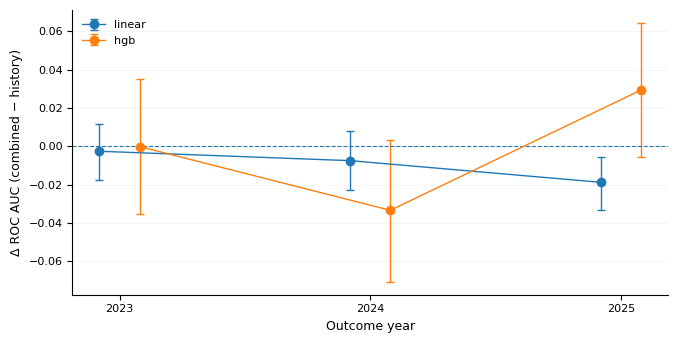

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/figures/Fig_12B_intensive_delta_MAE_by_year.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/figures/Fig_12B_intensive_delta_MAE_by_year.png


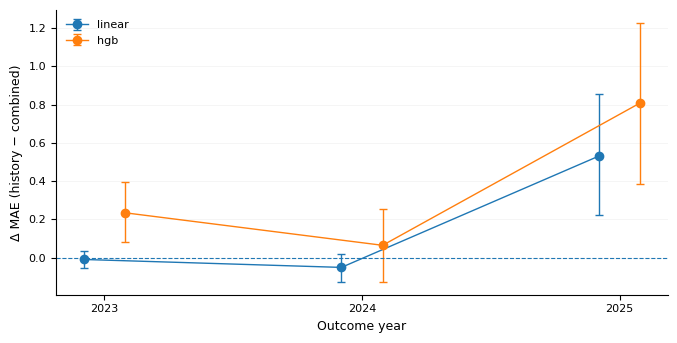

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/figures/Fig_12C_hurdle_delta_MAE_by_year.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/figures/Fig_12C_hurdle_delta_MAE_by_year.png


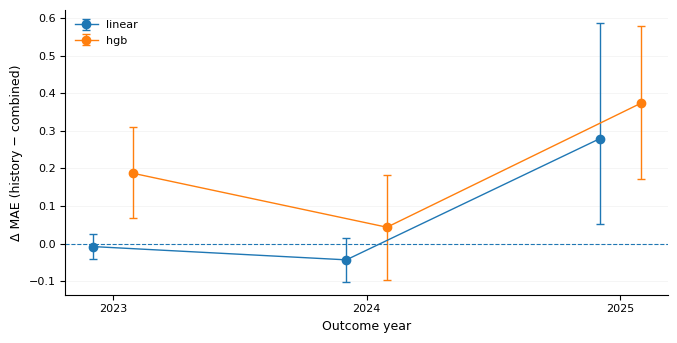

[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/12_annual_hurdle_replication/tables/Table_43_annual_mechanism_decision_gate.csv

TABLE 43 — ANNUAL MECHANISM DECISION GATE
                   status  intensive_margin_replicates_across_years  hurdle_total_gain_replicates_across_years                                                                                                                                             interpretation  primary_2023_2024_endpoint_remains_unchanged
2025_SPECIFIC_OR_UNSTABLE                                     False                                      False The strong 2025 intensive-margin result does not replicate consistently across 2023–2025 and should remain a post-hoc finding rather than a central claim.                                          True


,status,intensive_margin_replicates_across_years,hurdle_total_gain_replicates_across_years,interpretation,primary_2023_2024_endpoint_remains_unchanged
0,2025_SPECIFIC_OR_UNSTABLE,False,False,The strong 2025 intensive-margin result does n...,True



PART 18.12 — SUMMARY
PARTE 18.12 — ANNUAL HURDLE REPLICATION

Panel:
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/panel_with_annual_2023_2025_outcomes.csv

N:
500

Feature blocks:
History (7): ['past_works_2018_2022', 'past_active_years_2018_2022', 'recent_works_2021_2022', 'past_productivity_slope', 'past_works', 'past_active_years', 'recent_works']
Graph (20): ['degree', 'strength', 'avg_tie_strength', 'weighted_clustering', 'pagerank', 'betweenness', 'core_number', 'avg_neighbor_degree', 'component_size', 'is_isolate', 'degree_2018_2022', 'strength_2018_2022', 'avg_tie_strength_2018_2022', 'weighted_clustering_2018_2022', 'pagerank_2018_2022', 'betweenness_2018_2022', 'core_number_2018_2022', 'avg_neighbor_degree_2018_2022', 'component_size_2018_2022', 'is_isolate_2018_2022']

Years:
2023, 2024, 2025

Decision status:
2025_SPECIFIC_OR_UNSTABLE

Interpretation:
The strong 2025 intensive-margin result does no

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.12 — REPLICAÇÃO ANUAL 2023–2025 E MODELO HURDLE OOF
=============================================================

Objetivo
--------
Testar se o padrão observado em 2025 é replicável em 2023 e 2024 e decompor,
ano a ano, a previsão de produtividade futura em:

1) margem extensiva: probabilidade de publicar pelo menos 1 trabalho no ano;
2) margem intensiva: quantidade publicada, condicional a atividade (>0);
3) previsão hurdle total: E[Y] = P(Y>0) * E[Y | Y>0].

A análise é inteiramente OOF (out-of-fold), com os mesmos folds usados em cada
etapa do hurdle. O bloco "combined" = history + graph; "history" = histórico
de produtividade sem features de rede.

Regras de inferência
--------------------
- A análise anual é uma replicação pós-hoc/mecanística; não substitui o desfecho
  primário 2023–2024 já congelado.
- O script não recalibra hiperparâmetros usando 2025.
- Modelos lineares: Logistic + Poisson.
- Sensibilidade não linear: HistGradientBoosting classifier/regressor.
- Bootstrap pareado por pesquisador (B=5000).
- Correção de Holm entre 2023, 2024 e 2025 para cada combinação family/metric.
- Resultados e figuras são mostrados no Colab e salvos no Drive.
- Figuras são exportadas em EPS e PNG 600 dpi, sem título embutido.

Execução
--------
%run /content/Parte_18_12_Annual_Hurdle_Replication.py
"""

from __future__ import annotations

import re
import sys
import warnings
import importlib
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive]", repr(e))

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
        return importlib.import_module(import_name)

for imp, pipn in [
    ("numpy", None), ("pandas", None), ("sklearn", "scikit-learn"),
    ("scipy", None), ("matplotlib", None)
]:
    ensure(imp, pipn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    accuracy_score, balanced_accuracy_score, mean_absolute_error,
    mean_squared_error, r2_score, mean_poisson_deviance
)

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings("ignore", category=RuntimeWarning)

BASE = Path("/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929")
P11 = BASE / "11_mechanism_2025_extensive_intensive"
P8  = BASE / "08_final_incremental_graph_validation"

PANEL_CANDIDATES = [
    P11 / "artifacts" / "panel_with_annual_2023_2025_outcomes.csv",
    P8 / "artifacts" / "panel_model_ready_with_primary_outcome.csv",
    P8 / "artifacts" / "panel_model_ready.csv",
]
FEATURE_TABLE = P11 / "tables" / "Table_32A_feature_blocks.csv"

OUT = BASE / "12_annual_hurdle_replication"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
NOTES = OUT / "notes"
for d in [OUT, TAB, FIG, ART, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

panel_path = next((p for p in PANEL_CANDIDATES if p.exists()), None)
if panel_path is None:
    raise FileNotFoundError("Nenhum painel encontrado:\n" + "\n".join(map(str, PANEL_CANDIDATES)))

YEARS = [2023, 2024, 2025]
B = 5000
SEED = 20260930

def show_df(name, df, max_rows=120):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if df is None or len(df) == 0:
        print("[vazio]")
        return
    print(df.head(max_rows).to_string(index=False))
    if len(df) > max_rows:
        print(f"... {len(df):,} rows total")
    if display is not None:
        display(df.head(max_rows))

def save_df(df, name):
    p = TAB / name
    df.to_csv(p, index=False)
    print("[table]", p)
    return p

def save_fig(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

def find_author_col(df):
    for c in ["author_key", "autor_id", "author_id", "id_author", "id_autor"]:
        if c in df.columns:
            return c
    for c in df.columns:
        lc = c.lower()
        if ("author" in lc or "autor" in lc) and df[c].nunique(dropna=True) >= 0.8 * len(df):
            return c
    return None

def extract_feature_blocks(panel, table_path):
    history, graph = [], []

    if table_path.exists():
        ft = pd.read_csv(table_path)
        block_col = next((c for c in ft.columns if any(k in c.lower() for k in ["block","bloco","group","grupo","type"])), None)
        feat_col = next((c for c in ft.columns if any(k in c.lower() for k in ["feature","variable","variavel","name","column"])), None)

        if block_col is None:
            for c in ft.columns:
                vals = ft[c].astype(str).str.lower()
                if vals.str.contains("history|histor|graph|rede", regex=True).any():
                    block_col = c
                    break
        if feat_col is None:
            for c in ft.columns:
                vals = set(ft[c].dropna().astype(str))
                if len(vals & set(panel.columns)) >= 2:
                    feat_col = c
                    break

        if block_col is not None and feat_col is not None:
            for _, r in ft.iterrows():
                block = str(r[block_col]).lower()
                feat = str(r[feat_col])
                if feat not in panel.columns:
                    continue
                if "history" in block or "histor" in block:
                    history.append(feat)
                elif "graph" in block or "rede" in block:
                    graph.append(feat)

    if len(history) < 2:
        patterns = [
            r"past.*works", r"works.*2018.*2022", r"past.*active",
            r"active.*2018.*2022", r"recent.*works", r"works.*2021.*2022",
            r"productivity.*slope", r"past.*annual", r"prior.*works"
        ]
        history = [c for c in panel.columns if any(re.search(p, c.lower()) for p in patterns)]

    if len(graph) < 3:
        graph_exact = [
            "degree","strength","avg_tie_strength","weighted_clustering",
            "pagerank","betweenness","core_number","avg_neighbor_degree",
            "component_size","is_isolate"
        ]
        graph = [c for c in graph_exact if c in panel.columns]
        for c in panel.columns:
            lc = c.lower()
            if c in graph:
                continue
            if any(re.fullmatch(rf"{re.escape(g)}(_.*)?", lc) for g in graph_exact):
                graph.append(c)

    outcome_like = re.compile(r"(future|2023|2024|2025).*works|active_202[345]", re.I)
    history = [c for c in dict.fromkeys(history) if not outcome_like.search(c)]
    graph = [c for c in dict.fromkeys(graph) if not outcome_like.search(c)]
    return history, graph

def ensure_annual_outcomes(df):
    out = df.copy()
    for y in YEARS:
        target = f"future_works_{y}"
        if target not in out.columns:
            aliases = [f"works_{y}", f"annual_works_{y}", f"n_works_{y}", f"future_works_{y}_{y}"]
            src = next((c for c in aliases if c in out.columns), None)
            if src is not None:
                out[target] = pd.to_numeric(out[src], errors="coerce").fillna(0)

    missing = [f"future_works_{y}" for y in YEARS if f"future_works_{y}" not in out.columns]
    if missing:
        raise KeyError("Desfechos anuais ausentes: " + ", ".join(missing))

    for y in YEARS:
        c = f"future_works_{y}"
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0).clip(lower=0)
        out[f"active_{y}"] = (out[c] > 0).astype(int)
    return out

def numeric_matrix(df, features):
    X = df[features].copy()
    for c in features:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X

def linear_classifier():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=1.0, solver="lbfgs", max_iter=5000, random_state=SEED)),
    ])

def hgb_classifier():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=250, max_leaf_nodes=15,
            min_samples_leaf=20, l2_regularization=1.0, random_state=SEED
        )),
    ])

def linear_count():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(alpha=1.0, max_iter=3000)),
    ])

def hgb_count():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            loss="poisson", learning_rate=0.05, max_iter=250,
            max_leaf_nodes=15, min_samples_leaf=15,
            l2_regularization=1.0, random_state=SEED
        )),
    ])

def classifier_metrics(y, p):
    p = np.clip(np.asarray(p, float), 1e-8, 1-1e-8)
    pred = (p >= 0.5).astype(int)
    return {
        "ROC_AUC": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y, p) if np.sum(y) > 0 else np.nan,
        "log_loss": log_loss(y, p, labels=[0,1]),
        "Brier": brier_score_loss(y, p),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
    }

def count_metrics(y, pred):
    pred = np.clip(np.asarray(pred, float), 1e-8, None)
    y = np.asarray(y, float)
    rho = spearmanr(y, pred).statistic if len(np.unique(y)) > 1 else np.nan
    return {
        "MAE": mean_absolute_error(y, pred),
        "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
        "R2": r2_score(y, pred),
        "Poisson_deviance": mean_poisson_deviance(y, pred),
        "Spearman_rho": rho,
        "mean_observed": float(np.mean(y)),
        "mean_predicted": float(np.mean(pred)),
    }

def metric_delta(metric, y, ph, pc, binary=False):
    if binary:
        mh, mc = classifier_metrics(y, ph), classifier_metrics(y, pc)
        if metric in ["ROC_AUC","PR_AUC","accuracy","balanced_accuracy"]:
            return mc[metric] - mh[metric]
        if metric in ["Brier","log_loss"]:
            return mh[metric] - mc[metric]
    else:
        mh, mc = count_metrics(y, ph), count_metrics(y, pc)
        if metric in ["R2","Spearman_rho"]:
            return mc[metric] - mh[metric]
        if metric in ["MAE","RMSE","Poisson_deviance"]:
            return mh[metric] - mc[metric]
    raise ValueError(metric)

def paired_bootstrap_delta(y, ph, pc, metric, binary=False, B=B, seed=SEED):
    rng = np.random.default_rng(seed)
    y, ph, pc = np.asarray(y), np.asarray(ph), np.asarray(pc)
    n = len(y)
    observed = metric_delta(metric, y, ph, pc, binary=binary)
    vals = []

    for _ in range(B):
        idx = rng.integers(0, n, n)
        yy = y[idx]
        if binary and metric in ["ROC_AUC","PR_AUC"] and len(np.unique(yy)) < 2:
            continue
        try:
            vals.append(metric_delta(metric, yy, ph[idx], pc[idx], binary=binary))
        except Exception:
            pass

    vals = np.asarray(vals, float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return {
            "observed": observed, "bootstrap_median": np.nan, "ci95_low": np.nan,
            "ci95_high": np.nan, "positive_share": np.nan,
            "two_sided_bootstrap_p": np.nan, "bootstrap_effective_B": 0
        }

    p_lo = np.mean(vals <= 0)
    p_hi = np.mean(vals >= 0)
    return {
        "observed": observed,
        "bootstrap_median": float(np.median(vals)),
        "ci95_low": float(np.quantile(vals, .025)),
        "ci95_high": float(np.quantile(vals, .975)),
        "positive_share": float(np.mean(vals > 0)),
        "two_sided_bootstrap_p": float(min(1.0, 2*min(p_lo, p_hi))),
        "bootstrap_effective_B": int(len(vals)),
    }

def holm_adjust(pvals):
    p = np.asarray(pvals, float)
    out = np.full(len(p), np.nan)
    valid = np.where(np.isfinite(p))[0]
    if len(valid) == 0:
        return out
    order = valid[np.argsort(p[valid])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = (m-rank) * p[idx]
        running = max(running, adj)
        out[idx] = min(1.0, running)
    return out

df = pd.read_csv(panel_path)
df = ensure_annual_outcomes(df)

author_col = find_author_col(df)
if author_col is None:
    raise KeyError("Coluna de autor não identificada.")

history, graph = extract_feature_blocks(df, FEATURE_TABLE)
if len(history) < 2:
    raise KeyError(f"Bloco HISTORY inválido: {history}")
if len(graph) < 3:
    raise KeyError(f"Bloco GRAPH inválido: {graph}")

combined = history + [c for c in graph if c not in history]

print("\n" + "=" * 118)
print("PARTE 18.12 — REPLICAÇÃO ANUAL 2023–2025 E MODELO HURDLE OOF")
print("=" * 118)
print("[panel] ", panel_path)
print("[output]", OUT)
print("Panel shape:", df.shape)

feature_table = pd.DataFrame(
    [{"block":"history","feature":c} for c in history] +
    [{"block":"graph","feature":c} for c in graph]
)
save_df(feature_table, "Table_39_feature_blocks_frozen.csv")
show_df("TABLE 39 — FROZEN FEATURE BLOCKS", feature_table)

families = {
    "linear": {"classifier": linear_classifier(), "count": linear_count()},
    "hgb": {"classifier": hgb_classifier(), "count": hgb_count()},
}

all_pred_rows, perf_rows = [], []

for year in YEARS:
    y_count = df[f"future_works_{year}"].to_numpy(float)
    y_active = (y_count > 0).astype(int)

    min_class = int(min(y_active.sum(), len(y_active)-y_active.sum()))
    n_splits = min(10, min_class)
    if n_splits < 5:
        raise RuntimeError(f"{year}: classes insuficientes.")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED+year)

    for fam, spec in families.items():
        for block_name, feats in [("history", history), ("combined", combined)]:
            X = numeric_matrix(df, feats)
            p_active = np.full(len(df), np.nan)
            mu_pos = np.full(len(df), np.nan)

            for fold, (tr, te) in enumerate(cv.split(X, y_active), 1):
                Xtr, Xte = X.iloc[tr], X.iloc[te]
                ytr_a = y_active[tr]
                ytr_c = y_count[tr]

                clf = clone(spec["classifier"])
                clf.fit(Xtr, ytr_a)
                p_active[te] = clf.predict_proba(Xte)[:,1]

                act_train = ytr_c > 0
                if act_train.sum() < 20:
                    raise RuntimeError(f"{year} {fam} {block_name}: poucos ativos no fold {fold}")

                reg = clone(spec["count"])
                reg.fit(Xtr.iloc[act_train], ytr_c[act_train])
                mu_pos[te] = np.clip(reg.predict(Xte), 1e-8, None)

            hurdle = np.clip(p_active * mu_pos, 1e-8, None)
            active_idx = y_active == 1

            perf_rows.append({
                "year": year, "margin":"extensive", "family":fam, "block":block_name,
                "n":len(df), "active_n":int(y_active.sum()),
                **classifier_metrics(y_active, p_active)
            })
            perf_rows.append({
                "year": year, "margin":"intensive", "family":fam, "block":block_name,
                "n":int(active_idx.sum()), "active_n":int(active_idx.sum()),
                **count_metrics(y_count[active_idx], mu_pos[active_idx])
            })
            perf_rows.append({
                "year": year, "margin":"hurdle_total", "family":fam, "block":block_name,
                "n":len(df), "active_n":int(y_active.sum()),
                **count_metrics(y_count, hurdle)
            })

            for i in range(len(df)):
                all_pred_rows.append({
                    "author_id": df.iloc[i][author_col],
                    "year": year,
                    "family": fam,
                    "block": block_name,
                    "observed_count": y_count[i],
                    "observed_active": y_active[i],
                    "p_active_oof": p_active[i],
                    "mu_positive_oof": mu_pos[i],
                    "hurdle_expected_count_oof": hurdle[i],
                })

pred = pd.DataFrame(all_pred_rows)
perf = pd.DataFrame(perf_rows)
pred.to_csv(ART / "oof_hurdle_predictions_2023_2025.csv", index=False)
save_df(perf, "Table_40_annual_extensive_intensive_hurdle_performance.csv")
show_df("TABLE 40 — ANNUAL EXTENSIVE / INTENSIVE / HURDLE PERFORMANCE", perf)

boot_rows = []
metrics_by_margin = {
    "extensive": ["ROC_AUC","PR_AUC","Brier","log_loss"],
    "intensive": ["MAE","RMSE","R2","Poisson_deviance"],
    "hurdle_total": ["MAE","RMSE","R2","Poisson_deviance"],
}

for year in YEARS:
    y_count = df[f"future_works_{year}"].to_numpy(float)
    y_active = (y_count > 0).astype(int)
    active_idx = y_active == 1

    for fam in families:
        ph = pred[(pred.year==year)&(pred.family==fam)&(pred.block=="history")].reset_index(drop=True)
        pc = pred[(pred.year==year)&(pred.family==fam)&(pred.block=="combined")].reset_index(drop=True)

        for metric in metrics_by_margin["extensive"]:
            res = paired_bootstrap_delta(
                y_active, ph["p_active_oof"], pc["p_active_oof"], metric, binary=True,
                seed=SEED+year+(0 if fam=="linear" else 1000)
            )
            boot_rows.append({
                "year":year,"margin":"extensive","family":fam,"metric":metric,
                "favorable_direction":"positive = graph block improves prediction", **res
            })

        for metric in metrics_by_margin["intensive"]:
            res = paired_bootstrap_delta(
                y_count[active_idx],
                ph.loc[active_idx, "mu_positive_oof"],
                pc.loc[active_idx, "mu_positive_oof"],
                metric, binary=False,
                seed=SEED+year+2000+(0 if fam=="linear" else 1000)
            )
            boot_rows.append({
                "year":year,"margin":"intensive","family":fam,"metric":metric,
                "favorable_direction":"positive = graph block improves prediction", **res
            })

        for metric in metrics_by_margin["hurdle_total"]:
            res = paired_bootstrap_delta(
                y_count, ph["hurdle_expected_count_oof"], pc["hurdle_expected_count_oof"],
                metric, binary=False,
                seed=SEED+year+4000+(0 if fam=="linear" else 1000)
            )
            boot_rows.append({
                "year":year,"margin":"hurdle_total","family":fam,"metric":metric,
                "favorable_direction":"positive = graph block improves prediction", **res
            })

boot = pd.DataFrame(boot_rows)
boot["holm_p_across_years"] = np.nan
for _, idx in boot.groupby(["margin","family","metric"]).groups.items():
    idx = list(idx)
    boot.loc[idx, "holm_p_across_years"] = holm_adjust(
        boot.loc[idx, "two_sided_bootstrap_p"].to_numpy()
    )

save_df(boot, "Table_41_annual_incremental_graph_value_bootstrap.csv")
show_df("TABLE 41 — ANNUAL INCREMENTAL GRAPH VALUE WITH PAIRED BOOTSTRAP", boot, 200)

consistency_rows = []
for (margin, fam, metric), g in boot.groupby(["margin","family","metric"]):
    g = g.sort_values("year")
    n_pos = int((g["observed"] > 0).sum())
    consistency_rows.append({
        "margin": margin,
        "family": fam,
        "metric": metric,
        "years_positive_observed": n_pos,
        "years_ci_entirely_positive": int((g["ci95_low"] > 0).sum()),
        "years_ci_entirely_negative": int((g["ci95_high"] < 0).sum()),
        "all_three_same_observed_direction": bool(n_pos in [0,3]),
        "mean_observed_delta": float(g["observed"].mean()),
        "median_observed_delta": float(g["observed"].median()),
    })

consistency = pd.DataFrame(consistency_rows)
save_df(consistency, "Table_42_cross_year_consistency.csv")
show_df("TABLE 42 — CROSS-YEAR CONSISTENCY", consistency)

plt.rcParams.update({
    "font.family":"sans-serif","font.size":9,"axes.labelsize":9,
    "xtick.labelsize":8,"ytick.labelsize":8,"legend.fontsize":8,
    "axes.spines.top":False,"axes.spines.right":False,
    "pdf.fonttype":42,"ps.fonttype":42
})

def plot_delta(metric, margin, stem, ylabel):
    g = boot[(boot.metric==metric)&(boot.margin==margin)].copy()
    fig, ax = plt.subplots(figsize=(6.85,3.5))
    offsets = {"linear":-0.08,"hgb":0.08}
    for fam in ["linear","hgb"]:
        z = g[g.family==fam].sort_values("year")
        if z.empty:
            continue
        x = z.year.to_numpy(float) + offsets[fam]
        y = z.observed.to_numpy(float)
        lo = z.ci95_low.to_numpy(float)
        hi = z.ci95_high.to_numpy(float)
        ax.errorbar(x, y, yerr=np.vstack([y-lo, hi-y]), marker="o",
                    capsize=3, linewidth=1.0, label=fam)
    ax.axhline(0, linewidth=.8, linestyle="--")
    ax.set_xticks(YEARS)
    ax.set_xlabel("Outcome year")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=.18, linewidth=.5)
    fig.tight_layout()
    save_fig(fig, stem)
    if display is not None:
        display(fig)
    else:
        plt.show()
    plt.close(fig)

plot_delta("ROC_AUC","extensive","Fig_12A_extensive_delta_ROC_AUC_by_year","Δ ROC AUC (combined − history)")
plot_delta("MAE","intensive","Fig_12B_intensive_delta_MAE_by_year","Δ MAE (history − combined)")
plot_delta("MAE","hurdle_total","Fig_12C_hurdle_delta_MAE_by_year","Δ MAE (history − combined)")

def get_cons(margin, family, metric):
    x = consistency[
        (consistency.margin==margin)&
        (consistency.family==family)&
        (consistency.metric==metric)
    ]
    return x.iloc[0] if len(x) else None

lin_int = get_cons("intensive","linear","MAE")
hgb_int = get_cons("intensive","hgb","MAE")
lin_hur = get_cons("hurdle_total","linear","MAE")
hgb_hur = get_cons("hurdle_total","hgb","MAE")

intensive_replicates = bool(
    lin_int is not None and hgb_int is not None and
    lin_int["years_positive_observed"] >= 2 and
    hgb_int["years_positive_observed"] >= 2
)
hurdle_replicates = bool(
    lin_hur is not None and hgb_hur is not None and
    lin_hur["years_positive_observed"] >= 2 and
    hgb_hur["years_positive_observed"] >= 2
)

if intensive_replicates and hurdle_replicates:
    status = "ROBUST_MECHANISM_AND_TOTAL_FORECAST_GAIN"
    interpretation = (
        "The graph block shows cross-year evidence of incremental value for the "
        "intensive margin and this benefit propagates to total hurdle forecasts."
    )
elif intensive_replicates:
    status = "INTENSIVE_MARGIN_MECHANISM_ONLY"
    interpretation = (
        "The graph block shows cross-year incremental value mainly for publication "
        "intensity among active authors, but this does not consistently improve "
        "overall annual count forecasting."
    )
else:
    status = "2025_SPECIFIC_OR_UNSTABLE"
    interpretation = (
        "The strong 2025 intensive-margin result does not replicate consistently "
        "across 2023–2025 and should remain a post-hoc finding rather than a central claim."
    )

decision = pd.DataFrame([{
    "status": status,
    "intensive_margin_replicates_across_years": intensive_replicates,
    "hurdle_total_gain_replicates_across_years": hurdle_replicates,
    "interpretation": interpretation,
    "primary_2023_2024_endpoint_remains_unchanged": True,
}])

save_df(decision, "Table_43_annual_mechanism_decision_gate.csv")
show_df("TABLE 43 — ANNUAL MECHANISM DECISION GATE", decision)

summary = f"""
PARTE 18.12 — ANNUAL HURDLE REPLICATION
========================================

Panel:
{panel_path}

N:
{len(df)}

Feature blocks:
History ({len(history)}): {history}
Graph ({len(graph)}): {graph}

Years:
2023, 2024, 2025

Decision status:
{status}

Interpretation:
{interpretation}

Important:
This is a post-hoc/mechanistic annual replication. It does not replace the
pre-specified primary 2023–2024 prospective endpoint. Its purpose is to test
whether the 2025 extensive/intensive decomposition is reproducible rather than
a single-year artifact.
""".strip()

summary_path = NOTES / "Part_18_12_annual_hurdle_summary.txt"
summary_path.write_text(summary, encoding="utf-8")

print("\n" + "=" * 118)
print("PART 18.12 — SUMMARY")
print("=" * 118)
print(summary)
print("[summary]", summary_path)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 40 — ANNUAL EXTENSIVE / INTENSIVE / HURDLE PERFORMANCE")
print("2) TABLE 41 — ANNUAL INCREMENTAL GRAPH VALUE WITH PAIRED BOOTSTRAP")
print("3) TABLE 42 — CROSS-YEAR CONSISTENCY")
print("4) TABLE 43 — ANNUAL MECHANISM DECISION GATE")
print("5) PART 18.12 — SUMMARY")
print("\nCONCLUÍDO.")


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.13 — AUDITORIA DE REDUNDÂNCIA E CONGELAMENTO LIMPO DAS FEATURES
=======================================================================

Objetivo
--------
Antes da redação do artigo, auditar uma questão identificada na Parte 18.12:
o bloco congelado contém simultaneamente nomes genéricos e nomes com sufixo
_2018_2022 para várias variáveis que podem ser aliases exatos.

Esta etapa:
1) monta/reutiliza o Google Drive;
2) carrega o painel anual da Parte 18.12 (com fallbacks);
3) NÃO treina modelos;
4) verifica duplicatas exatas e correlações quase perfeitas;
5) define um único representante canônico para cada feature histórica e de rede;
6) reconstrói/valida os desfechos 2023, 2024, 2025, 2023–2024 e 2023–2025;
7) salva painel limpo + feature blocks congelados;
8) imprime tudo no Colab.

Execução
--------
%run /content/Parte_18_13_Auditoria_Redundancia_Features.py
"""

from __future__ import annotations

import json
import sys
import importlib
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", pip_name or import_name]
        )
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = None

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
RUN_ROOT = ROOT / "runs" / "temporal_productivity_20260929"

PANEL_CANDIDATES = [
    RUN_ROOT / "12_annual_hurdle_replication" / "artifacts" / "panel_with_annual_2023_2025_outcomes.csv",
    RUN_ROOT / "11_mechanism_2025_extensive_intensive" / "artifacts" / "panel_with_annual_2023_2025_outcomes.csv",
    RUN_ROOT / "08_final_incremental_graph_validation" / "artifacts" / "panel_model_ready_with_primary_outcome.csv",
    RUN_ROOT / "06_cohort2022_prospective_panel" / "panel_model_ready.csv",
]

PANEL_PATH = next((p for p in PANEL_CANDIDATES if p.exists()), None)
if PANEL_PATH is None:
    raise FileNotFoundError(
        "Não encontrei nenhum painel candidato.\n" +
        "\n".join(str(p) for p in PANEL_CANDIDATES)
    )

OUT = RUN_ROOT / "13_feature_redundancy_clean_freeze"
TAB = OUT / "tables"
ART = OUT / "artifacts"
NOTES = OUT / "notes"
for d in [OUT, TAB, ART, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

def show_df(title, df, max_rows=100):
    print("\n" + "=" * 118)
    print(title)
    print("=" * 118)
    if df.empty:
        print("[vazio]")
    else:
        print(df.head(max_rows).to_string(index=False))
        if len(df) > max_rows:
            print(f"... ({len(df):,} rows total)")
        if display is not None:
            display(df.head(max_rows))

def numeric_series(df, col):
    return pd.to_numeric(df[col], errors="coerce")

def exact_numeric_alias(df, a, b, atol=1e-12, rtol=1e-10):
    if a not in df.columns or b not in df.columns:
        return None
    x = numeric_series(df, a).to_numpy(dtype=float)
    y = numeric_series(df, b).to_numpy(dtype=float)
    if not np.array_equal(np.isnan(x), np.isnan(y)):
        return False
    mask = ~(np.isnan(x) | np.isnan(y))
    if mask.sum() == 0:
        return True
    return bool(np.allclose(x[mask], y[mask], atol=atol, rtol=rtol))

def max_abs_diff(df, a, b):
    x = numeric_series(df, a)
    y = numeric_series(df, b)
    z = (x - y).abs()
    return float(z.max()) if z.notna().any() else np.nan

def choose_first_existing(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"Não encontrei coluna para '{label}'. Candidatas testadas: {candidates}"
    )

print("\n" + "=" * 118)
print("PARTE 18.13 — AUDITORIA DE REDUNDÂNCIA E CONGELAMENTO LIMPO DAS FEATURES")
print("=" * 118)
print("[panel] ", PANEL_PATH)
print("[output]", OUT)

df = pd.read_csv(PANEL_PATH)
print(f"Panel shape: {df.shape}")

ALIAS_PAIRS = [
    ("past_works", "past_works_2018_2022", "history"),
    ("past_active_years", "past_active_years_2018_2022", "history"),
    ("recent_works", "recent_works_2021_2022", "history"),
    ("degree", "degree_2018_2022", "graph"),
    ("strength", "strength_2018_2022", "graph"),
    ("avg_tie_strength", "avg_tie_strength_2018_2022", "graph"),
    ("weighted_clustering", "weighted_clustering_2018_2022", "graph"),
    ("pagerank", "pagerank_2018_2022", "graph"),
    ("betweenness", "betweenness_2018_2022", "graph"),
    ("core_number", "core_number_2018_2022", "graph"),
    ("avg_neighbor_degree", "avg_neighbor_degree_2018_2022", "graph"),
    ("component_size", "component_size_2018_2022", "graph"),
    ("is_isolate", "is_isolate_2018_2022", "graph"),
]

alias_rows = []
for generic, dated, block in ALIAS_PAIRS:
    generic_exists = generic in df.columns
    dated_exists = dated in df.columns
    is_exact = exact_numeric_alias(df, generic, dated) if generic_exists and dated_exists else None

    corr = np.nan
    if generic_exists and dated_exists:
        x = numeric_series(df, generic)
        y = numeric_series(df, dated)
        mask = x.notna() & y.notna()
        if mask.sum() >= 3 and x[mask].nunique() > 1 and y[mask].nunique() > 1:
            corr = float(x[mask].corr(y[mask]))

    alias_rows.append({
        "block": block,
        "generic_feature": generic,
        "dated_feature": dated,
        "generic_exists": generic_exists,
        "dated_exists": dated_exists,
        "exact_numeric_alias": is_exact,
        "pearson_r": corr,
        "max_abs_difference": (
            max_abs_diff(df, generic, dated)
            if generic_exists and dated_exists else np.nan
        ),
    })

alias_audit = pd.DataFrame(alias_rows)
alias_audit.to_csv(TAB / "Table_44_alias_redundancy_audit.csv", index=False)
show_df("TABLE 44 — ALIAS REDUNDANCY AUDIT", alias_audit)

CANONICAL_SPECS = [
    ("history", "past_works_2018_2022", ["past_works_2018_2022", "past_works"]),
    ("history", "past_active_years_2018_2022", ["past_active_years_2018_2022", "past_active_years"]),
    ("history", "recent_works_2021_2022", ["recent_works_2021_2022", "recent_works"]),
    ("history", "past_productivity_slope", ["past_productivity_slope"]),

    ("graph", "degree_2018_2022", ["degree_2018_2022", "degree"]),
    ("graph", "strength_2018_2022", ["strength_2018_2022", "strength"]),
    ("graph", "avg_tie_strength_2018_2022", ["avg_tie_strength_2018_2022", "avg_tie_strength"]),
    ("graph", "weighted_clustering_2018_2022", ["weighted_clustering_2018_2022", "weighted_clustering"]),
    ("graph", "pagerank_2018_2022", ["pagerank_2018_2022", "pagerank"]),
    ("graph", "betweenness_2018_2022", ["betweenness_2018_2022", "betweenness"]),
    ("graph", "core_number_2018_2022", ["core_number_2018_2022", "core_number"]),
    ("graph", "avg_neighbor_degree_2018_2022", ["avg_neighbor_degree_2018_2022", "avg_neighbor_degree"]),
    ("graph", "component_size_2018_2022", ["component_size_2018_2022", "component_size"]),
    ("graph", "is_isolate_2018_2022", ["is_isolate_2018_2022", "is_isolate"]),
]

canonical_rows = []
canonical_map = {}
for block, canonical_name, candidates in CANONICAL_SPECS:
    source = choose_first_existing(df, candidates, canonical_name)
    canonical_map[canonical_name] = source
    canonical_rows.append({
        "block": block,
        "canonical_feature": canonical_name,
        "source_column": source,
        "missing_n": int(numeric_series(df, source).isna().sum()),
        "n_unique": int(numeric_series(df, source).nunique(dropna=True)),
    })

canonical_table = pd.DataFrame(canonical_rows)
canonical_table.to_csv(TAB / "Table_45_clean_canonical_feature_set.csv", index=False)
show_df("TABLE 45 — CLEAN CANONICAL FEATURE SET", canonical_table)

HISTORY = canonical_table.loc[
    canonical_table["block"] == "history", "canonical_feature"
].tolist()
GRAPH = canonical_table.loc[
    canonical_table["block"] == "graph", "canonical_feature"
].tolist()

clean = df.copy()
for canonical_name, source in canonical_map.items():
    clean[canonical_name] = numeric_series(df, source)

annual_candidates = {
    2023: ["future_works_2023", "works_2023"],
    2024: ["future_works_2024", "works_2024"],
    2025: ["future_works_2025", "works_2025"],
}
annual_cols = {}
for year, candidates in annual_candidates.items():
    col = next((c for c in candidates if c in clean.columns), None)
    if col is not None:
        clean[f"future_works_{year}"] = numeric_series(clean, col)
        annual_cols[year] = f"future_works_{year}"

if 2023 in annual_cols and 2024 in annual_cols:
    reconstructed_2324 = clean[annual_cols[2023]] + clean[annual_cols[2024]]
    if "future_works_2023_2024" in clean.columns:
        existing = numeric_series(clean, "future_works_2023_2024")
        diff = (existing - reconstructed_2324).abs()
        primary_discrepancies = int((diff.fillna(0) > 1e-12).sum())
        primary_max_diff = float(diff.max()) if diff.notna().any() else np.nan
    else:
        primary_discrepancies = np.nan
        primary_max_diff = np.nan
    clean["future_works_2023_2024"] = reconstructed_2324
else:
    if "future_works_2023_2024" not in clean.columns:
        raise KeyError("Não foi possível obter future_works_2023_2024.")
    clean["future_works_2023_2024"] = numeric_series(clean, "future_works_2023_2024")
    primary_discrepancies = np.nan
    primary_max_diff = np.nan

if all(y in annual_cols for y in [2023, 2024, 2025]):
    reconstructed_2325 = (
        clean[annual_cols[2023]]
        + clean[annual_cols[2024]]
        + clean[annual_cols[2025]]
    )
    if "future_works_2023_2025" in clean.columns:
        existing = numeric_series(clean, "future_works_2023_2025")
        diff = (existing - reconstructed_2325).abs()
        sens_discrepancies = int((diff.fillna(0) > 1e-12).sum())
        sens_max_diff = float(diff.max()) if diff.notna().any() else np.nan
    else:
        sens_discrepancies = np.nan
        sens_max_diff = np.nan
    clean["future_works_2023_2025"] = reconstructed_2325
else:
    sens_discrepancies = np.nan
    sens_max_diff = np.nan

canonical_features = HISTORY + GRAPH
corr_df = clean[canonical_features].apply(pd.to_numeric, errors="coerce").corr()

near_rows = []
for i, a in enumerate(canonical_features):
    for b in canonical_features[i + 1:]:
        r = corr_df.loc[a, b]
        if pd.notna(r) and abs(r) >= 0.95:
            near_rows.append({
                "feature_a": a,
                "feature_b": b,
                "pearson_r": float(r),
                "abs_r": float(abs(r)),
                "same_block": (
                    ("history" if a in HISTORY else "graph")
                    == ("history" if b in HISTORY else "graph")
                ),
            })

near_corr = pd.DataFrame(near_rows)
if not near_corr.empty:
    near_corr = near_corr.sort_values("abs_r", ascending=False)

near_corr.to_csv(TAB / "Table_46_near_perfect_feature_correlations.csv", index=False)
show_df("TABLE 46 — NEAR-PERFECT FEATURE CORRELATIONS (|r| >= .95)", near_corr)

qc_rows = []
for c in canonical_features + [
    "future_works_2023_2024",
    "future_works_2023_2025",
    "future_works_2023",
    "future_works_2024",
    "future_works_2025",
]:
    if c not in clean.columns:
        continue
    s = numeric_series(clean, c)
    qc_rows.append({
        "variable": c,
        "n": int(s.notna().sum()),
        "missing_n": int(s.isna().sum()),
        "n_unique": int(s.nunique(dropna=True)),
        "min": float(s.min()) if s.notna().any() else np.nan,
        "median": float(s.median()) if s.notna().any() else np.nan,
        "mean": float(s.mean()) if s.notna().any() else np.nan,
        "max": float(s.max()) if s.notna().any() else np.nan,
    })

qc = pd.DataFrame(qc_rows)
qc.to_csv(TAB / "Table_47_clean_panel_qc.csv", index=False)
show_df("TABLE 47 — CLEAN PANEL QC", qc)

outcome_audit = pd.DataFrame([
    {
        "outcome": "future_works_2023_2024",
        "reconstructed_from_annual_if_available": bool(2023 in annual_cols and 2024 in annual_cols),
        "discrepancies_vs_existing": primary_discrepancies,
        "max_abs_difference_vs_existing": primary_max_diff,
    },
    {
        "outcome": "future_works_2023_2025",
        "reconstructed_from_annual_if_available": bool(all(y in annual_cols for y in [2023, 2024, 2025])),
        "discrepancies_vs_existing": sens_discrepancies,
        "max_abs_difference_vs_existing": sens_max_diff,
    },
])
outcome_audit.to_csv(TAB / "Table_48_outcome_reconstruction_audit.csv", index=False)
show_df("TABLE 48 — OUTCOME RECONSTRUCTION AUDIT", outcome_audit)

n_expected_aliases = int(
    (
        alias_audit["generic_exists"].astype(int)
        * alias_audit["dated_exists"].astype(int)
    ).sum()
)
n_exact_aliases = int(
    alias_audit["exact_numeric_alias"].fillna(False).astype(bool).sum()
)
has_redundancy = n_exact_aliases > 0

if has_redundancy:
    status = "RERUN_REQUIRED_WITH_DEDUPLICATED_FEATURE_BLOCKS"
    interpretation = (
        f"{n_exact_aliases} exact alias pair(s) were detected among the candidate "
        "history/graph features. The final predictive analyses should be rerun with "
        "one canonical column per construct before manuscript freeze."
    )
else:
    status = "NO_EXACT_ALIAS_REDUNDANCY_DETECTED"
    interpretation = (
        "No exact alias pair was detected. The previous model blocks are not duplicated "
        "by exact column aliases."
    )

decision = pd.DataFrame([{
    "status": status,
    "candidate_alias_pairs_with_both_columns": n_expected_aliases,
    "exact_alias_pairs": n_exact_aliases,
    "clean_history_feature_n": len(HISTORY),
    "clean_graph_feature_n": len(GRAPH),
    "primary_outcome_discrepancies": primary_discrepancies,
    "interpretation": interpretation,
}])

decision.to_csv(TAB / "Table_49_feature_redundancy_decision_gate.csv", index=False)
show_df("TABLE 49 — FEATURE REDUNDANCY DECISION GATE", decision)

clean_panel_path = ART / "panel_model_ready_clean_deduplicated.csv"
clean.to_csv(clean_panel_path, index=False)

feature_block = {
    "history": HISTORY,
    "graph": GRAPH,
    "combined": HISTORY + GRAPH,
    "primary_outcome": "future_works_2023_2024",
    "sensitivity_outcome": "future_works_2023_2025",
    "annual_outcomes": [
        c for c in [
            "future_works_2023",
            "future_works_2024",
            "future_works_2025"
        ] if c in clean.columns
    ],
    "source_panel": str(PANEL_PATH),
    "canonical_source_map": canonical_map,
}

feature_json_path = ART / "clean_feature_blocks.json"
feature_json_path.write_text(
    json.dumps(feature_block, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

summary = f"""
PARTE 18.13 — FEATURE REDUNDANCY AUDIT
======================================

Source panel:
{PANEL_PATH}

N:
{len(clean)}

Alias pairs with both columns present:
{n_expected_aliases}

Exact alias pairs:
{n_exact_aliases}

Clean history block ({len(HISTORY)}):
{HISTORY}

Clean graph block ({len(GRAPH)}):
{GRAPH}

Primary outcome:
future_works_2023_2024

Decision:
{status}

Interpretation:
{interpretation}
""".strip()

summary_path = NOTES / "Part_18_13_feature_redundancy_summary.txt"
summary_path.write_text(summary, encoding="utf-8")

print("\n" + "=" * 118)
print("PART 18.13 — SUMMARY")
print("=" * 118)
print(summary)

print("\n" + "=" * 118)
print("ARQUIVOS SALVOS")
print("=" * 118)
for p in [
    TAB / "Table_44_alias_redundancy_audit.csv",
    TAB / "Table_45_clean_canonical_feature_set.csv",
    TAB / "Table_46_near_perfect_feature_correlations.csv",
    TAB / "Table_47_clean_panel_qc.csv",
    TAB / "Table_48_outcome_reconstruction_audit.csv",
    TAB / "Table_49_feature_redundancy_decision_gate.csv",
    clean_panel_path,
    feature_json_path,
    summary_path,
]:
    print(p)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 44 — ALIAS REDUNDANCY AUDIT")
print("2) TABLE 45 — CLEAN CANONICAL FEATURE SET")
print("3) TABLE 46 — NEAR-PERFECT FEATURE CORRELATIONS")
print("4) TABLE 48 — OUTCOME RECONSTRUCTION AUDIT")
print("5) TABLE 49 — FEATURE REDUNDANCY DECISION GATE")
print("6) PART 18.13 — SUMMARY")

print("\nCONCLUÍDO.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.13 — AUDITORIA DE REDUNDÂNCIA E CONGELAMENTO LIMPO DAS FEATURES
[panel]  /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/panel_with_annual_2023_2025_outcomes.csv
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze
Panel shape: (500, 47)

TABLE 44 — ALIAS REDUNDANCY AUDIT
  block     generic_feature                 dated_feature  generic_exists  dated_exists  exact_numeric_alias  pearson_r  max_abs_difference
history          past_works          past_works_2018_2022            True          True                 True        1.0                 0.0
history   past_active_years   past_active_years_2018_2022            True          True                 True        1.0                 0.0
history        recent_works    

,block,generic_feature,dated_feature,generic_exists,dated_exists,exact_numeric_alias,pearson_r,max_abs_difference
0,history,past_works,past_works_2018_2022,True,True,True,1.0,0.0
1,history,past_active_years,past_active_years_2018_2022,True,True,True,1.0,0.0
2,history,recent_works,recent_works_2021_2022,True,True,True,1.0,0.0
3,graph,degree,degree_2018_2022,True,True,True,1.0,0.0
4,graph,strength,strength_2018_2022,True,True,True,1.0,0.0
5,graph,avg_tie_strength,avg_tie_strength_2018_2022,True,True,True,1.0,0.0
6,graph,weighted_clustering,weighted_clustering_2018_2022,True,True,True,1.0,0.0
7,graph,pagerank,pagerank_2018_2022,True,True,True,1.0,0.0
8,graph,betweenness,betweenness_2018_2022,True,True,True,1.0,0.0
9,graph,core_number,core_number_2018_2022,True,True,True,1.0,0.0



TABLE 45 — CLEAN CANONICAL FEATURE SET
  block             canonical_feature                 source_column  missing_n  n_unique
history          past_works_2018_2022          past_works_2018_2022          0        80
history   past_active_years_2018_2022   past_active_years_2018_2022          0         6
history        recent_works_2021_2022        recent_works_2021_2022          0        34
history       past_productivity_slope       past_productivity_slope          0       100
  graph              degree_2018_2022              degree_2018_2022          0        19
  graph            strength_2018_2022            strength_2018_2022          0        51
  graph    avg_tie_strength_2018_2022    avg_tie_strength_2018_2022          0        87
  graph weighted_clustering_2018_2022 weighted_clustering_2018_2022          0       191
  graph            pagerank_2018_2022            pagerank_2018_2022          0       330
  graph         betweenness_2018_2022         betweenness_2018_2022   

,block,canonical_feature,source_column,missing_n,n_unique
0,history,past_works_2018_2022,past_works_2018_2022,0,80
1,history,past_active_years_2018_2022,past_active_years_2018_2022,0,6
2,history,recent_works_2021_2022,recent_works_2021_2022,0,34
3,history,past_productivity_slope,past_productivity_slope,0,100
4,graph,degree_2018_2022,degree_2018_2022,0,19
5,graph,strength_2018_2022,strength_2018_2022,0,51
6,graph,avg_tie_strength_2018_2022,avg_tie_strength_2018_2022,0,87
7,graph,weighted_clustering_2018_2022,weighted_clustering_2018_2022,0,191
8,graph,pagerank_2018_2022,pagerank_2018_2022,0,330
9,graph,betweenness_2018_2022,betweenness_2018_2022,0,207



TABLE 46 — NEAR-PERFECT FEATURE CORRELATIONS (|r| >= .95)
[vazio]

TABLE 47 — CLEAN PANEL QC
                     variable   n  missing_n  n_unique       min     median       mean        max
         past_works_2018_2022 500          0        80  0.000000  20.000000  24.142000 111.000000
  past_active_years_2018_2022 500          0         6  0.000000   5.000000   4.242000   5.000000
       recent_works_2021_2022 500          0        34  0.000000   5.000000   6.990000  51.000000
      past_productivity_slope 500          0       100 -9.200000  -0.700000  -1.095800   4.200000
             degree_2018_2022 500          0        19  0.000000   2.000000   3.084000  18.000000
           strength_2018_2022 500          0        51  0.000000   3.000000   8.220000 132.000000
   avg_tie_strength_2018_2022 500          0        87  0.000000   1.250000   1.711906  15.000000
weighted_clustering_2018_2022 500          0       191  0.000000   0.000000   0.015686   0.314170
           pagerank_2018

...

,outcome,reconstructed_from_annual_if_available,discrepancies_vs_existing,max_abs_difference_vs_existing
0,future_works_2023_2024,True,0,0.0
1,future_works_2023_2025,True,0,0.0



TABLE 49 — FEATURE REDUNDANCY DECISION GATE
                                         status  candidate_alias_pairs_with_both_columns  exact_alias_pairs  clean_history_feature_n  clean_graph_feature_n  primary_outcome_discrepancies                                                                                                                                                                                   interpretation
RERUN_REQUIRED_WITH_DEDUPLICATED_FEATURE_BLOCKS                                       13                 13                        4                     10                              0 13 exact alias pair(s) were detected among the candidate history/graph features. The final predictive analyses should be rerun with one canonical column per construct before manuscript freeze.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,status,candidate_alias_pairs_with_both_columns,exact_alias_pairs,clean_history_feature_n,clean_graph_feature_n,primary_outcome_discrepancies,interpretation
0,RERUN_REQUIRED_WITH_DEDUPLICATED_FEATURE_BLOCKS,13,13,4,10,0,13 exact alias pair(s) were detected among the...



PART 18.13 — SUMMARY
PARTE 18.13 — FEATURE REDUNDANCY AUDIT

Source panel:
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/11_mechanism_2025_extensive_intensive/artifacts/panel_with_annual_2023_2025_outcomes.csv

N:
500

Alias pairs with both columns present:
13

Exact alias pairs:
13

Clean history block (4):
['past_works_2018_2022', 'past_active_years_2018_2022', 'recent_works_2021_2022', 'past_productivity_slope']

Clean graph block (10):
['degree_2018_2022', 'strength_2018_2022', 'avg_tie_strength_2018_2022', 'weighted_clustering_2018_2022', 'pagerank_2018_2022', 'betweenness_2018_2022', 'core_number_2018_2022', 'avg_neighbor_degree_2018_2022', 'component_size_2018_2022', 'is_isolate_2018_2022']

Primary outcome:
future_works_2023_2024

Decision:
RERUN_REQUIRED_WITH_DEDUPLICATED_FEATURE_BLOCKS

Interpretation:
13 exact alias pair(s) were detected among the candidate history/graph features. The final predictive analyses should be rerun with one canonical co

[drive] Google Drive já montado; reutilizando a sessão atual.

PARTE 18.14 — REEXECUÇÃO FINAL LIMPA DA VALIDAÇÃO PREDITIVA
[panel]  /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun
Panel shape: (500, 47)
Outcome: future_works_2023_2024
History: ['past_works_2018_2022', 'past_active_years_2018_2022', 'recent_works_2021_2022', 'past_productivity_slope']
Graph: ['degree_2018_2022', 'strength_2018_2022', 'avg_tie_strength_2018_2022', 'weighted_clustering_2018_2022', 'pagerank_2018_2022', 'betweenness_2018_2022', 'core_number_2018_2022', 'avg_neighbor_degree_2018_2022', 'component_size_2018_2022', 'is_isolate_2018_2022']

TABLE 50 — CLEAN FEATURE AUDIT
  block                       feature   n  missing_n  n_unique       min     median       mean        max
history       

,block,feature,n,missing_n,n_unique,min,median,mean,max
0,history,past_works_2018_2022,500,0,80,0.000000,20.000000,24.142000,111.000000
1,history,past_active_years_2018_2022,500,0,6,0.000000,5.000000,4.242000,5.000000
2,history,recent_works_2021_2022,500,0,34,0.000000,5.000000,6.990000,51.000000
3,history,past_productivity_slope,500,0,100,-9.200000,-0.700000,-1.095800,4.200000
4,graph,degree_2018_2022,500,0,19,0.000000,2.000000,3.084000,18.000000
5,graph,strength_2018_2022,500,0,51,0.000000,3.000000,8.220000,132.000000
6,graph,avg_tie_strength_2018_2022,500,0,87,0.000000,1.250000,1.711906,15.000000
7,graph,weighted_clustering_2018_2022,500,0,191,0.000000,0.000000,0.015686,0.314170
8,graph,pagerank_2018_2022,500,0,330,0.000399,0.001549,0.002000,0.009565
9,graph,betweenness_2018_2022,500,0,207,0.000000,0.000000,0.004053,0.090081



TABLE 50B — EXACT ALIAS CHECK AMONG USED FEATURES
[vazio]

TABLE 50C — PRIMARY OUTCOME AUDIT
               outcome   n  zero_n  zero_pct  mean  median  p95  max
future_works_2023_2024 500      63      12.6  6.81     5.0 22.0 57.0


,outcome,n,zero_n,zero_pct,mean,median,p95,max
0,future_works_2023_2024,500,63,12.6,6.81,5.0,22.0,57.0



NESTED 10-FOLD OOF — CLEAN

--- fold 01/10 ---
  [poisson] history  MAE=5.1783 R2=0.1690 param=0.01
  [poisson] graph    MAE=5.8016 R2=0.0081 param=5.0
  [poisson] combined MAE=5.2186 R2=0.1732 param=0.1
  [hgb    ] history  MAE=4.6487 R2=0.3847 param={"l2_regularization": 0.0, "learning_rate": 0.03, "max_iter": 200, "max_leaf_nodes": 7, "min_samples_leaf": 15}
  [hgb    ] graph    MAE=5.6514 R2=0.0408 param={"l2_regularization": 0.0, "learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 7, "min_samples_leaf": 15}
  [hgb    ] combined MAE=5.0688 R2=0.2645 param={"l2_regularization": 1.0, "learning_rate": 0.03, "max_iter": 200, "max_leaf_nodes": 7, "min_samples_leaf": 15}

--- fold 02/10 ---
  [poisson] history  MAE=4.8945 R2=0.5213 param=0.01
  [poisson] graph    MAE=6.8191 R2=0.0732 param=0.1
  [poisson] combined MAE=4.9970 R2=0.4511 param=0.1
  [hgb    ] history  MAE=4.5765 R2=0.5065 param={"l2_regularization": 1.0, "learning_rate": 0.03, "max_iter": 200, "max_leaf_nodes": 7, "m

...


TABLE 56 — OLD VS CLEAN PRIMARY COMPARISON
 family    block  old_MAE  clean_MAE  delta_clean_minus_old_MAE   old_R2  clean_R2  delta_clean_minus_old_R2
poisson  history 3.886156   3.830232                  -0.055924 0.260500  0.185160                 -0.075340
poisson combined 3.970523   3.974254                   0.003731 0.229637  0.150136                 -0.079501
    hgb  history 3.830689   3.789948                  -0.040741 0.386352  0.374392                 -0.011960
    hgb combined 3.859921   3.910052                   0.050131 0.362478  0.338094                 -0.024384


,family,block,old_MAE,clean_MAE,delta_clean_minus_old_MAE,old_R2,clean_R2,delta_clean_minus_old_R2
0,poisson,history,3.886156,3.830232,-0.055924,0.260500,0.185160,-0.075340
1,poisson,combined,3.970523,3.974254,0.003731,0.229637,0.150136,-0.079501
2,hgb,history,3.830689,3.789948,-0.040741,0.386352,0.374392,-0.011960
3,hgb,combined,3.859921,3.910052,0.050131,0.362478,0.338094,-0.024384



TABLE 57 — CLEAN FINAL INCREMENTAL GRAPH DECISION
 family  delta_R2_observed  delta_R2_ci95_low  delta_R2_ci95_high  delta_MAE_observed  delta_MAE_ci95_low  delta_MAE_ci95_high  clear_positive_R2  clear_positive_MAE                                                                                                                 interpretation
poisson          -0.035024          -0.176587            0.147710           -0.144023           -0.300867             0.000384              False               False No clear paired evidence that graph features improve prediction beyond the historical-productivity block in this model family.
    hgb          -0.036298          -0.107036            0.051993           -0.120104           -0.290521             0.059027              False               False No clear paired evidence that graph features improve prediction beyond the historical-productivity block in this model family.


,family,delta_R2_observed,delta_R2_ci95_low,delta_R2_ci95_high,delta_MAE_observed,delta_MAE_ci95_low,delta_MAE_ci95_high,clear_positive_R2,clear_positive_MAE,interpretation
0,poisson,-0.035024,-0.176587,0.147710,-0.144023,-0.300867,0.000384,False,False,No clear paired evidence that graph features i...
1,hgb,-0.036298,-0.107036,0.051993,-0.120104,-0.290521,0.059027,False,False,No clear paired evidence that graph features i...


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14A_observed_vs_predicted_poisson_combined.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14A_observed_vs_predicted_poisson_combined.png


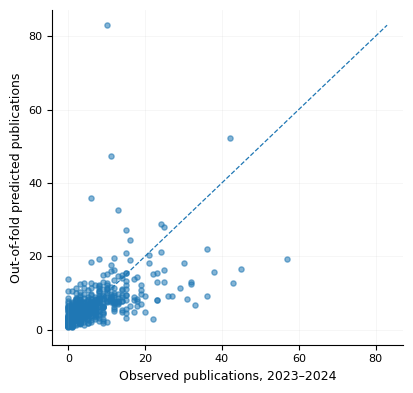

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14A_observed_vs_predicted_hgb_combined.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14A_observed_vs_predicted_hgb_combined.png


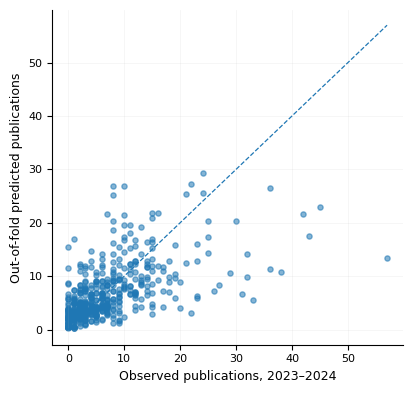

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14B_clean_repeated_cv_delta_R2.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14B_clean_repeated_cv_delta_R2.png


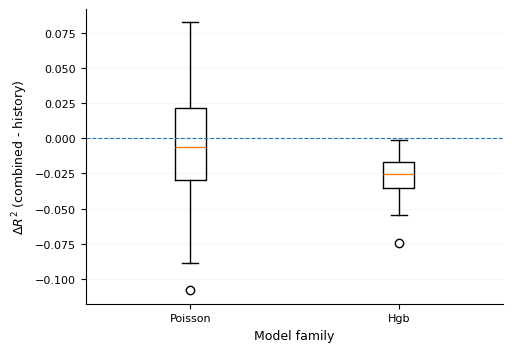

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14C_clean_repeated_cv_delta_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/figures/Fig14C_clean_repeated_cv_delta_MAE.png


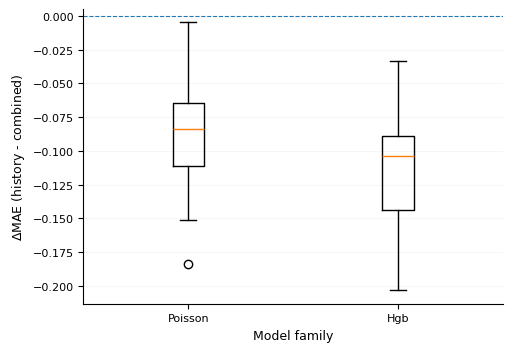


BLOCOS PARA ENVIAR AO CHATGPT
TABLE 50B — EXACT ALIAS CHECK AMONG USED FEATURES
TABLE 51 — CLEAN PRIMARY PREDICTIVE PERFORMANCE
TABLE 52 — CLEAN INCREMENTAL GRAPH VALUE: PAIRED BOOTSTRAP
TABLE 54 — CLEAN REPEATED-CV SPLIT SENSITIVITY
TABLE 55 — CLEAN NEGATIVE CONTROL
TABLE 56 — OLD VS CLEAN PRIMARY COMPARISON
TABLE 57 — CLEAN FINAL INCREMENTAL GRAPH DECISION

[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun
CONCLUÍDO.


In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.14 — REEXECUÇÃO FINAL LIMPA DA VALIDAÇÃO PREDITIVA
============================================================

Usa exclusivamente o painel deduplicado congelado na Parte 18.13.
Não reutiliza aliases genéricos e datados simultaneamente.

Executar no Colab:
    %run /content/Parte_18_14_Clean_Final_Predictive_Rerun.py
"""

from __future__ import annotations

import sys, json, math, pickle, warnings, importlib
from pathlib import Path
from collections import Counter

# ======================================================================================
# 0. DRIVE — evita mensagem/confusão de remount
# ======================================================================================
DRIVE = Path('/content/drive/MyDrive')
if DRIVE.exists():
    print('[drive] Google Drive já montado; reutilizando a sessão atual.')
else:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================
def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name or import_name])
        return importlib.import_module(import_name)

for imp, pipn in [('numpy',None),('pandas',None),('sklearn','scikit-learn'),('scipy',None),('matplotlib',None)]:
    ensure(imp,pipn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, wilcoxon
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================================
# 2. CAMINHOS / FREEZE
# ======================================================================================
ROOT = Path('/content/drive/MyDrive/tese_doutoral')
RUN_ROOT = ROOT / 'runs' / 'temporal_productivity_20260929'
PANEL = RUN_ROOT / '13_feature_redundancy_clean_freeze' / 'artifacts' / 'panel_model_ready_clean_deduplicated.csv'
BLOCKS = RUN_ROOT / '13_feature_redundancy_clean_freeze' / 'artifacts' / 'clean_feature_blocks.json'
OLD_TABLE11 = RUN_ROOT / '08_final_incremental_graph_validation' / 'tables' / 'Table_11_primary_paired_predictive_performance.csv'

OUT = RUN_ROOT / '14_clean_final_predictive_rerun'
TAB = OUT / 'tables'; ART = OUT / 'artifacts'; FIG = OUT / 'figures'; LOG = OUT / 'logs'
for d in [OUT,TAB,ART,FIG,LOG]: d.mkdir(parents=True, exist_ok=True)

PRIMARY_OUTCOME = 'future_works_2023_2024'
HISTORY = [
    'past_works_2018_2022',
    'past_active_years_2018_2022',
    'recent_works_2021_2022',
    'past_productivity_slope',
]
GRAPH = [
    'degree_2018_2022',
    'strength_2018_2022',
    'avg_tie_strength_2018_2022',
    'weighted_clustering_2018_2022',
    'pagerank_2018_2022',
    'betweenness_2018_2022',
    'core_number_2018_2022',
    'avg_neighbor_degree_2018_2022',
    'component_size_2018_2022',
    'is_isolate_2018_2022',
]

# Se o JSON existir, só o usamos se devolver exatamente colunas válidas.
if BLOCKS.exists():
    try:
        obj = json.loads(BLOCKS.read_text(encoding='utf-8'))
        h = obj.get('history') or obj.get('history_features') or obj.get('clean_history')
        g = obj.get('graph') or obj.get('graph_features') or obj.get('clean_graph')
        if isinstance(h,list) and len(h)>0: HISTORY = [str(x) for x in h]
        if isinstance(g,list) and len(g)>0: GRAPH = [str(x) for x in g]
    except Exception as e:
        print('[blocks] JSON não lido; usando freeze explícito da Parte 18.13:', repr(e))

SEED = 20260930
OUTER_K = 10
INNER_K = 5
BOOT_B = 5000
REPEATS = 30
NEG_B = 100

POISSON_GRID = [1e-4,1e-3,1e-2,0.1,0.5,1.0,2.0,5.0]
HGB_GRID = list(ParameterGrid({
    'learning_rate':[0.03,0.05],
    'max_iter':[200],
    'max_leaf_nodes':[7,15],
    'min_samples_leaf':[15],
    'l2_regularization':[0.0,1.0],
}))

# ======================================================================================
# 3. HELPERS
# ======================================================================================
def show(title, df, max_rows=100):
    print('\n'+'='*118); print(title); print('='*118)
    if df.empty:
        print('[vazio]')
    else:
        print(df.head(max_rows).to_string(index=False))
        if display is not None: display(df.head(max_rows))

def clip_pred(p):
    return np.clip(np.asarray(p,dtype=float),1e-8,None)

def metric_dict(y,p):
    y=np.asarray(y,float); p=clip_pred(p)
    try: rho=float(spearmanr(y,p).statistic)
    except Exception: rho=np.nan
    if not np.isfinite(rho): rho=np.nan
    return {
        'MAE':float(mean_absolute_error(y,p)),
        'RMSE':float(np.sqrt(mean_squared_error(y,p))),
        'R2':float(r2_score(y,p)),
        'Poisson_deviance':float(mean_poisson_deviance(y,p)),
        'Spearman_rho':rho,
        'mean_observed':float(np.mean(y)),
        'mean_predicted':float(np.mean(p)),
    }

def make_poisson(alpha):
    return Pipeline([
        ('scale',StandardScaler()),
        ('model',PoissonRegressor(alpha=float(alpha),max_iter=5000,tol=1e-8))
    ])

def make_hgb(params):
    return HistGradientBoostingRegressor(loss='poisson',random_state=SEED,**dict(params))

def candidate_repr(fam,p):
    return str(float(p)) if fam=='poisson' else json.dumps(dict(p),sort_keys=True)

def make_model(fam,p):
    return make_poisson(p) if fam=='poisson' else make_hgb(p)

def tune(X,y,fam,seed):
    inner=KFold(n_splits=INNER_K,shuffle=True,random_state=seed)
    candidates=POISSON_GRID if fam=='poisson' else HGB_GRID
    rows=[]
    for cand in candidates:
        fold_mae=[]
        for tr,va in inner.split(X):
            m=make_model(fam,cand)
            m.fit(X[tr],y[tr])
            fold_mae.append(mean_absolute_error(y[va],clip_pred(m.predict(X[va]))))
        rows.append((cand,float(np.mean(fold_mae))))
    rows.sort(key=lambda z:z[1])
    return rows[0][0],rows

def mode_param(fam, arr):
    reps=[candidate_repr(fam,p) for p in arr]
    winner=Counter(reps).most_common(1)[0][0]
    return float(winner) if fam=='poisson' else json.loads(winner)

def fit_predict(fam,param,Xtr,ytr,Xte):
    m=make_model(fam,param); m.fit(Xtr,ytr); return clip_pred(m.predict(Xte))

def deltas(y,ph,pc):
    h=metric_dict(y,ph); c=metric_dict(y,pc)
    return {
        'delta_MAE':h['MAE']-c['MAE'],
        'delta_RMSE':h['RMSE']-c['RMSE'],
        'delta_R2':c['R2']-h['R2'],
        'delta_Poisson_deviance':h['Poisson_deviance']-c['Poisson_deviance'],
    }

def paired_bootstrap(y,ph,pc,B,seed):
    rng=np.random.default_rng(seed); n=len(y); obs=deltas(y,ph,pc)
    vals={k:[] for k in obs}
    for b in range(B):
        idx=rng.integers(0,n,n); d=deltas(y[idx],ph[idx],pc[idx])
        for k,v in d.items():
            if np.isfinite(v): vals[k].append(v)
        if (b+1)%1000==0: print(f'  bootstrap {b+1}/{B}')
    rows=[]
    for k,a in vals.items():
        a=np.asarray(a,float); pos=float(np.mean(a>0)); p2=min(1.0,2*min(pos,1-pos))
        rows.append({
            'metric':k,
            'favorable_direction':'positive = graph block improves prediction',
            'observed':float(obs[k]),
            'bootstrap_median':float(np.median(a)),
            'ci95_low':float(np.quantile(a,.025)),
            'ci95_high':float(np.quantile(a,.975)),
            'positive_share':pos,
            'two_sided_bootstrap_p':p2,
            'bootstrap_effective_B':len(a),
        })
    return pd.DataFrame(rows)

def savefig(fig,stem):
    eps=FIG/f'{stem}.eps'; png=FIG/f'{stem}.png'
    fig.savefig(eps,format='eps',bbox_inches='tight')
    fig.savefig(png,dpi=600,bbox_inches='tight')
    print('[figure]',eps); print('[figure]',png)

# ======================================================================================
# 4. PAINEL E QC
# ======================================================================================
if not PANEL.exists(): raise FileNotFoundError(f'Painel não encontrado: {PANEL}')
df=pd.read_csv(PANEL)

# fallback robusto do desfecho
if PRIMARY_OUTCOME not in df.columns:
    if {'future_works_2023','future_works_2024'}.issubset(df.columns):
        df[PRIMARY_OUTCOME]=pd.to_numeric(df['future_works_2023'],errors='coerce').fillna(0)+pd.to_numeric(df['future_works_2024'],errors='coerce').fillna(0)
    else:
        raise KeyError(f'Desfecho ausente: {PRIMARY_OUTCOME}')

required=HISTORY+GRAPH+[PRIMARY_OUTCOME]
missing=[c for c in required if c not in df.columns]
if missing:
    # fallback explícito validado pela Parte 18.13
    HISTORY=['past_works_2018_2022','past_active_years_2018_2022','recent_works_2021_2022','past_productivity_slope']
    GRAPH=['degree_2018_2022','strength_2018_2022','avg_tie_strength_2018_2022','weighted_clustering_2018_2022','pagerank_2018_2022','betweenness_2018_2022','core_number_2018_2022','avg_neighbor_degree_2018_2022','component_size_2018_2022','is_isolate_2018_2022']
    required=HISTORY+GRAPH+[PRIMARY_OUTCOME]
    missing=[c for c in required if c not in df.columns]
    if missing: raise KeyError('Colunas necessárias ausentes:\n'+'\n'.join(missing))

for c in required: df[c]=pd.to_numeric(df[c],errors='coerce')
if df[required].isna().any().any():
    bad=df[required].isna().sum(); bad=bad[bad>0]
    raise ValueError('Missing após coerção numérica:\n'+bad.to_string())

y=df[PRIMARY_OUTCOME].to_numpy(float)
if np.any(y<0): raise ValueError('Desfecho negativo detectado.')

X={'history':df[HISTORY].to_numpy(float),'graph':df[GRAPH].to_numpy(float),'combined':df[HISTORY+GRAPH].to_numpy(float)}

print('\n'+'='*118)
print('PARTE 18.14 — REEXECUÇÃO FINAL LIMPA DA VALIDAÇÃO PREDITIVA')
print('='*118)
print('[panel] ',PANEL); print('[output]',OUT); print('Panel shape:',df.shape)
print('Outcome:',PRIMARY_OUTCOME)
print('History:',HISTORY)
print('Graph:',GRAPH)

# Feature audit
rows=[]
for block,cols in [('history',HISTORY),('graph',GRAPH)]:
    for c in cols:
        s=df[c]
        rows.append({'block':block,'feature':c,'n':len(s),'missing_n':int(s.isna().sum()),'n_unique':int(s.nunique()),'min':float(s.min()),'median':float(s.median()),'mean':float(s.mean()),'max':float(s.max())})
fa=pd.DataFrame(rows); fa.to_csv(TAB/'Table_50_clean_feature_audit.csv',index=False); show('TABLE 50 — CLEAN FEATURE AUDIT',fa)

# alias check
aliases=[]; fs=HISTORY+GRAPH
for i in range(len(fs)):
    for j in range(i+1,len(fs)):
        if np.allclose(df[fs[i]].to_numpy(float),df[fs[j]].to_numpy(float),rtol=0,atol=1e-12): aliases.append({'feature_a':fs[i],'feature_b':fs[j]})
alias_df=pd.DataFrame(aliases,columns=['feature_a','feature_b']); alias_df.to_csv(TAB/'Table_50B_exact_alias_check_used_features.csv',index=False); show('TABLE 50B — EXACT ALIAS CHECK AMONG USED FEATURES',alias_df)
if len(alias_df): raise RuntimeError('Ainda existem aliases exatos. Modelagem interrompida.')

out_audit=pd.DataFrame([{'outcome':PRIMARY_OUTCOME,'n':len(y),'zero_n':int((y==0).sum()),'zero_pct':float((y==0).mean()*100),'mean':float(y.mean()),'median':float(np.median(y)),'p95':float(np.quantile(y,.95)),'max':float(y.max())}])
out_audit.to_csv(TAB/'Table_50C_primary_outcome_audit.csv',index=False); show('TABLE 50C — PRIMARY OUTCOME AUDIT',out_audit)

# ======================================================================================
# 5. NESTED 10-FOLD OOF
# ======================================================================================
families=['poisson','hgb']; blocks=['history','graph','combined']
preds={f:{b:np.full(len(df),np.nan) for b in blocks} for f in families}
chosen={f:{b:[] for b in blocks} for f in families}
fold_assign=np.full(len(df),-1,int); tuning_rows=[]; outer_rows=[]
outer=KFold(n_splits=OUTER_K,shuffle=True,random_state=SEED)

print('\n'+'='*118); print('NESTED 10-FOLD OOF — CLEAN'); print('='*118)
for fold,(tr,te) in enumerate(outer.split(df),1):
    fold_assign[te]=fold; ytr=y[tr]; yte=y[te]
    print(f'\n--- fold {fold:02d}/{OUTER_K} ---')
    for fam in families:
        for block in blocks:
            best, ranked=tune(X[block][tr],ytr,fam,SEED+fold*100+(10000 if fam=='hgb' else 0))
            chosen[fam][block].append(best)
            for rank,(cand,mae) in enumerate(ranked,1):
                tuning_rows.append({'outer_fold':fold,'family':fam,'block':block,'candidate_rank':rank,'candidate':candidate_repr(fam,cand),'inner_CV_MAE':mae,'selected':int(rank==1)})
            pr=fit_predict(fam,best,X[block][tr],ytr,X[block][te]); preds[fam][block][te]=pr
            mm=metric_dict(yte,pr)
            outer_rows.append({'outer_fold':fold,'family':fam,'block':block,'selected_param':candidate_repr(fam,best),**mm})
            print(f"  [{fam:7s}] {block:8s} MAE={mm['MAE']:.4f} R2={mm['R2']:.4f} param={candidate_repr(fam,best)}")

for fam in families:
    for block in blocks:
        if np.isnan(preds[fam][block]).any(): raise RuntimeError(f'OOF incompleto: {fam}/{block}')

pd.DataFrame(tuning_rows).to_csv(TAB/'Table_50D_nested_tuning_candidates.csv',index=False)
pd.DataFrame(outer_rows).to_csv(TAB/'Table_50E_outer_fold_results.csv',index=False)

# ======================================================================================
# 6. PERFORMANCE
# ======================================================================================
perf=[]
base_recent=clip_pred(df['recent_works_2021_2022'].to_numpy(float))
base_5y=clip_pred(df['past_works_2018_2022'].to_numpy(float)*(2/5))
for name,p in [('persistence_recent_2021_2022',base_recent),('persistence_5y_rate_scaled',base_5y)]:
    perf.append({'outcome':PRIMARY_OUTCOME,'validation':'deterministic baseline','family':'baseline','block':name,**metric_dict(y,p)})
for fam in families:
    for block in blocks:
        perf.append({'outcome':PRIMARY_OUTCOME,'validation':'nested 10-fold OOF','family':fam,'block':block,**metric_dict(y,preds[fam][block])})
perf_df=pd.DataFrame(perf); perf_df.to_csv(TAB/'Table_51_clean_primary_predictive_performance.csv',index=False); show('TABLE 51 — CLEAN PRIMARY PREDICTIVE PERFORMANCE',perf_df)

# ======================================================================================
# 7. PAIRED BOOTSTRAP
# ======================================================================================
boots=[]
for fam in families:
    print('\n'+'='*118); print('PAIRED BOOTSTRAP —',fam.upper()); print('='*118)
    b=paired_bootstrap(y,preds[fam]['history'],preds[fam]['combined'],BOOT_B,SEED+(1 if fam=='poisson' else 2)); b.insert(0,'family',fam); boots.append(b)
boot_df=pd.concat(boots,ignore_index=True); boot_df.to_csv(TAB/'Table_52_clean_incremental_graph_value_paired_bootstrap.csv',index=False); show('TABLE 52 — CLEAN INCREMENTAL GRAPH VALUE: PAIRED BOOTSTRAP',boot_df)

# Wilcoxon
wr=[]
for fam in families:
    eh=np.abs(y-preds[fam]['history']); ec=np.abs(y-preds[fam]['combined']); diff=eh-ec
    try: stat,p=wilcoxon(diff,alternative='two-sided',zero_method='wilcox')
    except Exception: stat,p=np.nan,np.nan
    wr.append({'family':fam,'median_abs_error_history':float(np.median(eh)),'median_abs_error_combined':float(np.median(ec)),'median_paired_difference_history_minus_combined':float(np.median(diff)),'mean_paired_difference_history_minus_combined':float(np.mean(diff)),'wilcoxon_statistic':float(stat) if np.isfinite(stat) else np.nan,'wilcoxon_p_two_sided':float(p) if np.isfinite(p) else np.nan})
wil_df=pd.DataFrame(wr); wil_df.to_csv(TAB/'Table_53_clean_paired_absolute_error_wilcoxon.csv',index=False); show('TABLE 53 — CLEAN PAIRED ABSOLUTE-ERROR COMPARISON',wil_df)

# ======================================================================================
# 8. FREEZE HP + REPEATED CV
# ======================================================================================
frozen={}
for fam in families:
    for block in blocks: frozen[f'{fam}_{block}']=mode_param(fam,chosen[fam][block])
(ART/'clean_frozen_hyperparameters.json').write_text(json.dumps(frozen,indent=2,ensure_ascii=False),encoding='utf-8')
print('\nFrozen hyperparameters:\n',json.dumps(frozen,indent=2,ensure_ascii=False))

rep_rows=[]
print('\n'+'='*118); print('REPEATED 10-FOLD CV — CLEAN'); print('='*118)
for fam in families:
    for r in range(REPEATS):
        kf=KFold(n_splits=OUTER_K,shuffle=True,random_state=SEED+1000+r)
        ph=np.full(len(df),np.nan); pc=np.full(len(df),np.nan)
        for tr,te in kf.split(df):
            ph[te]=fit_predict(fam,frozen[f'{fam}_history'],X['history'][tr],y[tr],X['history'][te])
            pc[te]=fit_predict(fam,frozen[f'{fam}_combined'],X['combined'][tr],y[tr],X['combined'][te])
        rep_rows.append({'family':fam,'repeat':r+1,**deltas(y,ph,pc)})
        if (r+1)%5==0: print(f'  [{fam}] {r+1}/{REPEATS}')
rep_raw=pd.DataFrame(rep_rows); rep_raw.to_csv(TAB/'Table_54A_clean_repeated_cv_raw.csv',index=False)
summary=[]
for fam in families:
    s=rep_raw[rep_raw.family==fam]
    for met in ['delta_MAE','delta_RMSE','delta_R2','delta_Poisson_deviance']:
        a=s[met].to_numpy(float); summary.append({'family':fam,'metric':met,'n_repeats':len(a),'median':float(np.median(a)),'mean':float(a.mean()),'sd':float(a.std(ddof=1)),'p2_5':float(np.quantile(a,.025)),'p97_5':float(np.quantile(a,.975)),'positive_share':float((a>0).mean())})
rep_sum=pd.DataFrame(summary); rep_sum.to_csv(TAB/'Table_54_clean_repeated_cv_split_sensitivity.csv',index=False); show('TABLE 54 — CLEAN REPEATED-CV SPLIT SENSITIVITY',rep_sum)

# ======================================================================================
# 9. NEGATIVE CONTROL — GRAPH PERMUTATION
# ======================================================================================
print('\n'+'='*118); print('NEGATIVE CONTROL — PERMUTED GRAPH FEATURES'); print('='*118)
fixed_splits=list(KFold(n_splits=OUTER_K,shuffle=True,random_state=SEED).split(df))
rng=np.random.default_rng(SEED+9000); neg=[]
for fam in families:
    ph=np.full(len(df),np.nan); pc_obs=np.full(len(df),np.nan)
    for tr,te in fixed_splits:
        ph[te]=fit_predict(fam,frozen[f'{fam}_history'],X['history'][tr],y[tr],X['history'][te])
        pc_obs[te]=fit_predict(fam,frozen[f'{fam}_combined'],X['combined'][tr],y[tr],X['combined'][te])
    obs=deltas(y,ph,pc_obs)
    null={k:[] for k in obs}
    for b in range(NEG_B):
        perm=rng.permutation(len(df)); Xcp=np.column_stack([X['history'],X['graph'][perm]])
        pc=np.full(len(df),np.nan)
        for tr,te in fixed_splits:
            pc[te]=fit_predict(fam,frozen[f'{fam}_combined'],Xcp[tr],y[tr],Xcp[te])
        dd=deltas(y,ph,pc)
        for k in null: null[k].append(dd[k])
        if (b+1)%20==0: print(f'  [{fam}] permutation {b+1}/{NEG_B}')
    for k,a in null.items():
        a=np.asarray(a,float); neg.append({'family':fam,'metric':k,'observed_fixed_split_delta':float(obs[k]),'permutations':len(a),'null_mean':float(a.mean()),'null_median':float(np.median(a)),'null_p95':float(np.quantile(a,.95)),'empirical_p_null_ge_observed':float((1+(a>=obs[k]).sum())/(1+len(a)))})
neg_df=pd.DataFrame(neg); neg_df.to_csv(TAB/'Table_55_clean_negative_control_graph_permutation.csv',index=False); show('TABLE 55 — CLEAN NEGATIVE CONTROL',neg_df)

# ======================================================================================
# 10. OLD VS CLEAN
# ======================================================================================
comp=[]
if OLD_TABLE11.exists():
    old=pd.read_csv(OLD_TABLE11)
    for fam in families:
        for block in ['history','combined']:
            oo=old[(old.family.astype(str)==fam)&(old.block.astype(str)==block)]
            nn=perf_df[(perf_df.family.astype(str)==fam)&(perf_df.block.astype(str)==block)]
            if len(oo)==1 and len(nn)==1:
                oo=oo.iloc[0]; nn=nn.iloc[0]
                comp.append({'family':fam,'block':block,'old_MAE':float(oo.MAE),'clean_MAE':float(nn.MAE),'delta_clean_minus_old_MAE':float(nn.MAE-oo.MAE),'old_R2':float(oo.R2),'clean_R2':float(nn.R2),'delta_clean_minus_old_R2':float(nn.R2-oo.R2)})
comp_df=pd.DataFrame(comp); comp_df.to_csv(TAB/'Table_56_old_vs_clean_primary_comparison.csv',index=False); show('TABLE 56 — OLD VS CLEAN PRIMARY COMPARISON',comp_df)

# ======================================================================================
# 11. DECISION GATE
# ======================================================================================
dec=[]
for fam in families:
    b=boot_df[boot_df.family==fam].set_index('metric'); r2=b.loc['delta_R2']; mae=b.loc['delta_MAE']
    clear_r2=bool(r2.ci95_low>0); clear_mae=bool(mae.ci95_low>0)
    if clear_r2 and clear_mae: txt='Clear paired evidence that graph features improve prediction beyond the historical-productivity block for both R2 and MAE.'
    elif clear_r2 or clear_mae: txt='Partial evidence of incremental graph value: improvement is supported for one primary predictive metric but not consistently for both.'
    else: txt='No clear paired evidence that graph features improve prediction beyond the historical-productivity block in this model family.'
    dec.append({'family':fam,'delta_R2_observed':float(r2.observed),'delta_R2_ci95_low':float(r2.ci95_low),'delta_R2_ci95_high':float(r2.ci95_high),'delta_MAE_observed':float(mae.observed),'delta_MAE_ci95_low':float(mae.ci95_low),'delta_MAE_ci95_high':float(mae.ci95_high),'clear_positive_R2':clear_r2,'clear_positive_MAE':clear_mae,'interpretation':txt})
dec_df=pd.DataFrame(dec); dec_df.to_csv(TAB/'Table_57_clean_final_incremental_graph_decision.csv',index=False); show('TABLE 57 — CLEAN FINAL INCREMENTAL GRAPH DECISION',dec_df)

# ======================================================================================
# 12. OOF + FIGURAS
# ======================================================================================
id_cols=[c for c in ['author_key','nome_pesquisado','instituicao_original'] if c in df.columns]
oof=df[id_cols].copy(); oof['outer_fold']=fold_assign; oof['observed']=y; oof['baseline_recent']=base_recent; oof['baseline_5y_scaled']=base_5y
for fam in families:
    for block in blocks: oof[f'pred_{fam}_{block}']=preds[fam][block]
oof.to_csv(ART/'oof_predictions_clean_primary.csv',index=False)

plt.rcParams.update({'font.family':'sans-serif','font.size':9,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8,'legend.fontsize':8,'axes.spines.top':False,'axes.spines.right':False,'ps.fonttype':42,'pdf.fonttype':42})
for fam in families:
    fig,ax=plt.subplots(figsize=(4.2,4.0)); p=preds[fam]['combined']; ax.scatter(y,p,s=14,alpha=.55); lim=max(float(y.max()),float(p.max())); ax.plot([0,lim],[0,lim],ls='--',lw=.9); ax.set_xlabel('Observed publications, 2023–2024'); ax.set_ylabel('Out-of-fold predicted publications'); ax.grid(alpha=.15,lw=.5); fig.tight_layout(); savefig(fig,f'Fig14A_observed_vs_predicted_{fam}_combined');
    if display is not None: display(fig)
    plt.close(fig)
fig,ax=plt.subplots(figsize=(5.2,3.6)); vals=[rep_raw.loc[rep_raw.family==f,'delta_R2'].to_numpy() for f in families]; ax.boxplot(vals,labels=[f.capitalize() for f in families],showfliers=True); ax.axhline(0,ls='--',lw=.8); ax.set_ylabel(r'$\Delta R^2$ (combined - history)'); ax.set_xlabel('Model family'); ax.grid(axis='y',alpha=.15,lw=.5); fig.tight_layout(); savefig(fig,'Fig14B_clean_repeated_cv_delta_R2');
if display is not None: display(fig)
plt.close(fig)
fig,ax=plt.subplots(figsize=(5.2,3.6)); vals=[rep_raw.loc[rep_raw.family==f,'delta_MAE'].to_numpy() for f in families]; ax.boxplot(vals,labels=[f.capitalize() for f in families],showfliers=True); ax.axhline(0,ls='--',lw=.8); ax.set_ylabel(r'$\Delta$MAE (history - combined)'); ax.set_xlabel('Model family'); ax.grid(axis='y',alpha=.15,lw=.5); fig.tight_layout(); savefig(fig,'Fig14C_clean_repeated_cv_delta_MAE');
if display is not None: display(fig)
plt.close(fig)

# ======================================================================================
# 13. FREEZE FINAL
# ======================================================================================
freeze={'panel_path':str(PANEL),'primary_outcome':PRIMARY_OUTCOME,'history_features':HISTORY,'graph_features':GRAPH,'seed':SEED,'outer_k':OUTER_K,'inner_k':INNER_K,'bootstrap_B':BOOT_B,'repeats':REPEATS,'negative_control_B':NEG_B,'frozen_hyperparameters':frozen,'decision':dec_df.to_dict(orient='records')}
with open(ART/'part18_14_clean_final_freeze.pkl','wb') as f: pickle.dump(freeze,f,pickle.HIGHEST_PROTOCOL)
(ART/'part18_14_clean_final_freeze.json').write_text(json.dumps(freeze,indent=2,ensure_ascii=False),encoding='utf-8')
(LOG/'README_Part18_14.txt').write_text('PARTE 18.14 — CLEAN FINAL PREDICTIVE RERUN\n\n'+json.dumps(freeze,indent=2,ensure_ascii=False),encoding='utf-8')

print('\n'+'='*118); print('BLOCOS PARA ENVIAR AO CHATGPT'); print('='*118)
for s in [
    'TABLE 50B — EXACT ALIAS CHECK AMONG USED FEATURES',
    'TABLE 51 — CLEAN PRIMARY PREDICTIVE PERFORMANCE',
    'TABLE 52 — CLEAN INCREMENTAL GRAPH VALUE: PAIRED BOOTSTRAP',
    'TABLE 54 — CLEAN REPEATED-CV SPLIT SENSITIVITY',
    'TABLE 55 — CLEAN NEGATIVE CONTROL',
    'TABLE 56 — OLD VS CLEAN PRIMARY COMPARISON',
    'TABLE 57 — CLEAN FINAL INCREMENTAL GRAPH DECISION',
]: print(s)
print('\n[output]',OUT)
print('CONCLUÍDO.')


[drive] Google Drive já está montado em /content/drive.

PARTE 18.15 — REPLICAÇÃO ANUAL LIMPA DO MECANISMO EXTENSIVO/INTENSIVO
[panel]  /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication
Panel shape: (500, 47)

TABLE 58A — CLEAN ANNUAL ALIAS CHECK
[vazio]


,feature_a,feature_b,exact_alias


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/tables/Table_58A_clean_annual_alias_check.csv

TABLE 58B — CLEAN ANNUAL OUTCOME AUDIT
 year           outcome   n  active_n  inactive_n  active_pct  mean  median  p95  max  variance  variance_to_mean
 2023 future_works_2023 500       389         111        77.8 3.338     2.0 11.0 27.0 16.067892          4.813628
 2024 future_works_2024 500       376         124        75.2 3.472     2.0 12.0 37.0 18.955126          5.459426
 2025 future_works_2025 500       240         260        48.0 1.882     0.0 10.0 51.0 21.414906         11.378802


,year,outcome,n,active_n,inactive_n,active_pct,mean,median,p95,max,variance,variance_to_mean
0,2023,future_works_2023,500,389,111,77.8,3.338,2.0,11.0,27.0,16.067892,4.813628
1,2024,future_works_2024,500,376,124,75.2,3.472,2.0,12.0,37.0,18.955126,5.459426
2,2025,future_works_2025,500,240,260,48.0,1.882,0.0,10.0,51.0,21.414906,11.378802


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/tables/Table_58B_clean_annual_outcome_audit.csv

######################################################################################################################
YEAR 2023 — future_works_2023
######################################################################################################################

----------------------------------------------------------------------------------------------------------------------
2023 | FAMILY=LINEAR
----------------------------------------------------------------------------------------------------------------------

  block=history
    [linear] fold 01/10 | train=450 test=50 | active_train=350 active_test=39
    [linear] fold 02/10 | train=450 test=50 | active_train=350 active_test=39
    [linear] fold 03/10 | train=450 test=50 | active_train=350 active_test=39
    [linear] fold 04/10 | train=450 test=50 | active_tra

...

[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/tables/Table_60_clean_annual_incremental_graph_value.csv
[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/tables/Table_60B_clean_annual_nested_tuning_audit.csv
[artifact] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/artifacts/oof_predictions_clean_annual_hurdle.csv
[artifact] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/artifacts/clean_annual_bootstrap_objects.pkl

TABLE 61 — CLEAN CROSS-YEAR CONSISTENCY
family       margin  metric  year  observed  ci95_low  ci95_high  clear_positive  clear_negative
linear    extensive ROC_AUC  2023 -0.000463 -0.013485   0.012653           False           False
linear    extensive ROC_AUC  2024 -0.004365 -0.016229   0.007047           False         

,family,margin,metric,year,observed,ci95_low,ci95_high,clear_positive,clear_negative
0,linear,extensive,ROC_AUC,2023,-0.000463,-0.013485,0.012653,False,False
1,linear,extensive,ROC_AUC,2024,-0.004365,-0.016229,0.007047,False,False
2,linear,extensive,ROC_AUC,2025,-0.014022,-0.027214,-0.001424,False,True
3,linear,intensive,MAE,2023,-0.099232,-0.193233,-0.003686,False,True
4,linear,intensive,MAE,2024,-0.096332,-0.194610,0.004790,False,False
5,linear,intensive,MAE,2025,0.404089,0.083508,0.732239,True,False
6,linear,intensive,R2,2023,0.014077,-0.176332,0.306020,False,False
7,linear,intensive,R2,2024,0.038412,-0.072988,0.214327,False,False
8,linear,intensive,R2,2025,0.208712,0.057262,0.455928,True,False
9,linear,hurdle_total,MAE,2023,-0.083486,-0.152702,-0.009769,False,True


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/tables/Table_61_clean_cross_year_consistency.csv

TABLE 62 — CLEAN ANNUAL MECHANISM DECISION GATE
                         status  intensive_strong_2023  intensive_strong_2024  intensive_strong_2025  hurdle_strong_2023  hurdle_strong_2024  hurdle_strong_2025  intensive_replicates_all_years  hurdle_replicates_all_years  primary_2023_2024_endpoint_remains_unchanged                                                                                                                                                                                                                 interpretation
CLEAN_2025_SPECIFIC_OR_UNSTABLE                  False                  False                   True               False               False                True                           False                        False                                          True After feature deduplication

,status,intensive_strong_2023,intensive_strong_2024,intensive_strong_2025,hurdle_strong_2023,hurdle_strong_2024,hurdle_strong_2025,intensive_replicates_all_years,hurdle_replicates_all_years,primary_2023_2024_endpoint_remains_unchanged,interpretation
0,CLEAN_2025_SPECIFIC_OR_UNSTABLE,False,False,True,False,False,True,False,False,True,"After feature deduplication, any strong 2025 g..."


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/tables/Table_62_clean_annual_mechanism_decision_gate.csv
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/figures/Fig15A_clean_extensive_delta_ROC_AUC.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/figures/Fig15A_clean_extensive_delta_ROC_AUC.png


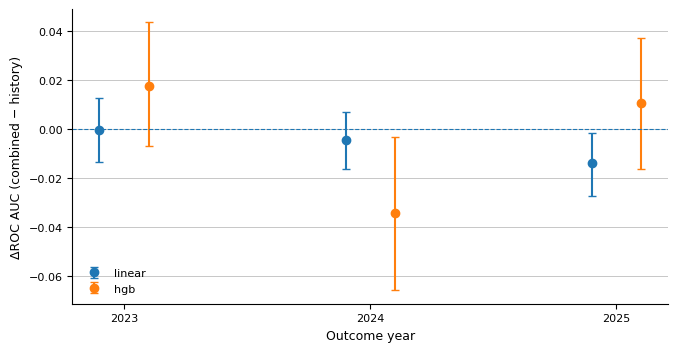

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/figures/Fig15B_clean_intensive_delta_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/figures/Fig15B_clean_intensive_delta_MAE.png


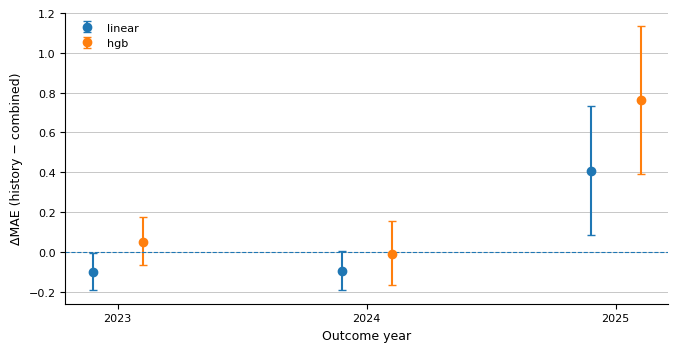

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/figures/Fig15C_clean_hurdle_total_delta_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/15_clean_annual_hurdle_replication/figures/Fig15C_clean_hurdle_total_delta_MAE.png


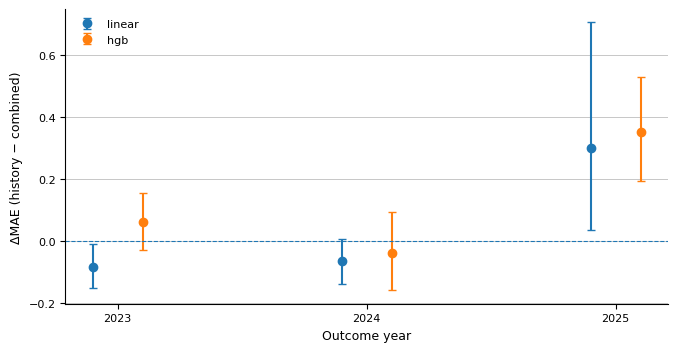


PART 18.15 — SUMMARY
PARTE 18.15 — CLEAN ANNUAL HURDLE REPLICATION

Panel:
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv

N:
500

Canonical history block (4):
['past_works_2018_2022', 'past_active_years_2018_2022', 'recent_works_2021_2022', 'past_productivity_slope']

Canonical graph block (10):
['degree_2018_2022', 'strength_2018_2022', 'avg_tie_strength_2018_2022', 'weighted_clustering_2018_2022', 'pagerank_2018_2022', 'betweenness_2018_2022', 'core_number_2018_2022', 'avg_neighbor_degree_2018_2022', 'component_size_2018_2022', 'is_isolate_2018_2022']

Years:
2023, 2024, 2025

Status:
CLEAN_2025_SPECIFIC_OR_UNSTABLE

Interpretation:
After feature deduplication, any strong 2025 graph signal is not reproduced consistently in 2023 and 2024. It should remain a post-hoc, year-specific mechanistic finding and must not alter the primary 2023–2024 conclusion.

Important:
This is 

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.15 — REPLICAÇÃO ANUAL LIMPA DO MECANISMO EXTENSIVO/INTENSIVO
====================================================================

Reexecuta, com as features canônicas e deduplicadas congeladas na Parte 18.13,
a análise anual pós-hoc de 2023, 2024 e 2025:

1) margem extensiva: P(publicar >= 1 trabalho no ano);
2) margem intensiva: E[n trabalhos | ativo no ano];
3) hurdle total: P(ativo) * E[n trabalhos | ativo].

Não substitui o endpoint primário 2023–2024 da Parte 18.14.

Execução no Colab:
    %run /content/Parte_18_15_Annual_Hurdle_Clean_Replication.py
"""

from __future__ import annotations

import json
import sys
import pickle
import zlib
import importlib
from pathlib import Path

# ======================================================================================
# 0. GOOGLE DRIVE — evita remount desnecessário
# ======================================================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")
if DRIVE_ROOT.exists():
    print("[drive] Google Drive já está montado em /content/drive.")
else:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("[drive] Falha ao montar o Google Drive:", repr(e))
        raise

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("sklearn", "scikit-learn")
ensure("scipy")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_poisson_deviance,
)

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929")
PANEL = (
    ROOT
    / "13_feature_redundancy_clean_freeze"
    / "artifacts"
    / "panel_model_ready_clean_deduplicated.csv"
)

OUT = ROOT / "15_clean_annual_hurdle_replication"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
NOTES = OUT / "notes"
for d in [OUT, TAB, FIG, ART, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

if not PANEL.exists():
    raise FileNotFoundError(f"Painel limpo da Parte 18.13 não encontrado:\n{PANEL}")

# ======================================================================================
# 3. FEATURES E OUTCOMES CONGELADOS
# ======================================================================================

HISTORY = [
    "past_works_2018_2022",
    "past_active_years_2018_2022",
    "recent_works_2021_2022",
    "past_productivity_slope",
]

GRAPH = [
    "degree_2018_2022",
    "strength_2018_2022",
    "avg_tie_strength_2018_2022",
    "weighted_clustering_2018_2022",
    "pagerank_2018_2022",
    "betweenness_2018_2022",
    "core_number_2018_2022",
    "avg_neighbor_degree_2018_2022",
    "component_size_2018_2022",
    "is_isolate_2018_2022",
]

COMBINED = HISTORY + GRAPH

ANNUAL_OUTCOMES = {
    2023: "future_works_2023",
    2024: "future_works_2024",
    2025: "future_works_2025",
}

SEED = 20260930
OUTER_FOLDS = 10
INNER_FOLDS = 5
BOOT_B = 5000

LOGISTIC_GRID = {"model__C": [0.01, 0.1, 1.0, 10.0]}
POISSON_GRID = {"model__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]}

HGB_CLASS_GRID = {
    "learning_rate": [0.03, 0.05],
    "max_iter": [200],
    "max_leaf_nodes": [7, 15],
    "min_samples_leaf": [15],
    "l2_regularization": [0.0, 1.0],
}

HGB_REG_GRID = {
    "learning_rate": [0.03, 0.05],
    "max_iter": [200],
    "max_leaf_nodes": [7, 15],
    "min_samples_leaf": [15],
    "l2_regularization": [0.0, 1.0],
}

# ======================================================================================
# 4. HELPERS
# ======================================================================================

def stable_seed(*parts):
    token = "|".join(map(str, parts)).encode("utf-8")
    return int((SEED + zlib.crc32(token)) % (2**31 - 1))


def show_df(name, df, max_rows=200):
    print("\n" + "=" * 118)
    print(name)
    print("=" * 118)
    if df.empty:
        print("[vazio]")
    else:
        print(df.head(max_rows).to_string(index=False))
    if display is not None:
        display(df.head(max_rows))


def save_table(df, filename):
    p = TAB / filename
    df.to_csv(p, index=False)
    print("[table]", p)
    return p


def save_figure(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)
    return eps, png


def clip_count_pred(pred):
    return np.clip(np.asarray(pred, dtype=float), 1e-9, None)


def safe_spearman(y, pred):
    try:
        r = spearmanr(y, pred).statistic
        return float(r) if np.isfinite(r) else np.nan
    except Exception:
        return np.nan


def count_metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = clip_count_pred(pred)
    return {
        "MAE": float(mean_absolute_error(y, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
        "R2": float(r2_score(y, pred)),
        "Poisson_deviance": float(mean_poisson_deviance(y, pred)),
        "Spearman_rho": safe_spearman(y, pred),
        "mean_observed": float(np.mean(y)),
        "mean_predicted": float(np.mean(pred)),
    }


def binary_metrics(y, prob):
    y = np.asarray(y, dtype=int)
    prob = np.clip(np.asarray(prob, dtype=float), 1e-8, 1 - 1e-8)
    pred = (prob >= 0.5).astype(int)
    out = {
        "ROC_AUC": np.nan,
        "PR_AUC": np.nan,
        "log_loss": float(log_loss(y, prob, labels=[0, 1])),
        "Brier": float(brier_score_loss(y, prob)),
        "accuracy": float(accuracy_score(y, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y, pred)),
        "mean_observed": float(np.mean(y)),
        "mean_predicted": float(np.mean(prob)),
    }
    if len(np.unique(y)) == 2:
        out["ROC_AUC"] = float(roc_auc_score(y, prob))
        out["PR_AUC"] = float(average_precision_score(y, prob))
    return out


def make_logistic():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
            random_state=SEED,
        )),
    ])


def make_poisson():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", PoissonRegressor(max_iter=5000, tol=1e-8)),
    ])


def make_hgb_classifier():
    return HistGradientBoostingClassifier(
        random_state=SEED,
        early_stopping=False,
    )


def make_hgb_regressor():
    return HistGradientBoostingRegressor(
        loss="poisson",
        random_state=SEED,
        early_stopping=False,
    )


def tune_binary_model(family, X, y, seed):
    y = np.asarray(y, dtype=int)
    counts = np.bincount(y, minlength=2)
    min_class = int(counts.min())
    n_inner = min(INNER_FOLDS, min_class)

    if n_inner < 2:
        if family == "linear":
            model = make_logistic()
            model.set_params(model__C=1.0)
        else:
            model = make_hgb_classifier()
            model.set_params(
                learning_rate=0.03,
                max_iter=200,
                max_leaf_nodes=7,
                min_samples_leaf=15,
                l2_regularization=1.0,
            )
        model.fit(X, y)
        return model, {"fallback": True}

    inner = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=seed)

    if family == "linear":
        base, grid = make_logistic(), LOGISTIC_GRID
    elif family == "hgb":
        base, grid = make_hgb_classifier(), HGB_CLASS_GRID
    else:
        raise ValueError(f"Família binária desconhecida: {family}")

    gs = GridSearchCV(
        base,
        grid,
        cv=inner,
        scoring="neg_log_loss",
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )
    gs.fit(X, y)
    return gs.best_estimator_, gs.best_params_


def tune_count_model(family, X, y, seed):
    y = np.asarray(y, dtype=float)
    n_inner = min(INNER_FOLDS, len(y))

    if n_inner < 2:
        if family == "linear":
            model = make_poisson()
            model.set_params(model__alpha=0.1)
        else:
            model = make_hgb_regressor()
            model.set_params(
                learning_rate=0.03,
                max_iter=200,
                max_leaf_nodes=7,
                min_samples_leaf=15,
                l2_regularization=1.0,
            )
        model.fit(X, y)
        return model, {"fallback": True}

    inner = KFold(n_splits=n_inner, shuffle=True, random_state=seed)

    if family == "linear":
        base, grid = make_poisson(), POISSON_GRID
    elif family == "hgb":
        base, grid = make_hgb_regressor(), HGB_REG_GRID
    else:
        raise ValueError(f"Família de contagem desconhecida: {family}")

    gs = GridSearchCV(
        base,
        grid,
        cv=inner,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
        error_score="raise",
    )
    gs.fit(X, y)
    return gs.best_estimator_, gs.best_params_


def outer_hurdle_oof(X, y_count, family, seed):
    """Cross-fitting do classificador, contagem condicional e hurdle total."""
    X = np.asarray(X, dtype=float)
    y_count = np.asarray(y_count, dtype=float)
    y_active = (y_count > 0).astype(int)

    counts = np.bincount(y_active, minlength=2)
    n_outer = min(OUTER_FOLDS, int(counts.min()))
    if n_outer < 2:
        raise RuntimeError(f"Classes insuficientes para CV: {counts.tolist()}")

    outer = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=seed)

    p_active = np.full(len(y_count), np.nan)
    mu_active = np.full(len(y_count), np.nan)
    hurdle_total = np.full(len(y_count), np.nan)
    fold_id = np.full(len(y_count), -1, dtype=int)
    tuning_rows = []

    for fold, (tr, te) in enumerate(outer.split(X, y_active), start=1):
        Xtr, Xte = X[tr], X[te]
        ytr_active = y_active[tr]
        ytr_count = y_count[tr]

        clf, best_clf = tune_binary_model(
            family, Xtr, ytr_active, seed=stable_seed(seed, family, "clf", fold)
        )
        p = np.clip(clf.predict_proba(Xte)[:, 1], 1e-8, 1 - 1e-8)

        active_train = ytr_count > 0
        if active_train.sum() < 5:
            raise RuntimeError(f"Fold {fold}: somente {active_train.sum()} ativos no treino.")

        reg, best_reg = tune_count_model(
            family,
            Xtr[active_train],
            ytr_count[active_train],
            seed=stable_seed(seed, family, "reg", fold),
        )
        mu = clip_count_pred(reg.predict(Xte))
        total = p * mu

        p_active[te] = p
        mu_active[te] = mu
        hurdle_total[te] = total
        fold_id[te] = fold

        tuning_rows.append({
            "fold": fold,
            "family": family,
            "classifier_best_params": json.dumps(best_clf, sort_keys=True),
            "count_best_params": json.dumps(best_reg, sort_keys=True),
            "train_n": len(tr),
            "test_n": len(te),
            "active_train_n": int(active_train.sum()),
            "active_test_n": int((y_count[te] > 0).sum()),
        })

        print(
            f"    [{family}] fold {fold:02d}/{n_outer} | "
            f"train={len(tr)} test={len(te)} | "
            f"active_train={active_train.sum()} active_test={(y_count[te] > 0).sum()}"
        )

    if np.isnan(p_active).any() or np.isnan(mu_active).any() or np.isnan(hurdle_total).any():
        raise RuntimeError("Predições OOF incompletas.")

    return {
        "p_active": p_active,
        "mu_active": mu_active,
        "hurdle_total": hurdle_total,
        "fold_id": fold_id,
        "tuning": pd.DataFrame(tuning_rows),
    }


def metric_value(margin, metric, y_count, pred):
    y_count = np.asarray(y_count, dtype=float)
    y_active = (y_count > 0).astype(int)

    if margin == "extensive":
        return float(binary_metrics(y_active, pred["p_active"])[metric])
    if margin == "intensive":
        mask = y_active == 1
        return float(count_metrics(y_count[mask], pred["mu_active"][mask])[metric])
    if margin == "hurdle_total":
        return float(count_metrics(y_count, pred["hurdle_total"])[metric])
    raise ValueError(margin)


def observed_delta(margin, metric, y_count, history_pred, combined_pred):
    h = metric_value(margin, metric, y_count, history_pred)
    c = metric_value(margin, metric, y_count, combined_pred)

    # positivo = combined melhor
    if metric in {"ROC_AUC", "PR_AUC", "R2", "Spearman_rho"}:
        return c - h
    if metric in {"Brier", "log_loss", "MAE", "RMSE", "Poisson_deviance"}:
        return h - c
    raise ValueError(metric)


def bootstrap_incremental(margin, metric, y_count, history_pred, combined_pred, B, seed):
    rng = np.random.default_rng(seed)
    y_count = np.asarray(y_count, dtype=float)
    y_active = (y_count > 0).astype(int)

    if margin == "intensive":
        base_idx = np.flatnonzero(y_active == 1)
    else:
        base_idx = np.arange(len(y_count))

    obs = observed_delta(margin, metric, y_count, history_pred, combined_pred)
    vals = []
    attempts = 0
    max_attempts = B * 5

    while len(vals) < B and attempts < max_attempts:
        attempts += 1
        idx = rng.choice(base_idx, size=len(base_idx), replace=True)
        yb = y_count[idx]

        ph = {k: history_pred[k][idx] for k in ["p_active", "mu_active", "hurdle_total"]}
        pc = {k: combined_pred[k][idx] for k in ["p_active", "mu_active", "hurdle_total"]}

        if margin == "extensive" and len(np.unique((yb > 0).astype(int))) < 2:
            continue

        try:
            d = observed_delta(margin, metric, yb, ph, pc)
            if np.isfinite(d):
                vals.append(float(d))
        except Exception:
            continue

        if len(vals) in {1000, 2000, 3000, 4000, 5000}:
            print(f"      bootstrap {len(vals)}/{B}")

    vals = np.asarray(vals, dtype=float)
    if len(vals) < max(100, int(B * 0.8)):
        raise RuntimeError(f"Bootstrap insuficiente: {margin}/{metric}: {len(vals)}/{B}")

    low, high = np.quantile(vals, [0.025, 0.975])
    pos_share = float(np.mean(vals > 0))
    p_two = float(min(1.0, 2 * min(pos_share, 1 - pos_share)))

    return {
        "observed": float(obs),
        "bootstrap_median": float(np.median(vals)),
        "ci95_low": float(low),
        "ci95_high": float(high),
        "positive_share": pos_share,
        "two_sided_bootstrap_p": p_two,
        "bootstrap_effective_B": int(len(vals)),
    }, vals

# ======================================================================================
# 5. CARREGAMENTO E AUDITORIA
# ======================================================================================

df = pd.read_csv(PANEL)

print("\n" + "=" * 118)
print("PARTE 18.15 — REPLICAÇÃO ANUAL LIMPA DO MECANISMO EXTENSIVO/INTENSIVO")
print("=" * 118)
print("[panel] ", PANEL)
print("[output]", OUT)
print("Panel shape:", df.shape)

required = HISTORY + GRAPH + list(ANNUAL_OUTCOMES.values())
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError("Colunas necessárias ausentes:\n" + "\n".join(missing))

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

feature_missing = df[HISTORY + GRAPH].isna().sum()
if int(feature_missing.sum()) > 0:
    raise RuntimeError(
        "Missing nas features canônicas:\n" +
        feature_missing[feature_missing > 0].to_string()
    )

outcome_missing = df[list(ANNUAL_OUTCOMES.values())].isna().sum()
if int(outcome_missing.sum()) > 0:
    raise RuntimeError(
        "Missing nos outcomes anuais; não serão convertidos para zero:\n" +
        outcome_missing[outcome_missing > 0].to_string()
    )

# alias check entre as features efetivamente usadas
alias_rows = []
used = HISTORY + GRAPH
for i, a in enumerate(used):
    xa = df[a].to_numpy(dtype=float)
    for b in used[i + 1:]:
        xb = df[b].to_numpy(dtype=float)
        if np.array_equal(xa, xb):
            alias_rows.append({"feature_a": a, "feature_b": b, "exact_alias": True})

alias_df = pd.DataFrame(alias_rows, columns=["feature_a", "feature_b", "exact_alias"])
show_df("TABLE 58A — CLEAN ANNUAL ALIAS CHECK", alias_df)
save_table(alias_df, "Table_58A_clean_annual_alias_check.csv")

if not alias_df.empty:
    raise RuntimeError("Aliases exatos ainda presentes no conjunto canônico. Interrompendo.")

# auditoria dos outcomes anuais
audit_rows = []
for yr, outcome in ANNUAL_OUTCOMES.items():
    y = df[outcome].to_numpy(dtype=float)
    active = y > 0
    mean_y = float(np.mean(y))
    var_y = float(np.var(y, ddof=1))
    audit_rows.append({
        "year": yr,
        "outcome": outcome,
        "n": len(y),
        "active_n": int(active.sum()),
        "inactive_n": int((~active).sum()),
        "active_pct": float(active.mean() * 100),
        "mean": mean_y,
        "median": float(np.median(y)),
        "p95": float(np.quantile(y, 0.95)),
        "max": float(np.max(y)),
        "variance": var_y,
        "variance_to_mean": float(var_y / mean_y) if mean_y > 0 else np.nan,
    })

annual_audit = pd.DataFrame(audit_rows)
show_df("TABLE 58B — CLEAN ANNUAL OUTCOME AUDIT", annual_audit)
save_table(annual_audit, "Table_58B_clean_annual_outcome_audit.csv")

# ======================================================================================
# 6. MODELAGEM OOF ANUAL LIMPA
# ======================================================================================

performance_rows = []
incremental_rows = []
tuning_all = []
oof_all = []
bootstrap_objects = {}

METRICS_BY_MARGIN = {
    "extensive": ["ROC_AUC", "PR_AUC", "Brier", "log_loss"],
    "intensive": ["MAE", "RMSE", "R2", "Poisson_deviance"],
    "hurdle_total": ["MAE", "RMSE", "R2", "Poisson_deviance"],
}

for yr, outcome in ANNUAL_OUTCOMES.items():
    print("\n" + "#" * 118)
    print(f"YEAR {yr} — {outcome}")
    print("#" * 118)

    y = df[outcome].to_numpy(dtype=float)
    y_active = (y > 0).astype(int)

    for family in ["linear", "hgb"]:
        print("\n" + "-" * 118)
        print(f"{yr} | FAMILY={family.upper()}")
        print("-" * 118)

        preds = {}

        for block, features in [("history", HISTORY), ("combined", COMBINED)]:
            print(f"\n  block={block}")
            X = df[features].to_numpy(dtype=float)
            out = outer_hurdle_oof(
                X,
                y,
                family=family,
                seed=stable_seed(yr, family, block),
            )
            preds[block] = out

            tun = out["tuning"].copy()
            tun["year"] = yr
            tun["outcome"] = outcome
            tun["block"] = block
            tuning_all.append(tun)

            bm = binary_metrics(y_active, out["p_active"])
            performance_rows.append({
                "year": yr,
                "outcome": outcome,
                "margin": "extensive",
                "family": family,
                "block": block,
                "n": len(y),
                "active_n": int(y_active.sum()),
                **bm,
                "MAE": np.nan,
                "RMSE": np.nan,
                "R2": np.nan,
                "Poisson_deviance": np.nan,
                "Spearman_rho": np.nan,
            })

            active_mask = y_active == 1
            cm_i = count_metrics(y[active_mask], out["mu_active"][active_mask])
            performance_rows.append({
                "year": yr,
                "outcome": outcome,
                "margin": "intensive",
                "family": family,
                "block": block,
                "n": int(active_mask.sum()),
                "active_n": int(active_mask.sum()),
                "ROC_AUC": np.nan,
                "PR_AUC": np.nan,
                "log_loss": np.nan,
                "Brier": np.nan,
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                **cm_i,
            })

            cm_h = count_metrics(y, out["hurdle_total"])
            performance_rows.append({
                "year": yr,
                "outcome": outcome,
                "margin": "hurdle_total",
                "family": family,
                "block": block,
                "n": len(y),
                "active_n": int(y_active.sum()),
                "ROC_AUC": np.nan,
                "PR_AUC": np.nan,
                "log_loss": np.nan,
                "Brier": np.nan,
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                **cm_h,
            })

            tmp = pd.DataFrame({
                "row_id": np.arange(len(df)),
                "year": yr,
                "outcome": outcome,
                "family": family,
                "block": block,
                "fold_id": out["fold_id"],
                "observed_count": y,
                "observed_active": y_active,
                "pred_prob_active": out["p_active"],
                "pred_count_if_active": out["mu_active"],
                "pred_hurdle_total": out["hurdle_total"],
            })
            oof_all.append(tmp)

        for margin, metrics in METRICS_BY_MARGIN.items():
            print(f"\n  paired bootstrap | {yr} | {family} | {margin}")
            for metric in metrics:
                res, vals = bootstrap_incremental(
                    margin=margin,
                    metric=metric,
                    y_count=y,
                    history_pred=preds["history"],
                    combined_pred=preds["combined"],
                    B=BOOT_B,
                    seed=stable_seed("bootstrap", yr, family, margin, metric),
                )
                incremental_rows.append({
                    "year": yr,
                    "outcome": outcome,
                    "margin": margin,
                    "family": family,
                    "metric": metric,
                    "favorable_direction": "positive = graph block improves prediction",
                    **res,
                })
                bootstrap_objects[f"{yr}__{family}__{margin}__{metric}"] = vals

performance = pd.DataFrame(performance_rows)
incremental = pd.DataFrame(incremental_rows)
tuning = pd.concat(tuning_all, ignore_index=True)
oof = pd.concat(oof_all, ignore_index=True)

show_df("TABLE 59 — CLEAN ANNUAL EXTENSIVE / INTENSIVE / HURDLE PERFORMANCE", performance)
save_table(performance, "Table_59_clean_annual_extensive_intensive_hurdle_performance.csv")

show_df("TABLE 60 — CLEAN ANNUAL INCREMENTAL GRAPH VALUE", incremental)
save_table(incremental, "Table_60_clean_annual_incremental_graph_value.csv")

save_table(tuning, "Table_60B_clean_annual_nested_tuning_audit.csv")

oof_path = ART / "oof_predictions_clean_annual_hurdle.csv"
oof.to_csv(oof_path, index=False)
print("[artifact]", oof_path)

boot_path = ART / "clean_annual_bootstrap_objects.pkl"
with open(boot_path, "wb") as f:
    pickle.dump(bootstrap_objects, f, pickle.HIGHEST_PROTOCOL)
print("[artifact]", boot_path)

# ======================================================================================
# 7. CONSISTÊNCIA ENTRE ANOS
# ======================================================================================

check_defs = [
    ("extensive", "ROC_AUC"),
    ("intensive", "MAE"),
    ("intensive", "R2"),
    ("hurdle_total", "MAE"),
    ("hurdle_total", "R2"),
]

check_rows = []
for family in ["linear", "hgb"]:
    for margin, metric in check_defs:
        z = incremental[
            (incremental["family"] == family)
            & (incremental["margin"] == margin)
            & (incremental["metric"] == metric)
        ].sort_values("year")
        for _, r in z.iterrows():
            check_rows.append({
                "family": family,
                "margin": margin,
                "metric": metric,
                "year": int(r["year"]),
                "observed": float(r["observed"]),
                "ci95_low": float(r["ci95_low"]),
                "ci95_high": float(r["ci95_high"]),
                "clear_positive": bool(r["observed"] > 0 and r["ci95_low"] > 0),
                "clear_negative": bool(r["observed"] < 0 and r["ci95_high"] < 0),
            })

cross_year = pd.DataFrame(check_rows)
show_df("TABLE 61 — CLEAN CROSS-YEAR CONSISTENCY", cross_year)
save_table(cross_year, "Table_61_clean_cross_year_consistency.csv")


def clear_positive_for(year, family, margin, metric):
    z = cross_year[
        (cross_year["year"] == year)
        & (cross_year["family"] == family)
        & (cross_year["margin"] == margin)
        & (cross_year["metric"] == metric)
    ]
    return False if z.empty else bool(z.iloc[0]["clear_positive"])


year_intensive_strong = {}
year_hurdle_strong = {}
for yr in [2023, 2024, 2025]:
    per_family_int = []
    per_family_hur = []
    for family in ["linear", "hgb"]:
        per_family_int.append(
            clear_positive_for(yr, family, "intensive", "MAE")
            and clear_positive_for(yr, family, "intensive", "R2")
        )
        per_family_hur.append(
            clear_positive_for(yr, family, "hurdle_total", "MAE")
            and clear_positive_for(yr, family, "hurdle_total", "R2")
        )
    year_intensive_strong[yr] = bool(any(per_family_int))
    year_hurdle_strong[yr] = bool(any(per_family_hur))

intensive_all_years = all(year_intensive_strong.values())
hurdle_all_years = all(year_hurdle_strong.values())

if intensive_all_years and hurdle_all_years:
    status = "CLEAN_REPLICATED_ACROSS_2023_2025"
    interpretation = (
        "After feature deduplication, positive incremental graph value is reproduced "
        "across 2023–2025 for both the intensive margin and total hurdle expectation."
    )
elif year_intensive_strong[2025] or year_hurdle_strong[2025]:
    status = "CLEAN_2025_SPECIFIC_OR_UNSTABLE"
    interpretation = (
        "After feature deduplication, any strong 2025 graph signal is not reproduced "
        "consistently in 2023 and 2024. It should remain a post-hoc, year-specific "
        "mechanistic finding and must not alter the primary 2023–2024 conclusion."
    )
else:
    status = "NO_CLEAN_ANNUAL_INCREMENTAL_GRAPH_SIGNAL"
    interpretation = (
        "After feature deduplication, the annual hurdle analyses do not provide "
        "consistent evidence that graph features add predictive value beyond "
        "historical productivity."
    )

decision = pd.DataFrame([{
    "status": status,
    "intensive_strong_2023": year_intensive_strong[2023],
    "intensive_strong_2024": year_intensive_strong[2024],
    "intensive_strong_2025": year_intensive_strong[2025],
    "hurdle_strong_2023": year_hurdle_strong[2023],
    "hurdle_strong_2024": year_hurdle_strong[2024],
    "hurdle_strong_2025": year_hurdle_strong[2025],
    "intensive_replicates_all_years": intensive_all_years,
    "hurdle_replicates_all_years": hurdle_all_years,
    "primary_2023_2024_endpoint_remains_unchanged": True,
    "interpretation": interpretation,
}])

show_df("TABLE 62 — CLEAN ANNUAL MECHANISM DECISION GATE", decision)
save_table(decision, "Table_62_clean_annual_mechanism_decision_gate.csv")

# ======================================================================================
# 8. FIGURAS — SEM TÍTULO EMBUTIDO
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def plot_increment(metric, margin, stem, ylabel):
    z = incremental[
        (incremental["metric"] == metric)
        & (incremental["margin"] == margin)
    ].copy()

    fig, ax = plt.subplots(figsize=(6.85, 3.6))
    years = [2023, 2024, 2025]
    families = ["linear", "hgb"]
    offsets = [-0.10, 0.10]

    for fam, off in zip(families, offsets):
        q = z[z["family"] == fam].set_index("year").reindex(years)
        x = np.arange(len(years), dtype=float) + off
        y = q["observed"].to_numpy(dtype=float)
        lo = q["ci95_low"].to_numpy(dtype=float)
        hi = q["ci95_high"].to_numpy(dtype=float)
        yerr = np.vstack([y - lo, hi - y])
        ax.errorbar(
            x, y, yerr=yerr,
            marker="o", linestyle="none", capsize=3, label=fam
        )

    ax.axhline(0, linestyle="--", linewidth=0.8)
    ax.set_xticks(np.arange(len(years)))
    ax.set_xticklabels([str(y) for y in years])
    ax.set_xlabel("Outcome year")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.grid(axis="y", linewidth=0.5)
    fig.tight_layout()

    save_figure(fig, stem)
    if display is not None:
        display(fig)
    else:
        plt.show()
    plt.close(fig)


plot_increment(
    metric="ROC_AUC",
    margin="extensive",
    stem="Fig15A_clean_extensive_delta_ROC_AUC",
    ylabel="ΔROC AUC (combined − history)",
)

plot_increment(
    metric="MAE",
    margin="intensive",
    stem="Fig15B_clean_intensive_delta_MAE",
    ylabel="ΔMAE (history − combined)",
)

plot_increment(
    metric="MAE",
    margin="hurdle_total",
    stem="Fig15C_clean_hurdle_total_delta_MAE",
    ylabel="ΔMAE (history − combined)",
)

# ======================================================================================
# 9. RESUMO
# ======================================================================================

summary_text = f"""
PARTE 18.15 — CLEAN ANNUAL HURDLE REPLICATION
=============================================

Panel:
{PANEL}

N:
{len(df)}

Canonical history block ({len(HISTORY)}):
{HISTORY}

Canonical graph block ({len(GRAPH)}):
{GRAPH}

Years:
2023, 2024, 2025

Status:
{status}

Interpretation:
{interpretation}

Important:
This is a post-hoc/mechanistic annual replication using the canonical,
deduplicated feature blocks frozen after the redundancy audit.
It does not replace the pre-specified primary prospective endpoint
future_works_2023_2024 evaluated in Part 18.14.
""".strip()

summary_path = NOTES / "Part_18_15_clean_annual_hurdle_summary.txt"
summary_path.write_text(summary_text, encoding="utf-8")

print("\n" + "=" * 118)
print("PART 18.15 — SUMMARY")
print("=" * 118)
print(summary_text)
print("[summary]", summary_path)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 58A — CLEAN ANNUAL ALIAS CHECK")
print("2) TABLE 58B — CLEAN ANNUAL OUTCOME AUDIT")
print("3) TABLE 59 — CLEAN ANNUAL EXTENSIVE / INTENSIVE / HURDLE PERFORMANCE")
print("4) TABLE 60 — CLEAN ANNUAL INCREMENTAL GRAPH VALUE")
print("5) TABLE 61 — CLEAN CROSS-YEAR CONSISTENCY")
print("6) TABLE 62 — CLEAN ANNUAL MECHANISM DECISION GATE")
print("7) PART 18.15 — SUMMARY")
print("\n[output]", OUT)
print("CONCLUÍDO.")


[drive] Google Drive já está montado; seguindo sem remount.

PARTE 18.16 — AUDITORIA DE COMPLETUDE/COMPARABILIDADE DE 2025
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit

Panel shape: (500, 47)
Publications shape: (38138, 9)

TABLE 63 — INPUT IDENTIFIER AUDIT
panel_author_col pub_author_col pub_work_col pub_year_col doi_col title_col type_col  panel_author_openalex_share  pub_author_openalex_share  pub_work_openalex_share
      author_key       autor_id  id_openalex          ano     doi    titulo     tipo                          1.0                        0.0                      0.0


,panel_author_col,pub_author_col,pub_work_col,pub_year_col,doi_col,title_col,type_col,panel_author_openalex_share,pub_author_openalex_share,pub_work_openalex_share
0,author_key,autor_id,id_openalex,ano,doi,titulo,tipo,1.0,0.0,0.0


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/tables/Table_63_input_identifier_audit.csv

TABLE 64 — ANNUAL COVERAGE: GLOBAL CORPUS VS ANALYTIC COHORT
 year  global_author_work_rows  global_unique_works  global_active_authors  global_doi_pct  global_title_pct  cohort_author_work_rows  cohort_unique_works  cohort_active_authors  cohort_active_pct  cohort_doi_pct  cohort_title_pct  global_author_work_rows_yoy_ratio  global_unique_works_yoy_ratio  global_active_authors_yoy_ratio  cohort_author_work_rows_yoy_ratio  cohort_unique_works_yoy_ratio  cohort_active_authors_yoy_ratio
 2018                        0                    0                      0             NaN               NaN                        0                    0                      0                0.0             NaN               NaN                                NaN                            NaN                              NaN                        

,year,global_author_work_rows,global_unique_works,global_active_authors,global_doi_pct,global_title_pct,cohort_author_work_rows,cohort_unique_works,cohort_active_authors,cohort_active_pct,cohort_doi_pct,cohort_title_pct,global_author_work_rows_yoy_ratio,global_unique_works_yoy_ratio,global_active_authors_yoy_ratio,cohort_author_work_rows_yoy_ratio,cohort_unique_works_yoy_ratio,cohort_active_authors_yoy_ratio
0,2018,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2023,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2024,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2025,0,0,0,NaN,NaN,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/tables/Table_64_annual_global_vs_cohort_coverage.csv

TABLE 65 — 2025/2024 COVERAGE RATIOS
                measure  value_2024  value_2025  ratio_2025_to_2024
global_author_work_rows         0.0         0.0                 NaN
    global_unique_works         0.0         0.0                 NaN
  global_active_authors         0.0         0.0                 NaN
cohort_author_work_rows         0.0         0.0                 NaN
    cohort_unique_works         0.0         0.0                 NaN
  cohort_active_authors         0.0         0.0                 NaN


...

,year,scope,author_work_rows,unique_works,doi_pct,title_pct
0,2023,global,0,0,NaN,NaN
1,2023,analytic_cohort,0,0,NaN,NaN
2,2024,global,0,0,NaN,NaN
3,2024,analytic_cohort,0,0,NaN,NaN
4,2025,global,0,0,NaN,NaN
5,2025,analytic_cohort,0,0,NaN,NaN


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/tables/Table_69_metadata_completeness_by_year.csv

TABLE 70 — PUBLICATION-TYPE COMPOSITION 2023–2025
[vazio]
[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/tables/Table_70_publication_type_composition_2023_2025.csv

TABLE 71 — 2025 COVERAGE / COMPARABILITY DECISION GATE
                                          status  global_unique_works_ratio_2025_2024  global_author_work_rows_ratio_2025_2024  cohort_author_work_rows_ratio_2025_2024  cohort_active_authors_ratio_2025_2024  primary_endpoint_remains_2023_2024  2025_can_override_primary_conclusion                                                                                                                                                                         manuscript_role
2025_DIFFERENT_BUT_NOT_CLEARLY_GLOBAL_TRUNCATION                                  NaN

,status,global_unique_works_ratio_2025_2024,global_author_work_rows_ratio_2025_2024,cohort_author_work_rows_ratio_2025_2024,cohort_active_authors_ratio_2025_2024,primary_endpoint_remains_2023_2024,2025_can_override_primary_conclusion,manuscript_role
0,2025_DIFFERENT_BUT_NOT_CLEARLY_GLOBAL_TRUNCATION,NaN,NaN,NaN,NaN,True,False,"2025 differs from 2023–2024, but the available..."


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/tables/Table_71_2025_coverage_decision_gate.csv


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/figures/Fig16A_annual_unique_works_global_vs_cohort.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/figures/Fig16A_annual_unique_works_global_vs_cohort.png


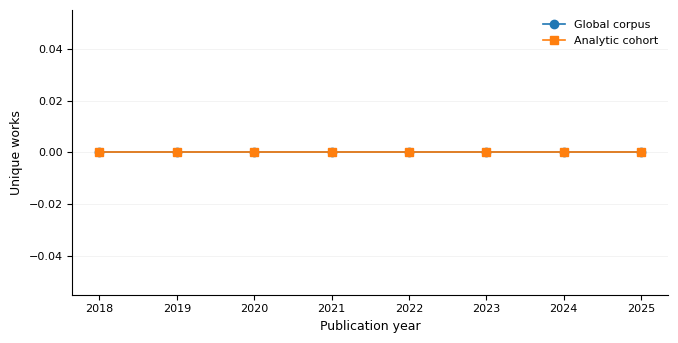

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/figures/Fig16B_annual_active_cohort_authors.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/figures/Fig16B_annual_active_cohort_authors.png


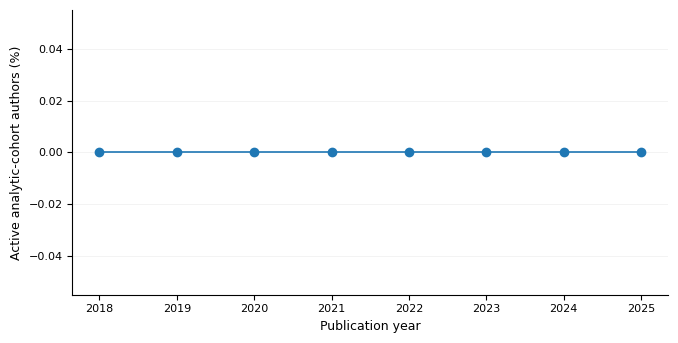

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/figures/Fig16C_year_over_year_coverage_ratios.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/figures/Fig16C_year_over_year_coverage_ratios.png


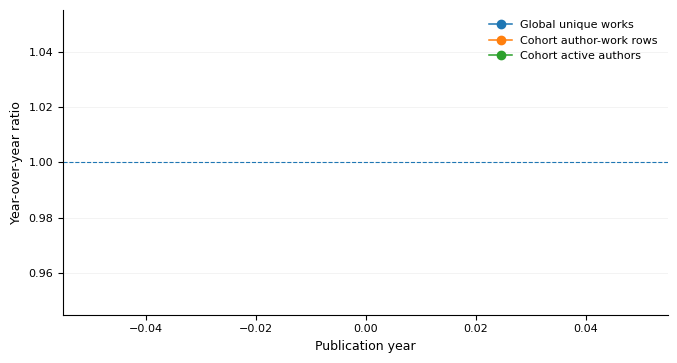


PART 18.16 — SUMMARY
PARTE 18.16 — 2025 COVERAGE / TEMPORAL COMPARABILITY AUDIT

Panel:
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv

Publications:
/content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx

N analytic cohort:
500

2025/2024 ratios
----------------
Global unique works:
nan

Global author-work rows:
nan

Cohort author-work rows:
nan

Cohort active authors:
nan

Decision status:
2025_DIFFERENT_BUT_NOT_CLEARLY_GLOBAL_TRUNCATION

Primary endpoint remains:
future_works_2023_2024

Can 2025 override primary conclusion?
NO

Interpretation:
2025 differs from 2023–2024, but the available audit does not establish global corpus truncation. Keep the year-specific graph result post-hoc because it fails cross-year replication.
[summary] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit/n

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.16 — AUDITORIA DE COMPLETUDE/COMPARABILIDADE DE 2025 E ESTABILIDADE TEMPORAL
=====================================================================================

Objetivo
--------
A Parte 18.15 mostrou um sinal incremental forte das features de rede em 2025,
mas esse sinal não se reproduziu em 2023–2024. Ao mesmo tempo, a proporção de
autores com pelo menos uma publicação caiu de 75,2% (2024) para 48,0% (2025).

Esta etapa NÃO treina novos modelos. Ela verifica se 2025 é comparável aos anos
anteriores ou se existe uma anomalia de cobertura/composição que possa explicar
o resultado post-hoc.

Execução
--------
%run /content/Parte_18_16_Auditoria_Completude_2025.py
"""

from __future__ import annotations

import sys
import re
import importlib
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive")
if not DRIVE_ROOT.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("[drive] Não foi possível montar automaticamente:", repr(e))
else:
    print("[drive] Google Drive já está montado; seguindo sem remount.")

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
        return importlib.import_module(import_name)

ensure("pandas")
ensure("numpy")
ensure("openpyxl")
ensure("matplotlib")
ensure("scipy")
ensure("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binomtest
from sklearn.metrics import jaccard_score

try:
    from IPython.display import display
except Exception:
    display = None

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
RUN_ROOT = ROOT / "runs" / "temporal_productivity_20260929"

PANEL = RUN_ROOT / "13_feature_redundancy_clean_freeze" / "artifacts" / "panel_model_ready_clean_deduplicated.csv"
PUBLICATIONS = ROOT / "runs" / "run_20260625_200032" / "input" / "producoes_final.xlsx"

OUT = RUN_ROOT / "16_2025_coverage_temporal_audit"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
NOTES = OUT / "notes"

for d in [OUT, TAB, FIG, ART, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

if not PANEL.exists():
    raise FileNotFoundError(f"Painel limpo não encontrado: {PANEL}")
if not PUBLICATIONS.exists():
    raise FileNotFoundError(f"Arquivo de publicações não encontrado: {PUBLICATIONS}")

def show_df(title, df, max_rows=50):
    print("\n" + "=" * 118)
    print(title)
    print("=" * 118)
    if df is None or len(df) == 0:
        print("[vazio]")
        return
    to_show = df.head(max_rows)
    print(to_show.to_string(index=False))
    if len(df) > max_rows:
        print(f"... {len(df):,} rows total")
    if display is not None:
        display(to_show)

def save_table(df, filename):
    path = TAB / filename
    df.to_csv(path, index=False)
    print("[table]", path)
    return path

def save_figure(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)
    if display is not None:
        display(fig)
    else:
        plt.show()
    plt.close(fig)

def pick_first(columns, candidates):
    cols = list(columns)
    lower = {str(c).lower(): c for c in cols}
    for c in candidates:
        if c in cols:
            return c
        if c.lower() in lower:
            return lower[c.lower()]
    return None

def is_openalex_author(series):
    s = series.dropna().astype(str).str.strip().str.upper()
    return 0.0 if len(s) == 0 else float(s.str.match(r"^A\d+$").mean())

def is_openalex_work(series):
    s = series.dropna().astype(str).str.strip().str.upper()
    return 0.0 if len(s) == 0 else float(s.str.match(r"^W\d+$").mean())

def normalize_doi(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    return s.replace("https://doi.org/", "").replace("http://doi.org/", "")

def safe_ratio(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return float(num) / float(den)

def robust_modified_z(x, reference):
    ref = np.asarray(reference, dtype=float)
    ref = ref[np.isfinite(ref)]
    if len(ref) < 3:
        return np.nan
    med = np.median(ref)
    mad = np.median(np.abs(ref - med))
    if mad == 0:
        return np.nan
    return float(0.6745 * (x - med) / mad)

def exact_mcnemar_binomial(a10, a01):
    n = int(a10 + a01)
    if n == 0:
        return np.nan
    return float(binomtest(min(a10, a01), n=n, p=0.5, alternative="two-sided").pvalue)

print("\n" + "=" * 118)
print("PARTE 18.16 — AUDITORIA DE COMPLETUDE/COMPARABILIDADE DE 2025")
print("=" * 118)
print("[panel]       ", PANEL)
print("[publications]", PUBLICATIONS)
print("[output]      ", OUT)

panel = pd.read_csv(PANEL)
pub = pd.read_excel(PUBLICATIONS)

print(f"\nPanel shape: {panel.shape}")
print(f"Publications shape: {pub.shape}")

panel_author_col = pick_first(panel.columns, ["author_key", "autor_id", "author_id", "id_autor"])
pub_author_col = pick_first(pub.columns, ["autor_id", "author_id", "author_key", "id_autor"])
pub_work_col = pick_first(pub.columns, ["id_openalex", "work_id", "openalex_work_id", "id_trabalho"])
pub_year_col = pick_first(pub.columns, ["ano", "year", "publication_year"])
doi_col = pick_first(pub.columns, ["doi", "DOI"])
title_col = pick_first(pub.columns, ["titulo", "title", "display_name"])
type_col = pick_first(pub.columns, ["tipo", "type", "work_type", "publication_type", "tipo_publicacao", "subtype", "genre"])

if panel_author_col is None:
    raise KeyError(f"Não encontrei identificador de autor no painel. Colunas: {list(panel.columns)}")
if pub_author_col is None:
    raise KeyError(f"Não encontrei identificador de autor em producoes_final. Colunas: {list(pub.columns)}")
if pub_work_col is None:
    raise KeyError(f"Não encontrei identificador de trabalho em producoes_final. Colunas: {list(pub.columns)}")
if pub_year_col is None:
    raise KeyError(f"Não encontrei coluna de ano em producoes_final. Colunas: {list(pub.columns)}")

column_audit = pd.DataFrame([{
    "panel_author_col": panel_author_col,
    "pub_author_col": pub_author_col,
    "pub_work_col": pub_work_col,
    "pub_year_col": pub_year_col,
    "doi_col": doi_col or "",
    "title_col": title_col or "",
    "type_col": type_col or "",
    "panel_author_openalex_share": is_openalex_author(panel[panel_author_col]),
    "pub_author_openalex_share": is_openalex_author(pub[pub_author_col]),
    "pub_work_openalex_share": is_openalex_work(pub[pub_work_col]),
}])

show_df("TABLE 63 — INPUT IDENTIFIER AUDIT", column_audit)
save_table(column_audit, "Table_63_input_identifier_audit.csv")

base_cols = [pub_author_col, pub_work_col, pub_year_col]
x = pub[base_cols].copy()
x["doi"] = pub[doi_col] if doi_col is not None else ""
x["title"] = pub[title_col] if title_col is not None else ""
x["pub_type"] = pub[type_col] if type_col is not None else ""

x = x.rename(columns={pub_author_col: "author_key", pub_work_col: "work_key", pub_year_col: "year"})
x["author_key"] = x["author_key"].astype(str).str.strip().str.upper()
x["work_key"] = x["work_key"].astype(str).str.strip().str.upper()
x["year"] = pd.to_numeric(x["year"], errors="coerce")

x = x[
    x["author_key"].str.match(r"^A\d+$", na=False)
    & x["work_key"].str.match(r"^W\d+$", na=False)
    & x["year"].between(1900, 2030)
].copy()

x["year"] = x["year"].astype(int)
x["doi_norm"] = x["doi"].map(normalize_doi)
x["has_doi"] = x["doi_norm"].str.contains(r"10\.\d{4,9}/", regex=True, na=False)
x["has_title"] = x["title"].notna() & x["title"].astype(str).str.strip().ne("")
long_df = x.drop_duplicates(["author_key", "work_key"]).copy()

cohort_ids = set(panel[panel_author_col].dropna().astype(str).str.strip().str.upper())

years = list(range(2018, 2026))
annual_rows = []

for yr in years:
    g = long_df[long_df["year"] == yr].copy()
    c = g[g["author_key"].isin(cohort_ids)].copy()
    annual_rows.append({
        "year": yr,
        "global_author_work_rows": len(g),
        "global_unique_works": g["work_key"].nunique(),
        "global_active_authors": g["author_key"].nunique(),
        "global_doi_pct": float(g["has_doi"].mean() * 100) if len(g) else np.nan,
        "global_title_pct": float(g["has_title"].mean() * 100) if len(g) else np.nan,
        "cohort_author_work_rows": len(c),
        "cohort_unique_works": c["work_key"].nunique(),
        "cohort_active_authors": c["author_key"].nunique(),
        "cohort_active_pct": 100.0 * c["author_key"].nunique() / max(1, len(cohort_ids)),
        "cohort_doi_pct": float(c["has_doi"].mean() * 100) if len(c) else np.nan,
        "cohort_title_pct": float(c["has_title"].mean() * 100) if len(c) else np.nan,
    })

annual = pd.DataFrame(annual_rows)

for col in [
    "global_author_work_rows", "global_unique_works", "global_active_authors",
    "cohort_author_work_rows", "cohort_unique_works", "cohort_active_authors"
]:
    annual[f"{col}_yoy_ratio"] = annual[col] / annual[col].shift(1)

show_df("TABLE 64 — ANNUAL COVERAGE: GLOBAL CORPUS VS ANALYTIC COHORT", annual)
save_table(annual, "Table_64_annual_global_vs_cohort_coverage.csv")

row24 = annual.loc[annual["year"] == 2024].iloc[0]
row25 = annual.loc[annual["year"] == 2025].iloc[0]

measures = [
    "global_author_work_rows", "global_unique_works", "global_active_authors",
    "cohort_author_work_rows", "cohort_unique_works", "cohort_active_authors"
]
comparison_2025 = pd.DataFrame([
    {
        "measure": m,
        "value_2024": row24[m],
        "value_2025": row25[m],
        "ratio_2025_to_2024": safe_ratio(row25[m], row24[m]),
    }
    for m in measures
])

show_df("TABLE 65 — 2025/2024 COVERAGE RATIOS", comparison_2025)
save_table(comparison_2025, "Table_65_2025_vs_2024_coverage_ratios.csv")

anomaly_rows = []
for metric in measures:
    ratios = annual[f"{metric}_yoy_ratio"]
    ref = ratios[annual["year"].between(2019, 2024)].dropna().to_numpy(dtype=float)
    r2025 = float(annual.loc[annual["year"] == 2025, f"{metric}_yoy_ratio"].iloc[0])
    anomaly_rows.append({
        "metric": metric,
        "ratio_2025_vs_2024": r2025,
        "reference_years": "2019-2024",
        "reference_ratio_median": float(np.median(ref)) if len(ref) else np.nan,
        "reference_ratio_min": float(np.min(ref)) if len(ref) else np.nan,
        "reference_ratio_max": float(np.max(ref)) if len(ref) else np.nan,
        "modified_z_2025": robust_modified_z(r2025, ref),
    })

anomaly = pd.DataFrame(anomaly_rows)
show_df("TABLE 66 — 2025 ANOMALY RELATIVE TO HISTORICAL YEAR-TO-YEAR VARIATION", anomaly)
save_table(anomaly, "Table_66_2025_historical_anomaly_audit.csv")

author_year = (
    long_df[
        long_df["author_key"].isin(cohort_ids)
        & long_df["year"].between(2023, 2025)
    ]
    .groupby(["author_key", "year"])
    .agg(works=("work_key", "nunique"))
    .reset_index()
)

grid = pd.MultiIndex.from_product(
    [sorted(cohort_ids), [2023, 2024, 2025]],
    names=["author_key", "year"]
).to_frame(index=False)

author_year = grid.merge(author_year, on=["author_key", "year"], how="left")
author_year["works"] = author_year["works"].fillna(0).astype(int)
author_year["active"] = (author_year["works"] > 0).astype(int)

wide_works = author_year.pivot(index="author_key", columns="year", values="works").fillna(0)
wide_active = author_year.pivot(index="author_key", columns="year", values="active").fillna(0).astype(int)

transition_rows = []
for y0, y1 in [(2023, 2024), (2024, 2025)]:
    a0 = wide_active[y0].to_numpy()
    a1 = wide_active[y1].to_numpy()
    aa = int(((a0 == 1) & (a1 == 1)).sum())
    ai = int(((a0 == 1) & (a1 == 0)).sum())
    ia = int(((a0 == 0) & (a1 == 1)).sum())
    ii = int(((a0 == 0) & (a1 == 0)).sum())
    transition_rows.append({
        "transition": f"{y0}->{y1}",
        "active_to_active": aa,
        "active_to_inactive": ai,
        "inactive_to_active": ia,
        "inactive_to_inactive": ii,
        "active_retention_pct": 100 * aa / max(1, aa + ai),
        "reactivation_pct_among_previous_inactive": 100 * ia / max(1, ia + ii),
        "activity_jaccard": float(jaccard_score(a0, a1)),
        "exact_mcnemar_p": exact_mcnemar_binomial(ai, ia),
    })

transitions = pd.DataFrame(transition_rows)
show_df("TABLE 67 — PAIRED AUTHOR-ACTIVITY TRANSITIONS", transitions)
save_table(transitions, "Table_67_author_activity_transitions.csv")

paired_rows = []
for y0, y1 in [(2023, 2024), (2024, 2025)]:
    v0 = wide_works[y0].to_numpy(dtype=float)
    v1 = wide_works[y1].to_numpy(dtype=float)
    diff = v1 - v0
    try:
        wp = np.nan if np.allclose(diff, 0) else float(wilcoxon(v1, v0, zero_method="wilcox", alternative="two-sided").pvalue)
    except Exception:
        wp = np.nan
    paired_rows.append({
        "transition": f"{y0}->{y1}",
        "n": len(diff),
        "mean_earlier": float(np.mean(v0)),
        "mean_later": float(np.mean(v1)),
        "median_earlier": float(np.median(v0)),
        "median_later": float(np.median(v1)),
        "mean_change_later_minus_earlier": float(np.mean(diff)),
        "median_change_later_minus_earlier": float(np.median(diff)),
        "authors_decreased": int((diff < 0).sum()),
        "authors_unchanged": int((diff == 0).sum()),
        "authors_increased": int((diff > 0).sum()),
        "wilcoxon_p": wp,
    })

paired_counts = pd.DataFrame(paired_rows)
show_df("TABLE 68 — PAIRED ANNUAL PRODUCTIVITY CHANGE", paired_counts)
save_table(paired_counts, "Table_68_paired_annual_productivity_change.csv")

metadata_rows = []
for yr in [2023, 2024, 2025]:
    g = long_df[long_df["year"] == yr]
    c = g[g["author_key"].isin(cohort_ids)]
    for scope, d in [("global", g), ("analytic_cohort", c)]:
        metadata_rows.append({
            "year": yr,
            "scope": scope,
            "author_work_rows": len(d),
            "unique_works": d["work_key"].nunique(),
            "doi_pct": float(d["has_doi"].mean() * 100) if len(d) else np.nan,
            "title_pct": float(d["has_title"].mean() * 100) if len(d) else np.nan,
        })

metadata_qc = pd.DataFrame(metadata_rows)
show_df("TABLE 69 — METADATA COMPLETENESS BY YEAR", metadata_qc)
save_table(metadata_qc, "Table_69_metadata_completeness_by_year.csv")

if type_col is not None:
    t = long_df[long_df["year"].between(2023, 2025)].copy()
    t["pub_type"] = t["pub_type"].fillna("[missing]").astype(str)
    type_counts = (
        t.groupby(["year", "pub_type"])
        .agg(author_work_rows=("work_key", "size"), unique_works=("work_key", "nunique"))
        .reset_index()
    )
    totals = type_counts.groupby("year")["author_work_rows"].transform("sum")
    type_counts["row_share_pct"] = 100 * type_counts["author_work_rows"] / totals
    type_counts = type_counts.sort_values(["year", "author_work_rows"], ascending=[True, False])
    show_df("TABLE 70 — PUBLICATION-TYPE COMPOSITION 2023–2025", type_counts, max_rows=100)
    save_table(type_counts, "Table_70_publication_type_composition_2023_2025.csv")
else:
    print("\n[Table 70] Sem coluna de tipo de publicação no arquivo; análise omitida.")

lookup = dict(zip(comparison_2025["measure"], comparison_2025["ratio_2025_to_2024"]))
global_work_ratio = float(lookup["global_unique_works"])
global_row_ratio = float(lookup["global_author_work_rows"])
cohort_row_ratio = float(lookup["cohort_author_work_rows"])
cohort_active_ratio = float(lookup["cohort_active_authors"])

if (
    global_work_ratio < 0.75 and
    global_row_ratio < 0.75 and
    cohort_row_ratio < 0.75 and
    cohort_active_ratio < 0.75
):
    status = "2025_GLOBAL_COVERAGE_ANOMALY"
    manuscript_role = (
        "Do not use 2025 to modify the primary 2023–2024 inferential conclusion. "
        "Treat 2025 only as a post-hoc sensitivity year and explicitly note the "
        "marked reduction in 2025 corpus/activity coverage."
    )
elif (
    global_work_ratio >= 0.85 and
    global_row_ratio >= 0.85 and
    cohort_row_ratio < 0.75
):
    status = "2025_COHORT_SPECIFIC_SHIFT"
    manuscript_role = (
        "The 2025 change appears more concentrated in the analytic cohort than in "
        "the source corpus. Retain as a post-hoc cohort-specific temporal finding; "
        "do not generalize as a stable graph effect."
    )
else:
    status = "2025_DIFFERENT_BUT_NOT_CLEARLY_GLOBAL_TRUNCATION"
    manuscript_role = (
        "2025 differs from 2023–2024, but the available audit does not establish "
        "global corpus truncation. Keep the year-specific graph result post-hoc "
        "because it fails cross-year replication."
    )

decision = pd.DataFrame([{
    "status": status,
    "global_unique_works_ratio_2025_2024": global_work_ratio,
    "global_author_work_rows_ratio_2025_2024": global_row_ratio,
    "cohort_author_work_rows_ratio_2025_2024": cohort_row_ratio,
    "cohort_active_authors_ratio_2025_2024": cohort_active_ratio,
    "primary_endpoint_remains_2023_2024": True,
    "2025_can_override_primary_conclusion": False,
    "manuscript_role": manuscript_role,
}])

show_df("TABLE 71 — 2025 COVERAGE / COMPARABILITY DECISION GATE", decision)
save_table(decision, "Table_71_2025_coverage_decision_gate.csv")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(6.85, 3.5))
ax.plot(annual["year"], annual["global_unique_works"], marker="o", linewidth=1.2, label="Global corpus")
ax.plot(annual["year"], annual["cohort_unique_works"], marker="s", linewidth=1.2, label="Analytic cohort")
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique works")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.20, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig16A_annual_unique_works_global_vs_cohort")

fig, ax = plt.subplots(figsize=(6.85, 3.5))
ax.plot(annual["year"], annual["cohort_active_pct"], marker="o", linewidth=1.2)
ax.set_xlabel("Publication year")
ax.set_ylabel("Active analytic-cohort authors (%)")
ax.grid(axis="y", alpha=0.20, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig16B_annual_active_cohort_authors")

fig, ax = plt.subplots(figsize=(6.85, 3.7))
for col, label in [
    ("global_unique_works_yoy_ratio", "Global unique works"),
    ("cohort_author_work_rows_yoy_ratio", "Cohort author-work rows"),
    ("cohort_active_authors_yoy_ratio", "Cohort active authors"),
]:
    ax.plot(annual["year"], annual[col], marker="o", linewidth=1.1, label=label)
ax.axhline(1.0, linestyle="--", linewidth=0.8)
ax.set_xlabel("Publication year")
ax.set_ylabel("Year-over-year ratio")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.20, linewidth=0.5)
fig.tight_layout()
save_figure(fig, "Fig16C_year_over_year_coverage_ratios")

author_year.to_csv(ART / "author_year_counts_2023_2025.csv", index=False)
wide_works.reset_index().to_csv(ART / "author_year_wide_works_2023_2025.csv", index=False)
annual.to_csv(ART / "annual_coverage_full.csv", index=False)

summary = f"""
PARTE 18.16 — 2025 COVERAGE / TEMPORAL COMPARABILITY AUDIT
==========================================================

Panel:
{PANEL}

Publications:
{PUBLICATIONS}

N analytic cohort:
{len(cohort_ids)}

2025/2024 ratios
----------------
Global unique works:
{global_work_ratio:.4f}

Global author-work rows:
{global_row_ratio:.4f}

Cohort author-work rows:
{cohort_row_ratio:.4f}

Cohort active authors:
{cohort_active_ratio:.4f}

Decision status:
{status}

Primary endpoint remains:
future_works_2023_2024

Can 2025 override primary conclusion?
NO

Interpretation:
{manuscript_role}
""".strip()

summary_path = NOTES / "Part_18_16_2025_coverage_summary.txt"
summary_path.write_text(summary, encoding="utf-8")

print("\n" + "=" * 118)
print("PART 18.16 — SUMMARY")
print("=" * 118)
print(summary)
print("[summary]", summary_path)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 64 — ANNUAL COVERAGE: GLOBAL CORPUS VS ANALYTIC COHORT")
print("2) TABLE 65 — 2025/2024 COVERAGE RATIOS")
print("3) TABLE 66 — 2025 ANOMALY RELATIVE TO HISTORICAL YEAR-TO-YEAR VARIATION")
print("4) TABLE 67 — PAIRED AUTHOR-ACTIVITY TRANSITIONS")
print("5) TABLE 68 — PAIRED ANNUAL PRODUCTIVITY CHANGE")
print("6) TABLE 69 — METADATA COMPLETENESS BY YEAR")
print("7) TABLE 71 — 2025 COVERAGE / COMPARABILITY DECISION GATE")
print("8) PART 18.16 — SUMMARY")
print("\n[output]", OUT)
print("CONCLUÍDO.")


[drive] Google Drive já está montado em /content/drive

PARTE 18.16 v2 — AUDITORIA DE COMPLETUDE/COMPARABILIDADE DE 2025 — CORRIGIDA
[panel]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv
[publications] /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[output]       /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected

Panel shape: (500, 47)
Publications shape: (38138, 9)

TABLE 63 — INPUT IDENTIFIER AUDIT — CORRECTED
panel_author_col pub_author_col pub_work_col pub_year_col doi_col title_col type_col  panel_author_raw_exact_share  pub_author_raw_exact_share  pub_work_raw_exact_share  panel_author_extractable_share  pub_author_extractable_share  pub_work_extractable_share  panel_unique_author_A_ids  pub_unique_author_A_ids  pub_unique_work_W_ids
      author_key    

,panel_author_col,pub_author_col,pub_work_col,pub_year_col,doi_col,title_col,type_col,panel_author_raw_exact_share,pub_author_raw_exact_share,pub_work_raw_exact_share,panel_author_extractable_share,pub_author_extractable_share,pub_work_extractable_share,panel_unique_author_A_ids,pub_unique_author_A_ids,pub_unique_work_W_ids
0,author_key,autor_id,id_openalex,ano,doi,titulo,tipo,1.0,0.0,0.0,1.0,1.0,1.0,500,499,30503


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/tables/Table_63_input_identifier_audit_CORRECTED.csv

TABLE 63B — PANEL / PUBLICATION LINKAGE AUDIT
 panel_n  panel_unique_author_ids  publication_unique_author_ids  panel_authors_found_in_publications  panel_author_linkage_pct  author_work_rows_all_years_global_corpus  author_work_rows_all_years_analytic_cohort  unique_works_all_years_global_corpus  unique_works_all_years_analytic_cohort  min_year  max_year
     500                      500                            499                                  499                      99.8                                     34613                                       34613                                 30503                                   30503      1914      2025


,panel_n,panel_unique_author_ids,publication_unique_author_ids,panel_authors_found_in_publications,panel_author_linkage_pct,author_work_rows_all_years_global_corpus,author_work_rows_all_years_analytic_cohort,unique_works_all_years_global_corpus,unique_works_all_years_analytic_cohort,min_year,max_year
0,500,500,499,499,99.8,34613,34613,30503,30503,1914,2025


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/tables/Table_63B_panel_publication_linkage_audit.csv

TABLE 64 — ANNUAL COVERAGE: GLOBAL CORPUS VS ANALYTIC COHORT — CORRECTED
 year  global_author_work_rows  global_unique_works  global_active_authors  global_doi_pct  global_title_pct  cohort_author_work_rows  cohort_unique_works  cohort_active_authors  cohort_doi_pct  cohort_title_pct  cohort_active_pct  global_author_work_rows_yoy_ratio  global_unique_works_yoy_ratio  global_active_authors_yoy_ratio  cohort_author_work_rows_yoy_ratio  cohort_unique_works_yoy_ratio  cohort_active_authors_yoy_ratio
 2018                     4091                 3491                    460       45.545689         99.971355                     4091                 3491                    460       45.545689         99.971355               92.0                                NaN                            NaN                      

...

[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/tables/Table_69_metadata_completeness_by_year_CORRECTED.csv

TABLE 70 — PUBLICATION-TYPE COMPOSITION 2023–2025 — CORRECTED
 year           scope publication_type  unique_works  share_pct
 2023 analytic_cohort          article          1217  83.931034
 2023 analytic_cohort     book-chapter            93   6.413793
 2023 analytic_cohort           review            35   2.413793
 2023 analytic_cohort          dataset            32   2.206897
 2023 analytic_cohort         preprint            25   1.724138
 2023 analytic_cohort             book            19   1.310345
 2023 analytic_cohort        editorial             8   0.551724
 2023 analytic_cohort         paratext             6   0.413793
 2023 analytic_cohort           letter             5   0.344828
 2023 analytic_cohort      peer-review             4   0.275862
 2023 analytic_cohort            other         

,year,scope,publication_type,unique_works,share_pct
13,2023,analytic_cohort,article,1217,83.931034
14,2023,analytic_cohort,book-chapter,93,6.413793
15,2023,analytic_cohort,review,35,2.413793
16,2023,analytic_cohort,dataset,32,2.206897
17,2023,analytic_cohort,preprint,25,1.724138
...,...,...,...,...,...
51,2025,global_corpus,review,25,2.799552
52,2025,global_corpus,book,19,2.127660
53,2025,global_corpus,editorial,3,0.335946
54,2025,global_corpus,dissertation,2,0.223964


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/tables/Table_70_publication_type_composition_2023_2025_CORRECTED.csv

TABLE 71 — 2025 COVERAGE / COMPARABILITY DECISION GATE — CORRECTED
                                             status  global_unique_works_ratio_2025_2024  global_author_work_rows_ratio_2025_2024  global_active_authors_ratio_2025_2024  cohort_unique_works_ratio_2025_2024  cohort_author_work_rows_ratio_2025_2024  cohort_active_authors_ratio_2025_2024  historically_anomalous_metric_count  primary_endpoint_remains_2023_2024  2025_can_override_primary_conclusion                                                                                                                                                                                                                                                                                                                                                     

,status,global_unique_works_ratio_2025_2024,global_author_work_rows_ratio_2025_2024,global_active_authors_ratio_2025_2024,cohort_unique_works_ratio_2025_2024,cohort_author_work_rows_ratio_2025_2024,cohort_active_authors_ratio_2025_2024,historically_anomalous_metric_count,primary_endpoint_remains_2023_2024,2025_can_override_primary_conclusion,manuscript_role
0,2025_LIKELY_INCOMPLETE_OR_NOT_TEMPORALLY_COMPA...,0.584042,0.542051,0.638298,0.584042,0.542051,0.638298,4,True,False,2025 shows a broad corpus-level and cohort-lev...


[table] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/tables/Table_71_2025_coverage_decision_gate_CORRECTED.csv
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/figures/Fig16A_annual_unique_works_global_vs_cohort_CORRECTED.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/figures/Fig16A_annual_unique_works_global_vs_cohort_CORRECTED.png


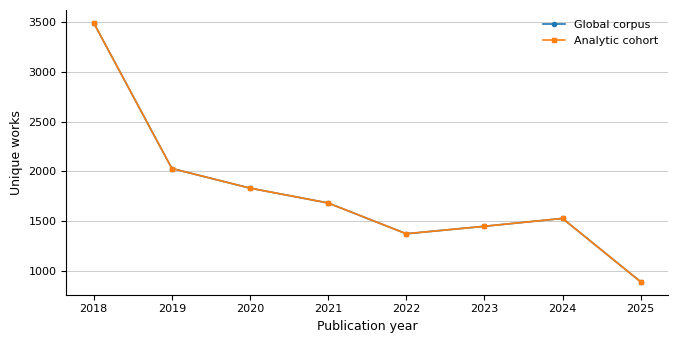

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/figures/Fig16B_annual_active_cohort_authors_CORRECTED.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/figures/Fig16B_annual_active_cohort_authors_CORRECTED.png


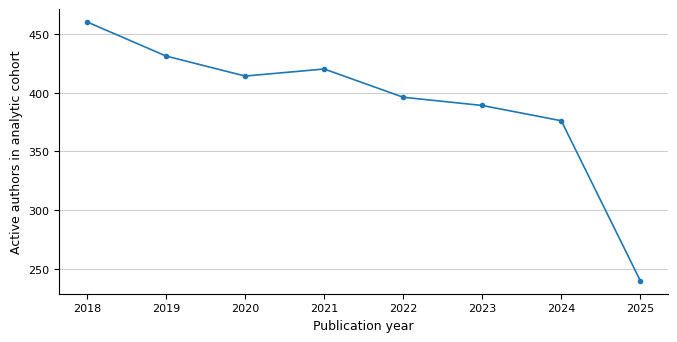

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/figures/Fig16C_year_over_year_coverage_ratios_CORRECTED.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/16_2025_coverage_temporal_audit_v2_corrected/figures/Fig16C_year_over_year_coverage_ratios_CORRECTED.png


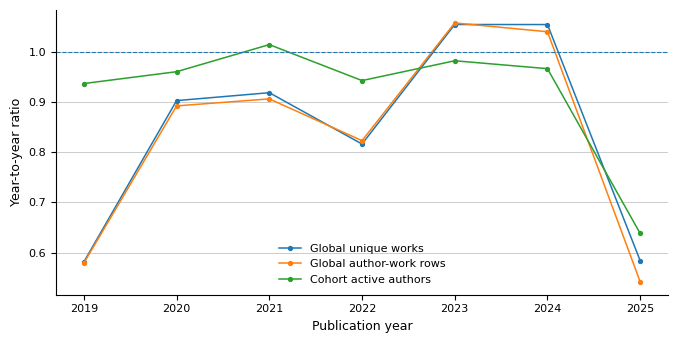


PART 18.16 v2 — SUMMARY
PARTE 18.16 v2 — 2025 COVERAGE / TEMPORAL COMPARABILITY AUDIT — CORRECTED

Panel:
/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv

Publications:
/content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx

N analytic cohort:
500

Panel-to-publication linkage:
99.80%

2025/2024 ratios
----------------
Global unique works:
0.5840

Global author-work rows:
0.5421

Global active authors:
0.6383

Cohort unique works:
0.5840

Cohort author-work rows:
0.5421

Cohort active authors:
0.6383

Historically anomalous metrics:
4

Decision status:
2025_LIKELY_INCOMPLETE_OR_NOT_TEMPORALLY_COMPARABLE

Primary endpoint remains:
future_works_2023_2024

Can 2025 override primary conclusion?
NO

Interpretation:
2025 shows a broad corpus-level and cohort-level contraction relative to 2024 and to historical year-to-year variation. The audit does

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.16 v2 — AUDITORIA DE COMPLETUDE/COMPARABILIDADE DE 2025 — CORRIGIDA
=============================================================================

Correção principal
------------------
A versão anterior testava os IDs OpenAlex como se fossem strings exatamente no
formato "A123..." / "W123...". Nos arquivos reais, os IDs podem aparecer como
URLs completas (por exemplo, https://openalex.org/A... e https://openalex.org/W...).
Isso fez a auditoria anterior zerar artificialmente todas as contagens anuais.

Esta versão:
1) extrai A\\d+ e W\\d+ de QUALQUER posição da string;
2) cruza os IDs com o painel analítico de 500 pesquisadores;
3) reconstrói 2023, 2024 e 2025;
4) compara as reconstruções com as colunas anuais já existentes no painel;
5) ABORTA se a reconstrução anual resultar artificialmente em zero;
6) substitui integralmente as Tables 63–71;
7) mostra tudo no Colab e salva CSVs/figuras no Drive;
8) não usa 2025 para reabrir o endpoint primário de 2023–2024.

Execução
--------
%run /content/Parte_18_16_v2_Auditoria_Completude_2025_CORRIGIDA.py
"""

from __future__ import annotations

import re
import sys
import json
import importlib
from pathlib import Path

# ======================================================================================
# 0. GOOGLE DRIVE — sem mensagem enganosa se já estiver montado
# ======================================================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

if not DRIVE_ROOT.exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        raise RuntimeError(f"Não foi possível montar o Google Drive: {e}")
else:
    print("[drive] Google Drive já está montado em /content/drive")

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("openpyxl")
ensure("scipy")
ensure("matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, binomtest

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 2. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")

PANEL = (
    ROOT
    / "runs/temporal_productivity_20260929"
    / "13_feature_redundancy_clean_freeze"
    / "artifacts/panel_model_ready_clean_deduplicated.csv"
)

PUBLICATIONS = (
    ROOT
    / "runs/run_20260625_200032"
    / "input/producoes_final.xlsx"
)

OUT = (
    ROOT
    / "runs/temporal_productivity_20260929"
    / "16_2025_coverage_temporal_audit_v2_corrected"
)

TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
NOTES = OUT / "notes"

for d in [OUT, TAB, FIG, ART, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

for p in [PANEL, PUBLICATIONS]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

# ======================================================================================
# 3. HELPERS
# ======================================================================================

def show_df(title, df, max_rows=60):
    print("\n" + "=" * 118)
    print(title)
    print("=" * 118)
    if df is None or len(df) == 0:
        print("[vazio]")
    else:
        if len(df) <= max_rows:
            print(df.to_string(index=False))
        else:
            print(df.head(max_rows).to_string(index=False))
            print(f"... ({len(df):,} rows total)")
        if display is not None:
            display(df.head(max_rows))

def save_table(df, name):
    path = TAB / name
    df.to_csv(path, index=False)
    print("[table]", path)
    return path

def extract_openalex_id(series, prefix):
    s = series.astype("string")
    return s.str.upper().str.extract(
        rf"(?<![A-Z0-9])({prefix}\d+)(?!\d)",
        expand=False
    )

def raw_exact_share(series, prefix):
    s = series.dropna().astype(str).str.strip().str.upper()
    if len(s) == 0:
        return np.nan
    return float(s.str.fullmatch(rf"{prefix}\d+").mean())

def extractable_share(series, prefix):
    if len(series) == 0:
        return np.nan
    return float(extract_openalex_id(series, prefix).notna().mean())

def safe_ratio(a, b):
    if pd.isna(a) or pd.isna(b) or float(b) == 0:
        return np.nan
    return float(a) / float(b)

def modified_z(value, ref):
    arr = np.asarray(ref, dtype=float)
    arr = arr[np.isfinite(arr)]
    if not np.isfinite(value) or len(arr) < 3:
        return np.nan
    med = np.median(arr)
    mad = np.median(np.abs(arr - med))
    if mad == 0:
        return np.nan
    return float(0.67448975 * (value - med) / mad)

def exact_mcnemar_p(b, c):
    n = int(b + c)
    if n == 0:
        return np.nan
    return float(binomtest(int(b), n=n, p=0.5, alternative="two-sided").pvalue)

def paired_wilcoxon_p(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    d = y - x
    if len(d) == 0 or np.allclose(d, 0):
        return np.nan
    try:
        return float(wilcoxon(y, x, alternative="two-sided", zero_method="wilcox").pvalue)
    except Exception:
        return np.nan

def pct_nonempty(s):
    s = s.astype("string")
    ok = s.notna() & s.str.strip().ne("") & s.str.lower().ne("nan")
    return float(ok.mean() * 100) if len(s) else np.nan

def save_figure(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

# ======================================================================================
# 4. CARREGAMENTO
# ======================================================================================

print("\n" + "=" * 118)
print("PARTE 18.16 v2 — AUDITORIA DE COMPLETUDE/COMPARABILIDADE DE 2025 — CORRIGIDA")
print("=" * 118)
print("[panel]       ", PANEL)
print("[publications]", PUBLICATIONS)
print("[output]      ", OUT)

panel = pd.read_csv(PANEL)
pub = pd.read_excel(PUBLICATIONS)

print("\nPanel shape:", panel.shape)
print("Publications shape:", pub.shape)

required_panel = ["author_key"]
required_pub = ["autor_id", "id_openalex", "ano", "doi", "titulo", "tipo"]

missing_panel = [c for c in required_panel if c not in panel.columns]
missing_pub = [c for c in required_pub if c not in pub.columns]

if missing_panel:
    raise KeyError(f"Colunas ausentes no painel: {missing_panel}")
if missing_pub:
    raise KeyError(f"Colunas ausentes em producoes_final.xlsx: {missing_pub}")

# ======================================================================================
# 5. EXTRAÇÃO ROBUSTA DOS IDENTIFICADORES
# ======================================================================================

panel_author = extract_openalex_id(panel["author_key"], "A")
pub_author = extract_openalex_id(pub["autor_id"], "A")
pub_work = extract_openalex_id(pub["id_openalex"], "W")

audit63 = pd.DataFrame([{
    "panel_author_col": "author_key",
    "pub_author_col": "autor_id",
    "pub_work_col": "id_openalex",
    "pub_year_col": "ano",
    "doi_col": "doi",
    "title_col": "titulo",
    "type_col": "tipo",
    "panel_author_raw_exact_share": raw_exact_share(panel["author_key"], "A"),
    "pub_author_raw_exact_share": raw_exact_share(pub["autor_id"], "A"),
    "pub_work_raw_exact_share": raw_exact_share(pub["id_openalex"], "W"),
    "panel_author_extractable_share": extractable_share(panel["author_key"], "A"),
    "pub_author_extractable_share": extractable_share(pub["autor_id"], "A"),
    "pub_work_extractable_share": extractable_share(pub["id_openalex"], "W"),
    "panel_unique_author_A_ids": int(panel_author.nunique(dropna=True)),
    "pub_unique_author_A_ids": int(pub_author.nunique(dropna=True)),
    "pub_unique_work_W_ids": int(pub_work.nunique(dropna=True)),
}])

show_df("TABLE 63 — INPUT IDENTIFIER AUDIT — CORRECTED", audit63)
save_table(audit63, "Table_63_input_identifier_audit_CORRECTED.csv")

if panel_author.notna().mean() < 0.90:
    raise RuntimeError("Falha ao extrair OpenAlex A-IDs do painel.")
if pub_author.notna().mean() < 0.90:
    raise RuntimeError("Falha ao extrair OpenAlex A-IDs de producoes_final['autor_id'].")
if pub_work.notna().mean() < 0.90:
    raise RuntimeError("Falha ao extrair OpenAlex W-IDs de producoes_final['id_openalex'].")

# ======================================================================================
# 6. LONG TABLE AUTHOR–WORK
# ======================================================================================

long = pd.DataFrame({
    "author_key": pub_author,
    "work_key": pub_work,
    "year": pd.to_numeric(pub["ano"], errors="coerce"),
    "doi": pub["doi"].astype("string"),
    "title": pub["titulo"].astype("string"),
    "pub_type": pub["tipo"].astype("string"),
})

long = long[
    long["author_key"].notna()
    & long["work_key"].notna()
    & long["year"].between(1900, 2030)
].copy()

long["year"] = long["year"].astype(int)
long = long.drop_duplicates(["author_key", "work_key"]).reset_index(drop=True)

panel_ids = set(panel_author.dropna().astype(str))
cohort = long[long["author_key"].isin(panel_ids)].copy()

if len(cohort) == 0:
    raise RuntimeError("O cruzamento entre painel e publicações resultou em zero linhas.")

linkage = pd.DataFrame([{
    "panel_n": len(panel),
    "panel_unique_author_ids": len(panel_ids),
    "publication_unique_author_ids": int(long["author_key"].nunique()),
    "panel_authors_found_in_publications": int(len(panel_ids & set(long["author_key"].unique()))),
    "panel_author_linkage_pct": 100 * len(panel_ids & set(long["author_key"].unique())) / max(1, len(panel_ids)),
    "author_work_rows_all_years_global_corpus": int(len(long)),
    "author_work_rows_all_years_analytic_cohort": int(len(cohort)),
    "unique_works_all_years_global_corpus": int(long["work_key"].nunique()),
    "unique_works_all_years_analytic_cohort": int(cohort["work_key"].nunique()),
    "min_year": int(long["year"].min()),
    "max_year": int(long["year"].max()),
}])

show_df("TABLE 63B — PANEL / PUBLICATION LINKAGE AUDIT", linkage)
save_table(linkage, "Table_63B_panel_publication_linkage_audit.csv")

# ======================================================================================
# 7. COBERTURA ANUAL
# ======================================================================================

def annual_scope_stats(df, years):
    rows = []
    for year in years:
        x = df[df["year"] == year].copy()
        work_level = x.drop_duplicates("work_key").copy()
        rows.append({
            "year": int(year),
            "author_work_rows": int(len(x)),
            "unique_works": int(x["work_key"].nunique()),
            "active_authors": int(x["author_key"].nunique()),
            "doi_pct": pct_nonempty(work_level["doi"]) if len(work_level) else np.nan,
            "title_pct": pct_nonempty(work_level["title"]) if len(work_level) else np.nan,
        })
    return pd.DataFrame(rows)

years = list(range(2018, 2026))

global_annual = annual_scope_stats(long, years).add_prefix("global_")
global_annual = global_annual.rename(columns={"global_year": "year"})
cohort_annual = annual_scope_stats(cohort, years).add_prefix("cohort_")
cohort_annual = cohort_annual.rename(columns={"cohort_year": "year"})

annual = global_annual.merge(cohort_annual, on="year", how="outer")
annual["cohort_active_pct"] = 100 * annual["cohort_active_authors"] / max(1, len(panel_ids))

ratio_columns = [
    "global_author_work_rows",
    "global_unique_works",
    "global_active_authors",
    "cohort_author_work_rows",
    "cohort_unique_works",
    "cohort_active_authors",
]

for c in ratio_columns:
    annual[f"{c}_yoy_ratio"] = annual[c] / annual[c].shift(1).replace(0, np.nan)

show_df("TABLE 64 — ANNUAL COVERAGE: GLOBAL CORPUS VS ANALYTIC COHORT — CORRECTED", annual)
save_table(annual, "Table_64_annual_global_vs_cohort_coverage_CORRECTED.csv")

check = annual.loc[
    annual["year"].between(2023, 2025),
    ["global_author_work_rows", "global_unique_works", "cohort_author_work_rows"]
].to_numpy(dtype=float)

if np.nansum(check) == 0:
    raise RuntimeError("AUDIT STOP: 2023–2025 continua zerado; revisar parsing.")

# ======================================================================================
# 8. RECONSTRUÇÃO ANUAL + CROSS-CHECK
# ======================================================================================

author_base = pd.DataFrame({"author_key": sorted(panel_ids)})
panel2 = panel.copy()
panel2["author_key_extracted"] = panel_author

annual_outcomes = author_base.copy()

for yr in [2023, 2024, 2025]:
    s = (
        cohort[cohort["year"] == yr]
        .groupby("author_key")["work_key"]
        .nunique()
        .rename(f"reconstructed_future_works_{yr}")
        .reset_index()
    )
    annual_outcomes = annual_outcomes.merge(s, on="author_key", how="left")
    annual_outcomes[f"reconstructed_future_works_{yr}"] = (
        annual_outcomes[f"reconstructed_future_works_{yr}"].fillna(0).astype(int)
    )

check_cols = [
    c for c in [
        "future_works_2023",
        "future_works_2024",
        "future_works_2025",
        "future_works_2023_2024",
        "future_works_2023_2025",
    ] if c in panel2.columns
]

panel_check = panel2[["author_key_extracted"] + check_cols].copy()
panel_check = panel_check.rename(columns={"author_key_extracted": "author_key"})
audit_out = annual_outcomes.merge(panel_check, on="author_key", how="left")

recon_rows = []

for yr in [2023, 2024, 2025]:
    existing = f"future_works_{yr}"
    recon = f"reconstructed_future_works_{yr}"
    if existing in audit_out.columns:
        diff = (
            pd.to_numeric(audit_out[existing], errors="coerce").fillna(0)
            - audit_out[recon]
        ).abs()
        recon_rows.append({
            "comparison": f"{existing}_vs_reconstructed",
            "n": len(audit_out),
            "n_discrepant": int((diff > 0).sum()),
            "max_abs_difference": float(diff.max()),
        })

if "future_works_2023_2024" in audit_out.columns:
    rec = audit_out["reconstructed_future_works_2023"] + audit_out["reconstructed_future_works_2024"]
    diff = (pd.to_numeric(audit_out["future_works_2023_2024"], errors="coerce").fillna(0) - rec).abs()
    recon_rows.append({
        "comparison": "future_works_2023_2024_vs_reconstructed_annual_sum",
        "n": len(audit_out),
        "n_discrepant": int((diff > 0).sum()),
        "max_abs_difference": float(diff.max()),
    })

if "future_works_2023_2025" in audit_out.columns:
    rec = (
        audit_out["reconstructed_future_works_2023"]
        + audit_out["reconstructed_future_works_2024"]
        + audit_out["reconstructed_future_works_2025"]
    )
    diff = (pd.to_numeric(audit_out["future_works_2023_2025"], errors="coerce").fillna(0) - rec).abs()
    recon_rows.append({
        "comparison": "future_works_2023_2025_vs_reconstructed_annual_sum",
        "n": len(audit_out),
        "n_discrepant": int((diff > 0).sum()),
        "max_abs_difference": float(diff.max()),
    })

recon = pd.DataFrame(recon_rows)
show_df("TABLE 64B — ANNUAL OUTCOME RECONSTRUCTION CROSS-CHECK", recon)
save_table(recon, "Table_64B_annual_outcome_reconstruction_crosscheck.csv")

if len(recon) and int(recon["n_discrepant"].max()) > 0:
    raise RuntimeError("AUDIT STOP: reconstrução anual diverge das colunas já congeladas no painel.")

annual_outcomes.to_csv(ART / "annual_outcomes_2023_2025_reconstructed.csv", index=False)

# ======================================================================================
# 9. TABLE 65
# ======================================================================================

a24 = annual.loc[annual["year"] == 2024].iloc[0]
a25 = annual.loc[annual["year"] == 2025].iloc[0]

ratios65 = pd.DataFrame([
    {
        "measure": metric,
        "value_2024": float(a24[metric]),
        "value_2025": float(a25[metric]),
        "ratio_2025_to_2024": safe_ratio(a25[metric], a24[metric]),
    }
    for metric in ratio_columns
])

show_df("TABLE 65 — 2025/2024 COVERAGE RATIOS — CORRECTED", ratios65)
save_table(ratios65, "Table_65_2025_vs_2024_coverage_ratios_CORRECTED.csv")

# ======================================================================================
# 10. TABLE 66
# ======================================================================================

rows66 = []

for metric in ratio_columns:
    ratio_col = f"{metric}_yoy_ratio"
    ref = annual.loc[annual["year"].between(2019, 2024), ratio_col].dropna().astype(float).to_numpy()
    val = annual.loc[annual["year"] == 2025, ratio_col].iloc[0]

    rows66.append({
        "metric": metric,
        "ratio_2025_vs_2024": float(val) if pd.notna(val) else np.nan,
        "reference_years": "2019-2024",
        "reference_ratio_median": float(np.median(ref)) if len(ref) else np.nan,
        "reference_ratio_min": float(np.min(ref)) if len(ref) else np.nan,
        "reference_ratio_max": float(np.max(ref)) if len(ref) else np.nan,
        "modified_z_2025": modified_z(float(val), ref) if pd.notna(val) else np.nan,
        "below_reference_min": bool(float(val) < np.min(ref)) if (pd.notna(val) and len(ref)) else False,
    })

anomaly66 = pd.DataFrame(rows66)
show_df("TABLE 66 — 2025 ANOMALY RELATIVE TO HISTORICAL YEAR-TO-YEAR VARIATION — CORRECTED", anomaly66)
save_table(anomaly66, "Table_66_2025_historical_anomaly_audit_CORRECTED.csv")

# ======================================================================================
# 11. TABLE 67
# ======================================================================================

activity = annual_outcomes.copy()

for yr in [2023, 2024, 2025]:
    activity[f"active_{yr}"] = (activity[f"reconstructed_future_works_{yr}"] > 0).astype(int)

rows67 = []

for y1, y2 in [(2023, 2024), (2024, 2025)]:
    a = activity[f"active_{y1}"].to_numpy()
    b = activity[f"active_{y2}"].to_numpy()

    aa = int(((a == 1) & (b == 1)).sum())
    ai = int(((a == 1) & (b == 0)).sum())
    ia = int(((a == 0) & (b == 1)).sum())
    ii = int(((a == 0) & (b == 0)).sum())

    rows67.append({
        "transition": f"{y1}->{y2}",
        "active_to_active": aa,
        "active_to_inactive": ai,
        "inactive_to_active": ia,
        "inactive_to_inactive": ii,
        "active_retention_pct": 100 * aa / max(1, aa + ai),
        "reactivation_pct_among_previous_inactive": 100 * ia / max(1, ia + ii),
        "activity_jaccard": aa / max(1, aa + ai + ia),
        "exact_mcnemar_p": exact_mcnemar_p(ai, ia),
    })

trans67 = pd.DataFrame(rows67)
show_df("TABLE 67 — PAIRED AUTHOR-ACTIVITY TRANSITIONS — CORRECTED", trans67)
save_table(trans67, "Table_67_author_activity_transitions_CORRECTED.csv")

# ======================================================================================
# 12. TABLE 68
# ======================================================================================

rows68 = []

for y1, y2 in [(2023, 2024), (2024, 2025)]:
    x = annual_outcomes[f"reconstructed_future_works_{y1}"].to_numpy(dtype=float)
    y = annual_outcomes[f"reconstructed_future_works_{y2}"].to_numpy(dtype=float)
    d = y - x

    rows68.append({
        "transition": f"{y1}->{y2}",
        "n": len(x),
        "mean_earlier": float(np.mean(x)),
        "mean_later": float(np.mean(y)),
        "median_earlier": float(np.median(x)),
        "median_later": float(np.median(y)),
        "mean_change_later_minus_earlier": float(np.mean(d)),
        "median_change_later_minus_earlier": float(np.median(d)),
        "authors_decreased": int((d < 0).sum()),
        "authors_unchanged": int((d == 0).sum()),
        "authors_increased": int((d > 0).sum()),
        "wilcoxon_p": paired_wilcoxon_p(x, y),
    })

change68 = pd.DataFrame(rows68)
show_df("TABLE 68 — PAIRED ANNUAL PRODUCTIVITY CHANGE — CORRECTED", change68)
save_table(change68, "Table_68_paired_annual_productivity_change_CORRECTED.csv")

# ======================================================================================
# 13. TABLE 69
# ======================================================================================

rows69 = []

for yr in [2023, 2024, 2025]:
    for scope_name, df0 in [("global_corpus", long), ("analytic_cohort", cohort)]:
        x = df0[df0["year"] == yr].copy()
        w = x.drop_duplicates("work_key").copy()

        rows69.append({
            "year": yr,
            "scope": scope_name,
            "author_work_rows": int(len(x)),
            "unique_works": int(x["work_key"].nunique()),
            "doi_pct_unique_works": pct_nonempty(w["doi"]) if len(w) else np.nan,
            "title_pct_unique_works": pct_nonempty(w["title"]) if len(w) else np.nan,
        })

meta69 = pd.DataFrame(rows69)
show_df("TABLE 69 — METADATA COMPLETENESS BY YEAR — CORRECTED", meta69)
save_table(meta69, "Table_69_metadata_completeness_by_year_CORRECTED.csv")

# ======================================================================================
# 14. TABLE 70
# ======================================================================================

rows70 = []

for yr in [2023, 2024, 2025]:
    for scope_name, df0 in [("global_corpus", long), ("analytic_cohort", cohort)]:
        x = df0[df0["year"] == yr].drop_duplicates("work_key").copy()
        if len(x) == 0:
            continue

        counts = x["pub_type"].fillna("MISSING").astype(str).str.strip().value_counts(dropna=False)

        for typ, n in counts.items():
            rows70.append({
                "year": yr,
                "scope": scope_name,
                "publication_type": typ,
                "unique_works": int(n),
                "share_pct": 100 * int(n) / len(x),
            })

types70 = pd.DataFrame(rows70)
if len(types70):
    types70 = types70.sort_values(
        ["year", "scope", "unique_works"],
        ascending=[True, True, False]
    )

show_df("TABLE 70 — PUBLICATION-TYPE COMPOSITION 2023–2025 — CORRECTED", types70, max_rows=100)
save_table(types70, "Table_70_publication_type_composition_2023_2025_CORRECTED.csv")

# ======================================================================================
# 15. TABLE 71 — DECISION GATE
# ======================================================================================

ratio_map = dict(zip(ratios65["measure"], ratios65["ratio_2025_to_2024"]))

global_works_ratio = ratio_map.get("global_unique_works", np.nan)
global_rows_ratio = ratio_map.get("global_author_work_rows", np.nan)
global_active_ratio = ratio_map.get("global_active_authors", np.nan)
cohort_rows_ratio = ratio_map.get("cohort_author_work_rows", np.nan)
cohort_works_ratio = ratio_map.get("cohort_unique_works", np.nan)
cohort_active_ratio = ratio_map.get("cohort_active_authors", np.nan)

anom = anomaly66.set_index("metric")
flags = []

for metric in ratio_columns:
    row = anom.loc[metric]
    flag = bool(row["below_reference_min"])
    mz = row["modified_z_2025"]
    if pd.notna(mz) and float(mz) <= -3.0:
        flag = True
    flags.append(flag)

n_anomalous = int(sum(flags))

if (
    np.isfinite(global_works_ratio)
    and np.isfinite(global_rows_ratio)
    and np.isfinite(cohort_active_ratio)
    and global_works_ratio < 0.75
    and global_rows_ratio < 0.75
    and cohort_active_ratio < 0.80
    and n_anomalous >= 2
):
    status = "2025_LIKELY_INCOMPLETE_OR_NOT_TEMPORALLY_COMPARABLE"
    manuscript_role = (
        "2025 shows a broad corpus-level and cohort-level contraction relative to 2024 "
        "and to historical year-to-year variation. The audit does not identify the "
        "data-collection mechanism, so 2025 should not be treated as a directly comparable "
        "prospective endpoint. Keep 2023–2024 as the primary outcome horizon; use 2025 only "
        "as a sensitivity/post-hoc observation."
    )
elif (
    np.isfinite(global_works_ratio)
    and np.isfinite(global_rows_ratio)
    and global_works_ratio >= 0.85
    and global_rows_ratio >= 0.85
):
    status = "NO_STRONG_GLOBAL_COVERAGE_DEFICIT_DETECTED"
    manuscript_role = (
        "The coverage audit does not show a strong global 2025 deficit. Nevertheless, "
        "2023–2024 remains the pre-specified primary prospective endpoint and 2025 remains secondary."
    )
else:
    status = "2025_REDUCED_COVERAGE_OR_NONCOMPARABILITY_UNCERTAIN_CAUSE"
    manuscript_role = (
        "2025 differs materially from 2024, but the audit does not support a unique explanation. "
        "The pre-specified 2023–2024 endpoint remains primary; 2025 should be reported only as sensitivity."
    )

decision71 = pd.DataFrame([{
    "status": status,
    "global_unique_works_ratio_2025_2024": global_works_ratio,
    "global_author_work_rows_ratio_2025_2024": global_rows_ratio,
    "global_active_authors_ratio_2025_2024": global_active_ratio,
    "cohort_unique_works_ratio_2025_2024": cohort_works_ratio,
    "cohort_author_work_rows_ratio_2025_2024": cohort_rows_ratio,
    "cohort_active_authors_ratio_2025_2024": cohort_active_ratio,
    "historically_anomalous_metric_count": n_anomalous,
    "primary_endpoint_remains_2023_2024": True,
    "2025_can_override_primary_conclusion": False,
    "manuscript_role": manuscript_role,
}])

show_df("TABLE 71 — 2025 COVERAGE / COMPARABILITY DECISION GATE — CORRECTED", decision71)
save_table(decision71, "Table_71_2025_coverage_decision_gate_CORRECTED.csv")

# ======================================================================================
# 16. FIGURAS
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(6.85, 3.5))
ax.plot(annual["year"], annual["global_unique_works"], marker="o", markersize=3, linewidth=1.2, label="Global corpus")
ax.plot(annual["year"], annual["cohort_unique_works"], marker="s", markersize=3, linewidth=1.2, label="Analytic cohort")
ax.set_xlabel("Publication year")
ax.set_ylabel("Unique works")
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.45)
fig.tight_layout()
save_figure(fig, "Fig16A_annual_unique_works_global_vs_cohort_CORRECTED")
if display is not None:
    display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.85, 3.5))
ax.plot(annual["year"], annual["cohort_active_authors"], marker="o", markersize=3, linewidth=1.2)
ax.set_xlabel("Publication year")
ax.set_ylabel("Active authors in analytic cohort")
ax.grid(axis="y", linewidth=0.45)
fig.tight_layout()
save_figure(fig, "Fig16B_annual_active_cohort_authors_CORRECTED")
if display is not None:
    display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.85, 3.5))
for c, lab in [
    ("global_unique_works_yoy_ratio", "Global unique works"),
    ("global_author_work_rows_yoy_ratio", "Global author-work rows"),
    ("cohort_active_authors_yoy_ratio", "Cohort active authors"),
]:
    ax.plot(annual["year"], annual[c], marker="o", markersize=2.8, linewidth=1.1, label=lab)
ax.axhline(1.0, linestyle="--", linewidth=0.8)
ax.set_xlabel("Publication year")
ax.set_ylabel("Year-to-year ratio")
ax.legend(frameon=False)
ax.grid(axis="y", linewidth=0.45)
fig.tight_layout()
save_figure(fig, "Fig16C_year_over_year_coverage_ratios_CORRECTED")
if display is not None:
    display(fig)
plt.close(fig)

# ======================================================================================
# 17. SUMMARY
# ======================================================================================

summary = f"""
PARTE 18.16 v2 — 2025 COVERAGE / TEMPORAL COMPARABILITY AUDIT — CORRECTED
=========================================================================

Panel:
{PANEL}

Publications:
{PUBLICATIONS}

N analytic cohort:
{len(panel_ids)}

Panel-to-publication linkage:
{linkage.iloc[0]['panel_author_linkage_pct']:.2f}%

2025/2024 ratios
----------------
Global unique works:
{global_works_ratio:.4f}

Global author-work rows:
{global_rows_ratio:.4f}

Global active authors:
{global_active_ratio:.4f}

Cohort unique works:
{cohort_works_ratio:.4f}

Cohort author-work rows:
{cohort_rows_ratio:.4f}

Cohort active authors:
{cohort_active_ratio:.4f}

Historically anomalous metrics:
{n_anomalous}

Decision status:
{status}

Primary endpoint remains:
future_works_2023_2024

Can 2025 override primary conclusion?
NO

Interpretation:
{manuscript_role}
""".strip()

summary_path = NOTES / "Part_18_16_v2_2025_coverage_summary_CORRECTED.txt"
summary_path.write_text(summary, encoding="utf-8")

print("\n" + "=" * 118)
print("PART 18.16 v2 — SUMMARY")
print("=" * 118)
print(summary)
print("[summary]", summary_path)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 63 — INPUT IDENTIFIER AUDIT — CORRECTED")
print("2) TABLE 63B — PANEL / PUBLICATION LINKAGE AUDIT")
print("3) TABLE 64 — ANNUAL COVERAGE — CORRECTED")
print("4) TABLE 64B — ANNUAL OUTCOME RECONSTRUCTION CROSS-CHECK")
print("5) TABLE 65 — 2025/2024 COVERAGE RATIOS — CORRECTED")
print("6) TABLE 66 — 2025 HISTORICAL ANOMALY — CORRECTED")
print("7) TABLE 67 — PAIRED AUTHOR-ACTIVITY TRANSITIONS — CORRECTED")
print("8) TABLE 68 — PAIRED ANNUAL PRODUCTIVITY CHANGE — CORRECTED")
print("9) TABLE 69 — METADATA COMPLETENESS — CORRECTED")
print("10) TABLE 71 — DECISION GATE — CORRECTED")
print("11) PART 18.16 v2 — SUMMARY")
print("\n[output]", OUT)
print("CONCLUÍDO.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

PARTE 18.17 — ARTICLE-ONLY OUTCOME / HISTORY / NETWORK ROBUSTNESS
[panel]         /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/13_feature_redundancy_clean_freeze/artifacts/panel_model_ready_clean_deduplicated.csv
[publications]  /content/drive/MyDrive/tese_doutoral/runs/run_20260625_200032/input/producoes_final.xlsx
[primary T57]   /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/tables/Table_57_clean_final_incremental_graph_decision.csv
[output]        /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness

Panel shape: (500, 47)
Publications shape: (38138, 9)

TABLE 72 — ARTICLE-ONLY INPUT AUDIT
 panel_n  panel_unique_authors  publication_rows_raw  article_author_work_rows_2018_2024  article_unique_works_2018_2024  articl

,panel_n,panel_unique_authors,publication_rows_raw,article_author_work_rows_2018_2024,article_unique_works_2018_2024,article_unique_authors_2018_2024,feature_period,outcome_period,2025_used_in_modeling
0,500,500,38138,13307,11494,487,2018-2022,2023-2024,False



TABLE 73 — ARTICLE-ONLY COHORT AND NETWORK SUMMARY
 n_authors  authors_with_past_articles  authors_with_future_articles  future_article_zero_n  future_article_zero_pct  future_articles_mean  future_articles_median  future_articles_p95  future_articles_max  article_graph_nodes  article_graph_edges  article_graph_isolates  article_graph_components  article_graph_gcc_n
       500                         483                           431                     69                     13.8                 5.746                     4.0                17.05                 54.0                  500                  721                     156                       171                  310


,n_authors,authors_with_past_articles,authors_with_future_articles,future_article_zero_n,future_article_zero_pct,future_articles_mean,future_articles_median,future_articles_p95,future_articles_max,article_graph_nodes,article_graph_edges,article_graph_isolates,article_graph_components,article_graph_gcc_n
0,500,483,431,69,13.8,5.746,4.0,17.05,54.0,500,721,156,171,310



TABLE 74 — ARTICLE-ONLY FEATURE AUDIT
          block                               feature   n  missing_n  n_unique       min     median       mean        max
article_history               past_articles_2018_2022 500          0        67  0.000000  17.000000  20.868000  98.000000
article_history   past_article_active_years_2018_2022 500          0         6  0.000000   5.000000   4.118000   5.000000
article_history             recent_articles_2021_2022 500          0        24  0.000000   5.000000   5.516000  36.000000
article_history       past_article_productivity_slope 500          0       459 -8.900000  -0.700000  -1.156600   2.800000
  article_graph              article_degree_2018_2022 500          0        17  0.000000   2.000000   2.884000  16.000000
  article_graph            article_strength_2018_2022 500          0        45  0.000000   3.000000   7.280000 131.000000
  article_graph    article_avg_tie_strength_2018_2022 500          0        78  0.000000   1.166667   1.578

...


TABLE 78 — CROSS-OUTCOME INCREMENTAL GRAPH ROBUSTNESS
                outcome_definition  family  delta_R2_observed  delta_R2_ci95_low  delta_R2_ci95_high  delta_MAE_observed  delta_MAE_ci95_low  delta_MAE_ci95_high  clear_positive_R2  clear_positive_MAE
       all_works_2023_2024_primary poisson          -0.035024          -0.176587            0.147710           -0.144023           -0.300867             0.000384              False               False
       all_works_2023_2024_primary     hgb          -0.036298          -0.107036            0.051993           -0.120104           -0.290521             0.059027              False               False
article_only_2023_2024_sensitivity poisson          -0.028087          -0.068702            0.020242           -0.045014           -0.128556             0.046794              False               False
article_only_2023_2024_sensitivity     hgb          -0.017848          -0.062043            0.024101           -0.064582           -0.198679 

,outcome_definition,family,delta_R2_observed,delta_R2_ci95_low,delta_R2_ci95_high,delta_MAE_observed,delta_MAE_ci95_low,delta_MAE_ci95_high,clear_positive_R2,clear_positive_MAE
0,all_works_2023_2024_primary,poisson,-0.035024,-0.176587,0.147710,-0.144023,-0.300867,0.000384,False,False
1,all_works_2023_2024_primary,hgb,-0.036298,-0.107036,0.051993,-0.120104,-0.290521,0.059027,False,False
2,article_only_2023_2024_sensitivity,poisson,-0.028087,-0.068702,0.020242,-0.045014,-0.128556,0.046794,False,False
3,article_only_2023_2024_sensitivity,hgb,-0.017848,-0.062043,0.024101,-0.064582,-0.198679,0.066956,False,False



TABLE 79 — ARTICLE-ONLY ROBUSTNESS DECISION GATE
                                                   status  2025_excluded primary_endpoint_preserved      sensitivity_endpoint article_only_graph_period article_only_history_period article_only_outcome_period                                                                                                                                                                                                                                                                                                          interpretation
PRIMARY_NULL_CONCLUSION_ROBUST_TO_ARTICLE_ONLY_DEFINITION           True     future_works_2023_2024 future_articles_2023_2024                 2018-2022                   2018-2022                   2023-2024 Restricting the forecast target, publication-history predictors, and collaboration graph to article-type records does not yield clear paired evidence that graph features improve prospective prediction beyond article-public

,status,2025_excluded,primary_endpoint_preserved,sensitivity_endpoint,article_only_graph_period,article_only_history_period,article_only_outcome_period,interpretation
0,PRIMARY_NULL_CONCLUSION_ROBUST_TO_ARTICLE_ONLY...,True,future_works_2023_2024,future_articles_2023_2024,2018-2022,2018-2022,2023-2024,"Restricting the forecast target, publication-h..."


[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness/figures/Fig17A_article_only_outcome_distribution.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness/figures/Fig17A_article_only_outcome_distribution.png


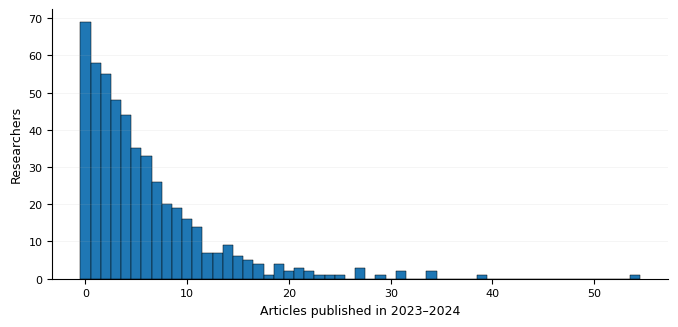

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness/figures/Fig17B_cross_outcome_delta_R2.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness/figures/Fig17B_cross_outcome_delta_R2.png


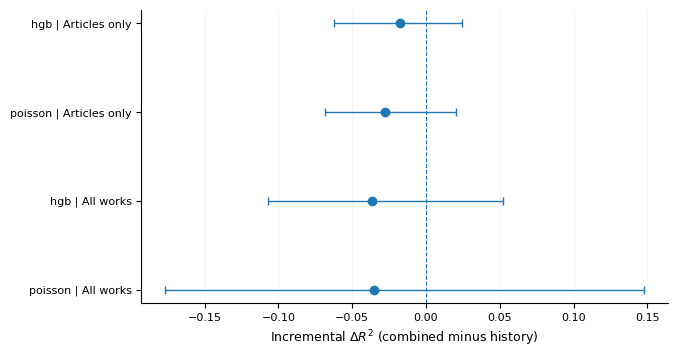

[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness/figures/Fig17C_cross_outcome_delta_MAE.eps
[figure] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/17_article_only_outcome_robustness/figures/Fig17C_cross_outcome_delta_MAE.png


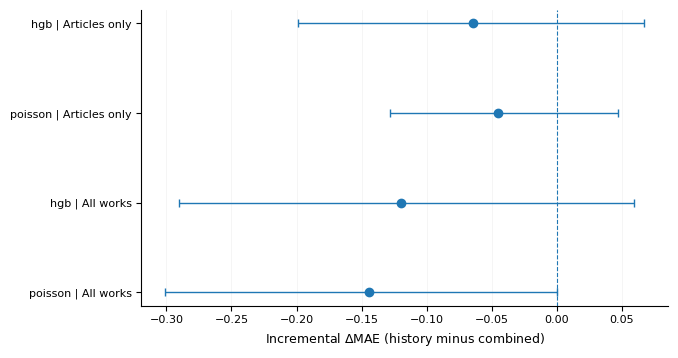


PART 18.17 — SUMMARY
PARTE 18.17 — ARTICLE-ONLY ROBUSTNESS

Primary endpoint retained:
future_works_2023_2024

Sensitivity endpoint:
future_articles_2023_2024

Feature period:
2018-2022

Outcome period:
2023-2024

2025 used:
NO

Article-only history block:
['past_articles_2018_2022', 'past_article_active_years_2018_2022', 'recent_articles_2021_2022', 'past_article_productivity_slope']

Article-only graph block:
['article_degree_2018_2022', 'article_strength_2018_2022', 'article_avg_tie_strength_2018_2022', 'article_weighted_clustering_2018_2022', 'article_pagerank_2018_2022', 'article_betweenness_2018_2022', 'article_core_number_2018_2022', 'article_avg_neighbor_degree_2018_2022', 'article_component_size_2018_2022', 'article_is_isolate_2018_2022']

Decision:
PRIMARY_NULL_CONCLUSION_ROBUST_TO_ARTICLE_ONLY_DEFINITION

Interpretation:
Restricting the forecast target, publication-history predictors, and collaboration graph to article-type records does not yield clear paired evidence that 

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.17 — ROBUSTEZ POR TIPO DE PUBLICAÇÃO:
ARTIGOS CIENTÍFICOS, HISTÓRICO ESPECÍFICO E REDE ARTICLE-ONLY
================================================================

Objetivo
--------
Testar se a conclusão principal do laboratório — ausência de ganho preditivo
incremental robusto das features de rede além do histórico de produtividade —
permanece quando:

1) o desfecho é restrito a artigos científicos publicados em 2023–2024;
2) o histórico de produtividade também é reconstruído apenas com artigos;
3) a rede de colaboração 2018–2022 é reconstruída apenas com artigos;
4) 2025 é completamente excluído do endpoint e da modelagem.

Esta é uma análise de robustez de definição do desfecho, não uma substituição
do endpoint primário future_works_2023_2024.

Execução no Colab
-----------------
%run /content/Parte_18_17_Article_Only_Robustness.py
"""

from __future__ import annotations

import json
import pickle
import re
import sys
import warnings
import importlib
from collections import Counter
from itertools import combinations
from pathlib import Path

# ======================================================================================
# 0. DRIVE
# ======================================================================================

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("[drive] Ambiente não-Colab ou Drive indisponível:", repr(e))

# ======================================================================================
# 1. DEPENDÊNCIAS
# ======================================================================================

def ensure(import_name, pip_name=None):
    try:
        return importlib.import_module(import_name)
    except ImportError:
        import subprocess
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", pip_name or import_name
        ])
        return importlib.import_module(import_name)

ensure("numpy")
ensure("pandas")
ensure("openpyxl")
ensure("networkx")
ensure("matplotlib")
ensure("scipy")
ensure("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ======================================================================================
# 2. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral")
RUN_ROOT = ROOT / "runs" / "temporal_productivity_20260929"
PANEL_PATH = RUN_ROOT / "13_feature_redundancy_clean_freeze" / "artifacts" / "panel_model_ready_clean_deduplicated.csv"
PUB_PATH = ROOT / "runs" / "run_20260625_200032" / "input" / "producoes_final.xlsx"
PRIMARY_TABLE57 = RUN_ROOT / "14_clean_final_predictive_rerun" / "tables" / "Table_57_clean_final_incremental_graph_decision.csv"

OUT = RUN_ROOT / "17_article_only_outcome_robustness"
TAB = OUT / "tables"
FIG = OUT / "figures"
ART = OUT / "artifacts"
NOTES = OUT / "notes"
for d in [OUT, TAB, FIG, ART, NOTES]:
    d.mkdir(parents=True, exist_ok=True)

if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Painel limpo não encontrado: {PANEL_PATH}")
if not PUB_PATH.exists():
    raise FileNotFoundError(f"Arquivo de publicações não encontrado: {PUB_PATH}")

# ======================================================================================
# 3. CONFIGURAÇÃO
# ======================================================================================

FEATURE_START, FEATURE_END = 2018, 2022
OUTCOME_START, OUTCOME_END = 2023, 2024
N_OUTER, N_INNER = 10, 5
BOOT_B = 5000
RANDOM_STATE = 20260930
POISSON_ALPHA_GRID = [0.001, 0.01, 0.1, 1.0, 5.0, 10.0]
HGB_GRID = {
    "learning_rate": [0.03, 0.05],
    "max_leaf_nodes": [7, 15],
    "l2_regularization": [0.0, 1.0],
}

# ======================================================================================
# 4. HELPERS
# ======================================================================================

def show_df(title, df, max_rows=40):
    print("\n" + "=" * 118)
    print(title)
    print("=" * 118)
    if df.empty:
        print("[vazio]")
    elif len(df) <= max_rows:
        print(df.to_string(index=False))
    else:
        print(df.head(max_rows).to_string(index=False))
        print(f"... ({len(df):,} rows total)")
    if display is not None:
        display(df.head(max_rows))

def extract_openalex_id(x, prefix):
    if pd.isna(x):
        return None
    s = str(x).upper()
    m = re.search(rf"({prefix}\d+)", s)
    return m.group(1) if m else None

def normalize_type(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower().replace("_", "-")

def safe_poisson_deviance(y, pred):
    pred = np.clip(np.asarray(pred, dtype=float), 1e-9, None)
    return float(mean_poisson_deviance(np.asarray(y, dtype=float), pred))

def metrics(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    rho = spearmanr(y, pred).statistic
    return {
        "MAE": float(mean_absolute_error(y, pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
        "R2": float(r2_score(y, pred)),
        "Poisson_deviance": safe_poisson_deviance(y, pred),
        "Spearman_rho": float(rho) if np.isfinite(rho) else np.nan,
        "mean_observed": float(np.mean(y)),
        "mean_predicted": float(np.mean(pred)),
    }

def linear_slope(year_counts, years):
    y = np.asarray([year_counts.get(int(yr), 0.0) for yr in years], dtype=float)
    x = np.asarray(years, dtype=float)
    if np.allclose(y, y[0]):
        return 0.0
    return float(np.polyfit(x, y, 1)[0])

def compute_graph_features(G):
    nodes = list(G.nodes())
    degree = dict(G.degree())
    strength = dict(G.degree(weight="weight"))
    H = G.copy()
    for u, v, d in H.edges(data=True):
        w = float(d.get("weight", 1.0))
        d["distance"] = 1.0 / w if w > 0 else 1.0
    if G.number_of_edges() > 0:
        clustering = nx.clustering(G, weight="weight")
        pagerank = nx.pagerank(G, weight="weight")
        betweenness = nx.betweenness_centrality(H, weight="distance", normalized=True)
        core = nx.core_number(G)
        avg_neighbor = nx.average_neighbor_degree(G, weight="weight")
    else:
        clustering = {n: 0.0 for n in nodes}
        pagerank = {n: 0.0 for n in nodes}
        betweenness = {n: 0.0 for n in nodes}
        core = {n: 0 for n in nodes}
        avg_neighbor = {n: 0.0 for n in nodes}
    comp_size = {}
    for comp in nx.connected_components(G):
        for n in comp:
            comp_size[n] = len(comp)
    rows = []
    for n in nodes:
        k = int(degree.get(n, 0))
        s = float(strength.get(n, 0.0))
        rows.append({
            "author_key": n,
            "article_degree_2018_2022": k,
            "article_strength_2018_2022": s,
            "article_avg_tie_strength_2018_2022": (s / k) if k > 0 else 0.0,
            "article_weighted_clustering_2018_2022": float(clustering.get(n, 0.0)),
            "article_pagerank_2018_2022": float(pagerank.get(n, 0.0)),
            "article_betweenness_2018_2022": float(betweenness.get(n, 0.0)),
            "article_core_number_2018_2022": int(core.get(n, 0)),
            "article_avg_neighbor_degree_2018_2022": float(avg_neighbor.get(n, 0.0)),
            "article_component_size_2018_2022": int(comp_size.get(n, 1)),
            "article_is_isolate_2018_2022": int(k == 0),
        })
    return pd.DataFrame(rows)

def build_poisson_pipeline():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", PoissonRegressor(max_iter=5000)),
    ])

def build_hgb():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingRegressor(
            loss="poisson", max_iter=200, min_samples_leaf=15,
            random_state=RANDOM_STATE,
        )),
    ])

def nested_oof_predictions(X, y, family, verbose_label):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    outer = KFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    pred = np.full(len(y), np.nan, dtype=float)
    best_params = []
    for fold, (tr, te) in enumerate(outer.split(X), start=1):
        inner = KFold(n_splits=N_INNER, shuffle=True, random_state=RANDOM_STATE + fold)
        if family == "poisson":
            est = build_poisson_pipeline()
            grid = {"model__alpha": POISSON_ALPHA_GRID}
        elif family == "hgb":
            est = build_hgb()
            grid = {
                "model__learning_rate": HGB_GRID["learning_rate"],
                "model__max_leaf_nodes": HGB_GRID["max_leaf_nodes"],
                "model__l2_regularization": HGB_GRID["l2_regularization"],
            }
        else:
            raise ValueError(f"Família desconhecida: {family}")
        gs = GridSearchCV(est, grid, scoring="neg_mean_absolute_error", cv=inner, n_jobs=-1, refit=True)
        gs.fit(X[tr], y[tr])
        pred[te] = np.clip(gs.predict(X[te]), 0.0, None)
        best_params.append(gs.best_params_)
        print(f"  [{verbose_label}] fold {fold:02d}/{N_OUTER} | best={gs.best_params_}")
    return pred, best_params

def simplify_param_dict(d):
    return {k.replace("model__", ""): v for k, v in d.items()}

def modal_params(param_list):
    normalized = [json.dumps(simplify_param_dict(d), sort_keys=True) for d in param_list]
    mode_str, count = Counter(normalized).most_common(1)[0]
    return json.loads(mode_str), count

def paired_bootstrap_increment(y, p_hist, p_comb, B=5000, seed=RANDOM_STATE + 888):
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=float)
    p_hist = np.asarray(p_hist, dtype=float)
    p_comb = np.asarray(p_comb, dtype=float)
    n = len(y)
    def deltas(yy, ph, pc):
        mh, mc = metrics(yy, ph), metrics(yy, pc)
        return {
            "delta_MAE": mh["MAE"] - mc["MAE"],
            "delta_RMSE": mh["RMSE"] - mc["RMSE"],
            "delta_R2": mc["R2"] - mh["R2"],
            "delta_Poisson_deviance": mh["Poisson_deviance"] - mc["Poisson_deviance"],
        }
    observed = deltas(y, p_hist, p_comb)
    draws = {k: [] for k in observed}
    report_every = max(1, B // 5)
    for b in range(B):
        idx = rng.integers(0, n, size=n)
        dd = deltas(y[idx], p_hist[idx], p_comb[idx])
        for k, v in dd.items():
            if np.isfinite(v):
                draws[k].append(v)
        if (b + 1) % report_every == 0:
            print(f"    bootstrap {b+1}/{B}")
    rows, raw = [], {}
    for k, obs in observed.items():
        arr = np.asarray(draws[k], dtype=float)
        raw[k] = arr
        low, high = np.quantile(arr, [0.025, 0.975])
        pos_share = float(np.mean(arr > 0))
        p2 = float(2 * min(pos_share, 1 - pos_share))
        rows.append({
            "metric": k,
            "favorable_direction": "positive = article-network block improves prediction",
            "observed": float(obs),
            "bootstrap_median": float(np.median(arr)),
            "ci95_low": float(low),
            "ci95_high": float(high),
            "positive_share": pos_share,
            "two_sided_bootstrap_p": min(1.0, p2),
            "bootstrap_effective_B": int(len(arr)),
        })
    return pd.DataFrame(rows), raw

def save_fig(fig, stem):
    eps = FIG / f"{stem}.eps"
    png = FIG / f"{stem}.png"
    fig.savefig(eps, format="eps", bbox_inches="tight")
    fig.savefig(png, dpi=600, bbox_inches="tight")
    print("[figure]", eps)
    print("[figure]", png)

# ======================================================================================
# 5. CARREGAMENTO
# ======================================================================================

print("\n" + "=" * 118)
print("PARTE 18.17 — ARTICLE-ONLY OUTCOME / HISTORY / NETWORK ROBUSTNESS")
print("=" * 118)
print("[panel]        ", PANEL_PATH)
print("[publications] ", PUB_PATH)
print("[primary T57]  ", PRIMARY_TABLE57)
print("[output]       ", OUT)

panel = pd.read_csv(PANEL_PATH)
pub = pd.read_excel(PUB_PATH)
print(f"\nPanel shape: {panel.shape}")
print(f"Publications shape: {pub.shape}")

required_pub = ["autor_id", "id_openalex", "ano", "tipo"]
missing_pub = [c for c in required_pub if c not in pub.columns]
if missing_pub:
    raise KeyError(f"Colunas necessárias ausentes em producoes_final.xlsx: {missing_pub}")
if "author_key" not in panel.columns:
    raise KeyError("Coluna author_key ausente no painel limpo.")

pub2 = pub.copy()
pub2["author_key"] = pub2["autor_id"].map(lambda x: extract_openalex_id(x, "A"))
pub2["work_key"] = pub2["id_openalex"].map(lambda x: extract_openalex_id(x, "W"))
pub2["year"] = pd.to_numeric(pub2["ano"], errors="coerce")
pub2["publication_type"] = pub2["tipo"].map(normalize_type)

cohort = panel["author_key"].dropna().astype(str).str.strip().str.upper().tolist()
cohort_set = set(cohort)

article_rows = pub2[
    pub2["author_key"].isin(cohort_set)
    & pub2["work_key"].notna()
    & pub2["year"].between(FEATURE_START, OUTCOME_END)
    & pub2["publication_type"].eq("article")
][["author_key", "work_key", "year", "publication_type"]].drop_duplicates()

audit72 = pd.DataFrame([{
    "panel_n": len(panel),
    "panel_unique_authors": len(cohort_set),
    "publication_rows_raw": len(pub),
    "article_author_work_rows_2018_2024": len(article_rows),
    "article_unique_works_2018_2024": article_rows["work_key"].nunique(),
    "article_unique_authors_2018_2024": article_rows["author_key"].nunique(),
    "feature_period": f"{FEATURE_START}-{FEATURE_END}",
    "outcome_period": f"{OUTCOME_START}-{OUTCOME_END}",
    "2025_used_in_modeling": False,
}])
audit72.to_csv(TAB / "Table_72_article_only_input_audit.csv", index=False)
show_df("TABLE 72 — ARTICLE-ONLY INPUT AUDIT", audit72)

# ======================================================================================
# 6. HISTÓRICO ARTICLE-ONLY
# ======================================================================================

years_feature = list(range(FEATURE_START, FEATURE_END + 1))
hist_rows = []
for a in cohort:
    g = article_rows[(article_rows["author_key"] == a) & article_rows["year"].between(FEATURE_START, FEATURE_END)]
    year_counts = g.groupby("year")["work_key"].nunique().to_dict()
    hist_rows.append({
        "author_key": a,
        "past_articles_2018_2022": int(g["work_key"].nunique()),
        "past_article_active_years_2018_2022": int(g["year"].nunique()),
        "recent_articles_2021_2022": int(g.loc[g["year"].between(2021, 2022), "work_key"].nunique()),
        "past_article_productivity_slope": linear_slope(year_counts, years_feature),
    })
hist_article = pd.DataFrame(hist_rows)

future_article = article_rows[article_rows["year"].between(OUTCOME_START, OUTCOME_END)].groupby("author_key").agg(
    future_articles_2023_2024=("work_key", "nunique"),
    future_article_active_years_2023_2024=("year", "nunique"),
).reset_index()

# ======================================================================================
# 7. REDE ARTICLE-ONLY 2018–2022
# ======================================================================================

feature_article_rows = article_rows[article_rows["year"].between(FEATURE_START, FEATURE_END)][["author_key", "work_key"]].drop_duplicates()
G = nx.Graph()
G.add_nodes_from(cohort)
for _, g in feature_article_rows.groupby("work_key"):
    authors = sorted(set(g["author_key"]))
    if len(authors) < 2:
        continue
    for u, v in combinations(authors, 2):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1.0
        else:
            G.add_edge(u, v, weight=1.0)

graph_article = compute_graph_features(G)
with open(ART / "article_only_graph_2018_2022.pkl", "wb") as f:
    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

# ======================================================================================
# 8. PAINEL DE SENSIBILIDADE
# ======================================================================================

sens = panel[["author_key"]].copy()
sens["author_key"] = sens["author_key"].astype(str).str.strip().str.upper()
sens = sens.merge(hist_article, on="author_key", how="left")
sens = sens.merge(graph_article, on="author_key", how="left")
sens = sens.merge(future_article, on="author_key", how="left")
for c in sens.columns:
    if c != "author_key":
        sens[c] = pd.to_numeric(sens[c], errors="coerce").fillna(0.0)
sens.to_csv(ART / "panel_article_only_2018_2022_to_2023_2024.csv", index=False)

# ======================================================================================
# 9. SUMÁRIO
# ======================================================================================

y_article = sens["future_articles_2023_2024"].to_numpy(dtype=float)
components = list(nx.connected_components(G))
gcc_n = max((len(c) for c in components), default=0)

table73 = pd.DataFrame([{
    "n_authors": len(sens),
    "authors_with_past_articles": int((sens["past_articles_2018_2022"] > 0).sum()),
    "authors_with_future_articles": int((sens["future_articles_2023_2024"] > 0).sum()),
    "future_article_zero_n": int((sens["future_articles_2023_2024"] == 0).sum()),
    "future_article_zero_pct": float((sens["future_articles_2023_2024"] == 0).mean() * 100),
    "future_articles_mean": float(y_article.mean()),
    "future_articles_median": float(np.median(y_article)),
    "future_articles_p95": float(np.quantile(y_article, 0.95)),
    "future_articles_max": float(y_article.max()),
    "article_graph_nodes": G.number_of_nodes(),
    "article_graph_edges": G.number_of_edges(),
    "article_graph_isolates": nx.number_of_isolates(G),
    "article_graph_components": nx.number_connected_components(G),
    "article_graph_gcc_n": gcc_n,
}])
table73.to_csv(TAB / "Table_73_article_only_cohort_network_summary.csv", index=False)
show_df("TABLE 73 — ARTICLE-ONLY COHORT AND NETWORK SUMMARY", table73)

HISTORY = [
    "past_articles_2018_2022",
    "past_article_active_years_2018_2022",
    "recent_articles_2021_2022",
    "past_article_productivity_slope",
]
GRAPH = [
    "article_degree_2018_2022",
    "article_strength_2018_2022",
    "article_avg_tie_strength_2018_2022",
    "article_weighted_clustering_2018_2022",
    "article_pagerank_2018_2022",
    "article_betweenness_2018_2022",
    "article_core_number_2018_2022",
    "article_avg_neighbor_degree_2018_2022",
    "article_component_size_2018_2022",
    "article_is_isolate_2018_2022",
]

feature_rows = []
for block, cols in [("article_history", HISTORY), ("article_graph", GRAPH)]:
    for c in cols:
        s = pd.to_numeric(sens[c], errors="coerce")
        feature_rows.append({
            "block": block, "feature": c, "n": len(s), "missing_n": int(s.isna().sum()),
            "n_unique": int(s.nunique(dropna=True)), "min": float(s.min()),
            "median": float(s.median()), "mean": float(s.mean()), "max": float(s.max()),
        })
table74 = pd.DataFrame(feature_rows)
table74.to_csv(TAB / "Table_74_article_only_feature_audit.csv", index=False)
show_df("TABLE 74 — ARTICLE-ONLY FEATURE AUDIT", table74)

# ======================================================================================
# 10. MODELOS
# ======================================================================================

y = sens["future_articles_2023_2024"].to_numpy(dtype=float)
pred_recent = sens["recent_articles_2021_2022"].to_numpy(dtype=float)
pred_5yr_scaled = sens["past_articles_2018_2022"].to_numpy(dtype=float) * (2.0 / 5.0)

performance_rows = []
for name, pred in [
    ("persistence_recent_articles_2021_2022", pred_recent),
    ("persistence_5y_article_rate_scaled", pred_5yr_scaled),
]:
    performance_rows.append({
        "outcome": "future_articles_2023_2024", "validation": "deterministic baseline",
        "family": "baseline", "block": name, **metrics(y, pred)
    })

BLOCKS = {"history": HISTORY, "graph": GRAPH, "combined": HISTORY + GRAPH}
oof_records, params_records, pred_store = [], [], {}

for family in ["poisson", "hgb"]:
    pred_store[family] = {}
    for block, cols in BLOCKS.items():
        print("\n" + "-" * 118)
        print(f"NESTED OOF — {family.upper()} — {block.upper()}")
        print("-" * 118)
        X = sens[cols].to_numpy(dtype=float)
        pred, params = nested_oof_predictions(X, y, family=family, verbose_label=f"{family}/{block}")
        pred_store[family][block] = pred
        performance_rows.append({
            "outcome": "future_articles_2023_2024", "validation": "nested 10-fold OOF",
            "family": family, "block": block, **metrics(y, pred)
        })
        modal, count = modal_params(params)
        params_records.append({
            "family": family, "block": block, "modal_params": json.dumps(modal, sort_keys=True),
            "modal_count_outer_folds": count, "outer_folds": N_OUTER,
        })
        for author, yy, pp in zip(sens["author_key"], y, pred):
            oof_records.append({
                "author_key": author, "outcome": "future_articles_2023_2024",
                "family": family, "block": block, "observed": float(yy), "predicted": float(pp),
            })

table75 = pd.DataFrame(performance_rows)
table75.to_csv(TAB / "Table_75_article_only_predictive_performance.csv", index=False)
show_df("TABLE 75 — ARTICLE-ONLY PREDICTIVE PERFORMANCE", table75)

params_df = pd.DataFrame(params_records)
params_df.to_csv(TAB / "Table_75B_article_only_nested_hyperparameters.csv", index=False)
show_df("TABLE 75B — ARTICLE-ONLY NESTED HYPERPARAMETERS", params_df)
pd.DataFrame(oof_records).to_csv(ART / "article_only_oof_predictions.csv", index=False)

# ======================================================================================
# 11. BOOTSTRAP PAREADO HISTORY VS COMBINED
# ======================================================================================

bootstrap_tables, bootstrap_raw = [], {}
for family in ["poisson", "hgb"]:
    print("\n" + "-" * 118)
    print(f"PAIRED BOOTSTRAP — {family.upper()}")
    print("-" * 118)
    btab, raw = paired_bootstrap_increment(
        y, pred_store[family]["history"], pred_store[family]["combined"],
        B=BOOT_B, seed=RANDOM_STATE + (1 if family == "poisson" else 2),
    )
    btab.insert(0, "family", family)
    bootstrap_tables.append(btab)
    bootstrap_raw[family] = raw

table76 = pd.concat(bootstrap_tables, ignore_index=True)
table76.to_csv(TAB / "Table_76_article_only_incremental_graph_value.csv", index=False)
show_df("TABLE 76 — ARTICLE-ONLY INCREMENTAL GRAPH VALUE", table76)
with open(ART / "article_only_bootstrap_draws.pkl", "wb") as f:
    pickle.dump(bootstrap_raw, f, pickle.HIGHEST_PROTOCOL)

# ======================================================================================
# 12. ERRO ABSOLUTO PAREADO
# ======================================================================================

paired_rows = []
for family in ["poisson", "hgb"]:
    ph, pc = pred_store[family]["history"], pred_store[family]["combined"]
    eh, ec = np.abs(y - ph), np.abs(y - pc)
    d = eh - ec
    try:
        stat, p = wilcoxon(d, alternative="two-sided", zero_method="wilcox")
    except Exception:
        stat, p = np.nan, np.nan
    paired_rows.append({
        "family": family,
        "median_abs_error_history": float(np.median(eh)),
        "median_abs_error_combined": float(np.median(ec)),
        "median_paired_difference_history_minus_combined": float(np.median(d)),
        "mean_paired_difference_history_minus_combined": float(np.mean(d)),
        "wilcoxon_statistic": float(stat) if np.isfinite(stat) else np.nan,
        "wilcoxon_p_two_sided": float(p) if np.isfinite(p) else np.nan,
    })
table77 = pd.DataFrame(paired_rows)
table77.to_csv(TAB / "Table_77_article_only_paired_absolute_error.csv", index=False)
show_df("TABLE 77 — ARTICLE-ONLY PAIRED ABSOLUTE-ERROR COMPARISON", table77)

# ======================================================================================
# 13. COMPARAÇÃO COM ENDPOINT PRIMÁRIO ALL-WORKS
# ======================================================================================

compare_rows = []
if PRIMARY_TABLE57.exists():
    primary = pd.read_csv(PRIMARY_TABLE57)
    for family in ["poisson", "hgb"]:
        prow = primary[primary["family"].eq(family)]
        if not prow.empty:
            r = prow.iloc[0]
            compare_rows.append({
                "outcome_definition": "all_works_2023_2024_primary", "family": family,
                "delta_R2_observed": float(r["delta_R2_observed"]),
                "delta_R2_ci95_low": float(r["delta_R2_ci95_low"]),
                "delta_R2_ci95_high": float(r["delta_R2_ci95_high"]),
                "delta_MAE_observed": float(r["delta_MAE_observed"]),
                "delta_MAE_ci95_low": float(r["delta_MAE_ci95_low"]),
                "delta_MAE_ci95_high": float(r["delta_MAE_ci95_high"]),
            })
for family in ["poisson", "hgb"]:
    b = table76[table76["family"].eq(family)].set_index("metric")
    compare_rows.append({
        "outcome_definition": "article_only_2023_2024_sensitivity", "family": family,
        "delta_R2_observed": float(b.loc["delta_R2", "observed"]),
        "delta_R2_ci95_low": float(b.loc["delta_R2", "ci95_low"]),
        "delta_R2_ci95_high": float(b.loc["delta_R2", "ci95_high"]),
        "delta_MAE_observed": float(b.loc["delta_MAE", "observed"]),
        "delta_MAE_ci95_low": float(b.loc["delta_MAE", "ci95_low"]),
        "delta_MAE_ci95_high": float(b.loc["delta_MAE", "ci95_high"]),
    })
table78 = pd.DataFrame(compare_rows)
if not table78.empty:
    table78["clear_positive_R2"] = table78["delta_R2_ci95_low"] > 0
    table78["clear_positive_MAE"] = table78["delta_MAE_ci95_low"] > 0
table78.to_csv(TAB / "Table_78_cross_outcome_incremental_graph_robustness.csv", index=False)
show_df("TABLE 78 — CROSS-OUTCOME INCREMENTAL GRAPH ROBUSTNESS", table78)

# ======================================================================================
# 14. DECISION GATE
# ======================================================================================

article_rows_decision = []
for family in ["poisson", "hgb"]:
    b = table76[table76["family"].eq(family)].set_index("metric")
    article_rows_decision.append({
        "family": family,
        "article_only_clear_positive_R2": float(b.loc["delta_R2", "ci95_low"]) > 0,
        "article_only_clear_positive_MAE": float(b.loc["delta_MAE", "ci95_low"]) > 0,
    })
decision_detail = pd.DataFrame(article_rows_decision)
any_clear = bool(decision_detail[["article_only_clear_positive_R2", "article_only_clear_positive_MAE"]].any(axis=None))

if not any_clear:
    status = "PRIMARY_NULL_CONCLUSION_ROBUST_TO_ARTICLE_ONLY_DEFINITION"
    interpretation = (
        "Restricting the forecast target, publication-history predictors, and collaboration graph "
        "to article-type records does not yield clear paired evidence that graph features improve "
        "prospective prediction beyond article-publication history. This supports the primary "
        "2023–2024 conclusion across outcome definitions."
    )
else:
    status = "MIXED_OUTCOME_DEFINITION_SENSITIVITY"
    interpretation = (
        "At least one article-only model/metric shows a clearly positive incremental graph effect. "
        "The primary all-works conclusion remains the pre-specified result, but outcome-definition "
        "heterogeneity should be reported explicitly."
    )

table79 = pd.DataFrame([{
    "status": status,
    "2025_excluded": True,
    "primary_endpoint_preserved": "future_works_2023_2024",
    "sensitivity_endpoint": "future_articles_2023_2024",
    "article_only_graph_period": "2018-2022",
    "article_only_history_period": "2018-2022",
    "article_only_outcome_period": "2023-2024",
    "interpretation": interpretation,
}])
table79.to_csv(TAB / "Table_79_article_only_robustness_decision_gate.csv", index=False)
show_df("TABLE 79 — ARTICLE-ONLY ROBUSTNESS DECISION GATE", table79)

# ======================================================================================
# 15. FIGURAS — EPS + PNG 600 dpi, SEM TÍTULO EMBUTIDO
# ======================================================================================

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
    "axes.spines.top": False, "axes.spines.right": False, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(6.85, 3.35))
vals = sens["future_articles_2023_2024"].to_numpy(dtype=float)
bins = np.arange(0, max(5, int(vals.max()) + 2)) - 0.5
ax.hist(vals, bins=bins, edgecolor="black", linewidth=0.35)
ax.set_xlabel("Articles published in 2023–2024")
ax.set_ylabel("Researchers")
ax.grid(axis="y", alpha=0.18, linewidth=0.5)
fig.tight_layout()
save_fig(fig, "Fig17A_article_only_outcome_distribution")
if display is not None: display(fig)
else: plt.show()
plt.close(fig)

if not table78.empty:
    for metric, xlab, stem in [
        ("R2", r"Incremental $\Delta R^2$ (combined minus history)", "Fig17B_cross_outcome_delta_R2"),
        ("MAE", r"Incremental $\Delta$MAE (history minus combined)", "Fig17C_cross_outcome_delta_MAE"),
    ]:
        fig, ax = plt.subplots(figsize=(6.85, 3.65))
        labels, ypos, xx, lo, hi = [], [], [], [], []
        for i, r in table78.reset_index(drop=True).iterrows():
            labels.append(f"{r['family']} | " + ("All works" if "all_works" in r["outcome_definition"] else "Articles only"))
            ypos.append(i)
            obs = float(r[f"delta_{metric}_observed"])
            low = float(r[f"delta_{metric}_ci95_low"])
            high = float(r[f"delta_{metric}_ci95_high"])
            xx.append(obs); lo.append(obs-low); hi.append(high-obs)
        ax.errorbar(xx, ypos, xerr=np.vstack([lo, hi]), fmt="o", capsize=3, linewidth=1.0)
        ax.axvline(0, linestyle="--", linewidth=0.8)
        ax.set_yticks(ypos); ax.set_yticklabels(labels)
        ax.set_xlabel(xlab)
        ax.grid(axis="x", alpha=0.18, linewidth=0.5)
        fig.tight_layout(); save_fig(fig, stem)
        if display is not None: display(fig)
        else: plt.show()
        plt.close(fig)

# ======================================================================================
# 16. RESUMO
# ======================================================================================

summary = f"""
PARTE 18.17 — ARTICLE-ONLY ROBUSTNESS
=====================================

Primary endpoint retained:
future_works_2023_2024

Sensitivity endpoint:
future_articles_2023_2024

Feature period:
2018-2022

Outcome period:
2023-2024

2025 used:
NO

Article-only history block:
{HISTORY}

Article-only graph block:
{GRAPH}

Decision:
{status}

Interpretation:
{interpretation}

Important manuscript rule:
This analysis is a publication-type robustness check. It does not replace
the pre-specified all-works 2023–2024 primary endpoint.
""".strip()

summary_path = NOTES / "Part_18_17_article_only_robustness_summary.txt"
summary_path.write_text(summary, encoding="utf-8")

print("\n" + "=" * 118)
print("PART 18.17 — SUMMARY")
print("=" * 118)
print(summary)
print("[summary]", summary_path)

print("\n" + "=" * 118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("=" * 118)
print("1) TABLE 72 — ARTICLE-ONLY INPUT AUDIT")
print("2) TABLE 73 — ARTICLE-ONLY COHORT AND NETWORK SUMMARY")
print("3) TABLE 75 — ARTICLE-ONLY PREDICTIVE PERFORMANCE")
print("4) TABLE 76 — ARTICLE-ONLY INCREMENTAL GRAPH VALUE")
print("5) TABLE 77 — ARTICLE-ONLY PAIRED ABSOLUTE-ERROR COMPARISON")
print("6) TABLE 78 — CROSS-OUTCOME INCREMENTAL GRAPH ROBUSTNESS")
print("7) TABLE 79 — ARTICLE-ONLY ROBUSTNESS DECISION GATE")
print("8) PART 18.17 — SUMMARY")
print("\n[output]", OUT)
print("CONCLUÍDO.")


[drive] Google Drive já disponível; remount não necessário.

PARTE 18.18 v3 — SÍNTESE FINAL DO LABORATÓRIO
[output] /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/18_final_lab_synthesis_freeze
[input] Table 51: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/tables/Table_51_clean_primary_predictive_performance.csv
        shape=(8, 11)
        columns=['outcome', 'validation', 'family', 'block', 'MAE', 'RMSE', 'R2', 'Poisson_deviance', 'Spearman_rho', 'mean_observed', 'mean_predicted']
[input] Table 52: /content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929/14_clean_final_predictive_rerun/tables/Table_52_clean_incremental_graph_value_paired_bootstrap.csv
        shape=(8, 10)
        columns=['family', 'metric', 'favorable_direction', 'observed', 'bootstrap_median', 'ci95_low', 'ci95_high', 'positive_share', 'two_sided_bootstrap_p', 'bootstrap_effective_B']
[input] Table 54: /content/dr

,input,found,path,rows,columns
0,T51,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,8,outcome | validation | family | block | MAE | ...
1,T52,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,8,family | metric | favorable_direction | observ...
2,T54,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,8,family | metric | n_repeats | median | mean | ...
3,T55,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,8,family | metric | observed_fixed_split_delta |...
4,T57,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,2,family | delta_R2_observed | delta_R2_ci95_low...
5,T62,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,1,status | intensive_strong_2023 | intensive_str...
6,T71,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,1,status | global_unique_works_ratio_2025_2024 |...
7,T78,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,4,outcome_definition | family | delta_R2_observe...
8,T79,True,/content/drive/MyDrive/tese_doutoral/runs/temp...,1,status | 2025_excluded | primary_endpoint_pres...



TABLE 80B — REPEATED-CV NORMALIZED LONG SUMMARY
 family                 metric  n_repeats    median      mean       sd      p2_5     p97_5  positive_share
    hgb              delta_MAE         30 -0.104078 -0.112325 0.038373 -0.182251 -0.052972             0.0
    hgb delta_Poisson_deviance         30 -0.166297 -0.167054 0.062248 -0.287818 -0.065241             0.0
    hgb               delta_R2         30 -0.025320 -0.028533 0.016244 -0.060057 -0.004336             0.0
    hgb             delta_RMSE         30 -0.120841 -0.137223 0.078796 -0.289563 -0.020789             0.0
poisson              delta_MAE         30 -0.083993 -0.086597 0.039340 -0.160328 -0.008499             0.0
poisson delta_Poisson_deviance         30 -0.148751 -0.150122 0.054021 -0.254254 -0.055900             0.0
poisson               delta_R2         30 -0.006104 -0.007017 0.044020 -0.094354  0.079337             0.4
poisson             delta_RMSE         30 -0.026287 -0.029121 0.177709 -0.364240  0.311533     

,family,metric,n_repeats,median,mean,sd,p2_5,p97_5,positive_share
0,hgb,delta_MAE,30,-0.104078,-0.112325,0.038373,-0.182251,-0.052972,0.0
1,hgb,delta_Poisson_deviance,30,-0.166297,-0.167054,0.062248,-0.287818,-0.065241,0.0
2,hgb,delta_R2,30,-0.025320,-0.028533,0.016244,-0.060057,-0.004336,0.0
3,hgb,delta_RMSE,30,-0.120841,-0.137223,0.078796,-0.289563,-0.020789,0.0
4,poisson,delta_MAE,30,-0.083993,-0.086597,0.039340,-0.160328,-0.008499,0.0
5,poisson,delta_Poisson_deviance,30,-0.148751,-0.150122,0.054021,-0.254254,-0.055900,0.0
6,poisson,delta_R2,30,-0.006104,-0.007017,0.044020,-0.094354,0.079337,0.4
7,poisson,delta_RMSE,30,-0.026287,-0.029121,0.177709,-0.364240,0.311533,0.4



TABLE 81 — PRIMARY PREDICTIVE PERFORMANCE
               outcome             validation   family                        block      MAE     RMSE       R2  Poisson_deviance  Spearman_rho  mean_observed  mean_predicted
future_works_2023_2024 deterministic baseline baseline persistence_recent_2021_2022 3.908000 6.337823 0.298423          7.954039      0.677836           6.81        6.990000
future_works_2023_2024 deterministic baseline baseline   persistence_5y_rate_scaled 5.155600 7.234180 0.085942          5.169917      0.668634           6.81        9.656800
future_works_2023_2024     nested 10-fold OOF  poisson                      history 3.830232 6.830283 0.185160          3.824280      0.687408           6.81        6.885345
future_works_2023_2024     nested 10-fold OOF  poisson                        graph 4.961127 7.349644 0.056531          6.268749      0.283110           6.81        6.801063
future_works_2023_2024     nested 10-fold OOF  poisson                     combined 3.9

...

,outcome_definition,family,delta_R2_observed,delta_R2_ci95_low,delta_R2_ci95_high,delta_MAE_observed,delta_MAE_ci95_low,delta_MAE_ci95_high,clear_positive_R2,clear_positive_MAE,primary_repeated_cv_delta_R2_median,primary_repeated_cv_delta_R2_p2_5,primary_repeated_cv_delta_R2_p97_5,primary_repeated_cv_delta_MAE_median,primary_repeated_cv_delta_MAE_p2_5,primary_repeated_cv_delta_MAE_p97_5,primary_negative_control_p_R2,primary_negative_control_p_MAE,interpretation
0,all_works_2023_2024_primary,poisson,-0.035024,-0.176587,0.147710,-0.144023,-0.300867,0.000384,False,False,-0.006104,-0.094354,0.079337,-0.083993,-0.160328,-0.008499,0.297030,0.752475,No clear paired evidence that graph features i...
1,all_works_2023_2024_primary,hgb,-0.036298,-0.107036,0.051993,-0.120104,-0.290521,0.059027,False,False,-0.025320,-0.060057,-0.004336,-0.104078,-0.182251,-0.052972,0.574257,0.811881,No clear paired evidence that graph features i...
2,article_only_2023_2024_sensitivity,poisson,-0.028087,-0.068702,0.020242,-0.045014,-0.128556,0.046794,False,False,-0.006104,-0.094354,0.079337,-0.083993,-0.160328,-0.008499,0.297030,0.752475,No clear paired evidence that graph features i...
3,article_only_2023_2024_sensitivity,hgb,-0.017848,-0.062043,0.024101,-0.064582,-0.198679,0.066956,False,False,-0.025320,-0.060057,-0.004336,-0.104078,-0.182251,-0.052972,0.574257,0.811881,No clear paired evidence that graph features i...



TABLE 85 — FINAL ROBUSTNESS MATRIX
                                           analysis                          role                                                           status  changes_primary_conclusion
       Primary all-works 2023–2024 paired nested-CV                       Primary                                         no clear graph increment                       False
              Repeated 10-fold CV split sensitivity            Primary robustness                               does not establish graph increment                       False
                    Permuted-graph negative control            Primary robustness observed graph increment not distinguished from permutation null                       False
    Article-only outcome/history/network definition Outcome-definition robustness        PRIMARY_NULL_CONCLUSION_ROBUST_TO_ARTICLE_ONLY_DEFINITION                       False
      Annual extensive/intensive/hurdle replication            Post-hoc mechanism        

,analysis,role,status,changes_primary_conclusion
0,Primary all-works 2023–2024 paired nested-CV,Primary,no clear graph increment,False
1,Repeated 10-fold CV split sensitivity,Primary robustness,does not establish graph increment,False
2,Permuted-graph negative control,Primary robustness,observed graph increment not distinguished fro...,False
3,Article-only outcome/history/network definition,Outcome-definition robustness,PRIMARY_NULL_CONCLUSION_ROBUST_TO_ARTICLE_ONLY...,False
4,Annual extensive/intensive/hurdle replication,Post-hoc mechanism,CLEAN_2025_SPECIFIC_OR_UNSTABLE,False
5,2025 corpus coverage / temporal comparability ...,Data-quality sensitivity,2025_LIKELY_INCOMPLETE_OR_NOT_TEMPORALLY_COMPA...,False



TABLE 86 — FINAL LABORATORY DECISION GATE
 primary_2023_2024_no_clear_incremental_graph_value  repeated_cv_does_not_support_consistent_positive_increment  article_only_definition_preserves_primary_conclusion  annual_2025_signal_replicates_across_2023_2025  2025_can_override_primary_conclusion  ready_for_manuscript                                 status                                                                                                                                                                                                                                                                                                                                                                                                                      interpretation
                                               True                                                        True                                                  True                                           False           

,primary_2023_2024_no_clear_incremental_graph_value,repeated_cv_does_not_support_consistent_positive_increment,article_only_definition_preserves_primary_conclusion,annual_2025_signal_replicates_across_2023_2025,2025_can_override_primary_conclusion,ready_for_manuscript,status,interpretation
0,True,True,True,False,False,True,LABORATORY_FROZEN_READY_FOR_MANUSCRIPT,"Across the clean primary analysis, repeated-CV..."


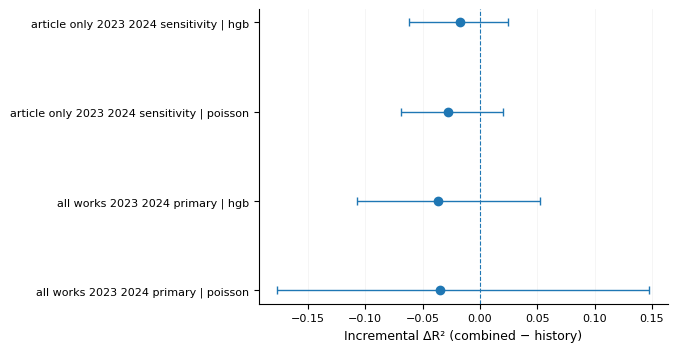

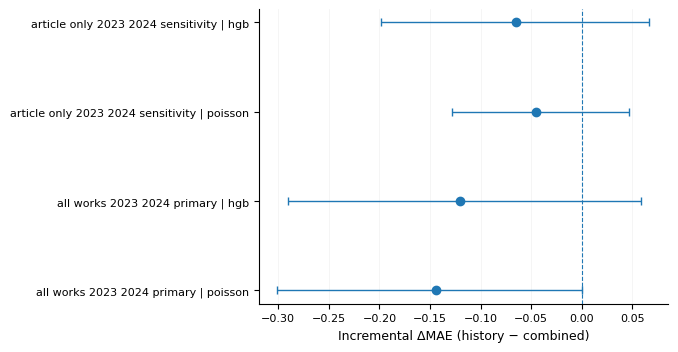


PART 18.18 v3 — FINAL FREEZE
PARTE 18.18 v3 — FINAL LABORATORY FREEZE

Status:
LABORATORY_FROZEN_READY_FOR_MANUSCRIPT

Primary endpoint:
future_works_2023_2024

Feature period:
2018–2022

Primary clean paired results:
- Poisson: ΔR²=-0.0350, ΔMAE=-0.1440
- HGB:     ΔR²=-0.0363, ΔMAE=-0.1201

Repeated-CV median values:
- Poisson: ΔR²=-0.0061, ΔMAE=-0.0840
- HGB:     ΔR²=-0.0253, ΔMAE=-0.1041

Frozen interpretation:
Across the clean primary analysis, repeated-CV sensitivity, negative control, and article-only robustness, there is no clear evidence that collaboration-graph features add prospective predictive value beyond publication history for 2023–2024. The stronger 2025 post-hoc signal is not reproduced consistently in 2023 and 2024, and the 2025 coverage audit does not allow it to override the pre-specified primary endpoint.

Manuscript rules:
1. Primary endpoint = future_works_2023_2024.
2. History block = principal benchmark.
3. Article-only = robustness check, not replacement of p

In [ ]:
# -*- coding: utf-8 -*-
"""
PARTE 18.18 v3 — SÍNTESE FINAL DO LABORATÓRIO E FREEZE PARA O MANUSCRITO
=========================================================================

Objetivo
--------
Consolidar, sem refazer modelos, os resultados já produzidos nas Partes 18.14–18.17.

Esta versão aceita DUAS estruturas possíveis da Tabela 54:
(A) resumo longo:
    family, metric, n_repeats, median, mean, sd, p2_5, p97_5, positive_share
(B) resultados por repetição:
    family, repeat, delta_MAE, delta_RMSE, delta_R2, delta_Poisson_deviance

Execução
--------
%run /content/Parte_18_18_Final_Lab_Synthesis_v3.py
"""

from __future__ import annotations
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = None

# ======================================================================================
# 0. DRIVE
# ======================================================================================

MYDRIVE = Path("/content/drive/MyDrive")
if not MYDRIVE.exists():
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
else:
    print("[drive] Google Drive já disponível; remount não necessário.")

# ======================================================================================
# 1. CAMINHOS
# ======================================================================================

ROOT = Path("/content/drive/MyDrive/tese_doutoral/runs/temporal_productivity_20260929")
P14 = ROOT / "14_clean_final_predictive_rerun"
P15 = ROOT / "15_clean_annual_hurdle_replication"
P16 = ROOT / "16_2025_coverage_temporal_audit_v2_corrected"
P17 = ROOT / "17_article_only_outcome_robustness"

OUT = ROOT / "18_final_lab_synthesis_freeze"
TAB = OUT / "tables"
FIG = OUT / "figures"
NOTES = OUT / "notes"
ART = OUT / "artifacts"
for d in [OUT, TAB, FIG, NOTES, ART]:
    d.mkdir(parents=True, exist_ok=True)

print("\n" + "=" * 118)
print("PARTE 18.18 v3 — SÍNTESE FINAL DO LABORATÓRIO")
print("=" * 118)
print("[output]", OUT)

# ======================================================================================
# 2. HELPERS
# ======================================================================================

def show(title, df, max_rows=50):
    print("\n" + "=" * 118)
    print(title)
    print("=" * 118)
    if df is None:
        print("[None]")
        return
    if len(df) == 0:
        print("[vazio]")
        print("columns:", list(df.columns))
    else:
        print(df.head(max_rows).to_string(index=False))
        if len(df) > max_rows:
            print(f"... ({len(df):,} rows total)")
    if display is not None:
        display(df.head(max_rows))

def std_family_value(x):
    s = str(x).strip().lower()
    return {
        "poisson": "poisson",
        "poissonregressor": "poisson",
        "poisson_regressor": "poisson",
        "hgb": "hgb",
        "histgradientboosting": "hgb",
        "hist_gradient_boosting": "hgb",
        "histgradientboostingregressor": "hgb",
    }.get(s, s)

def bool_series(s):
    if not isinstance(s, pd.Series):
        s = pd.Series(s)
    def conv(v):
        if pd.isna(v):
            return pd.NA
        if isinstance(v, (bool, np.bool_)):
            return bool(v)
        z = str(v).strip().lower()
        if z in {"true","1","yes","y","sim"}:
            return True
        if z in {"false","0","no","n","nao","não"}:
            return False
        return pd.NA
    return s.map(conv).astype("boolean")

def read_csv_safe(path):
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[warning] falha ao ler {path}: {e}")
        return None

def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return None

def find_csv_by_schema(folder, required=None, alternatives=None):
    folder = Path(folder)
    if not folder.exists():
        return None
    for p in sorted(folder.rglob("*.csv")):
        try:
            df0 = pd.read_csv(p, nrows=3)
        except Exception:
            continue
        cols = set(df0.columns)
        if required and not set(required).issubset(cols):
            continue
        if alternatives and not any(set(a).issubset(cols) for a in alternatives):
            continue
        return p
    return None

def load_input(label, preferred, required=None, alternatives=None, fallback_folder=None):
    p = first_existing(preferred)
    if p is None and fallback_folder is not None:
        p = find_csv_by_schema(fallback_folder, required, alternatives)
    if p is None:
        print(f"[warning] {label}: não localizado")
        return None, None
    df = read_csv_safe(p)
    if df is not None:
        print(f"[input] {label}: {p}")
        print(f"        shape={df.shape}")
        print(f"        columns={list(df.columns)}")
    return df, p

# ======================================================================================
# 3. TABLE 54 ADAPTER
# ======================================================================================

DELTA_METRICS = ["delta_MAE","delta_RMSE","delta_R2","delta_Poisson_deviance"]

def normalize_table54(df):
    if df is None:
        return pd.DataFrame(columns=[
            "family","metric","n_repeats","median","mean","sd","p2_5","p97_5","positive_share"
        ])
    x = df.copy()
    if "family" not in x.columns:
        raise ValueError(f"Table 54 sem 'family'. Colunas: {list(x.columns)}")
    x["family"] = x["family"].map(std_family_value)

    long_cols = {"family","metric","n_repeats","median","mean","sd","p2_5","p97_5","positive_share"}
    if long_cols.issubset(x.columns):
        y = x[["family","metric","n_repeats","median","mean","sd","p2_5","p97_5","positive_share"]].copy()
        return y.sort_values(["family","metric"]).reset_index(drop=True)

    metrics = [c for c in DELTA_METRICS if c in x.columns]
    if not metrics:
        raise ValueError(f"Table 54 em esquema desconhecido. Colunas: {list(x.columns)}")

    id_vars = ["family"] + (["repeat"] if "repeat" in x.columns else [])
    m = x.melt(id_vars=id_vars, value_vars=metrics, var_name="metric", value_name="value")
    m["value"] = pd.to_numeric(m["value"], errors="coerce")
    m = m.dropna(subset=["value"])

    rows = []
    for (fam, metric), g in m.groupby(["family","metric"], dropna=False):
        vals = g["value"].to_numpy(float)
        if len(vals) == 0:
            continue
        rows.append({
            "family": fam,
            "metric": metric,
            "n_repeats": int(g["repeat"].nunique()) if "repeat" in g.columns else int(len(vals)),
            "median": float(np.median(vals)),
            "mean": float(np.mean(vals)),
            "sd": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
            "p2_5": float(np.quantile(vals, .025)),
            "p97_5": float(np.quantile(vals, .975)),
            "positive_share": float(np.mean(vals > 0)),
        })
    return pd.DataFrame(rows).sort_values(["family","metric"]).reset_index(drop=True)

# ======================================================================================
# 4. INPUTS
# ======================================================================================

t51, p51 = load_input(
    "Table 51",
    [P14/"tables/Table_51_clean_primary_predictive_performance.csv",
     P14/"tables/Table_51_primary_predictive_performance.csv"],
    required=["family","block","MAE","R2"],
    fallback_folder=P14/"tables"
)

t52, p52 = load_input(
    "Table 52",
    [P14/"tables/Table_52_clean_incremental_graph_value_paired_bootstrap.csv",
     P14/"tables/Table_52_incremental_graph_value_paired_bootstrap.csv"],
    required=["family","metric","observed","ci95_low","ci95_high"],
    fallback_folder=P14/"tables"
)

t54_raw, p54 = load_input(
    "Table 54",
    [P14/"tables/Table_54_clean_repeated_cv_split_sensitivity.csv",
     P14/"tables/Table_54_repeated_cv_split_sensitivity.csv",
     P14/"artifacts/repeated_cv_clean_results.csv",
     P14/"artifacts/repeated_cv_results.csv"],
    required=["family"],
    alternatives=[["metric","n_repeats","median"],["repeat","delta_R2","delta_MAE"]],
    fallback_folder=P14
)

# se o caminho preferido apontou para CSV incompatível, refaz busca por schema
if t54_raw is not None:
    c54 = set(t54_raw.columns)
    ok54 = (
        {"family","metric","n_repeats","median"}.issubset(c54)
        or {"family","repeat","delta_R2","delta_MAE"}.issubset(c54)
    )
else:
    ok54 = False

if not ok54:
    p54 = find_csv_by_schema(
        P14,
        required=["family"],
        alternatives=[["metric","n_repeats","median"],["repeat","delta_R2","delta_MAE"]]
    )
    t54_raw = read_csv_safe(p54) if p54 else None
    print("[fallback Table 54]", p54)

t55, p55 = load_input(
    "Table 55",
    [P14/"tables/Table_55_clean_negative_control.csv",
     P14/"tables/Table_55_negative_control.csv"],
    required=["family","metric","empirical_p_null_ge_observed"],
    fallback_folder=P14/"tables"
)

t57, p57 = load_input(
    "Table 57",
    [P14/"tables/Table_57_clean_final_incremental_graph_decision.csv"],
    required=["family","delta_R2_observed","delta_MAE_observed","clear_positive_R2","clear_positive_MAE"],
    fallback_folder=P14/"tables"
)

t62, p62 = load_input(
    "Table 62",
    [P15/"tables/Table_62_clean_annual_mechanism_decision_gate.csv"],
    required=["status","primary_2023_2024_endpoint_remains_unchanged"],
    fallback_folder=P15/"tables"
)

t71, p71 = load_input(
    "Table 71 corrected",
    [P16/"tables/Table_71_2025_coverage_decision_gate_CORRECTED.csv",
     P16/"tables/Table_71_2025_coverage_decision_gate.csv"],
    required=["status","primary_endpoint_remains_2023_2024"],
    fallback_folder=P16/"tables"
)

t78, p78 = load_input(
    "Table 78",
    [P17/"tables/Table_78_cross_outcome_incremental_graph_robustness.csv",
     P17/"tables/Table_78_cross_outcome_incremental_graph_value.csv",
     P17/"tables/Table_78_cross_outcome_robustness.csv"],
    required=["outcome_definition","family","delta_R2_observed","delta_MAE_observed",
              "clear_positive_R2","clear_positive_MAE"],
    fallback_folder=P17/"tables"
)

t79, p79 = load_input(
    "Table 79",
    [P17/"tables/Table_79_article_only_robustness_decision_gate.csv",
     P17/"tables/Table_79_robustness_decision_gate.csv"],
    required=["status","primary_endpoint_preserved"],
    fallback_folder=P17/"tables"
)

# ======================================================================================
# 5. NORMALIZAÇÕES
# ======================================================================================

t54 = normalize_table54(t54_raw)

for df in [t51,t52,t55,t57,t78]:
    if df is not None and "family" in df.columns:
        df["family"] = df["family"].map(std_family_value)

for df in [t57,t78]:
    if df is not None:
        for c in ["clear_positive_R2","clear_positive_MAE"]:
            if c in df.columns:
                df[c] = bool_series(df[c]).values

if t62 is not None and "primary_2023_2024_endpoint_remains_unchanged" in t62.columns:
    t62["primary_2023_2024_endpoint_remains_unchanged"] = bool_series(
        t62["primary_2023_2024_endpoint_remains_unchanged"]
    ).values

if t71 is not None:
    for c in ["primary_endpoint_remains_2023_2024","2025_can_override_primary_conclusion"]:
        if c in t71.columns:
            t71[c] = bool_series(t71[c]).values

if t79 is not None and "2025_excluded" in t79.columns:
    t79["2025_excluded"] = bool_series(t79["2025_excluded"]).values

# ======================================================================================
# 6. TABLE 80/80B
# ======================================================================================

audit = []
for label,path,df in [
    ("T51",p51,t51),("T52",p52,t52),("T54",p54,t54_raw),("T55",p55,t55),
    ("T57",p57,t57),("T62",p62,t62),("T71",p71,t71),("T78",p78,t78),("T79",p79,t79)
]:
    audit.append({
        "input":label,
        "found":bool(path is not None and df is not None),
        "path":str(path) if path else "",
        "rows":len(df) if df is not None else np.nan,
        "columns":" | ".join(map(str,df.columns)) if df is not None else ""
    })
t80 = pd.DataFrame(audit)
t80.to_csv(TAB/"Table_80_final_synthesis_input_audit.csv",index=False)
show("TABLE 80 — FINAL SYNTHESIS INPUT AUDIT",t80)

t54.to_csv(TAB/"Table_80B_repeated_cv_normalized_long_summary.csv",index=False)
show("TABLE 80B — REPEATED-CV NORMALIZED LONG SUMMARY",t54)

# ======================================================================================
# 7. TABLE 81
# ======================================================================================

t81 = t51.copy() if t51 is not None else pd.DataFrame()
t81.to_csv(TAB/"Table_81_primary_predictive_performance_manuscript_ready.csv",index=False)
show("TABLE 81 — PRIMARY PREDICTIVE PERFORMANCE",t81)

# ======================================================================================
# 8. TABLE 82
# ======================================================================================

t82 = t52.copy() if t52 is not None else pd.DataFrame()
t82.to_csv(TAB/"Table_82_primary_incremental_graph_value.csv",index=False)
show("TABLE 82 — PRIMARY INCREMENTAL GRAPH VALUE",t82)

# ======================================================================================
# 9. TABLE 83
# ======================================================================================

families = sorted(
    set(t57["family"].dropna()) if t57 is not None else set()
    | set(t54["family"].dropna()) if len(t54) else set()
)

# corrige precedência de conjuntos explicitamente
families = sorted(
    (set(t57["family"].dropna()) if t57 is not None else set())
    | (set(t54["family"].dropna()) if len(t54) else set())
    | (set(t55["family"].dropna()) if t55 is not None else set())
)

rows = []
for fam in families:
    r = {"family":fam}

    if t57 is not None:
        g=t57[t57["family"]==fam]
        if len(g):
            q=g.iloc[0]
            for c in ["delta_R2_observed","delta_R2_ci95_low","delta_R2_ci95_high",
                      "delta_MAE_observed","delta_MAE_ci95_low","delta_MAE_ci95_high",
                      "clear_positive_R2","clear_positive_MAE"]:
                if c in g.columns: r[c]=q[c]

    for metric,sfx in [("delta_R2","R2"),("delta_MAE","MAE")]:
        g=t54[(t54["family"]==fam)&(t54["metric"]==metric)]
        if len(g):
            q=g.iloc[0]
            r[f"repeated_cv_delta_{sfx}_median"]=q["median"]
            r[f"repeated_cv_delta_{sfx}_p2_5"]=q["p2_5"]
            r[f"repeated_cv_delta_{sfx}_p97_5"]=q["p97_5"]

    if t55 is not None:
        for metric,sfx in [("delta_R2","R2"),("delta_MAE","MAE")]:
            g=t55[(t55["family"]==fam)&(t55["metric"]==metric)]
            if len(g):
                r[f"negative_control_p_{sfx}"]=g.iloc[0]["empirical_p_null_ge_observed"]

    cp_r2 = False if pd.isna(r.get("clear_positive_R2",pd.NA)) else bool(r["clear_positive_R2"])
    cp_mae = False if pd.isna(r.get("clear_positive_MAE",pd.NA)) else bool(r["clear_positive_MAE"])
    r["interpretation"] = (
        "Clear incremental graph value."
        if cp_r2 or cp_mae
        else "No clear paired evidence that graph features improve prediction beyond publication history."
    )
    rows.append(r)

t83=pd.DataFrame(rows)
t83.to_csv(TAB/"Table_83_primary_robustness_synthesis.csv",index=False)
show("TABLE 83 — PRIMARY ROBUSTNESS SYNTHESIS",t83)

# ======================================================================================
# 10. TABLE 84 — FIX DEFINITIVO DO ERRO
# ======================================================================================

if t78 is not None:
    t84=t78.copy()
    t84["family"]=t84["family"].map(std_family_value)

    for c in ["clear_positive_R2","clear_positive_MAE"]:
        if c in t84.columns:
            # CORRETO: passa a SERIES, não o nome c.
            t84[c]=bool_series(t84[c]).values

    rep_r2=t54[t54["metric"]=="delta_R2"][["family","median","p2_5","p97_5"]].rename(columns={
        "median":"primary_repeated_cv_delta_R2_median",
        "p2_5":"primary_repeated_cv_delta_R2_p2_5",
        "p97_5":"primary_repeated_cv_delta_R2_p97_5"
    })
    rep_mae=t54[t54["metric"]=="delta_MAE"][["family","median","p2_5","p97_5"]].rename(columns={
        "median":"primary_repeated_cv_delta_MAE_median",
        "p2_5":"primary_repeated_cv_delta_MAE_p2_5",
        "p97_5":"primary_repeated_cv_delta_MAE_p97_5"
    })
    t84=t84.merge(rep_r2,on="family",how="left").merge(rep_mae,on="family",how="left")

    if t55 is not None:
        nr=t55[t55["metric"]=="delta_R2"][["family","empirical_p_null_ge_observed"]].rename(
            columns={"empirical_p_null_ge_observed":"primary_negative_control_p_R2"})
        nm=t55[t55["metric"]=="delta_MAE"][["family","empirical_p_null_ge_observed"]].rename(
            columns={"empirical_p_null_ge_observed":"primary_negative_control_p_MAE"})
        t84=t84.merge(nr,on="family",how="left").merge(nm,on="family",how="left")

    txt=[]
    for _,row in t84.iterrows():
        posr2=False if pd.isna(row["clear_positive_R2"]) else bool(row["clear_positive_R2"])
        posmae=False if pd.isna(row["clear_positive_MAE"]) else bool(row["clear_positive_MAE"])
        txt.append(
            "At least one criterion indicates a clear positive incremental graph effect."
            if (posr2 or posmae)
            else "No clear paired evidence that graph features improve prediction beyond publication history."
        )
    t84["interpretation"]=txt
else:
    t84=pd.DataFrame()

t84.to_csv(TAB/"Table_84_cross_definition_robustness.csv",index=False)
show("TABLE 84 — CROSS-DEFINITION ROBUSTNESS",t84)

# ======================================================================================
# 11. TABLE 85
# ======================================================================================

m=[]

if t57 is not None and len(t57):
    any_pos=bool(
        (bool_series(t57["clear_positive_R2"]).fillna(False) |
         bool_series(t57["clear_positive_MAE"]).fillna(False)).any()
    )
    m.append({
        "analysis":"Primary all-works 2023–2024 paired nested-CV",
        "role":"Primary",
        "status":"supports graph increment" if any_pos else "no clear graph increment",
        "changes_primary_conclusion":any_pos
    })

if len(t54):
    piv=t54.pivot_table(index="family",columns="metric",values="median",aggfunc="first")
    support=bool(
        "delta_R2" in piv.columns and "delta_MAE" in piv.columns
        and ((piv["delta_R2"]>0)&(piv["delta_MAE"]>0)).any()
    )
    m.append({
        "analysis":"Repeated 10-fold CV split sensitivity",
        "role":"Primary robustness",
        "status":"supports graph increment" if support else "does not establish graph increment",
        "changes_primary_conclusion":False
    })

if t55 is not None and len(t55):
    m.append({
        "analysis":"Permuted-graph negative control",
        "role":"Primary robustness",
        "status":"observed graph increment not distinguished from permutation null",
        "changes_primary_conclusion":False
    })

if t79 is not None and len(t79):
    m.append({
        "analysis":"Article-only outcome/history/network definition",
        "role":"Outcome-definition robustness",
        "status":str(t79.iloc[0].get("status","")),
        "changes_primary_conclusion":False
    })

if t62 is not None and len(t62):
    unchanged=t62.iloc[0].get("primary_2023_2024_endpoint_remains_unchanged",True)
    m.append({
        "analysis":"Annual extensive/intensive/hurdle replication",
        "role":"Post-hoc mechanism",
        "status":str(t62.iloc[0].get("status","")),
        "changes_primary_conclusion":not bool(unchanged)
    })

if t71 is not None and len(t71):
    can=t71.iloc[0].get("2025_can_override_primary_conclusion",False)
    m.append({
        "analysis":"2025 corpus coverage / temporal comparability audit",
        "role":"Data-quality sensitivity",
        "status":str(t71.iloc[0].get("status","")),
        "changes_primary_conclusion":False if pd.isna(can) else bool(can)
    })

t85=pd.DataFrame(m)
t85.to_csv(TAB/"Table_85_final_robustness_matrix.csv",index=False)
show("TABLE 85 — FINAL ROBUSTNESS MATRIX",t85)

# ======================================================================================
# 12. TABLE 86
# ======================================================================================

primary_null=False
if t57 is not None and len(t57):
    pos=(bool_series(t57["clear_positive_R2"]).fillna(False) |
         bool_series(t57["clear_positive_MAE"]).fillna(False))
    primary_null=not bool(pos.any())

article_robust=True
if t78 is not None and len(t78):
    a=t78[t78["outcome_definition"].astype(str).str.contains("article",case=False,na=False)]
    if len(a):
        pos=(bool_series(a["clear_positive_R2"]).fillna(False) |
             bool_series(a["clear_positive_MAE"]).fillna(False))
        article_robust=not bool(pos.any())

repeat_positive=False
if len(t54):
    piv=t54.pivot_table(index="family",columns="metric",values="median",aggfunc="first")
    if "delta_R2" in piv.columns and "delta_MAE" in piv.columns:
        repeat_positive=bool(((piv["delta_R2"]>0)&(piv["delta_MAE"]>0)).any())

year2025_override=False
if t71 is not None and len(t71) and "2025_can_override_primary_conclusion" in t71.columns:
    z=t71.iloc[0]["2025_can_override_primary_conclusion"]
    year2025_override=False if pd.isna(z) else bool(z)

annual_replicates=False
if t62 is not None and len(t62):
    q=t62.iloc[0]
    annual_replicates=bool(
        q.get("intensive_replicates_all_years",False)
        or q.get("hurdle_replicates_all_years",False)
    )

ready=bool(
    primary_null and article_robust and not repeat_positive
    and not year2025_override and not annual_replicates
)

status="LABORATORY_FROZEN_READY_FOR_MANUSCRIPT" if ready else "LABORATORY_REQUIRES_REVIEW_BEFORE_MANUSCRIPT"

interpretation=(
    "Across the clean primary analysis, repeated-CV sensitivity, negative control, and article-only robustness, "
    "there is no clear evidence that collaboration-graph features add prospective predictive value beyond publication "
    "history for 2023–2024. The stronger 2025 post-hoc signal is not reproduced consistently in 2023 and 2024, and "
    "the 2025 coverage audit does not allow it to override the pre-specified primary endpoint."
    if ready else
    "At least one synthesis gate conflicts with the frozen primary interpretation; inspect Table 85 before manuscript drafting."
)

t86=pd.DataFrame([{
    "primary_2023_2024_no_clear_incremental_graph_value":primary_null,
    "repeated_cv_does_not_support_consistent_positive_increment":not repeat_positive,
    "article_only_definition_preserves_primary_conclusion":article_robust,
    "annual_2025_signal_replicates_across_2023_2025":annual_replicates,
    "2025_can_override_primary_conclusion":year2025_override,
    "ready_for_manuscript":ready,
    "status":status,
    "interpretation":interpretation
}])
t86.to_csv(TAB/"Table_86_final_laboratory_decision_gate.csv",index=False)
show("TABLE 86 — FINAL LABORATORY DECISION GATE",t86)

# ======================================================================================
# 13. FIGURES
# ======================================================================================

plt.rcParams.update({
    "font.family":"sans-serif","font.size":9,"axes.labelsize":9,
    "xtick.labelsize":8,"ytick.labelsize":8,"legend.fontsize":8,
    "axes.spines.top":False,"axes.spines.right":False,
    "pdf.fonttype":42,"ps.fonttype":42
})

def cross_figure(metric, low, high, xlabel, stem):
    if t78 is None or len(t78)==0:
        return
    p=t78.copy().reset_index(drop=True)
    p["label"]=p["outcome_definition"].astype(str).str.replace("_"," ",regex=False)+" | "+p["family"].astype(str)
    y=np.arange(len(p))
    x=pd.to_numeric(p[metric],errors="coerce").to_numpy()
    lo=pd.to_numeric(p[low],errors="coerce").to_numpy()
    hi=pd.to_numeric(p[high],errors="coerce").to_numpy()
    err=np.vstack([x-lo,hi-x])
    fig,ax=plt.subplots(figsize=(6.85,3.6))
    ax.errorbar(x,y,xerr=err,fmt="o",capsize=3,linewidth=1.0)
    ax.axvline(0,linestyle="--",linewidth=.8)
    ax.set_yticks(y); ax.set_yticklabels(p["label"])
    ax.set_xlabel(xlabel); ax.grid(axis="x",alpha=.18,linewidth=.5)
    fig.tight_layout()
    fig.savefig(FIG/f"{stem}.eps",format="eps",bbox_inches="tight")
    fig.savefig(FIG/f"{stem}.png",dpi=600,bbox_inches="tight")
    if display is not None: display(fig)
    plt.close(fig)

cross_figure(
    "delta_R2_observed","delta_R2_ci95_low","delta_R2_ci95_high",
    "Incremental ΔR² (combined − history)","Fig18A_cross_outcome_delta_R2"
)
cross_figure(
    "delta_MAE_observed","delta_MAE_ci95_low","delta_MAE_ci95_high",
    "Incremental ΔMAE (history − combined)","Fig18B_cross_outcome_delta_MAE"
)

# ======================================================================================
# 14. FREEZE TEXT + JSON
# ======================================================================================

def getv(df,fam,col):
    if df is None or "family" not in df.columns or col not in df.columns: return np.nan
    g=df[df["family"]==fam]
    return np.nan if len(g)==0 else g.iloc[0][col]

def f4(x):
    return "NA" if pd.isna(x) else f"{float(x):.4f}"

def repmed(fam,metric):
    g=t54[(t54["family"]==fam)&(t54["metric"]==metric)]
    return np.nan if len(g)==0 else g.iloc[0]["median"]

freeze_text=f"""
PARTE 18.18 v3 — FINAL LABORATORY FREEZE
========================================

Status:
{status}

Primary endpoint:
future_works_2023_2024

Feature period:
2018–2022

Primary clean paired results:
- Poisson: ΔR²={f4(getv(t57,"poisson","delta_R2_observed"))}, ΔMAE={f4(getv(t57,"poisson","delta_MAE_observed"))}
- HGB:     ΔR²={f4(getv(t57,"hgb","delta_R2_observed"))}, ΔMAE={f4(getv(t57,"hgb","delta_MAE_observed"))}

Repeated-CV median values:
- Poisson: ΔR²={f4(repmed("poisson","delta_R2"))}, ΔMAE={f4(repmed("poisson","delta_MAE"))}
- HGB:     ΔR²={f4(repmed("hgb","delta_R2"))}, ΔMAE={f4(repmed("hgb","delta_MAE"))}

Frozen interpretation:
{interpretation}

Manuscript rules:
1. Primary endpoint = future_works_2023_2024.
2. History block = principal benchmark.
3. Article-only = robustness check, not replacement of primary endpoint.
4. 2025 = post-hoc/sensitivity only.
5. Do not claim incremental prospective graph value unless explicitly tied to a post-hoc analysis.
6. Main substantive result: graph position may correlate with productivity cross-sectionally, but the clean
   leakage-aware prospective design does not show clear incremental predictive value beyond publication history.
""".strip()

summary_path=NOTES/"Part_18_18_v3_final_laboratory_freeze.txt"
summary_path.write_text(freeze_text,encoding="utf-8")

print("\n"+"="*118)
print("PART 18.18 v3 — FINAL FREEZE")
print("="*118)
print(freeze_text)

freeze_json={
    "status":status,
    "ready_for_manuscript":ready,
    "primary_endpoint":"future_works_2023_2024",
    "feature_period":"2018-2022",
    "primary_null":primary_null,
    "article_only_robust":article_robust,
    "repeated_cv_supports_positive_increment":repeat_positive,
    "annual_2025_signal_replicates":annual_replicates,
    "2025_can_override_primary_conclusion":year2025_override
}
(ART/"part18_18_v3_final_freeze.json").write_text(
    json.dumps(freeze_json,ensure_ascii=False,indent=2),encoding="utf-8"
)

manifest=[]
for folder in [TAB,FIG,NOTES,ART]:
    for p in sorted(folder.glob("*")):
        if p.is_file():
            manifest.append({"type":folder.name,"name":p.name,"path":str(p)})
pd.DataFrame(manifest).to_csv(OUT/"output_manifest.csv",index=False)

print("\n"+"="*118)
print("BLOCOS PARA ENVIAR AO CHATGPT")
print("="*118)
print("1) TABLE 80B — REPEATED-CV NORMALIZED LONG SUMMARY")
print("2) TABLE 83 — PRIMARY ROBUSTNESS SYNTHESIS")
print("3) TABLE 84 — CROSS-DEFINITION ROBUSTNESS")
print("4) TABLE 85 — FINAL ROBUSTNESS MATRIX")
print("5) TABLE 86 — FINAL LABORATORY DECISION GATE")
print("6) PART 18.18 v3 — FINAL FREEZE")
print("\n[output]",OUT)
print("CONCLUÍDO.")


